This is a **CLEAN** but vivid version of codes (along with visualizations) 
for analyzing the experiment ***freight collaboration-chessboard*** results

# Required packages

In [368]:
from dataclasses import dataclass
from enum import Enum
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
# Use repo-relative path so it works on other machines
notebook_dir = Path.cwd() / "python" / "test"
if notebook_dir.exists() and str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))
import matsim
from pygam import LogisticGAM, GammaGAM, s, f, te
from pointpats import PointPattern, PoissonPointProcess
from pointpats.distance_statistics import g, f, k, l, j
import matsim_output_reader
import metric_anls
import figure_plot 
import agg_anls
import spatial_anls
# --- reload the module to reflect any changes made during development ---
import importlib
importlib.reload(matsim_output_reader)
importlib.reload(metric_anls)
importlib.reload(figure_plot)
importlib.reload(agg_anls)
importlib.reload(spatial_anls)

<module 'spatial_anls' from 'f:\\gitRepository\\matsim-libs-2024\\python\\test\\spatial_anls.py'>

# Configuration

In [2]:
# Resolve analysis path relative to repo root
repo_root = notebook_dir.parents[1]  # .../matsim-libs-2024
anls_path = repo_root / "output" / "chessboardCarrierReceiverCollab"

class DepotLocation(Enum):
    INSIDE = 'center'
    OUTSIDE = 'left'

class ReceiverDistribution(Enum):
    DISPERSED = 'DISPERSED'
    CLUSTERED = 'CLUSTERED'
    RANDOM = 'FULLY_RANDOM'

ALLOCATION_FACTOR = 0.8
ALLOCATION_FACTOR_LIST = [x / 10 for x in range(1, 10)]  # 0.1 to 0.9 with step of 0.1
#--- Penalty ---#
PENALTY_LIST = [0, 0.0003, 0.0008, 0.0014, 0.0028, 0.0056,
                0.0098, 0.014, 0.0167, 0.0222, 0.028, 0.0333, 0.0417]
PENALTY_LIST_SCALE = [round(x * 3600) for x in PENALTY_LIST]  # scale to avoid float precision issues
PENALTY_LIST_SCALE[PENALTY_LIST.index(0.028)] = 100 
PENALTY_DICT = {k: v for k, v in zip(PENALTY_LIST, PENALTY_LIST_SCALE)}
#--- Penalty ---#

TOTAL_INSTANCES = 60


In [3]:
# Configuration for batch processing
# INPUT_PATH = str(anls_path)
OUTPUT_PATH = str(repo_root / "data" / "freightChessboardRC" / "clean")
DISPERSED_OUTPUT_PATH = str(repo_root / "data" / "freightChessboardRC" / "cleanMoreDispersed")
MORE_AF_OUTPUT_PATH = str(repo_root / "data" / "freightChessboardRC" / "cleanMoreAF")
MORE_PEN_OUTPUT_PATH = str(repo_root / "data" / "freightChessboardRC" / "cleanMorePen")

# Define which scenarios to process
DEPOT_LOCATIONS = [DepotLocation.INSIDE.value, DepotLocation.OUTSIDE.value]
RECEIVER_DISTRIBUTIONS = [ReceiverDistribution.DISPERSED.value, ReceiverDistribution.CLUSTERED.value]
ORIGINAL_TW = (6, 7)  # Original time window in hours
LAST_ITER = 30  # Last iteration number

In [4]:
#--- Generate keywords for each scenario ---#
# Example tuple: ("center", "dispersed", 0)
scenario_keywords = [
    (depot, receiver, penalty)
    for depot, receiver, penalty in product([DepotLocation.INSIDE.value, DepotLocation.OUTSIDE.value],
                                            [ReceiverDistribution.DISPERSED.value, ReceiverDistribution.CLUSTERED.value], 
                                            PENALTY_LIST)
]
scenario_keywords[:3]

[('center', 'DISPERSED', 0),
 ('center', 'DISPERSED', 0.0003),
 ('center', 'DISPERSED', 0.0008)]

In [5]:
OUTPUT_FIG_PATH = repo_root / "data" / "freightChessboardRC" / "figures"
OUTPUT_FIG_PATH.mkdir(parents=True, exist_ok=True)

In [6]:
network_dir = repo_root / "data" / "freightChessboardRC" / "output_network.xml.gz"
network = matsim.read_network(network_dir)
network_links = network.links
network_nodes = network.nodes

In [7]:
# Build network graph once for efficiency
network_graph = agg_anls.build_network_graph(network_links, network_nodes)
print(f"Network graph: {network_graph.number_of_nodes()} nodes, {network_graph.number_of_edges()} edges")

Network graph: 102 nodes, 180 edges


In [8]:
full_network_gdf = spatial_anls.network_graph_to_gdf(network_graph)
full_network_gdf

,link_id,from_node,to_node,length,geometry
0,"i(1,0)","(0,0)","(1,0)",1000.0,"LINESTRING (0.000 0.000, 1000.000 0.000)"
1,"j(0,1)R","(0,1)","(0,0)",1000.0,"LINESTRING (0.000 1000.000, 0.000 0.000)"
2,"i(1,2)","(0,2)","(1,2)",1000.0,"LINESTRING (0.000 2000.000, 1000.000 2000.000)"
3,"j(0,2)R","(0,2)","(0,1)",1000.0,"LINESTRING (0.000 2000.000, 0.000 1000.000)"
4,"j(0,3)R","(0,3)","(0,2)",1000.0,"LINESTRING (0.000 3000.000, 0.000 2000.000)"
...,...,...,...,...,...
175,"j(9,7)","(9,6)","(9,7)",1000.0,"LINESTRING (9000.000 6000.000, 9000.000 7000.000)"
176,"i(9,7)R","(9,7)","(8,7)",1000.0,"LINESTRING (9000.000 7000.000, 8000.000 7000.000)"
177,"j(9,8)","(9,7)","(9,8)",1000.0,"LINESTRING (9000.000 7000.000, 9000.000 8000.000)"
178,"j(9,9)","(9,8)","(9,9)",1000.0,"LINESTRING (9000.000 8000.000, 9000.000 9000.000)"


In [9]:
central_area_network_gdf = spatial_anls.network_graph_to_gdf(
    network_graph,
    boundary=[2000, 2000, 7000, 7000])
central_area_network_gdf

,link_id,from_node,to_node,length,geometry
0,"i(3,2)","(2,2)","(3,2)",1000.0,"LINESTRING (2000.000 2000.000, 3000.000 2000.000)"
1,"j(2,3)R","(2,3)","(2,2)",1000.0,"LINESTRING (2000.000 3000.000, 2000.000 2000.000)"
2,"i(3,4)","(2,4)","(3,4)",1000.0,"LINESTRING (2000.000 4000.000, 3000.000 4000.000)"
3,"j(2,4)R","(2,4)","(2,3)",1000.0,"LINESTRING (2000.000 4000.000, 2000.000 3000.000)"
4,"j(2,5)R","(2,5)","(2,4)",1000.0,"LINESTRING (2000.000 5000.000, 2000.000 4000.000)"
5,"i(3,6)","(2,6)","(3,6)",1000.0,"LINESTRING (2000.000 6000.000, 3000.000 6000.000)"
6,"j(2,6)R","(2,6)","(2,5)",1000.0,"LINESTRING (2000.000 6000.000, 2000.000 5000.000)"
7,"j(2,7)R","(2,7)","(2,6)",1000.0,"LINESTRING (2000.000 7000.000, 2000.000 6000.000)"
8,"i(4,2)","(3,2)","(4,2)",1000.0,"LINESTRING (3000.000 2000.000, 4000.000 2000.000)"
9,"j(3,3)","(3,2)","(3,3)",1000.0,"LINESTRING (3000.000 2000.000, 3000.000 3000.000)"


# Read all_instance_metric df

In [10]:
all_metrics_df = pd.read_csv(os.path.join(OUTPUT_PATH, 'all_scenarios_metrics.csv.gz'), compression='gzip')
all_metrics_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,VKT_km,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km
0,center,CLUSTERED,0.5,0.000,0,2,2,533.865333,346.8322,10,...,30.0,52.0,16132.0,20794.0,61000.0,45000.0,1.744697,3.0,0.941421,1.2
1,center,CLUSTERED,0.5,0.000,1,2,2,479.119950,342.5000,10,...,38.0,52.0,17204.0,20794.0,73000.0,47000.0,2.351147,4.6,0.841421,1.0
2,center,CLUSTERED,0.5,0.000,2,2,2,514.799819,368.6931,10,...,34.0,52.0,16668.0,20251.0,75500.0,44500.0,1.629127,2.5,0.741421,1.4
3,center,CLUSTERED,0.5,0.000,3,2,2,542.640463,362.3857,10,...,30.0,48.0,15772.0,20206.0,62000.0,44000.0,1.932033,2.8,1.000000,1.4
4,center,CLUSTERED,0.5,0.000,4,2,2,503.215238,328.7115,10,...,34.0,52.0,16668.0,20610.0,74000.0,48000.0,1.849190,2.8,0.941421,1.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17155,left,FULLY_RANDOM,0.9,0.028,55,2,2,233.524000,249.1994,0,...,84.0,80.0,25082.0,24898.0,57500.0,57500.0,4.835993,6.7,0.600000,1.0
17156,left,FULLY_RANDOM,0.9,0.028,56,2,2,85.151900,94.1519,0,...,101.0,101.0,28493.0,28493.0,62500.0,62500.0,5.739427,8.1,1.082843,1.9
17157,left,FULLY_RANDOM,0.9,0.028,57,2,2,14.444700,10.2125,0,...,125.0,125.0,32620.0,31884.0,70500.0,74500.0,6.751372,9.5,1.399070,1.9
17158,left,FULLY_RANDOM,0.9,0.028,58,2,2,13.712500,-4.3389,0,...,121.0,121.0,31876.0,32068.0,76500.0,76500.0,6.126270,9.1,0.665028,0.9


In [11]:
'''Add more AF instances (af->(0.1-0.4)) '''
ins_more_af_df = pd.read_csv(os.path.join(MORE_AF_OUTPUT_PATH, 'all_scenarios_metrics.csv.gz'), compression='gzip') 
ins_more_af_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,VKT_km,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km
0,center,CLUSTERED,0.1,0.0003,0,2,2,611.902746,332.6442,9,...,30.0,56.0,16316.0,21166.0,63000.0,47000.0,1.744697,3.0,0.941421,1.2
1,center,CLUSTERED,0.1,0.0003,1,2,2,597.654136,334.0498,10,...,34.0,52.0,16852.0,20610.0,63000.0,47000.0,2.351147,4.6,0.841421,1.0
2,center,CLUSTERED,0.1,0.0003,2,2,2,588.616087,350.4372,10,...,34.0,52.0,16667.0,20427.0,60000.0,44500.0,1.629127,2.5,0.741421,1.4
3,center,CLUSTERED,0.1,0.0003,3,2,2,620.893824,381.3050,10,...,30.0,44.0,16132.0,19009.0,64000.0,42000.0,1.932033,2.8,1.000000,1.4
4,center,CLUSTERED,0.1,0.0003,4,2,2,605.781975,321.9115,10,...,34.0,52.0,16668.0,20794.0,74000.0,48000.0,1.849190,2.8,0.941421,1.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,left,FULLY_RANDOM,0.4,0.0280,15,2,2,66.445100,43.7879,0,...,113.0,117.0,30276.0,31172.0,63500.0,63500.0,5.971705,8.5,1.306450,2.0
4796,left,FULLY_RANDOM,0.4,0.0280,16,2,2,4.331200,-5.8127,0,...,125.0,125.0,31939.0,33500.0,74000.0,74000.0,6.490423,9.8,1.206450,2.2
4797,left,FULLY_RANDOM,0.4,0.0280,17,2,2,43.660800,64.8277,0,...,113.0,113.0,30397.0,30812.0,70000.0,68000.0,5.931261,8.6,1.000000,1.5
4798,left,FULLY_RANDOM,0.4,0.0280,18,2,2,32.119500,22.0066,0,...,121.0,121.0,31180.0,31595.0,68500.0,70500.0,6.565425,9.5,0.882843,1.2


In [12]:
''' add more penalty instances (0.1-0.4) with the AF 0.8 '''
ins_more_pen_af80 = pd.read_csv(os.path.join(MORE_PEN_OUTPUT_PATH, 'all_scenarios_metrics.csv.gz'), compression='gzip')
ins_more_pen_af80

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,VKT_km,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km
0,center,CLUSTERED,0.8,0.0333,0,2,2,360.139800,345.0492,0,...,48.0,48.0,20426.0,20074.0,45000.0,49000.0,1.744697,3.0,0.941421,1.2
1,center,CLUSTERED,0.8,0.0333,1,2,2,352.667341,312.0037,1,...,39.0,52.0,17923.0,20960.0,53000.0,48000.0,2.351147,4.6,0.841421,1.0
2,center,CLUSTERED,0.8,0.0333,2,2,2,312.381560,328.0246,1,...,52.0,52.0,21153.0,20794.0,51500.0,52500.0,1.629127,2.5,0.741421,1.4
3,center,CLUSTERED,0.8,0.0333,3,2,2,384.097300,384.0973,0,...,40.0,40.0,18108.0,18108.0,45000.0,45000.0,1.932033,2.8,1.000000,1.4
4,center,CLUSTERED,0.8,0.0333,4,2,2,334.399200,214.7590,0,...,52.0,57.0,20610.0,22888.0,48000.0,46000.0,1.849190,2.8,0.941421,1.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,left,FULLY_RANDOM,0.8,0.0417,5,2,2,71.885500,74.0951,0,...,109.0,109.0,30820.0,29936.0,66000.0,66000.0,5.643921,7.8,1.324264,1.9
116,left,FULLY_RANDOM,0.8,0.0417,6,2,2,95.217700,95.2177,0,...,101.0,101.0,29940.0,29940.0,59500.0,59500.0,5.319836,7.7,0.882843,1.2
117,left,FULLY_RANDOM,0.8,0.0417,7,2,2,22.637300,-8.3577,0,...,121.0,121.0,31900.0,32252.0,73000.0,75000.0,6.192132,8.8,1.182843,1.9
118,left,FULLY_RANDOM,0.8,0.0417,8,2,2,27.199800,58.4445,0,...,117.0,109.0,31403.0,30092.0,72500.0,66500.0,5.585659,7.9,1.100000,1.9


In [13]:
all_metrics_df = pd.concat([all_metrics_df, ins_more_af_df, ins_more_pen_af80], ignore_index=True)
all_metrics_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,VKT_km,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km
0,center,CLUSTERED,0.5,0.0000,0,2,2,533.865333,346.8322,10,...,30.0,52.0,16132.0,20794.0,61000.0,45000.0,1.744697,3.0,0.941421,1.2
1,center,CLUSTERED,0.5,0.0000,1,2,2,479.119950,342.5000,10,...,38.0,52.0,17204.0,20794.0,73000.0,47000.0,2.351147,4.6,0.841421,1.0
2,center,CLUSTERED,0.5,0.0000,2,2,2,514.799819,368.6931,10,...,34.0,52.0,16668.0,20251.0,75500.0,44500.0,1.629127,2.5,0.741421,1.4
3,center,CLUSTERED,0.5,0.0000,3,2,2,542.640463,362.3857,10,...,30.0,48.0,15772.0,20206.0,62000.0,44000.0,1.932033,2.8,1.000000,1.4
4,center,CLUSTERED,0.5,0.0000,4,2,2,503.215238,328.7115,10,...,34.0,52.0,16668.0,20610.0,74000.0,48000.0,1.849190,2.8,0.941421,1.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22075,left,FULLY_RANDOM,0.8,0.0417,5,2,2,71.885500,74.0951,0,...,109.0,109.0,30820.0,29936.0,66000.0,66000.0,5.643921,7.8,1.324264,1.9
22076,left,FULLY_RANDOM,0.8,0.0417,6,2,2,95.217700,95.2177,0,...,101.0,101.0,29940.0,29940.0,59500.0,59500.0,5.319836,7.7,0.882843,1.2
22077,left,FULLY_RANDOM,0.8,0.0417,7,2,2,22.637300,-8.3577,0,...,121.0,121.0,31900.0,32252.0,73000.0,75000.0,6.192132,8.8,1.182843,1.9
22078,left,FULLY_RANDOM,0.8,0.0417,8,2,2,27.199800,58.4445,0,...,117.0,109.0,31403.0,30092.0,72500.0,66500.0,5.585659,7.9,1.100000,1.9


In [14]:
all_metrics_df = all_metrics_df[~all_metrics_df['instance'].between(20,29)]
all_metrics_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,VKT_km,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km
0,center,CLUSTERED,0.5,0.0000,0,2,2,533.865333,346.8322,10,...,30.0,52.0,16132.0,20794.0,61000.0,45000.0,1.744697,3.0,0.941421,1.2
1,center,CLUSTERED,0.5,0.0000,1,2,2,479.119950,342.5000,10,...,38.0,52.0,17204.0,20794.0,73000.0,47000.0,2.351147,4.6,0.841421,1.0
2,center,CLUSTERED,0.5,0.0000,2,2,2,514.799819,368.6931,10,...,34.0,52.0,16668.0,20251.0,75500.0,44500.0,1.629127,2.5,0.741421,1.4
3,center,CLUSTERED,0.5,0.0000,3,2,2,542.640463,362.3857,10,...,30.0,48.0,15772.0,20206.0,62000.0,44000.0,1.932033,2.8,1.000000,1.4
4,center,CLUSTERED,0.5,0.0000,4,2,2,503.215238,328.7115,10,...,34.0,52.0,16668.0,20610.0,74000.0,48000.0,1.849190,2.8,0.941421,1.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22075,left,FULLY_RANDOM,0.8,0.0417,5,2,2,71.885500,74.0951,0,...,109.0,109.0,30820.0,29936.0,66000.0,66000.0,5.643921,7.8,1.324264,1.9
22076,left,FULLY_RANDOM,0.8,0.0417,6,2,2,95.217700,95.2177,0,...,101.0,101.0,29940.0,29940.0,59500.0,59500.0,5.319836,7.7,0.882843,1.2
22077,left,FULLY_RANDOM,0.8,0.0417,7,2,2,22.637300,-8.3577,0,...,121.0,121.0,31900.0,32252.0,73000.0,75000.0,6.192132,8.8,1.182843,1.9
22078,left,FULLY_RANDOM,0.8,0.0417,8,2,2,27.199800,58.4445,0,...,117.0,109.0,31403.0,30092.0,72500.0,66500.0,5.585659,7.9,1.100000,1.9


In [15]:
# aggregate_shipment_metrics_from_clean_folder function
clean_data_path = repo_root / 'data/freightChessboardRC/clean'
shipment_metrics_df = agg_anls.aggregate_shipment_metrics_from_clean_folder(str(clean_data_path), verbose=True)
shipment_metrics_df

Found 17160 scenario folders in f:\gitRepository\matsim-libs-2024\data\freightChessboardRC\clean


Processing scenarios: 100%|██████████| 17160/17160 [01:44<00:00, 164.35it/s]


Processed 17160 scenarios successfully.


,depot_location,receiver_distribution,allocation_factor,penalty,instance_id,iter0_mean_delivery_deviation_min,final_mean_delivery_deviation_min,iter0_early_arrival_count,iter0_late_arrival_count,final_early_arrival_count,final_late_arrival_count,iter0_total_travel_distance_km,final_total_travel_distance_km,iter0_fleet_size,final_fleet_size
0,center,CLUSTERED,0.5,0.000,0,-135.106667,-117.036667,0,0,0,0,90.0,122.0,4,2
1,center,CLUSTERED,0.5,0.000,1,-152.800000,-129.676667,0,0,0,0,94.0,146.0,4,2
2,center,CLUSTERED,0.5,0.000,2,-167.711667,-138.401667,0,0,0,0,89.0,151.0,4,2
3,center,CLUSTERED,0.5,0.000,3,-133.421667,-113.590000,0,0,0,0,88.0,124.0,4,2
4,center,CLUSTERED,0.5,0.000,4,-128.353333,-105.230000,0,0,0,0,96.0,148.0,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17155,left,FULLY_RANDOM,0.9,0.028,55,-16.110000,-16.110000,0,2,0,2,115.0,115.0,4,4
17156,left,FULLY_RANDOM,0.9,0.028,56,-12.803333,-12.803333,0,3,0,3,125.0,125.0,5,5
17157,left,FULLY_RANDOM,0.9,0.028,57,-11.381667,-13.168333,0,4,0,2,149.0,141.0,5,5
17158,left,FULLY_RANDOM,0.9,0.028,58,-10.488333,-10.488333,0,3,0,4,153.0,153.0,5,5


In [16]:
shipment_metrics_df = shipment_metrics_df[~shipment_metrics_df['instance_id'].between(20, 29)]
shipment_metrics_df['diff_fleet_size'] = shipment_metrics_df['final_fleet_size'] - shipment_metrics_df['iter0_fleet_size']

C:\Users\Xander\AppData\Local\Temp\ipykernel_43464\167043663.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shipment_metrics_df['diff_fleet_size'] = shipment_metrics_df['final_fleet_size'] - shipment_metrics_df['iter0_fleet_size']


In [17]:
all_metrics_df = pd.merge(all_metrics_df, 
                          shipment_metrics_df[['instance_id', 'allocation_factor', 'depot_location', 'receiver_distribution', 'penalty','diff_fleet_size', 'final_fleet_size']],
                          left_on=['instance', 'allocation_factor', 'depot_location', 'receiver_distribution', 'penalty'], 
                          right_on=['instance_id', 'allocation_factor', 'depot_location', 'receiver_distribution', 'penalty'], 
                          how='left')
all_metrics_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,instance_id,diff_fleet_size,final_fleet_size
0,center,CLUSTERED,0.5,0.0000,0,2,2,533.865333,346.8322,10,...,20794.0,61000.0,45000.0,1.744697,3.0,0.941421,1.2,0.0,-2.0,2.0
1,center,CLUSTERED,0.5,0.0000,1,2,2,479.119950,342.5000,10,...,20794.0,73000.0,47000.0,2.351147,4.6,0.841421,1.0,1.0,-2.0,2.0
2,center,CLUSTERED,0.5,0.0000,2,2,2,514.799819,368.6931,10,...,20251.0,75500.0,44500.0,1.629127,2.5,0.741421,1.4,2.0,-2.0,2.0
3,center,CLUSTERED,0.5,0.0000,3,2,2,542.640463,362.3857,10,...,20206.0,62000.0,44000.0,1.932033,2.8,1.000000,1.4,3.0,-2.0,2.0
4,center,CLUSTERED,0.5,0.0000,4,2,2,503.215238,328.7115,10,...,20610.0,74000.0,48000.0,1.849190,2.8,0.941421,1.6,4.0,-2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21415,left,FULLY_RANDOM,0.8,0.0417,5,2,2,71.885500,74.0951,0,...,29936.0,66000.0,66000.0,5.643921,7.8,1.324264,1.9,NaN,NaN,NaN
21416,left,FULLY_RANDOM,0.8,0.0417,6,2,2,95.217700,95.2177,0,...,29940.0,59500.0,59500.0,5.319836,7.7,0.882843,1.2,NaN,NaN,NaN
21417,left,FULLY_RANDOM,0.8,0.0417,7,2,2,22.637300,-8.3577,0,...,32252.0,73000.0,75000.0,6.192132,8.8,1.182843,1.9,NaN,NaN,NaN
21418,left,FULLY_RANDOM,0.8,0.0417,8,2,2,27.199800,58.4445,0,...,30092.0,72500.0,66500.0,5.585659,7.9,1.100000,1.9,NaN,NaN,NaN


In [18]:
all_metrics_df['penalty_std'] = all_metrics_df['penalty'].map(PENALTY_DICT)
all_metrics_df 

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,instance_id,diff_fleet_size,final_fleet_size,penalty_std
0,center,CLUSTERED,0.5,0.0000,0,2,2,533.865333,346.8322,10,...,61000.0,45000.0,1.744697,3.0,0.941421,1.2,0.0,-2.0,2.0,0
1,center,CLUSTERED,0.5,0.0000,1,2,2,479.119950,342.5000,10,...,73000.0,47000.0,2.351147,4.6,0.841421,1.0,1.0,-2.0,2.0,0
2,center,CLUSTERED,0.5,0.0000,2,2,2,514.799819,368.6931,10,...,75500.0,44500.0,1.629127,2.5,0.741421,1.4,2.0,-2.0,2.0,0
3,center,CLUSTERED,0.5,0.0000,3,2,2,542.640463,362.3857,10,...,62000.0,44000.0,1.932033,2.8,1.000000,1.4,3.0,-2.0,2.0,0
4,center,CLUSTERED,0.5,0.0000,4,2,2,503.215238,328.7115,10,...,74000.0,48000.0,1.849190,2.8,0.941421,1.6,4.0,-2.0,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21415,left,FULLY_RANDOM,0.8,0.0417,5,2,2,71.885500,74.0951,0,...,66000.0,66000.0,5.643921,7.8,1.324264,1.9,NaN,NaN,NaN,150
21416,left,FULLY_RANDOM,0.8,0.0417,6,2,2,95.217700,95.2177,0,...,59500.0,59500.0,5.319836,7.7,0.882843,1.2,NaN,NaN,NaN,150
21417,left,FULLY_RANDOM,0.8,0.0417,7,2,2,22.637300,-8.3577,0,...,73000.0,75000.0,6.192132,8.8,1.182843,1.9,NaN,NaN,NaN,150
21418,left,FULLY_RANDOM,0.8,0.0417,8,2,2,27.199800,58.4445,0,...,72500.0,66500.0,5.585659,7.9,1.100000,1.9,NaN,NaN,NaN,150


## Rectify the dispersed related records

In [ ]:
''' drop all records with receiver_distribution == 'DISPERSED' '''
all_metrics_df = all_metrics_df[all_metrics_df['receiver_distribution'] != 'DISPERSED'].reset_index(drop=True)
all_metrics_df.shape

In [ ]:
ins_dispersed_metrics_df = pd.read_csv(os.path.join(DISPERSED_OUTPUT_PATH, 'all_scenarios_metrics.csv.gz'), compression='gzip')
ins_dispersed_metrics_df

In [ ]:
CORRECT_DISPERSED_INS_LIST = ins_dispersed_metrics_df['instance'].unique().tolist()
CORRECT_DISPERSED_INS_LIST

In [ ]:
''' Concat the dispersed metrics to the main metrics DataFrame '''
all_metrics_df = pd.concat([all_metrics_df, ins_dispersed_metrics_df], ignore_index=True)
all_metrics_df.shape

In [ ]:
all_metrics_df = all_metrics_df[all_metrics_df['instance'].isin(CORRECT_DISPERSED_INS_LIST)].reset_index(drop=True)
all_metrics_df.shape

## Split to specific dfs

In [19]:
all_metrics_df['collaboration_rate'] = all_metrics_df['num_collaborative_receivers'] / 10
all_metrics_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,instance_id,diff_fleet_size,final_fleet_size,penalty_std,collaboration_rate
0,center,CLUSTERED,0.5,0.0000,0,2,2,533.865333,346.8322,10,...,45000.0,1.744697,3.0,0.941421,1.2,0.0,-2.0,2.0,0,1.0
1,center,CLUSTERED,0.5,0.0000,1,2,2,479.119950,342.5000,10,...,47000.0,2.351147,4.6,0.841421,1.0,1.0,-2.0,2.0,0,1.0
2,center,CLUSTERED,0.5,0.0000,2,2,2,514.799819,368.6931,10,...,44500.0,1.629127,2.5,0.741421,1.4,2.0,-2.0,2.0,0,1.0
3,center,CLUSTERED,0.5,0.0000,3,2,2,542.640463,362.3857,10,...,44000.0,1.932033,2.8,1.000000,1.4,3.0,-2.0,2.0,0,1.0
4,center,CLUSTERED,0.5,0.0000,4,2,2,503.215238,328.7115,10,...,48000.0,1.849190,2.8,0.941421,1.6,4.0,-2.0,2.0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21415,left,FULLY_RANDOM,0.8,0.0417,5,2,2,71.885500,74.0951,0,...,66000.0,5.643921,7.8,1.324264,1.9,NaN,NaN,NaN,150,0.0
21416,left,FULLY_RANDOM,0.8,0.0417,6,2,2,95.217700,95.2177,0,...,59500.0,5.319836,7.7,0.882843,1.2,NaN,NaN,NaN,150,0.0
21417,left,FULLY_RANDOM,0.8,0.0417,7,2,2,22.637300,-8.3577,0,...,75000.0,6.192132,8.8,1.182843,1.9,NaN,NaN,NaN,150,0.0
21418,left,FULLY_RANDOM,0.8,0.0417,8,2,2,27.199800,58.4445,0,...,66500.0,5.585659,7.9,1.100000,1.9,NaN,NaN,NaN,150,0.0


In [20]:
all_metrics_df['TKT_tonkm'] = all_metrics_df['TKT_tonkm'] / 1000

In [404]:
all_metrics_df['new_efficiency_metric'] = all_metrics_df['TKT_tonkm'] / all_metrics_df['VKT_km']
all_metrics_df['payload_efficiency'] = all_metrics_df['new_efficiency_metric'] / 3

In [406]:
''' Random dfs '''
all_metrics_random_df = all_metrics_df[all_metrics_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value]
all_metrics_center_random_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value)]
all_metrics_outside_random_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value)]


In [407]:
all_metrics_center_clustered_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)]
all_metrics_center_dispersed_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)]
all_metrics_outside_clustered_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)]
all_metrics_outside_dispersed_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)]

In [408]:
all_metrics_non_random_df = all_metrics_df[all_metrics_df['receiver_distribution'] != ReceiverDistribution.RANDOM.value]

In [414]:
pd.read_csv(r'F:\gitRepository\matsim-libs-2024\data\freightChessboardRC\clean\center-CLUSTERED-af0.50-p0.0000-i02\shipments.csv.gz',
               compression='gzip')

,carrier_id,shipment_id,pickup_link_id,delivery_link_id,size,start_pickup,end_pickup,start_delivery,end_delivery,pickup_service_time,...,iter0_travel_distance_km,iter0_capacity_demand,depot_location,receiver_distribution,penalty,instance,final_delivery_time_deviation_min,final_early_arrival_deviation_min,iter0_delivery_time_deviation_min,iter0_early_arrival_deviation_min
0,carrier1,Orderreceiver_001,"i(5,5)R","i(5,6)",500,00:00:00,596523:14:07,06:00:00,09:00:00,00:00:00,...,6.0,500.0,center,CLUSTERED,0.0,2,-136.016667,0.0,-165.033333,0.0
1,carrier1,Orderreceiver_012,"i(5,5)R","i(6,4)",500,00:00:00,596523:14:07,06:00:00,11:00:00,00:00:00,...,5.0,500.0,center,CLUSTERED,0.0,2,-273.216667,0.0,-281.250000,0.0
2,carrier1,Orderreceiver_023,"i(5,5)R","j(5,4)",500,00:00:00,596523:14:07,06:00:00,09:00:00,00:00:00,...,14.0,500.0,center,CLUSTERED,0.0,2,-53.633333,0.0,-131.616667,0.0
3,carrier1,Orderreceiver_034,"i(5,5)R","i(5,5)R",500,00:00:00,596523:14:07,06:00:00,11:00:00,00:00:00,...,3.0,500.0,center,CLUSTERED,0.0,2,-149.150000,0.0,-287.966667,0.0
4,carrier1,Orderreceiver_045,"i(5,5)R","i(5,3)R",500,00:00:00,596523:14:07,06:00:00,09:00:00,00:00:00,...,11.0,500.0,center,CLUSTERED,0.0,2,-106.483333,0.0,-114.516667,0.0
5,carrier1,Orderreceiver_056,"i(5,5)R","j(6,4)R",500,00:00:00,596523:14:07,06:00:00,10:00:00,00:00:00,...,9.0,500.0,center,CLUSTERED,0.0,2,-190.966667,0.0,-199.000000,0.0
6,carrier1,Orderreceiver_067,"i(5,5)R","i(7,6)",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,9.0,500.0,center,CLUSTERED,0.0,2,-51.533333,0.0,-106.566667,0.0
7,carrier1,Orderreceiver_078,"i(5,5)R","j(6,5)R",500,00:00:00,596523:14:07,06:00:00,11:00:00,00:00:00,...,14.0,500.0,center,CLUSTERED,0.0,2,-200.350000,0.0,-255.383333,0.0
8,carrier1,Orderreceiver_089,"i(5,5)R","j(4,6)R",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,9.0,500.0,center,CLUSTERED,0.0,2,-104.966667,0.0,-79.016667,0.0
9,carrier1,Orderreceiver_0910,"i(5,5)R","j(4,5)R",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,9.0,500.0,center,CLUSTERED,0.0,2,-117.700000,0.0,-56.766667,0.0


# Random scenario analysis
1. To demonstrate the effectiveness of the freight collaboration
2. To point out the possible effects/impacts of the spatial distribution of receivers

## Penalty sweep
The `allocation_factor` is fixed as 0.6

### Collaboration rate (box plot)

In [256]:
all_metrics_af60_random_df = all_metrics_random_df[all_metrics_random_df['allocation_factor'] == 0.6]
all_metrics_af60_random_df = all_metrics_af60_random_df[~all_metrics_af60_random_df['penalty_std'].isin([0, 3])]

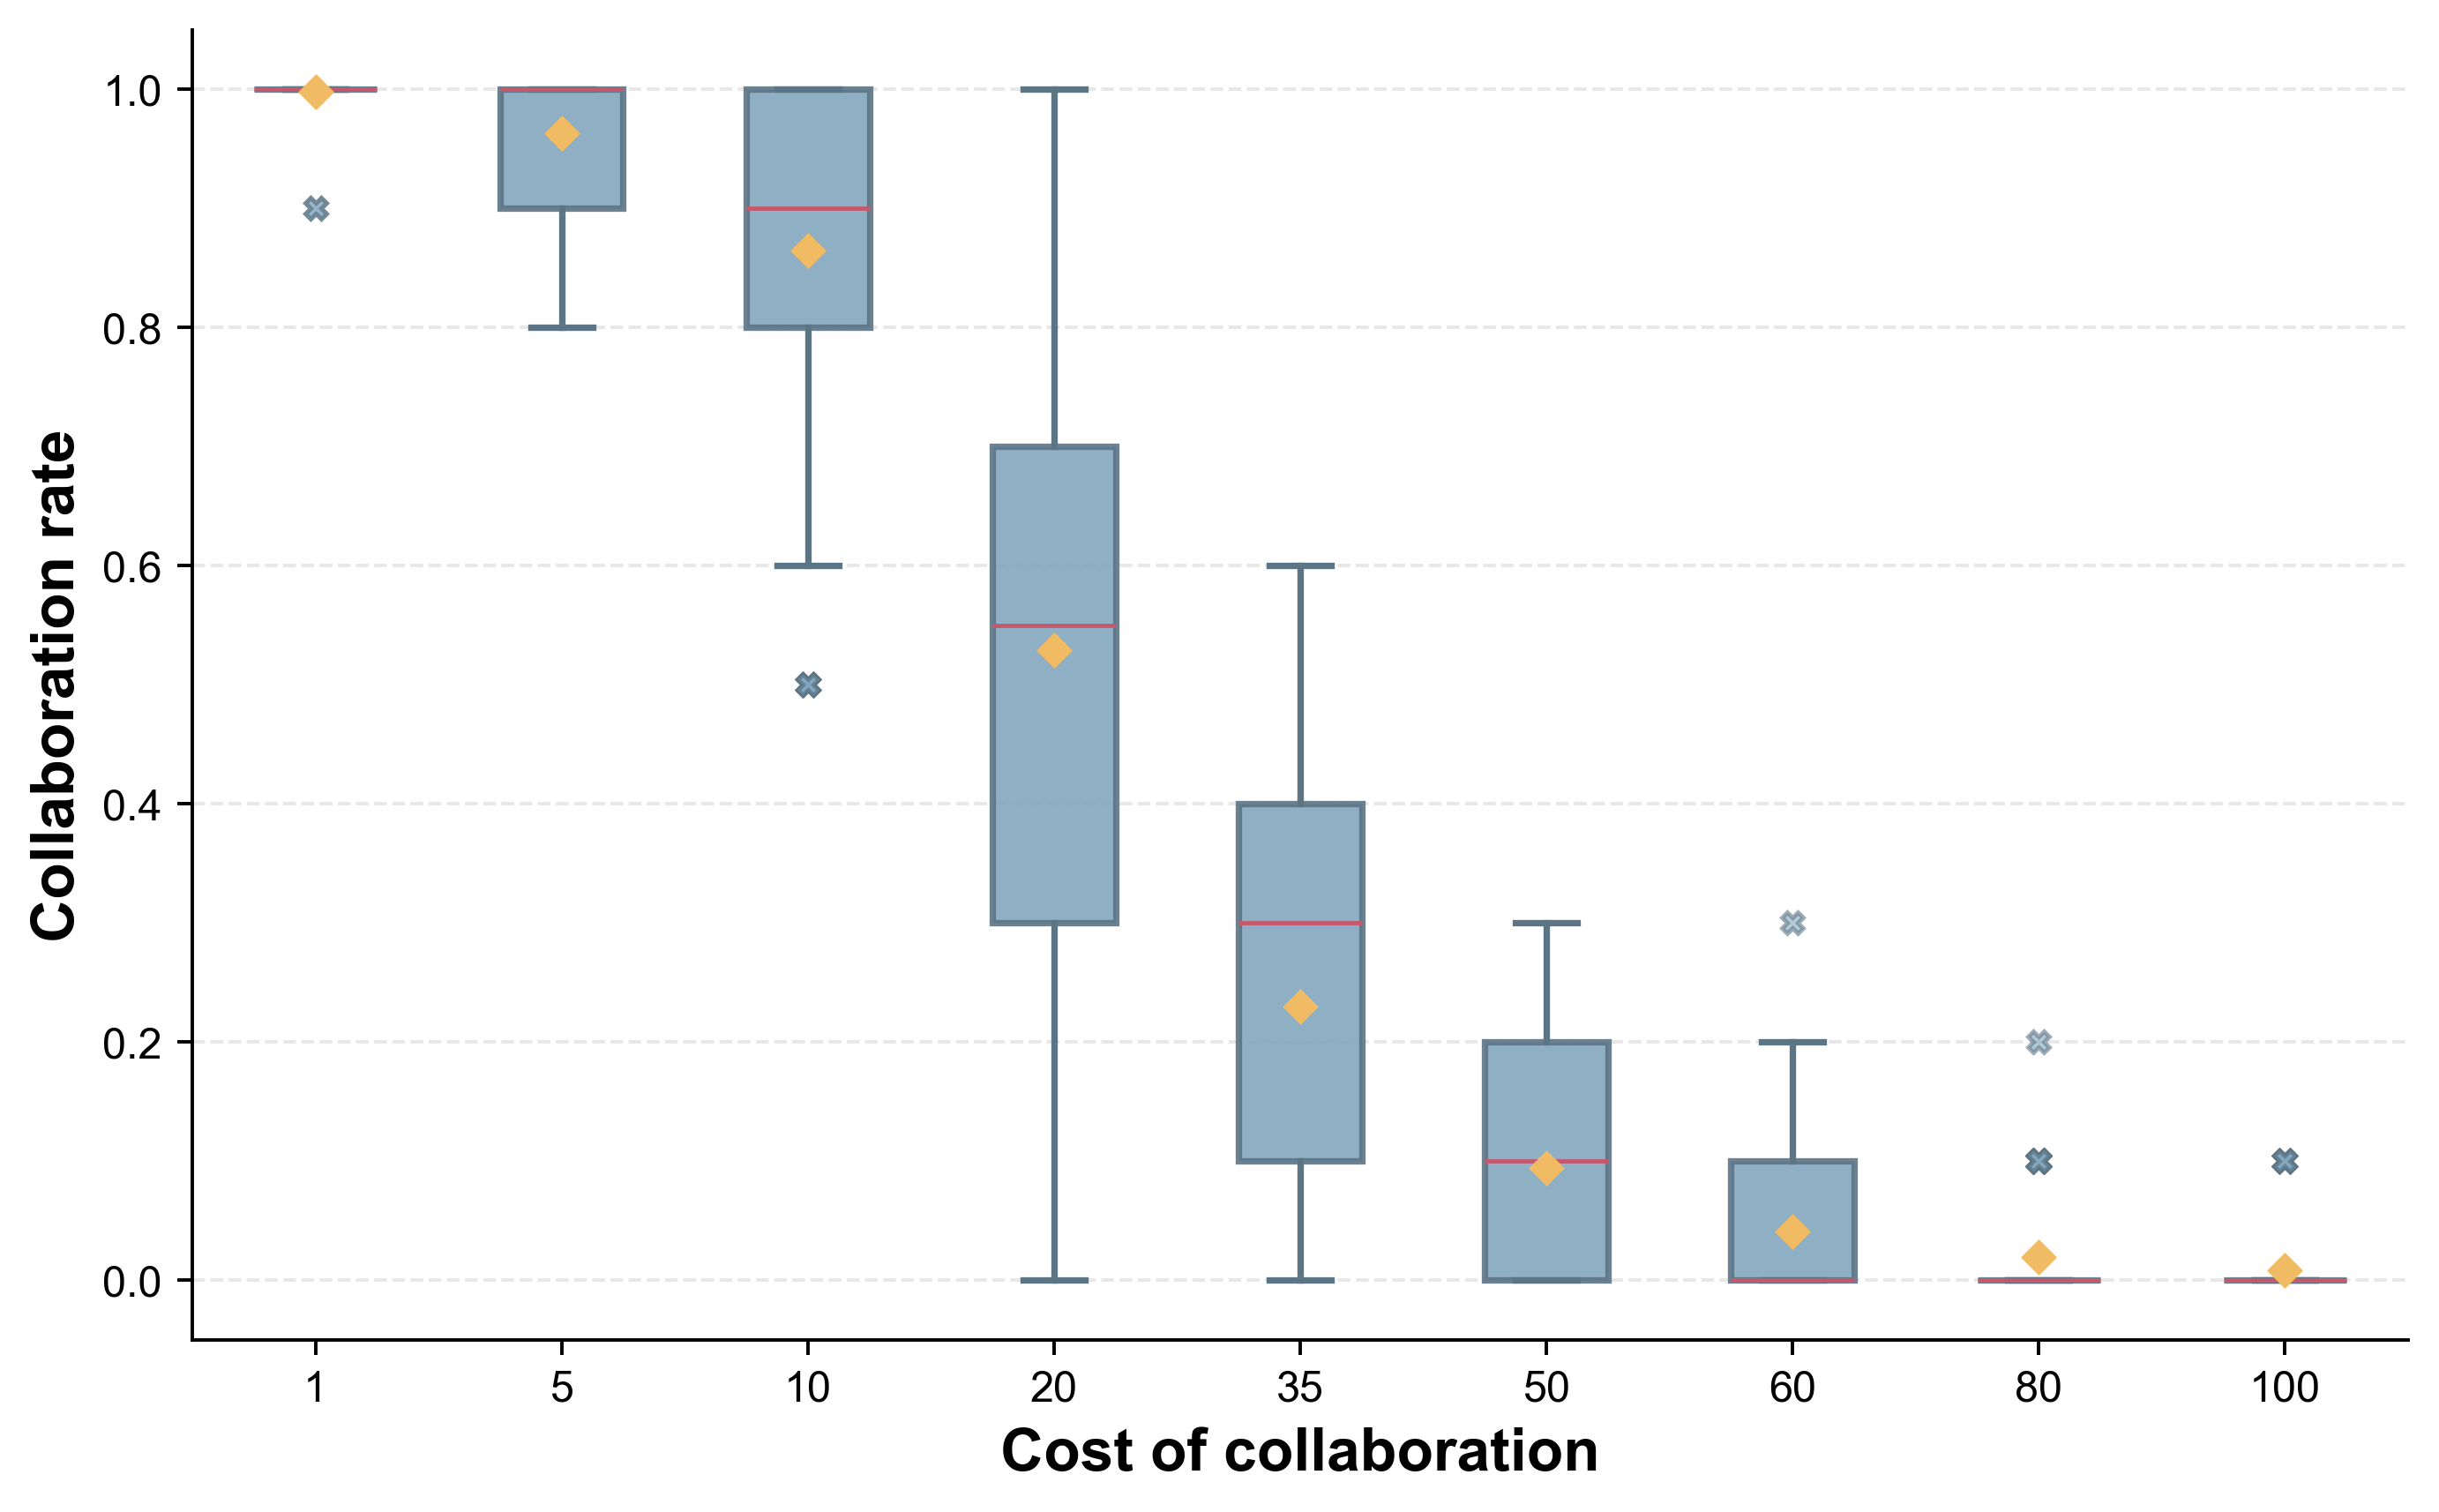

(<Figure size 2800x1750 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Collaboration rate'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d454937880>,
  'caps': [<matplotlib.lines.Line2D at 0x1d454937dc0>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4549374c0>,
  'medians': [<matplotlib.lines.Line2D at 0x1d454970340>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4548d5ed0>,
  'means': [<matplotlib.lines.Line2D at 0x1d4549705e0>,
   <matplotlib.lines.Line2D at 0x1d4549ea5f0>]})

In [270]:
figure_plot.box_plot(
    data_list=all_metrics_af60_random_df,
    cat_col='penalty_std',
    col_name='collaboration_rate',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=1,
    show_mean=True,
    mean_size=5,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Collaboration rate',
    xlabel='Cost of collaboration',
    label_size=14,
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    figure_size=(8, 5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='collaboration_rate_by_penalty_af60_all_random_receivers.png',
)

In [ ]:
figure_plot.box_plot(
    data_list=all_metrics_center_random_df.query("allocation_factor == 0.8"),
    cat_col='penalty_std',
    col_name='collaboration_rate',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=1,
    show_mean=True,
    mean_size=5,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Collaboration rate',
    xlabel='Cost of collaboration (euros/hour)',
    #--- Violin plot ---
    show_violin=True,
    violin_alpha=0.3, 
    violin_width=0.9,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    label_size=13,
    figure_size=(6, 4),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='collaboration_rate_by_penalty_af80_center_random_receivers.png',
)

In [ ]:
figure_plot.box_plot(
    data_list=all_metrics_outside_random_df.query("allocation_factor == 0.8"),
    cat_col='penalty_std',
    col_name='collaboration_rate',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    box_alpha=0.9,
    se_box_color_for_lines=True,
    # Display options
    flier_marker='X',
    median_color="#c4596e",
    median_linewidth=1,
    show_mean=True,
    mean_size=5,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Collaboration rate',
    xlabel='Cost of collaboration (euros/hour)',
    # Show scatter points with jitter
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    #--- Violin plot ---
    show_violin=True,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- Grid ---
    show_grid=True,
    grid_axis='y',
    #---output---
    label_size=13,
    figure_size=(6, 4),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='collaboration_rate_by_penalty_af80_outside_random_receivers.png',
)

In [ ]:
metric_anls.compute_ashmans_d(
    df=all_metrics_center_random_df.query("penalty_std == 20"),
    col_name='collaboration_rate',
)

### Collaboration rate (histogram)
Only plotting those groups with large variance

#### All-af60-p20

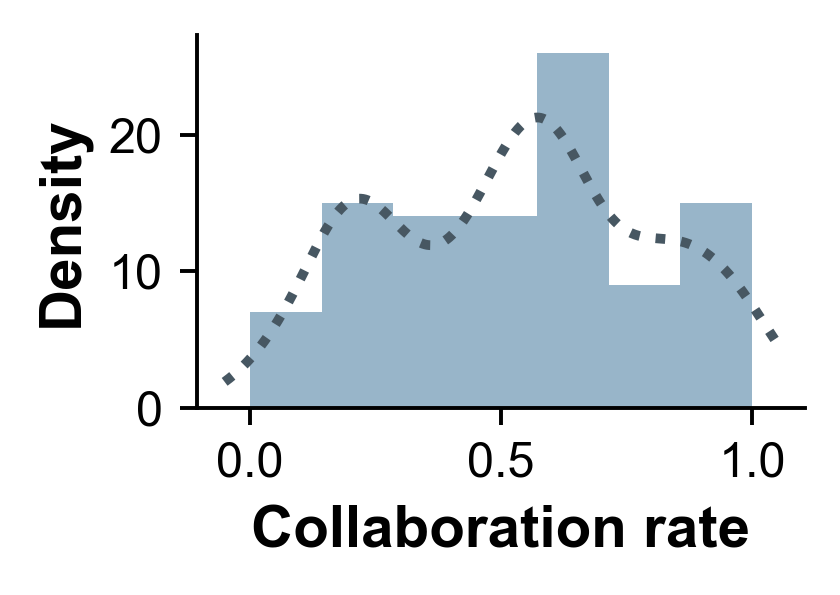

d:\anaconda3\envs\TransAndGeo\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


{'ashmans_d': 2.9910736420480064,
 'mu1': 0.19636415807593188,
 'mu2': 0.6535055206208872,
 'sigma1': 0.0907368775438455,
 'sigma2': 0.19617344552116828,
 'weights': [0.27235671681020485, 0.7276432831897951],
 'is_bimodal': True,
 'interpretation': 'Strong bimodality (two distinct modes)',
 'n_samples': 100}

In [261]:
figure_plot.hist_plot(all_metrics_random_df[(all_metrics_random_df['allocation_factor'] == 0.6) & (all_metrics_random_df['penalty_std'] == 20)],
                      col1='collaboration_rate',
                      n_bins=8,
                      figure_size=(2.5,1.8),
                      ylabel='Density',
                      xlabel='Collaboration rate',
                      label_size=12,
                      hide_labels=False,
                      hide_legends=True,
                      alphas=(0.9, 0.9),
                      colors=("#8dadc3", '#f6bdb1'),
                      #---fitting---
                      fitting_method='kde',
                      kde_bw=0.3,
                      figure_folder=OUTPUT_FIG_PATH,  
                      filename='collab_rate_distribution_all_random_af60_p20euro.png'
                      )
metric_anls.compute_ashmans_d(
    df=all_metrics_random_df[(all_metrics_random_df['allocation_factor'] == 0.6) & (all_metrics_random_df['penalty_std'] == 20)],
    col_name='collaboration_rate',
)

#### All-af60-p35

d:\anaconda3\envs\TransAndGeo\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


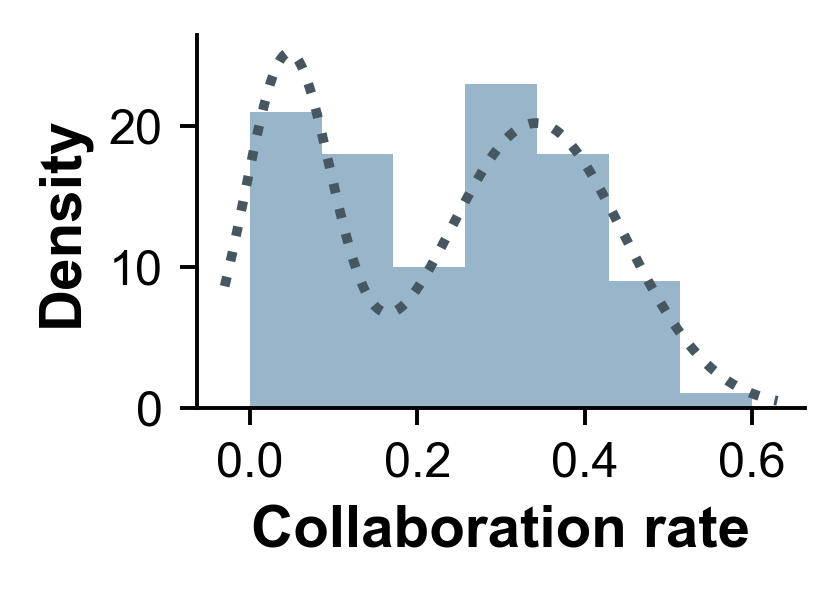

In [262]:
figure_plot.hist_plot(all_metrics_random_df[(all_metrics_random_df['allocation_factor'] == 0.6) & (all_metrics_random_df['penalty_std'] == 35)],
                      col1='collaboration_rate',
                      n_bins=8,
                      figure_size=(2.5,1.8),
                      ylabel='Density',
                      xlabel='Collaboration rate',
                      label_size=12,
                      hide_labels=False,
                      hide_legends=True,
                      alphas=(0.9, 0.9),
                      colors=("#8dadc3", '#f6bdb1'),
                      #---fitting---
                      fitting_method='gmm',
                      figure_folder=OUTPUT_FIG_PATH,  
                      filename='collab_rate_distribution_all_random_af60_p35euro.png'
                      )

#### All-af60-p50

In [ ]:
figure_plot.hist_plot(all_metrics_random_df[
    (all_metrics_random_df['allocation_factor'] == 0.6) & 
    (all_metrics_random_df['penalty_std'] == 50)
    ],
                      col1='collaboration_rate',
                      n_bins=5,
                      figure_size=(3.5,2.7),
                      ylabel='Density',
                      xlabel='Collaboration rate',
                      label_size=10,
                      hide_labels=False,
                      hide_legends=True,
                      alphas=(0.9, 0.9),
                      colors=("#8dadc3", '#f6bdb1'),
                      #---fitting---
                      fitting_method='kde',
                      figure_folder=OUTPUT_FIG_PATH,  
                      filename='collab_rate_distribution_all_random_af60_p50euro.png'
                      )

### Total cost savings

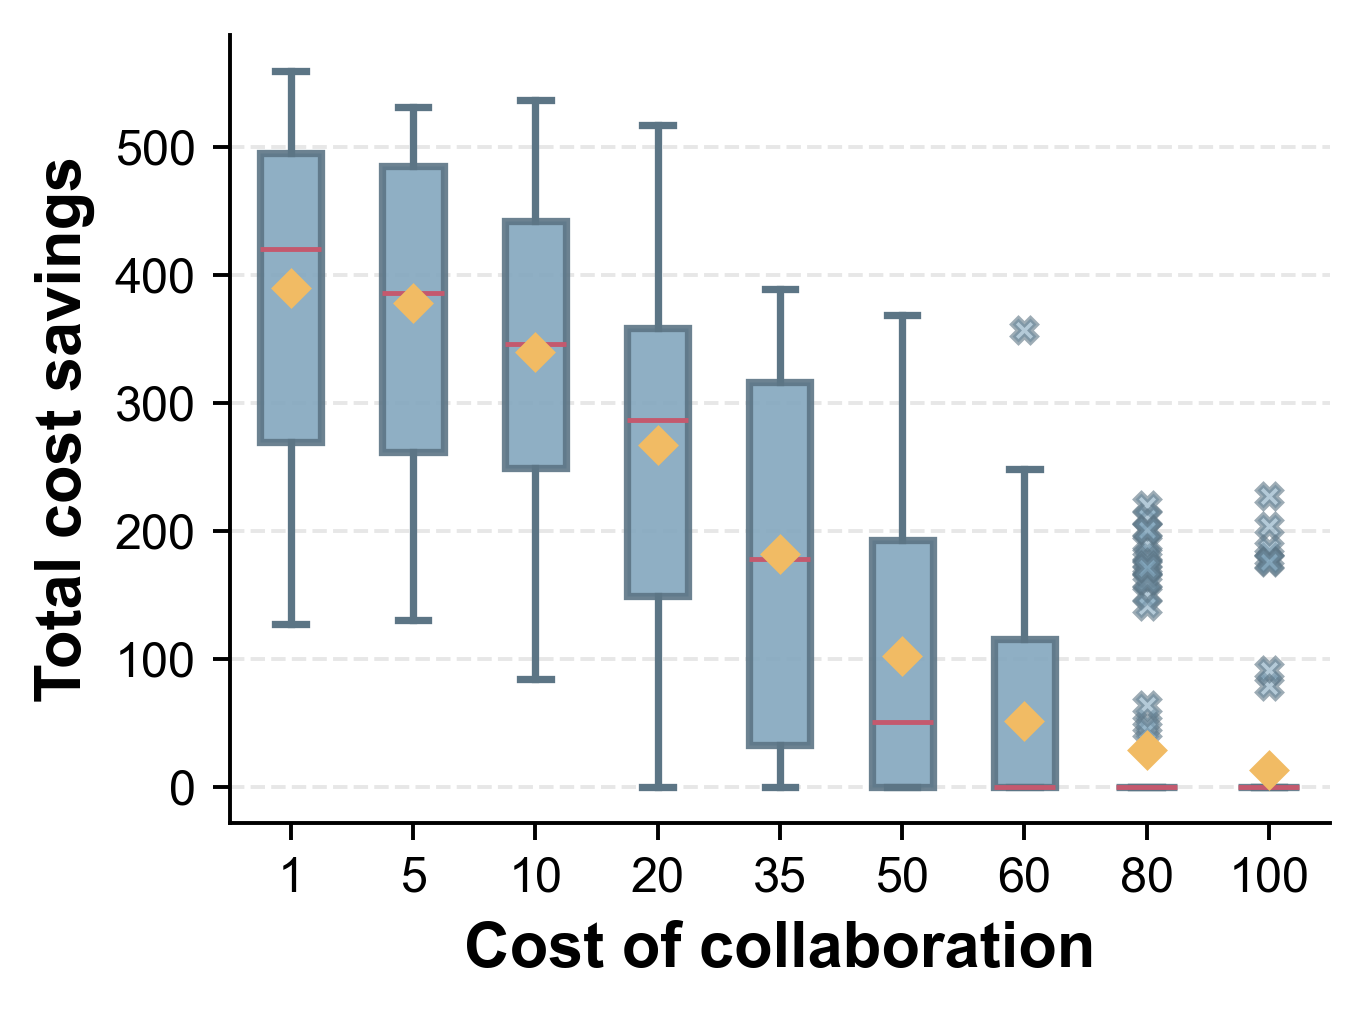

(<Figure size 1400x1050 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Total cost savings'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d454c3b6a0>,
  'caps': [<matplotlib.lines.Line2D at 0x1d454c3bbe0>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d454c3b2e0>,
  'medians': [<matplotlib.lines.Line2D at 0x1d454c64160>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d454c646a0>,
  'means': [<matplotlib.lines.Line2D at 0x1d454c64400>,
   <matplotlib.lines.Line2D at 0x1d454bff760>]})

In [273]:
figure_plot.box_plot(
    data_list=all_metrics_af60_random_df,
    cat_col='penalty_std',
    col_name='total_cost_savings',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=1,
    show_mean=True,
    mean_size=5,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Total cost savings',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    label_size=13,
    figure_size=(4, 3),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='total_cost_savings_by_penalty_af60_all_random_receivers.png',
)

In [ ]:
all_metrics_random_df.query("allocation_factor == 0.8").plot.scatter(x='penalty_std', y='total_cost_savings')

### fleet size

f:\gitRepository\matsim-libs-2024\python\test\figure_plot.py:1578: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby('bin').size()


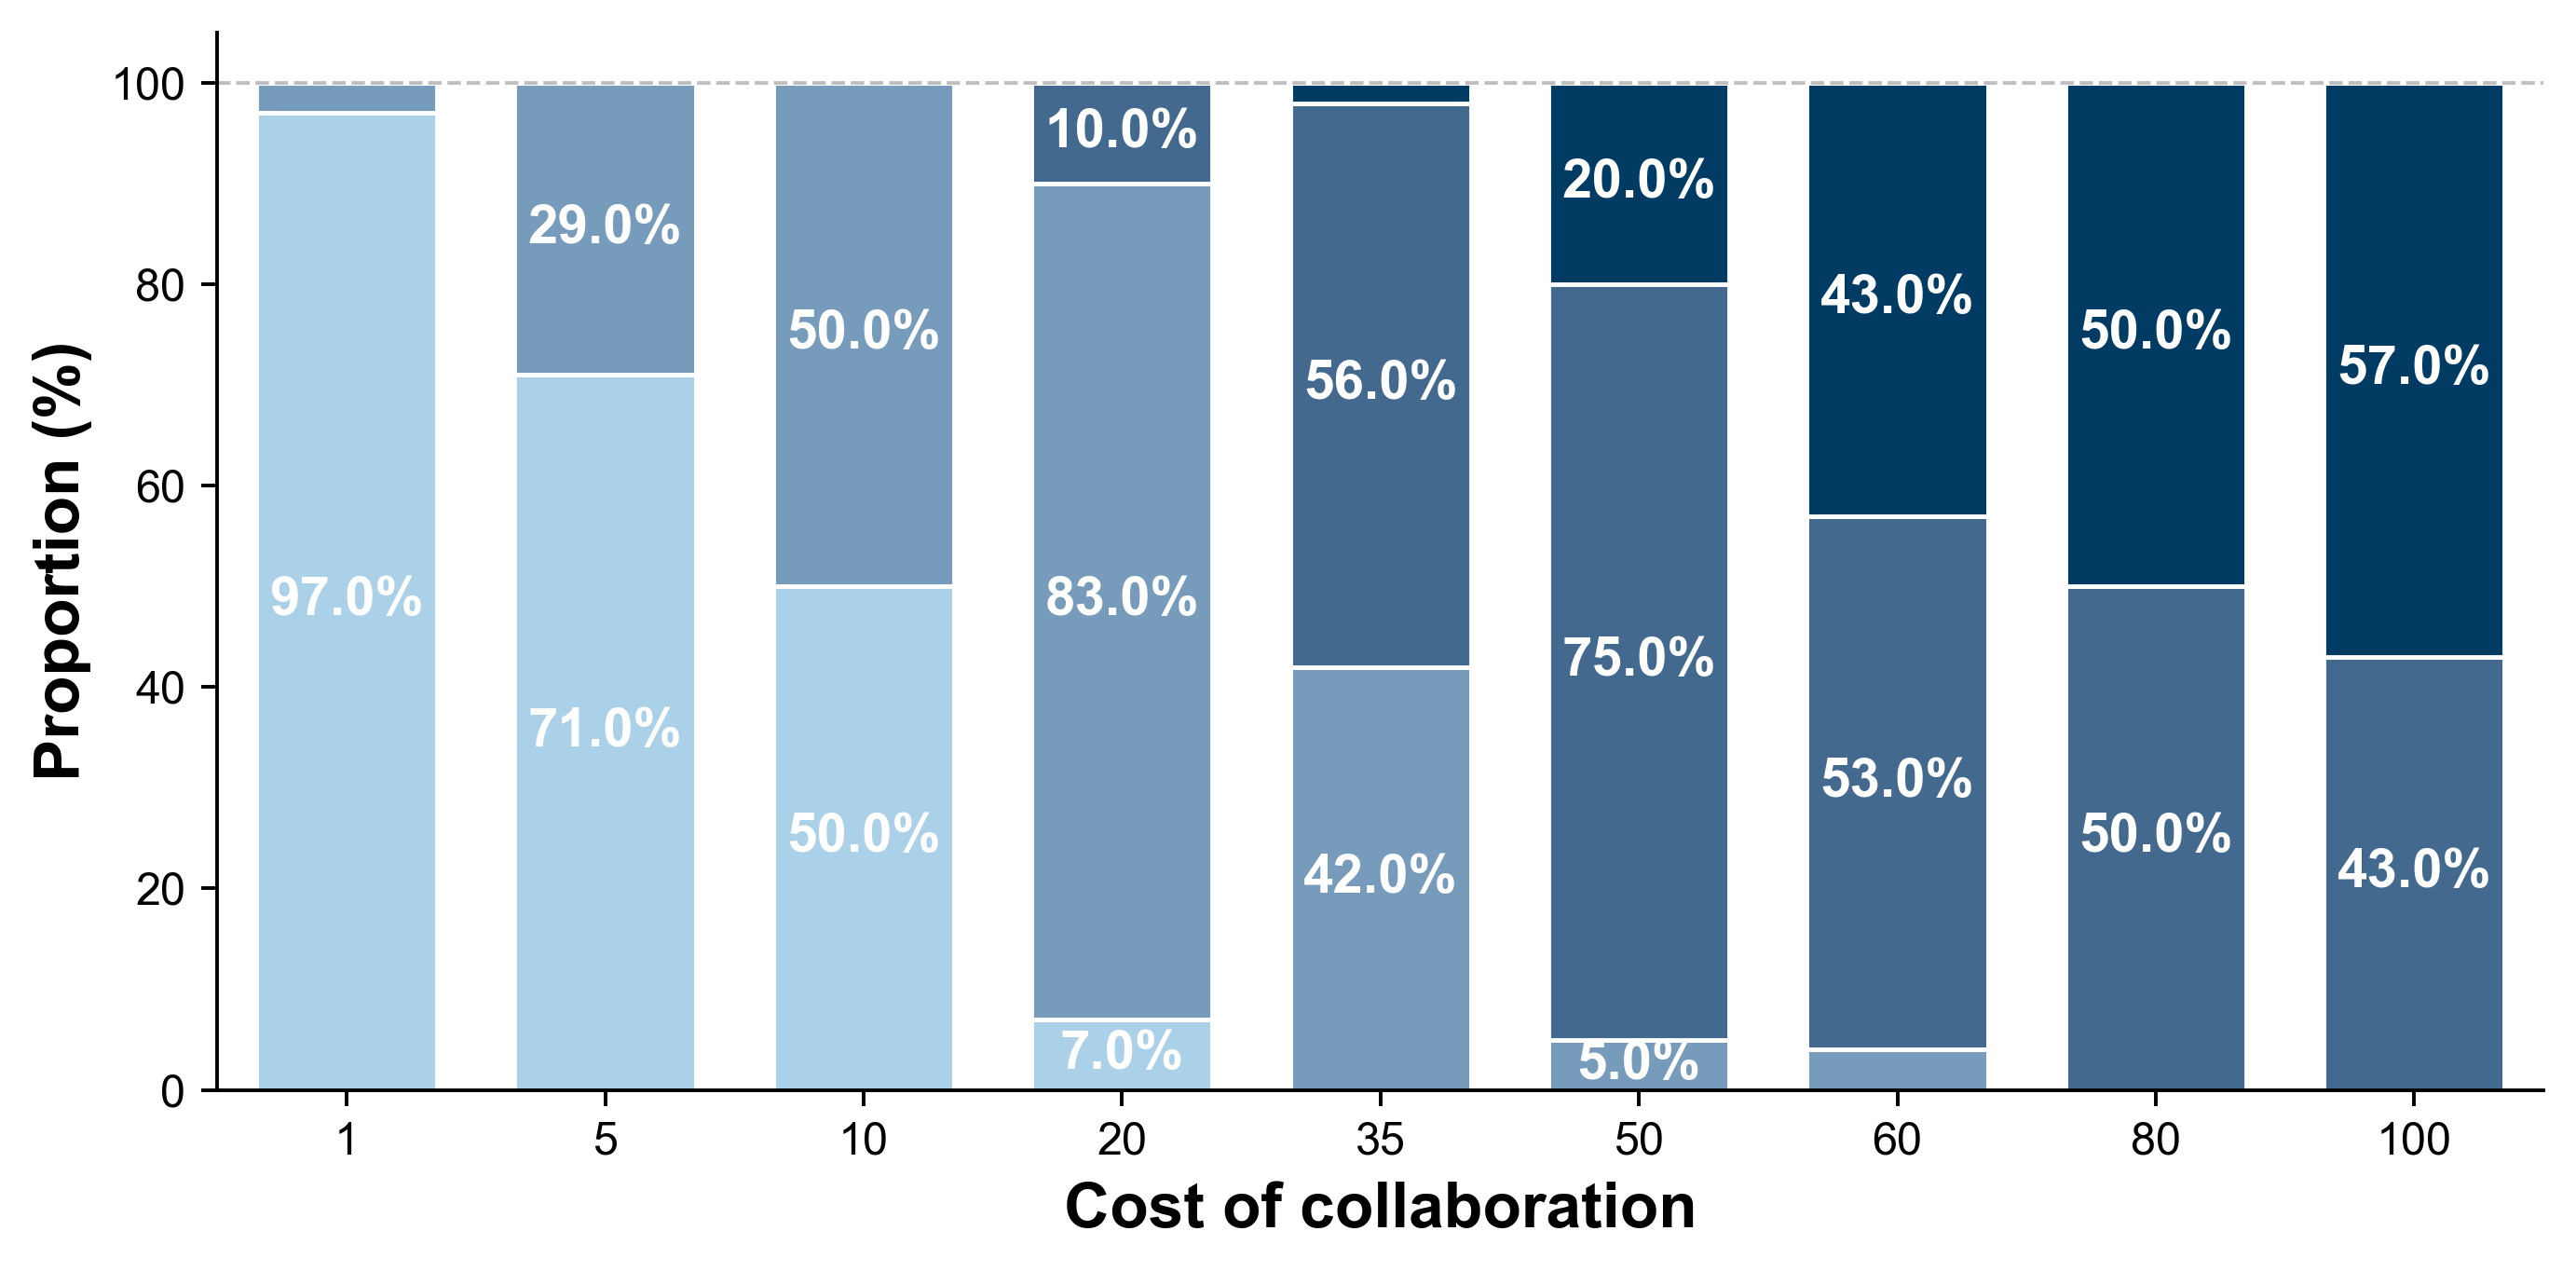

(<Figure size 2800x1400 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Proportion (%)'>,
 final_fleet_size   2.0   3.0   4.0   5.0  count
 penalty_std_bin                                
 1                 97.0   3.0   0.0   0.0    100
 5                 71.0  29.0   0.0   0.0    100
 10                50.0  50.0   0.0   0.0    100
 20                 7.0  83.0  10.0   0.0    100
 35                 0.0  42.0  56.0   2.0    100
 50                 0.0   5.0  75.0  20.0    100
 60                 0.0   4.0  53.0  43.0    100
 80                 0.0   0.0  50.0  50.0    100
 100                0.0   0.0  43.0  57.0    100)

In [272]:
_df = all_metrics_af60_random_df.query("allocation_factor == 0.6")
_df['diff_fleet_size'] = _df['diff_fleet_size'].map(lambda x: 0 if x >=1 else x)  # Map all values >= 1 to 0, keep others unchanged
_df['diff_fleet_size'] = _df['diff_fleet_size'] * -1

_colors = figure_plot.generate_smooth_colors(
    input_colors=["#abd1e9", "#003b64"],
    n_req_colors=4
)
figure_plot.stacked_proportion_plot(_df,
                                    figure_size=(8,4),
                                    dpi=350,
                                     bin_col='penalty_std',
                                     value_col='final_fleet_size',
                                    # n_bins=5,
                                     bin_method='unique',
                                    #  custom_bins=[0.4, 0.6, 0.8, 1.0],
                                    #  colors=['#757575',"#abd1e9", "#458CBC", 
                                    #         #  "#005681DF",
                                    #          "#003b64"],
                                     colors=_colors,
                                     xlabel='Cost of collaboration',
                                     ylabel='Proportion (%)',
                                     label_size=14,
                                     show_counts=False,
                                     count_fontsize=12,
                                     percentage_fontsize=12,
                                     # Legend settings
                                     legend_bbox=(0.5, 1.4),
                                     legend_ncol=3,
                                     legend_title='Fleet size',
                                     show_legend=False,
                                     xtick_rotation=0,
                                     xtick_ha='center',
                                     # Output
                                     figure_folder=OUTPUT_FIG_PATH,
                                     filename='all_random_af60_stacked_proportion_fleet_size_vs_penalty.png'
                                     )

### Scores

In [ ]:
_df = all_metrics_random_df.query("allocation_factor == 0.8").groupby('penalty_std')['final_carrier_score'].agg(['mean', 'std', 'count'])
_df.plot.line( y='mean')

### VKT

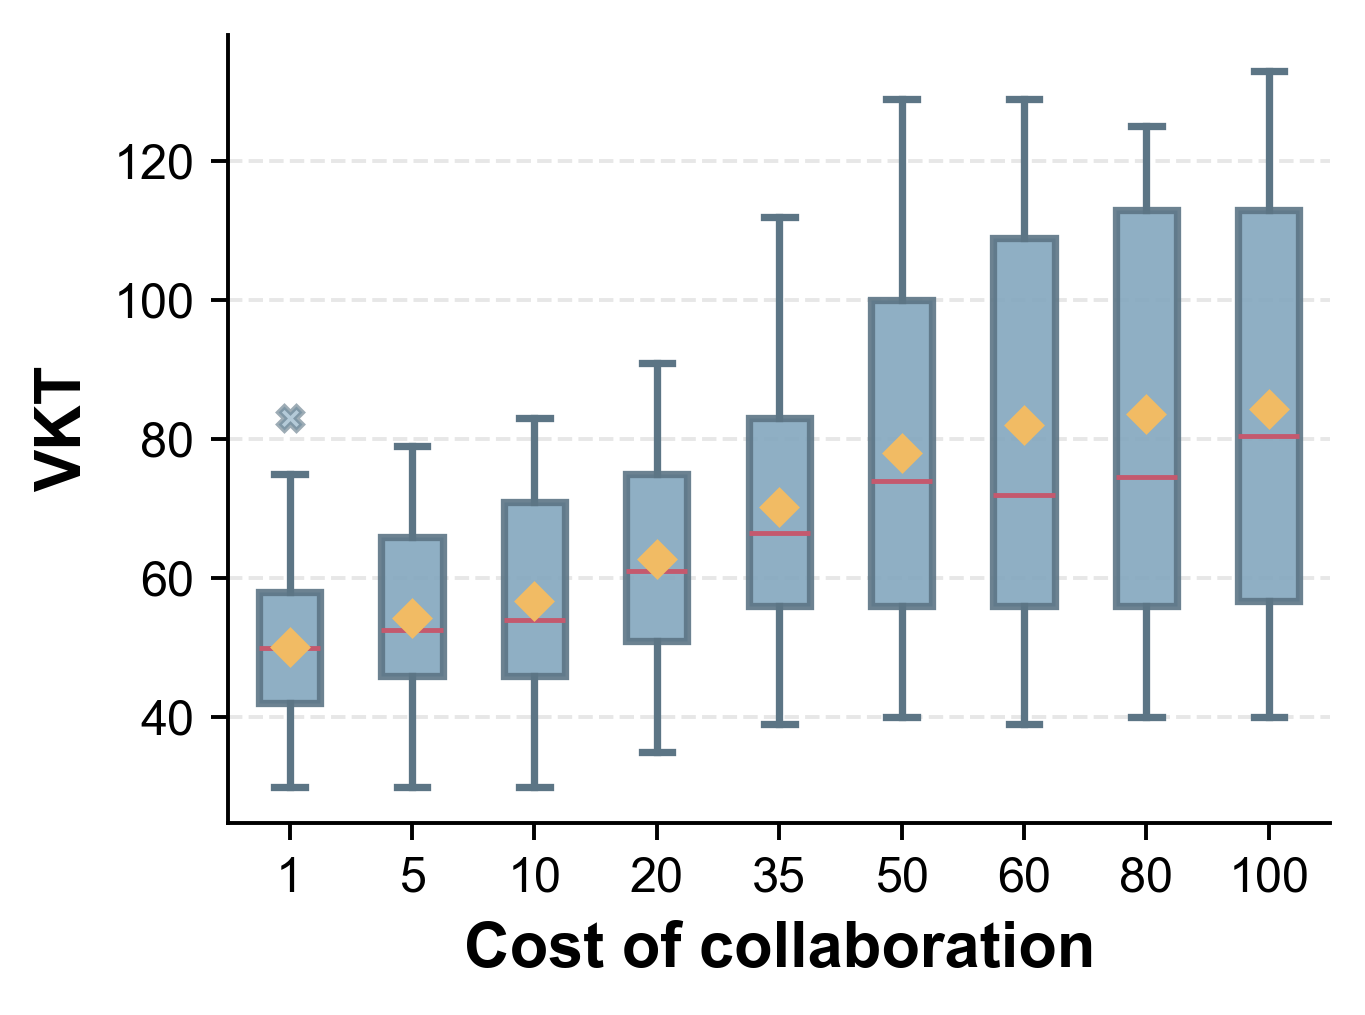

(<Figure size 1400x1050 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='VKT'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d454d63e50>,
  'caps': [<matplotlib.lines.Line2D at 0x1d454d8c3d0>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d454d63a90>,
  'medians': [<matplotlib.lines.Line2D at 0x1d454d8c910>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d454d8ce50>,
  'means': [<matplotlib.lines.Line2D at 0x1d454d8cbb0>,
   <matplotlib.lines.Line2D at 0x1d454e02ad0>]})

In [274]:
figure_plot.box_plot(
    data_list=all_metrics_af60_random_df,
    cat_col='penalty_std',
    col_name='VKT_km',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=1,
    show_mean=True,
    mean_size=5,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='VKT',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    label_size=13,
    figure_size=(4, 3),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='VKT_by_penalty_af60_all_random_receivers.png',
)

### TKT

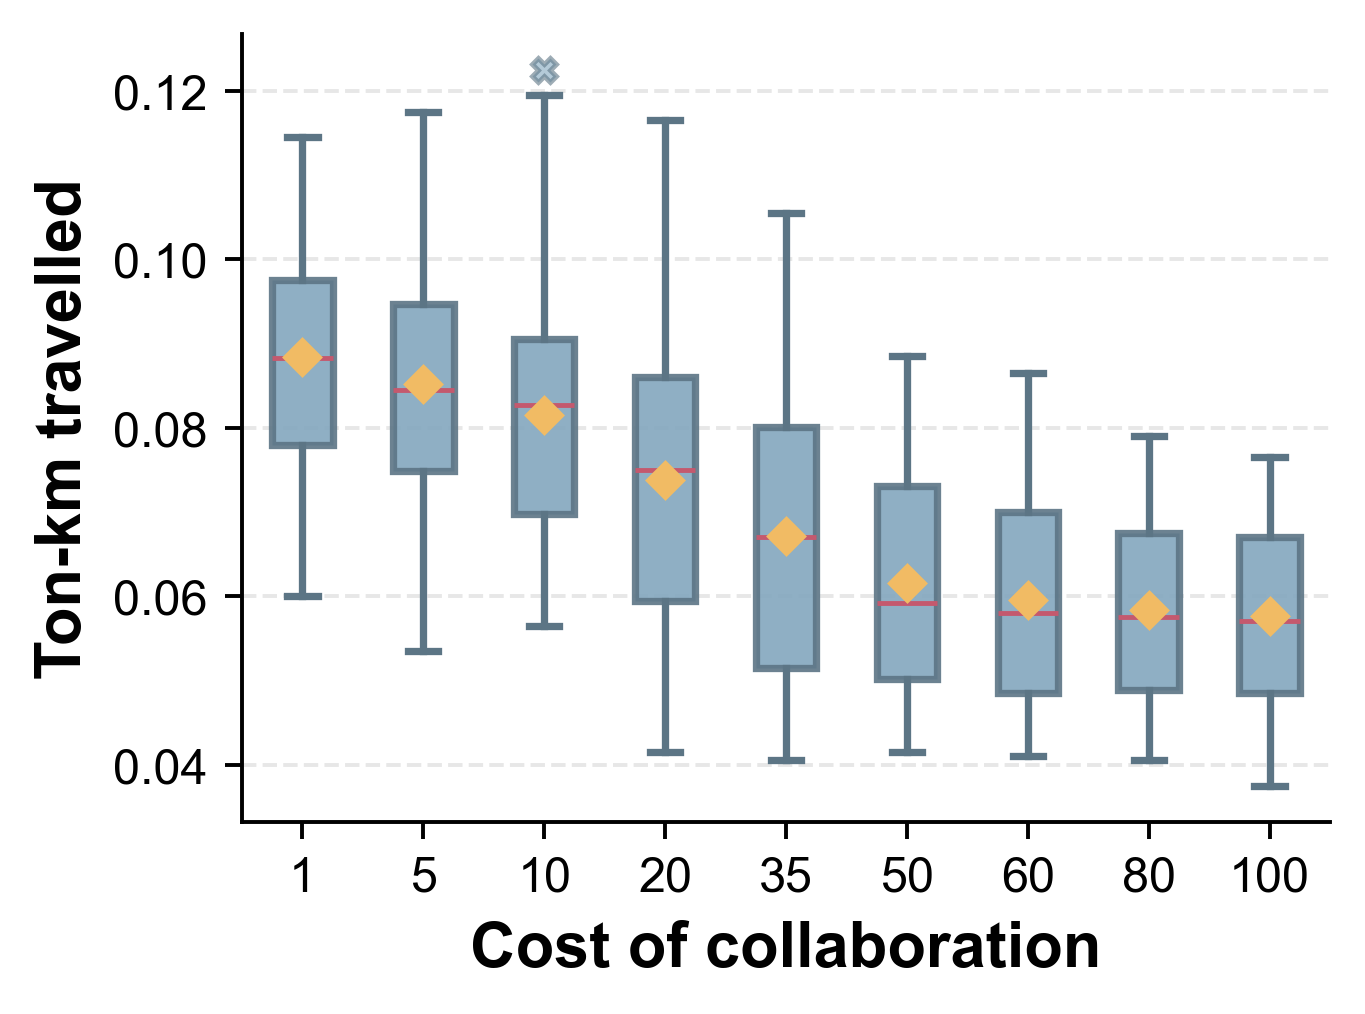

(<Figure size 1400x1050 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Ton-km travelled'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d454eb8550>,
  'caps': [<matplotlib.lines.Line2D at 0x1d454eb8460>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d454eb8190>,
  'medians': [<matplotlib.lines.Line2D at 0x1d454eb89d0>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d454eb8f10>,
  'means': [<matplotlib.lines.Line2D at 0x1d454eb8c70>,
   <matplotlib.lines.Line2D at 0x1d47a247070>]})

In [275]:
_tkt_df = all_metrics_af60_random_df.query("allocation_factor == 0.6")
_tkt_df['TKT_tonkm'] = _tkt_df['TKT_tonkm'] / 1000  # Scale to thousand ton-km

figure_plot.box_plot(
    data_list=_tkt_df,
    cat_col='penalty_std',
    col_name='TKT_tonkm',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=1,
    show_mean=True,
    mean_size=5,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Ton-km travelled',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    label_size=13,
    figure_size=(4, 3),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='TKT_by_penalty_af60_all_random_receivers.png',
)

## Allocation sweep

### Collaboration rate

In [ ]:
figure_plot.box_plot(
    data_list=all_metrics_random_df.query("penalty_std == 20"),
    cat_col='allocation_factor',
    col_name='collaboration_rate',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=1,
    show_mean=True,
    mean_size=5,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Collaboration rate',
    xlabel='Allocation factor',
    #--- Violin plot ---
    show_violin=True,
    violin_alpha=0.3, 
    violin_width=0.9,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    label_size=13,
    figure_size=(6, 4),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    # filename='collaboration_rate_by_penalty_af80_all_random_receivers.png',
)

## Joint-af-pen

In [ ]:
all_metrics_random_df[all_metrics_random_df['penalty_std']>100]

In [67]:
joint_af_pen_df = all_metrics_random_df.copy(deep=True)
joint_af_pen_df = joint_af_pen_df.query("penalty_std >0 and penalty_std <=100")
''' Get rid of the records with penalty_std == 3'''
joint_af_pen_df = joint_af_pen_df.query("penalty_std != 3")

### Heatmap for collab

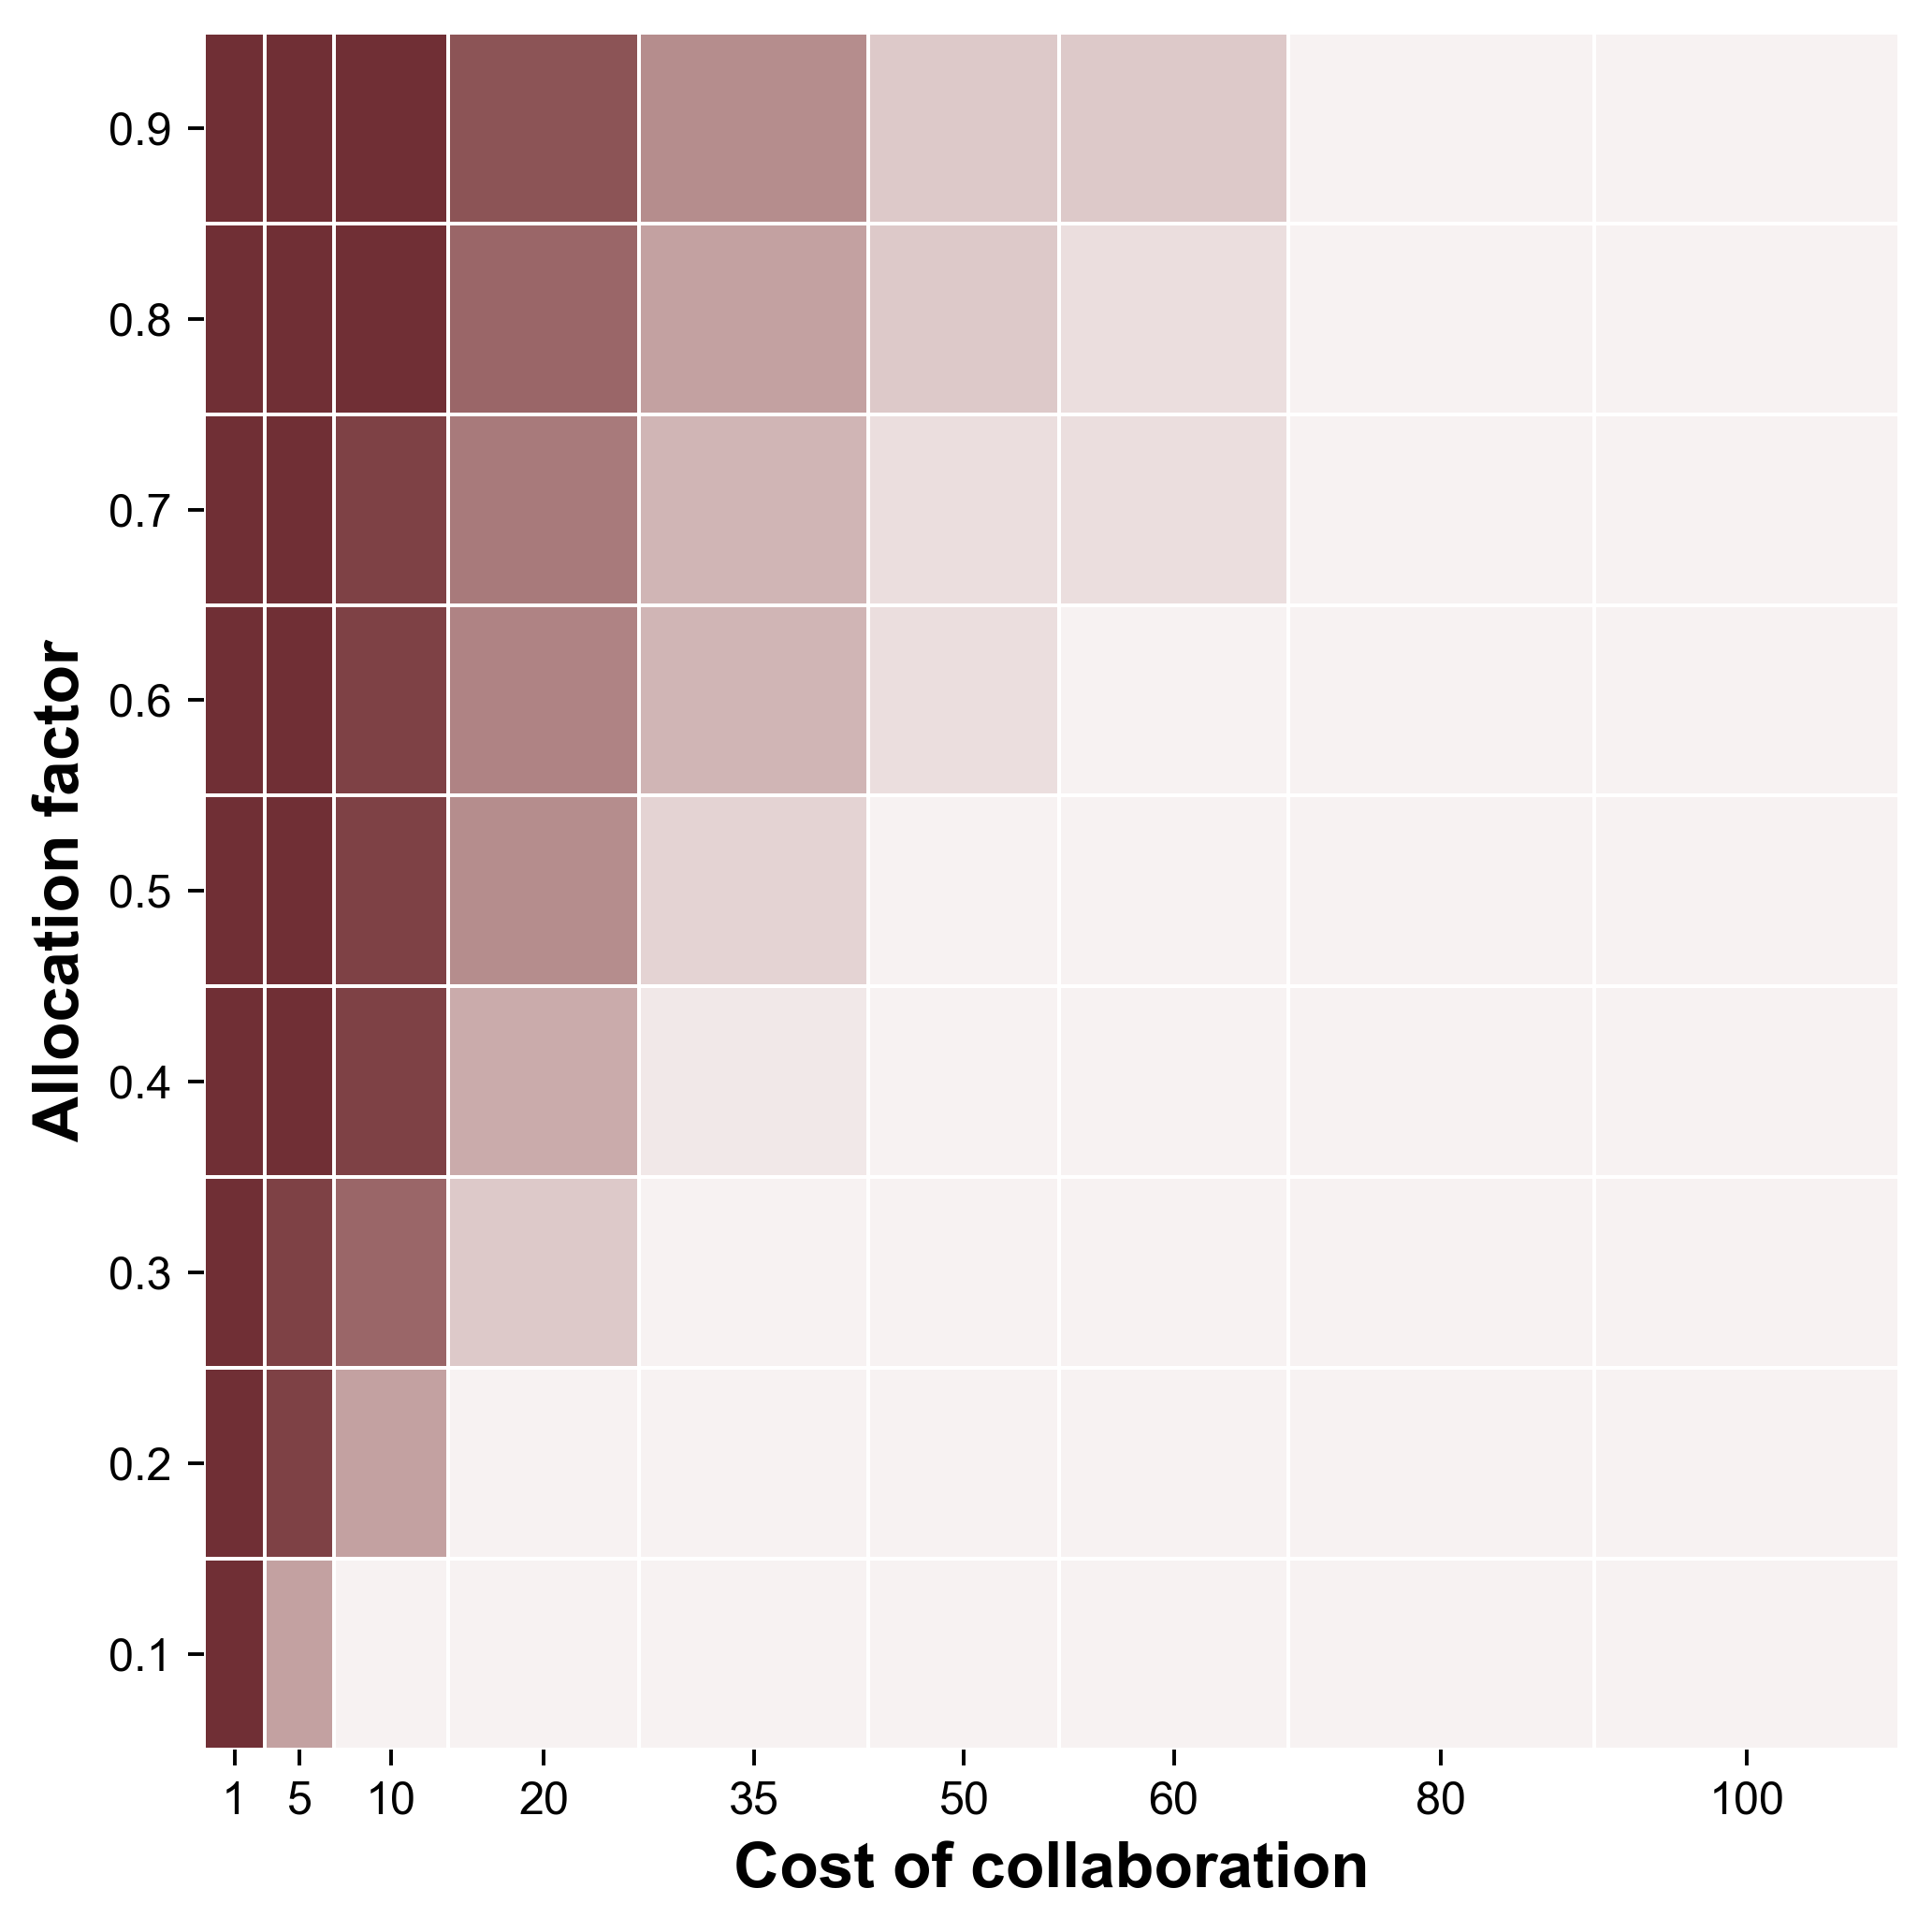

(<Figure size 2100x2100 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Allocation factor'>,
 penalty_std        1    5    10    20    35   50   60   80   100
 allocation_factor                                               
 0.1                1.0  0.4  0.0  0.00  0.00  0.0  0.0  0.0  0.0
 0.2                1.0  0.9  0.4  0.00  0.00  0.0  0.0  0.0  0.0
 0.3                1.0  0.9  0.7  0.20  0.00  0.0  0.0  0.0  0.0
 0.4                1.0  1.0  0.9  0.35  0.05  0.0  0.0  0.0  0.0
 0.5                1.0  1.0  0.9  0.50  0.15  0.0  0.0  0.0  0.0
 0.6                1.0  1.0  0.9  0.55  0.30  0.1  0.0  0.0  0.0
 0.7                1.0  1.0  0.9  0.60  0.30  0.1  0.1  0.0  0.0
 0.8                1.0  1.0  1.0  0.70  0.40  0.2  0.1  0.0  0.0
 0.9                1.0  1.0  1.0  0.80  0.50  0.2  0.2  0.0  0.0)

In [246]:
_colors = figure_plot.generate_smooth_colors(
    input_colors=["#F7F2F2","#702F35"],
    n_req_colors=10
)
figure_plot.heatmap_plot(
    joint_af_pen_df,
    x_col='penalty_std',
    y_col='allocation_factor',
    value_col='collaboration_rate',
    agg_method='median',
    real_scale_x=True,
    cmap=_colors,
    x_tick_decimals=0,
    y_tick_decimals=1,
    # invert_yaxis=True,
    hide_spines=['top', 'bottom', 'left', 'right'],
    # x_tick_rotation=-45,
    #--- Annotation options ---
    annot=False,
    annot_size=12,
    # annot_color='black',
    annot_fmt='.2f',
    xlabel='Cost of collaboration',
    ylabel='Allocation factor',
    label_size=14,
    #--- Output ---
    cbar=False,
    figure_size=(6, 6),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='heatmap_real_scale_collaboration_rate_by_penalty_and_allocation_factor_random_receivers.png',
    # tick_label_map=PENALTY_DICT,
)

### Change rate lines

In [72]:
collab_value_df = all_metrics_random_df.query("penalty_std <=100")
# Get rid of the records with penalty_std == 3
collab_value_df = collab_value_df.query("penalty_std != 3")
collab_value_df = collab_value_df.groupby(['allocation_factor', 'penalty_std'])['collaboration_rate'].mean().unstack()
collab_value_df.fillna(1, inplace=True)  # Fill pen-0 NaN values with 1
collab_value_df

penalty_std,0,1,5,10,20,35,50,60,80,100
allocation_factor,,,,,,,,,,
0.1,1.000,0.9750,0.3825,0.0475,0.0100,0.0000,0.0025,0.005,0.0000,0.0050
0.2,1.000,0.9825,0.7750,0.3200,0.0575,0.0075,0.0025,0.005,0.0000,0.0050
0.3,1.000,0.9950,0.9000,0.6125,0.1650,0.0350,0.0100,0.005,0.0000,0.0075
0.4,1.000,0.9975,0.9475,0.7325,0.3300,0.0700,0.0350,0.020,0.0075,0.0050
0.5,0.999,0.9960,0.9580,0.8030,0.4570,0.1540,0.0540,0.027,0.0170,0.0040
0.6,0.998,0.9980,0.9630,0.8650,0.5290,0.2300,0.0940,0.041,0.0190,0.0080
0.7,0.995,0.9960,0.9750,0.9100,0.5980,0.3140,0.1400,0.074,0.0250,0.0170
0.8,1.000,0.9990,0.9710,0.9340,0.6980,0.3500,0.1950,0.122,0.0570,0.0280
0.9,0.999,0.9990,0.9810,0.9440,0.7490,0.4500,0.2380,0.174,0.0720,0.0380


In [73]:
change_value_df = collab_value_df.shift(1, axis=1) - collab_value_df
change_value_df = change_value_df.iloc[:, 1:]  # Remove the first column which will be NaN after shift
# # change it to percentage change
# change_value_df = change_value_df.apply(lambda x: x / collab_value_df[x.name] * 100)
_list = [0.2, 0.4, 0.6, 0.8]
# _list = [0.1, 0.3, 0.5, 0.7, 0.9]
change_value_df = change_value_df[change_value_df.index.isin(_list)]
change_value_df

penalty_std,1,5,10,20,35,50,60,80,100
allocation_factor,,,,,,,,,
0.2,0.0175,0.2075,0.455,0.2625,0.050,0.005,-0.0025,0.0050,-0.0050
0.4,0.0025,0.0500,0.215,0.4025,0.260,0.035,0.0150,0.0125,0.0025
0.6,0.0000,0.0350,0.098,0.3360,0.299,0.136,0.0530,0.0220,0.0110
0.8,0.0010,0.0280,0.037,0.2360,0.348,0.155,0.0730,0.0650,0.0290


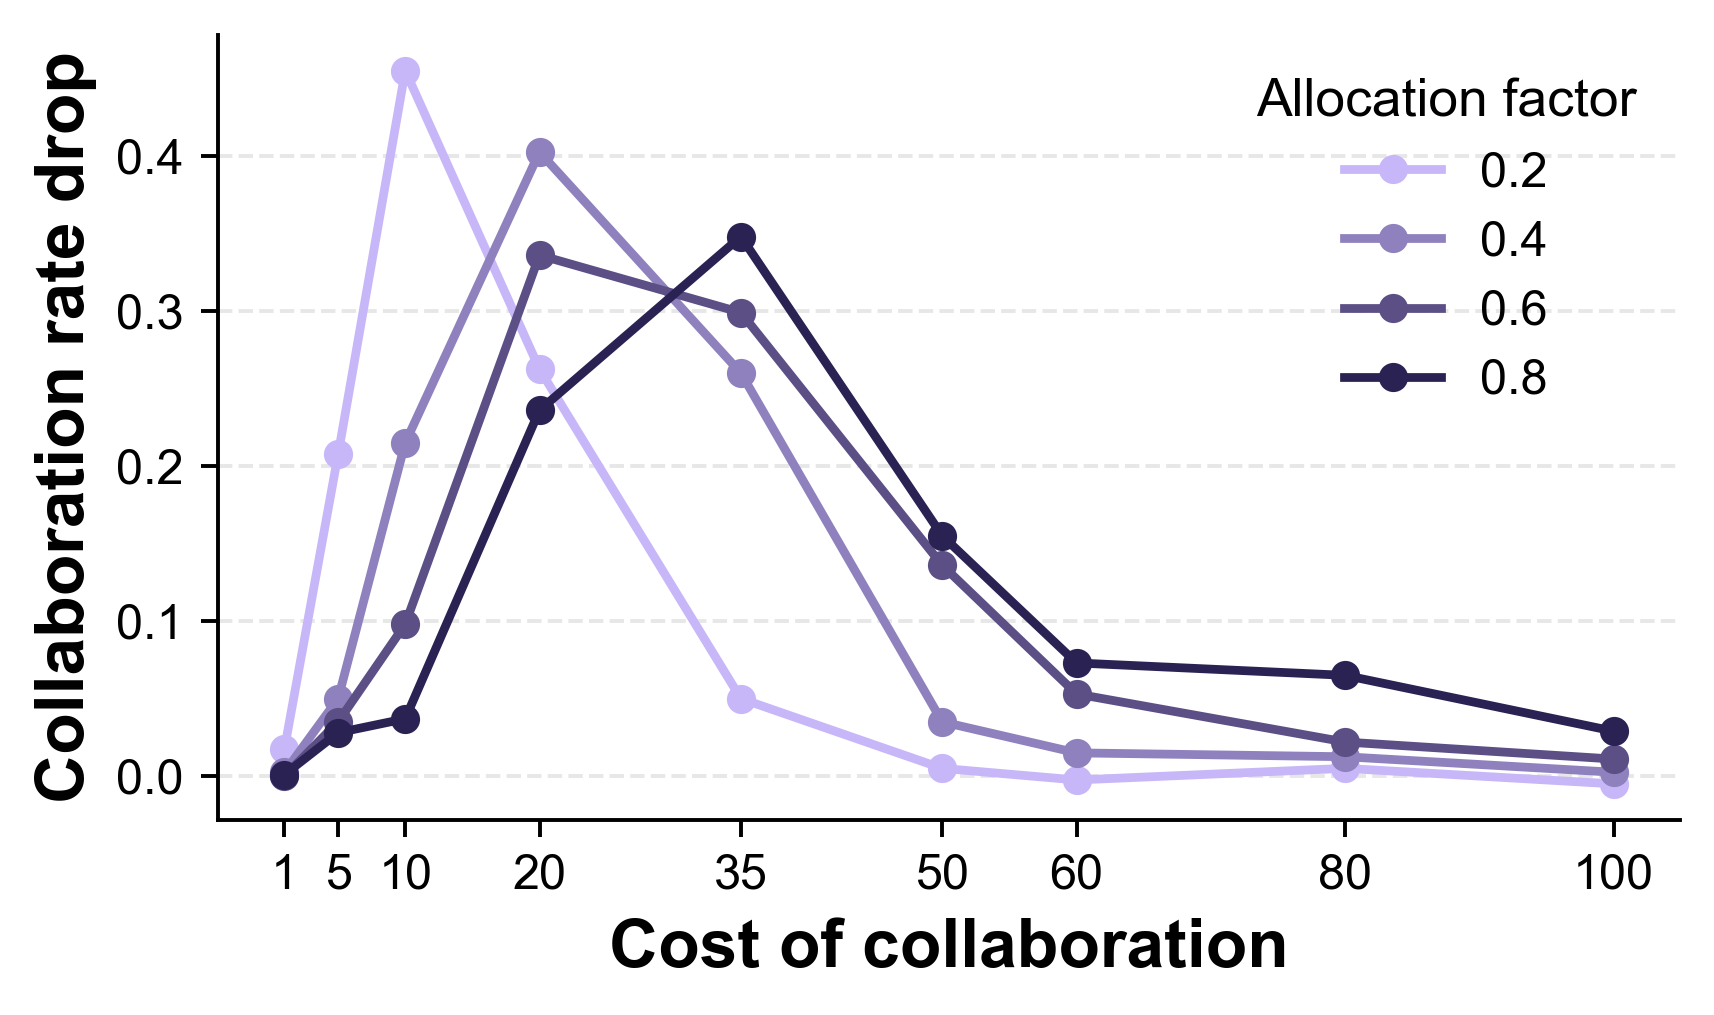

(<Figure size 1750x1050 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Collaboration rate drop'>,
 penalty_std           1       5      10      20     35     50      60   \
 allocation_factor                                                        
 0.2                0.0175  0.2075  0.455  0.2625  0.050  0.005 -0.0025   
 0.4                0.0025  0.0500  0.215  0.4025  0.260  0.035  0.0150   
 0.6                0.0000  0.0350  0.098  0.3360  0.299  0.136  0.0530   
 0.8                0.0010  0.0280  0.037  0.2360  0.348  0.155  0.0730   
 
 penalty_std           80      100  
 allocation_factor                  
 0.2                0.0050 -0.0050  
 0.4                0.0125  0.0025  
 0.6                0.0220  0.0110  
 0.8                0.0650  0.0290  )

In [76]:
''' Plot the lines for each allocation factor-penalty change'''
_colors= figure_plot.generate_smooth_colors(
    input_colors=["#C7B7F8","#292252"],  # #463A8B
    n_req_colors=change_value_df.shape[0]
)
figure_plot.plot_change_rate(
    pivot_df=change_value_df,
    xlabel='Cost of collaboration',
    ylabel='Collaboration rate drop',
    label_size=14,
    legend_title='Allocation factor',
    legend_frameon=False,
    colors=_colors,
    # alpha=0.6,
     #--- Output ---
    show_legend=True,
    figure_size=(5, 3),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='change_rate_collaboration_rate_by_penalty_random_receivers.png',
)


In [ ]:
sns.color_palette("tab20c")

In [77]:
collab_value_df = all_metrics_random_df.query("penalty_std <= 100")
collab_value_df = collab_value_df.query("penalty_std != 3")
collab_value_df = collab_value_df.groupby(['penalty_std', 'allocation_factor',])['collaboration_rate'].mean().unstack()
collab_value_df = collab_value_df.apply(lambda x: round(x,2))
collab_value_df[0.0] = 0
collab_value_df = collab_value_df.sort_index(axis=1) 
change_value_df = collab_value_df - collab_value_df.shift(1, axis=1)
change_value_df = change_value_df.iloc[:, 1:] 
change_value_df = change_value_df.applymap(lambda x: 0 if x <= 0 else x)  # Map all positive changes to 0, keep negative changes unchanged
change_value_df = change_value_df[change_value_df.index.to_series().between(10, 50)]

change_value_df

C:\Users\Xander\AppData\Local\Temp\ipykernel_43464\1619267998.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  change_value_df = change_value_df.applymap(lambda x: 0 if x <= 0 else x)  # Map all positive changes to 0, keep negative changes unchanged


allocation_factor,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
penalty_std,,,,,,,,,
10,0.05,0.27,0.29,0.12,0.07,0.06,0.05,0.02,0.01
20,0.01,0.05,0.10,0.17,0.13,0.07,0.07,0.10,0.05
35,0.00,0.01,0.03,0.03,0.08,0.08,0.08,0.04,0.10
50,0.00,0.00,0.01,0.03,0.01,0.04,0.05,0.06,0.04


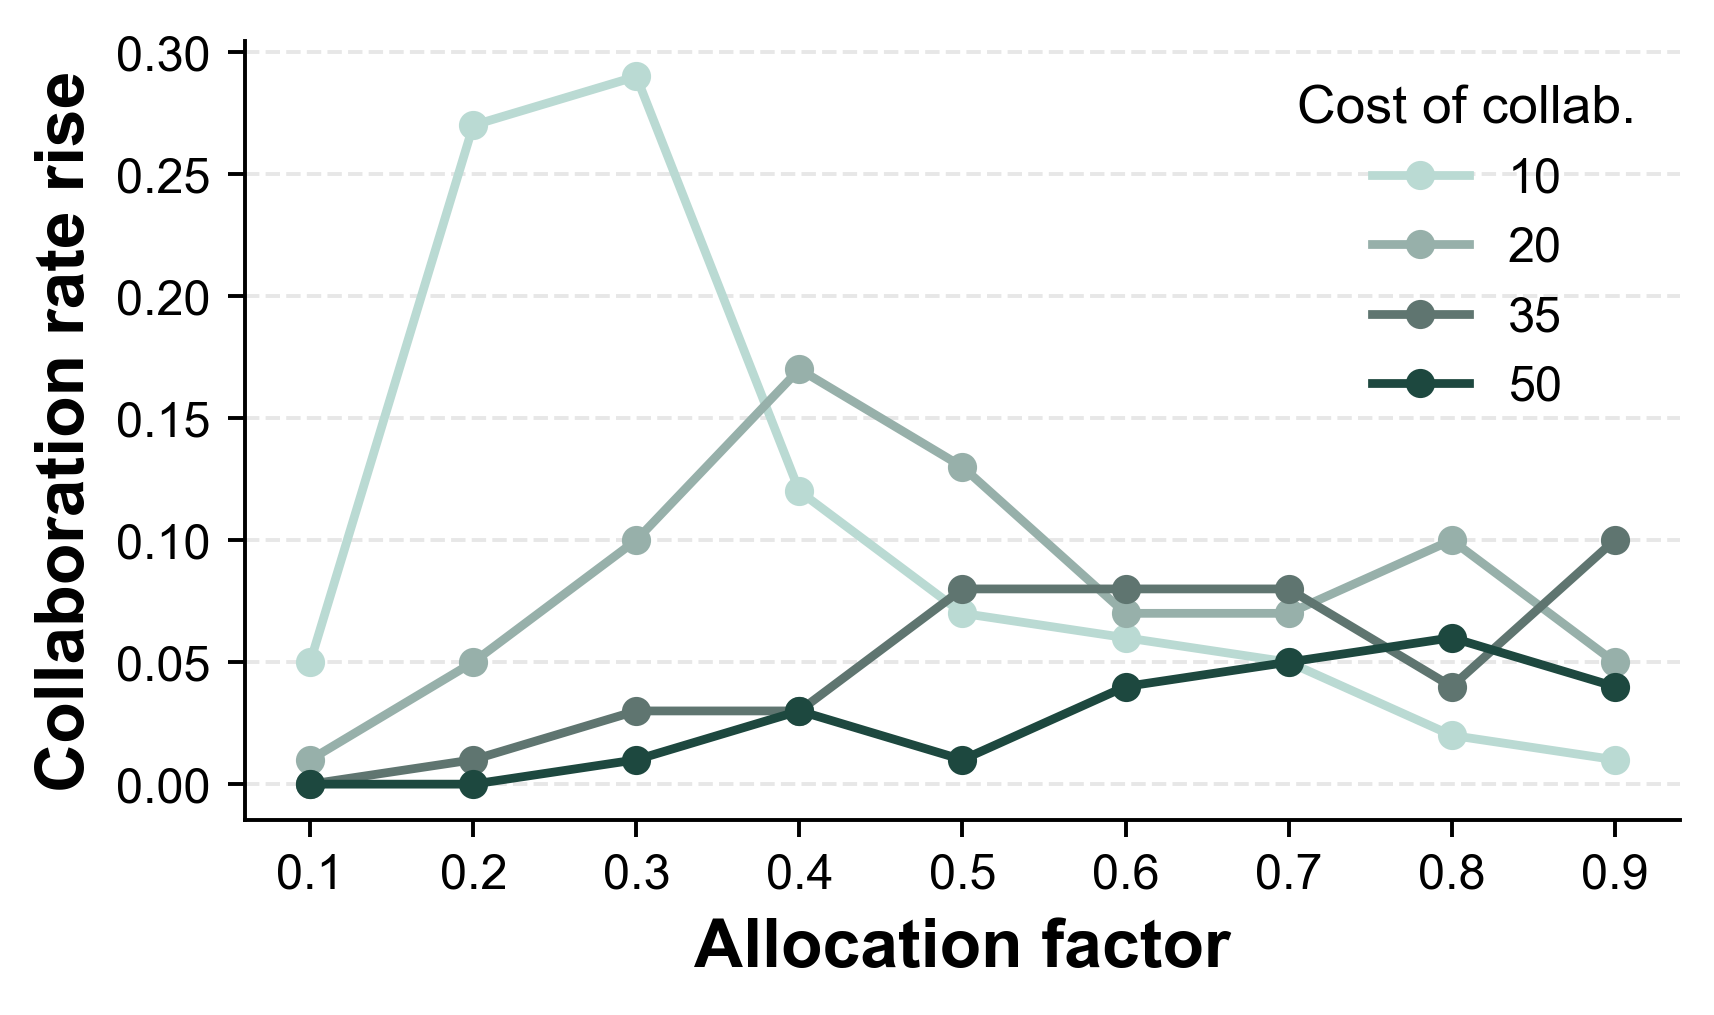

(<Figure size 1750x1050 with 1 Axes>,
 <Axes: xlabel='Allocation factor', ylabel='Collaboration rate rise'>,
 allocation_factor   0.1   0.2   0.3   0.4   0.5   0.6   0.7   0.8   0.9
 penalty_std                                                            
 10                 0.05  0.27  0.29  0.12  0.07  0.06  0.05  0.02  0.01
 20                 0.01  0.05  0.10  0.17  0.13  0.07  0.07  0.10  0.05
 35                 0.00  0.01  0.03  0.03  0.08  0.08  0.08  0.04  0.10
 50                 0.00  0.00  0.01  0.03  0.01  0.04  0.05  0.06  0.04)

In [78]:
_colors = figure_plot.generate_smooth_colors(
    input_colors=["#b6dbe3","#1D483F"],
    n_req_colors=change_value_df.shape[1]
)
_colors = ["#badad3", '#97b0aa', "#5f7570", '#1D483F']
figure_plot.plot_change_rate(
    # data_df=all_metrics_random_df[all_metrics_random_df['penalty_std'].between(10, 60)],
    # group_col='penalty_std',
    # x_col='allocation_factor',
    # value_col='collaboration_rate',
    # agg_method='mean',
    pivot_df=change_value_df,
    xlabel='Allocation factor',
    ylabel='Collaboration rate rise',
    label_size=14,
    legend_title='Cost of collab.',
    legend_frameon=False,
    colors=_colors,
    #--- Output ---
    # show_legend=False,
    show_legend=True,
    figure_size=(5, 3),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    # filename='change_rate_collaboration_rate_by_allocation_factor_random_receivers.png',
)

### Keep collaboration rate lines

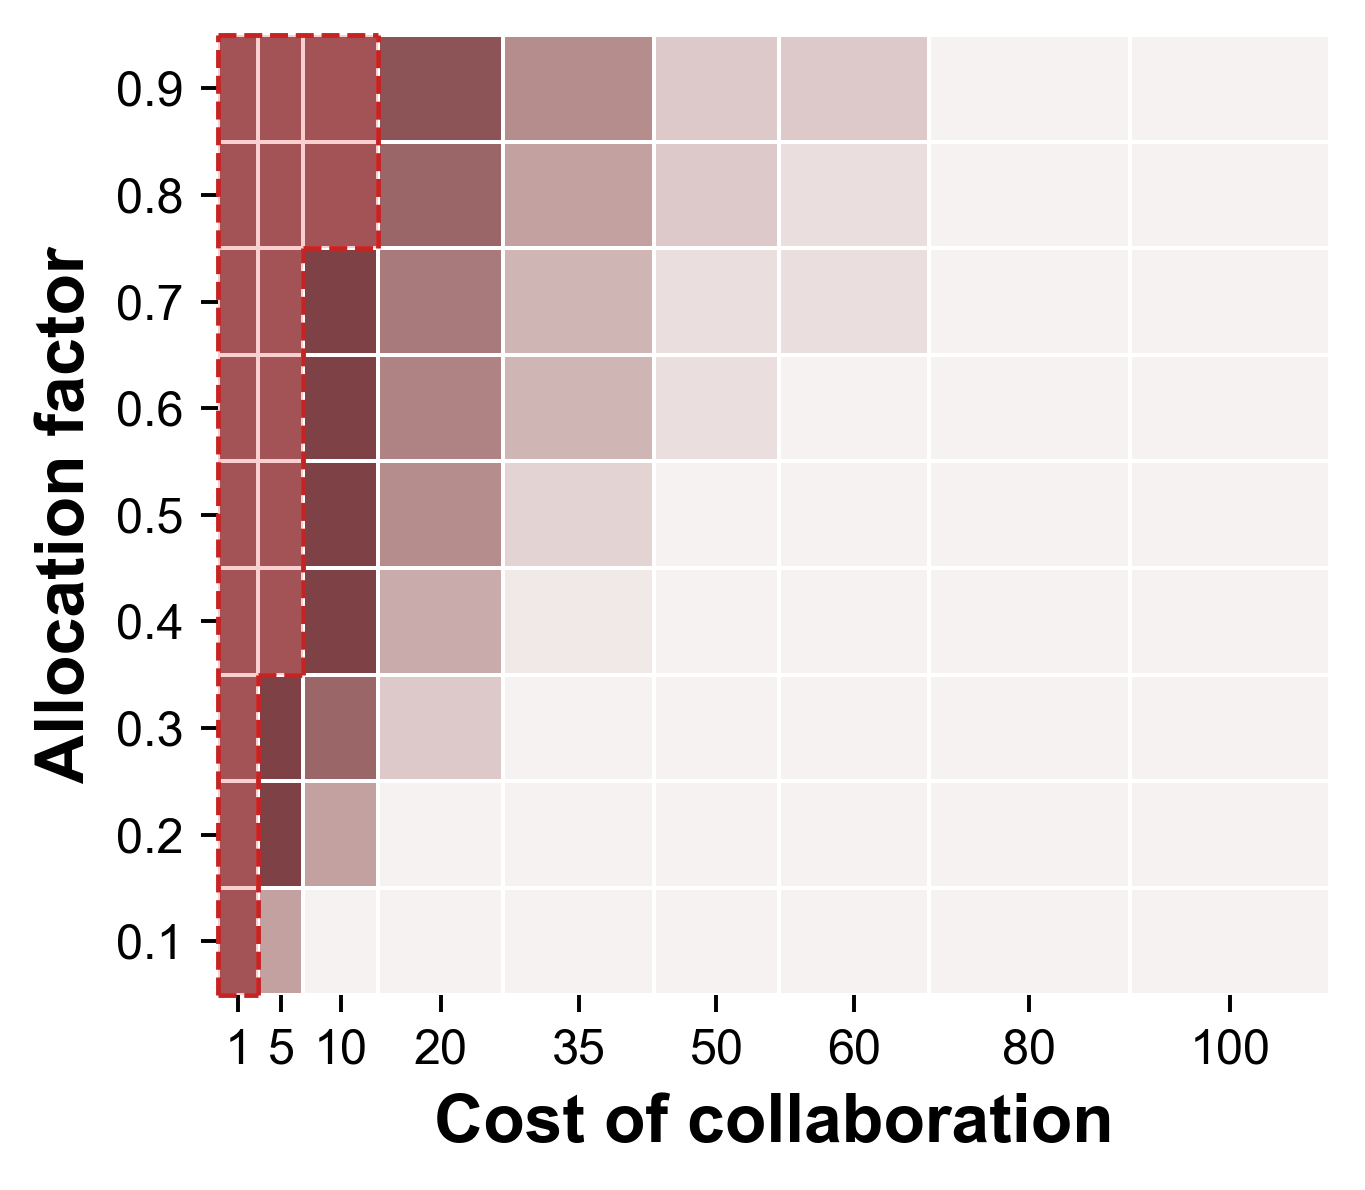

(<Figure size 1400x1225 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Allocation factor'>,
 penalty_std        1    5    10    20    35   50   60   80   100
 allocation_factor                                               
 0.1                1.0  0.4  0.0  0.00  0.00  0.0  0.0  0.0  0.0
 0.2                1.0  0.9  0.4  0.00  0.00  0.0  0.0  0.0  0.0
 0.3                1.0  0.9  0.7  0.20  0.00  0.0  0.0  0.0  0.0
 0.4                1.0  1.0  0.9  0.35  0.05  0.0  0.0  0.0  0.0
 0.5                1.0  1.0  0.9  0.50  0.15  0.0  0.0  0.0  0.0
 0.6                1.0  1.0  0.9  0.55  0.30  0.1  0.0  0.0  0.0
 0.7                1.0  1.0  0.9  0.60  0.30  0.1  0.1  0.0  0.0
 0.8                1.0  1.0  1.0  0.70  0.40  0.2  0.1  0.0  0.0
 0.9                1.0  1.0  1.0  0.80  0.50  0.2  0.2  0.0  0.0)

In [247]:
''' Full collaborate '''
_colors = figure_plot.generate_smooth_colors(
    input_colors=["#F7F2F2","#702F35"],
    n_req_colors=10
)
figure_plot.heatmap_plot(
    joint_af_pen_df,
    x_col='penalty_std',
    y_col='allocation_factor',
    value_col='collaboration_rate',
    agg_method='median',
    annot=False,
    cmap=_colors,
    hide_spines=['top', 'bottom', 'left', 'right'],
    real_scale_x=True,
    x_tick_decimals=0,
    y_tick_decimals=1,
    # x_tick_rotation=-45,
    # tick_size=8,
    # --- Highlight cells with value >= 0.8 ---
    cap_value=0.91,
    cap_edgecolor="#C72323",       # border colour
    cap_linewidth=1,         # border width
    cap_linestyle='--',         # '-', '--', ':', etc.
    cap_compare='>=',          # '>=', '>', '<=', '<', '==', '!='
    # --- cap line ---
    cap_outer_only=True,       # draw only the outer boundary of contiguous highlighted regions
    cap_fill=True,           # optional translucent fill
    cap_fill_color="#F08787",
    cap_fill_alpha=0.4,
    #---output---
    cbar=False,
    xlabel='Cost of collaboration',
    ylabel='Allocation factor',
    label_size=14,
    figure_size=(4, 3.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='heatmap_real_scale_collaboration_rate_by_penalty_and_allocation_factor_random_receivers_with_highlight_greater1.png',

)

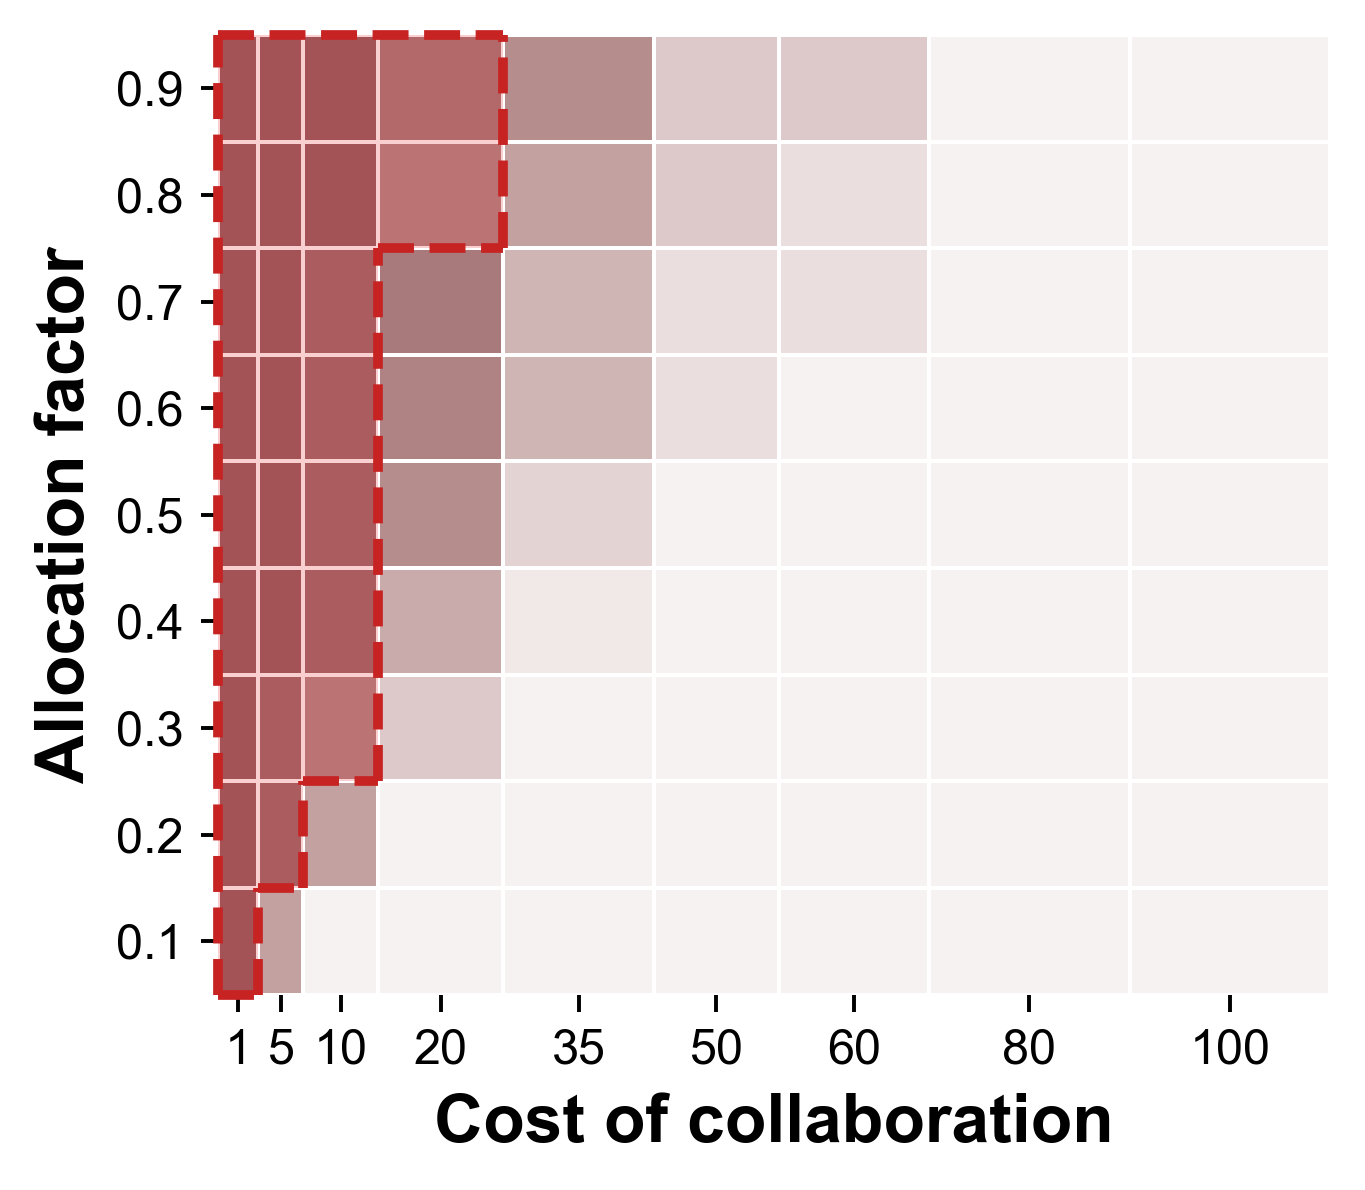

(<Figure size 1400x1225 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Allocation factor'>,
 penalty_std        1    5    10    20    35   50   60   80   100
 allocation_factor                                               
 0.1                1.0  0.4  0.0  0.00  0.00  0.0  0.0  0.0  0.0
 0.2                1.0  0.9  0.4  0.00  0.00  0.0  0.0  0.0  0.0
 0.3                1.0  0.9  0.7  0.20  0.00  0.0  0.0  0.0  0.0
 0.4                1.0  1.0  0.9  0.35  0.05  0.0  0.0  0.0  0.0
 0.5                1.0  1.0  0.9  0.50  0.15  0.0  0.0  0.0  0.0
 0.6                1.0  1.0  0.9  0.55  0.30  0.1  0.0  0.0  0.0
 0.7                1.0  1.0  0.9  0.60  0.30  0.1  0.1  0.0  0.0
 0.8                1.0  1.0  1.0  0.70  0.40  0.2  0.1  0.0  0.0
 0.9                1.0  1.0  1.0  0.80  0.50  0.2  0.2  0.0  0.0)

In [248]:
_colors = figure_plot.generate_smooth_colors(
    input_colors=["#F7F2F2","#702F35"],
    n_req_colors=10
)
figure_plot.heatmap_plot(
    joint_af_pen_df,
    x_col='penalty_std',
    y_col='allocation_factor',
    value_col='collaboration_rate',
    agg_method='median',
    annot=False,
    cmap=_colors,
    hide_spines=['top', 'bottom', 'left', 'right'],
    real_scale_x=True,
    x_tick_decimals=0,
    y_tick_decimals=1,
    # --- Highlight cells with value >= 0.8 ---
    cap_value=0.69,
    cap_edgecolor="#C72323",       # border colour
    cap_linewidth=2,         # border width
    cap_linestyle='--',         # '-', '--', ':', etc.
    cap_compare='>=',          # '>=', '>', '<=', '<', '==', '!='
    # --- cap line ---
    cap_outer_only=True,       # draw only the outer boundary of contiguous highlighted regions
    cap_fill=True,           # optional translucent fill
    cap_fill_color="#F08787",
    cap_fill_alpha=0.4,
    #---output---
    cbar=False,
    xlabel='Cost of collaboration',
    ylabel='Allocation factor',
    label_size=14,
    figure_size=(4, 3.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='heatmap_real_scale_collaboration_rate_by_penalty_and_allocation_factor_random_receivers_with_highlight_greater70.png',

)

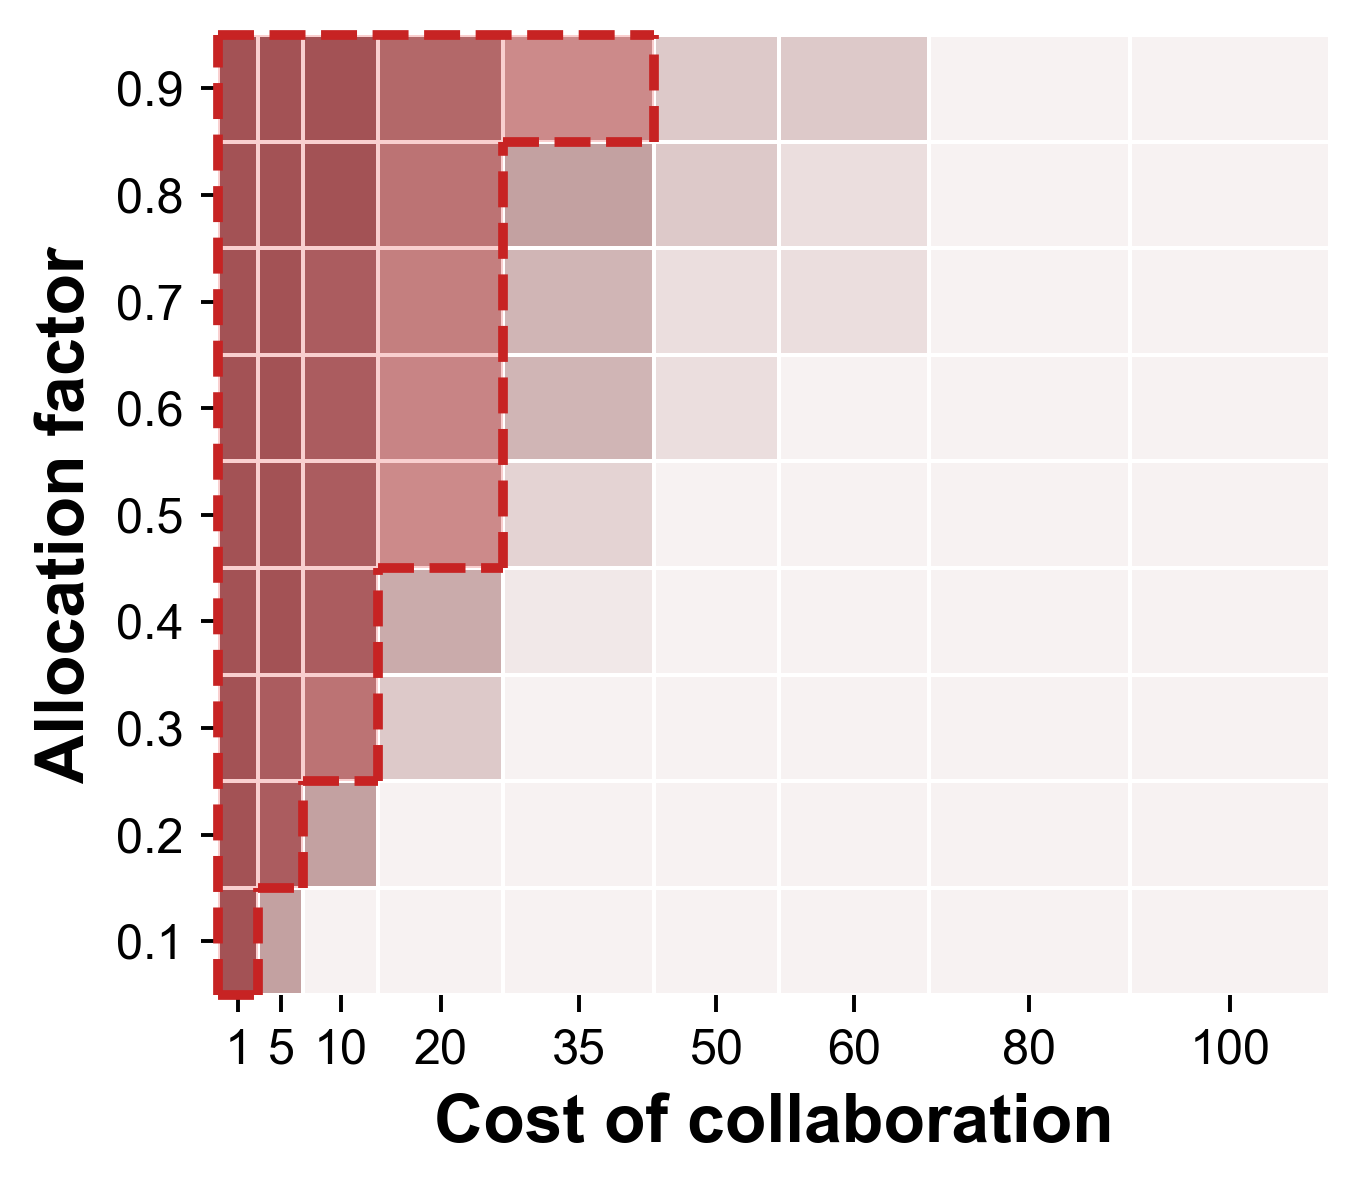

(<Figure size 1400x1225 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Allocation factor'>,
 penalty_std        1    5    10    20    35   50   60   80   100
 allocation_factor                                               
 0.1                1.0  0.4  0.0  0.00  0.00  0.0  0.0  0.0  0.0
 0.2                1.0  0.9  0.4  0.00  0.00  0.0  0.0  0.0  0.0
 0.3                1.0  0.9  0.7  0.20  0.00  0.0  0.0  0.0  0.0
 0.4                1.0  1.0  0.9  0.35  0.05  0.0  0.0  0.0  0.0
 0.5                1.0  1.0  0.9  0.50  0.15  0.0  0.0  0.0  0.0
 0.6                1.0  1.0  0.9  0.55  0.30  0.1  0.0  0.0  0.0
 0.7                1.0  1.0  0.9  0.60  0.30  0.1  0.1  0.0  0.0
 0.8                1.0  1.0  1.0  0.70  0.40  0.2  0.1  0.0  0.0
 0.9                1.0  1.0  1.0  0.80  0.50  0.2  0.2  0.0  0.0)

In [249]:
_colors = figure_plot.generate_smooth_colors(
    input_colors=["#F7F2F2","#702F35"],
    n_req_colors=10
)
figure_plot.heatmap_plot(
    joint_af_pen_df,
    x_col='penalty_std',
    y_col='allocation_factor',
    value_col='collaboration_rate',
    agg_method='median',
    annot=False,
    cmap=_colors,
    hide_spines=['top', 'bottom', 'left', 'right'],
    real_scale_x=True,
    x_tick_decimals=0,
    y_tick_decimals=1,
    # --- Highlight cells with value >= 0.5 ---
    cap_value=0.50,
    cap_edgecolor="#C72323",       # border colour
    cap_linewidth=2,         # border width
    cap_linestyle='--',         # '-', '--', ':', etc.
    cap_compare='>=',          # '>=', '>', '<=', '<', '==', '!='
    # --- cap line ---
    cap_outer_only=True,       # draw only the outer boundary of contiguous highlighted regions
    cap_fill=True,           # optional translucent fill
    cap_fill_color="#F08787",
    cap_fill_alpha=0.4,
    #---output---
    cbar=False,
    xlabel='Cost of collaboration',
    ylabel='Allocation factor',
    label_size=14,
    figure_size=(4, 3.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='heatmap_real_scale_collaboration_rate_by_penalty_and_allocation_factor_random_receivers_with_highlight_greater50.png',

)

### Gradient Plot

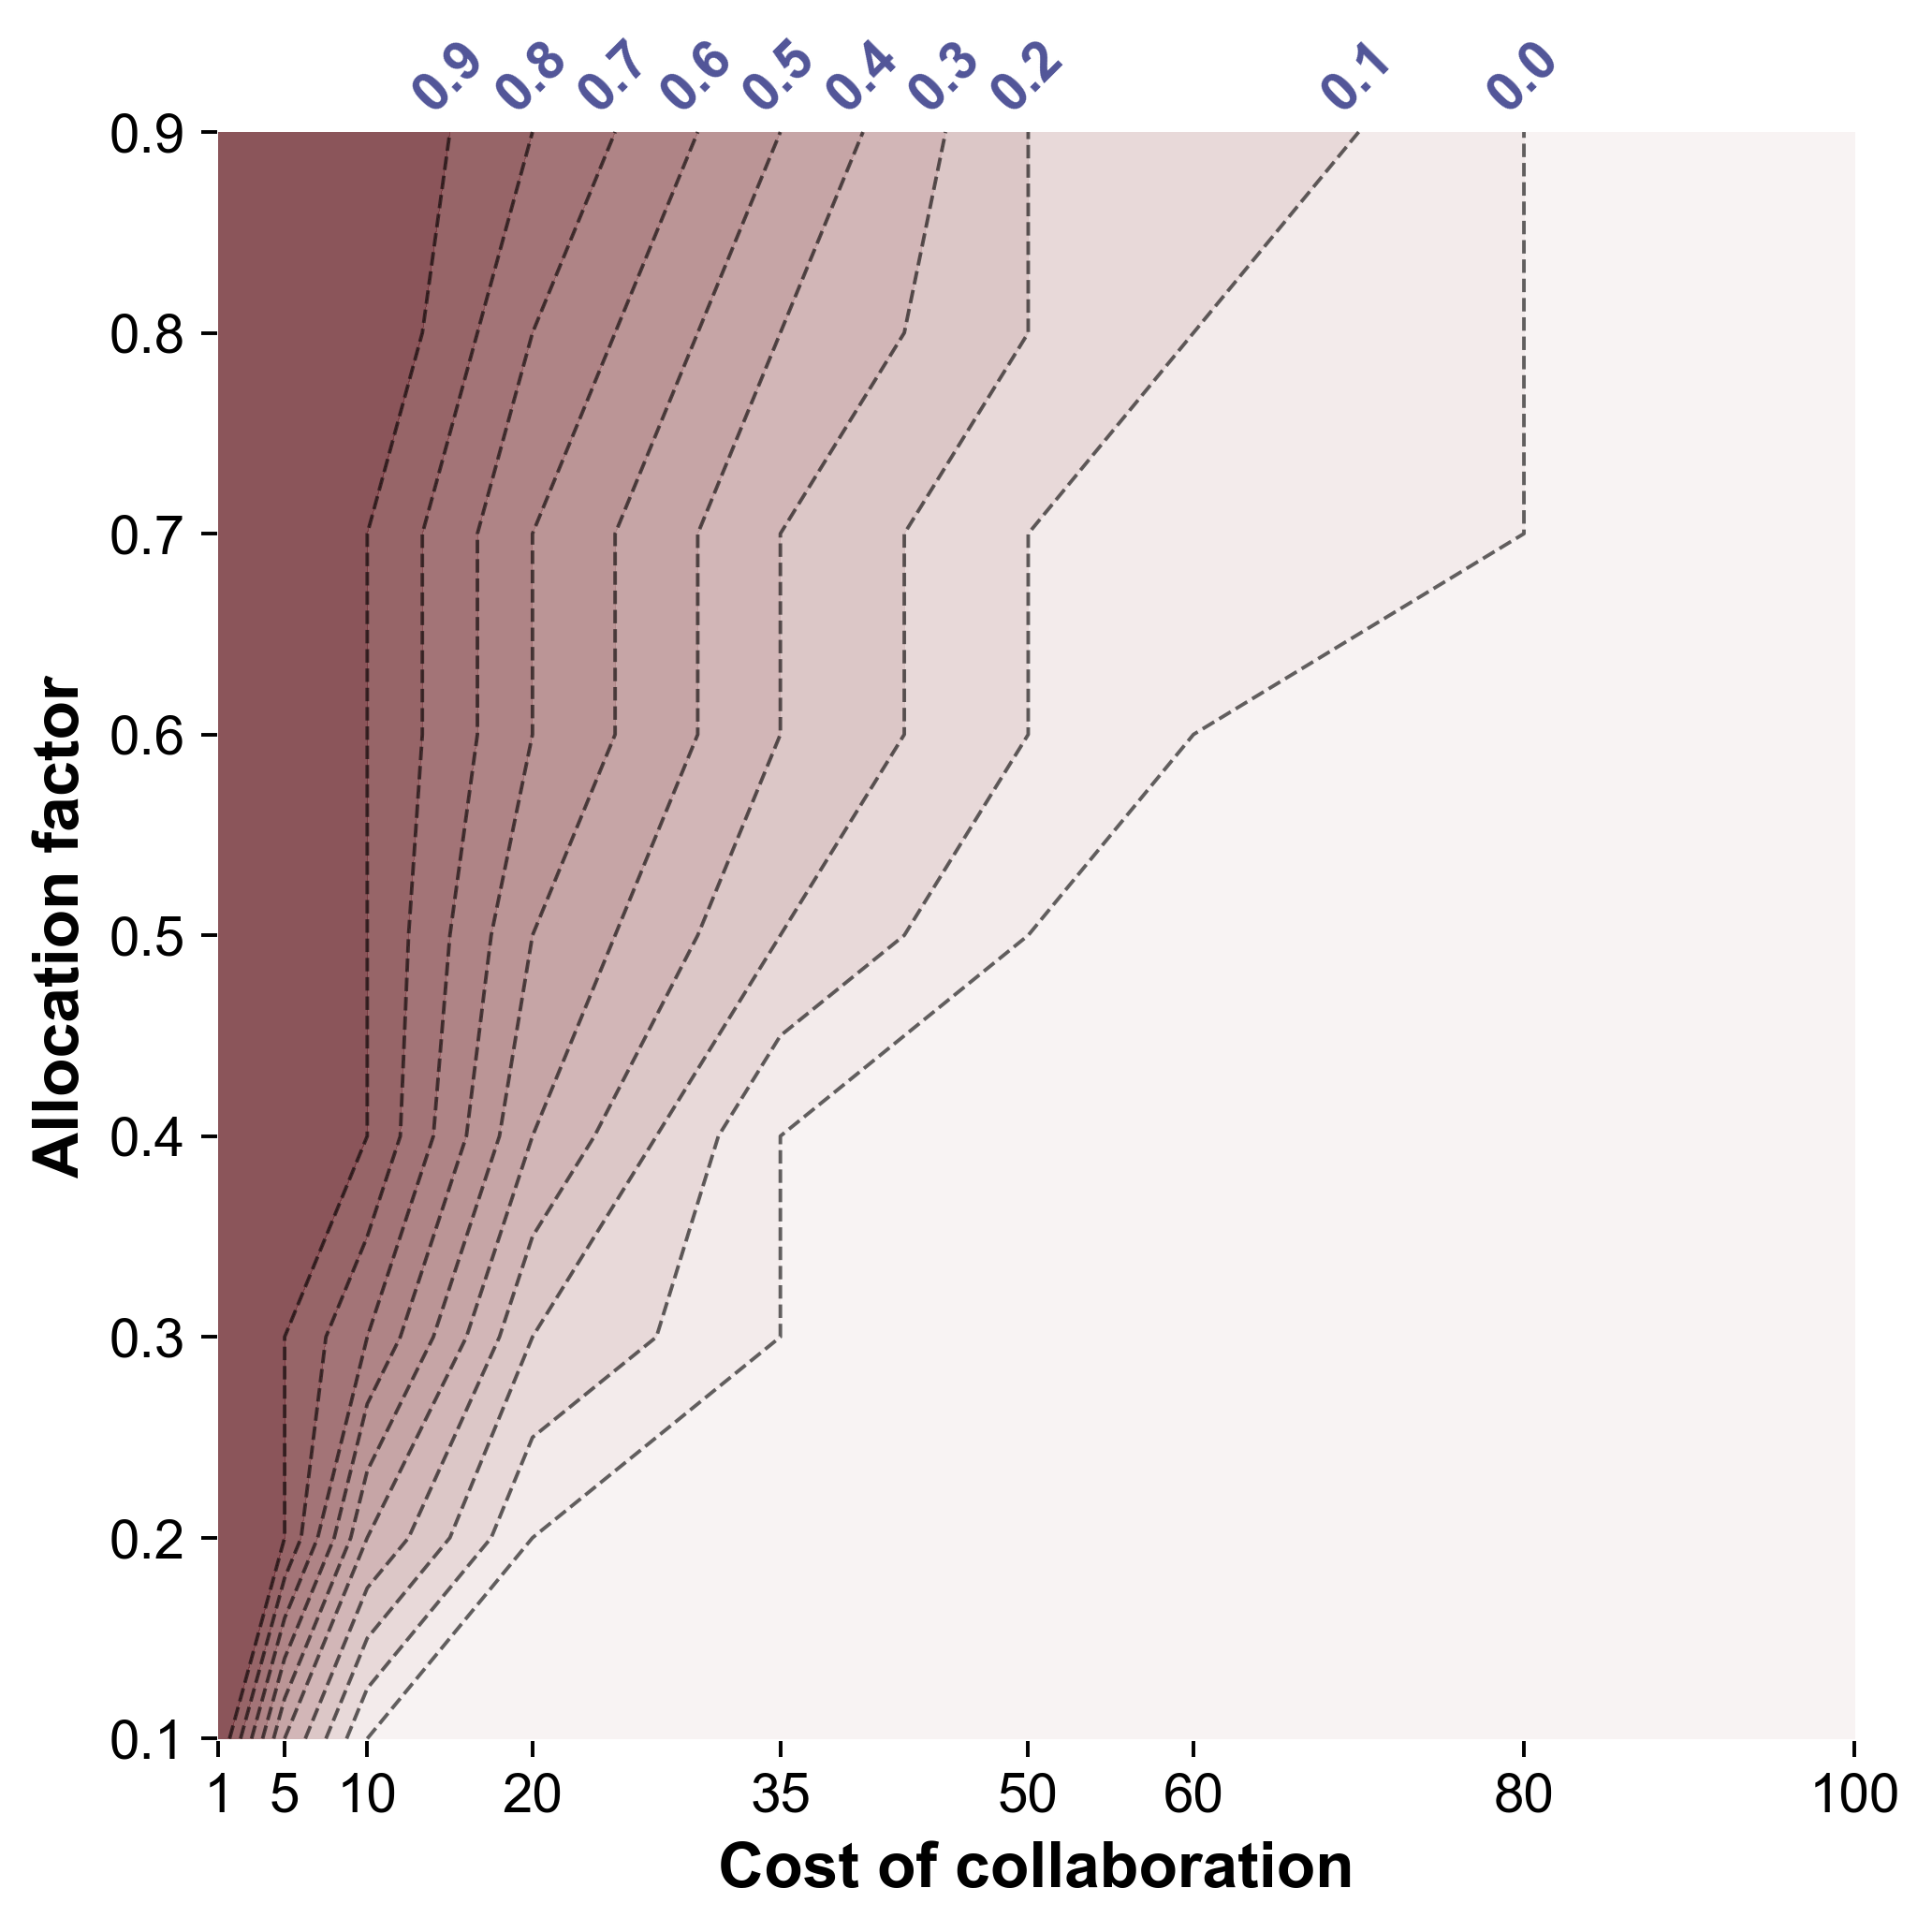

(<Figure size 2100x2100 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Allocation factor'>,
 penalty_std        1    5    10    20    35   50   60   80   100
 allocation_factor                                               
 0.1                1.0  0.4  0.0  0.00  0.00  0.0  0.0  0.0  0.0
 0.2                1.0  0.9  0.4  0.00  0.00  0.0  0.0  0.0  0.0
 0.3                1.0  0.9  0.7  0.20  0.00  0.0  0.0  0.0  0.0
 0.4                1.0  1.0  0.9  0.35  0.05  0.0  0.0  0.0  0.0
 0.5                1.0  1.0  0.9  0.50  0.15  0.0  0.0  0.0  0.0
 0.6                1.0  1.0  0.9  0.55  0.30  0.1  0.0  0.0  0.0
 0.7                1.0  1.0  0.9  0.60  0.30  0.1  0.1  0.0  0.0
 0.8                1.0  1.0  1.0  0.70  0.40  0.2  0.1  0.0  0.0
 0.9                1.0  1.0  1.0  0.80  0.50  0.2  0.2  0.0  0.0)

In [252]:
_colors = figure_plot.generate_smooth_colors(
    input_colors=["#F7F2F2","#702F35"],
    n_req_colors=11
)
figure_plot.gradient_plot(
    joint_af_pen_df,
    x_col='penalty_std',
    y_col='allocation_factor',
    value_col='collaboration_rate',
    agg_method='median',
    #--- Fig options ---
    figure_size=(6, 6),
    dpi=350,
    #--- X/Y labels ---
    xlabel='Cost of collaboration',
    ylabel='Allocation factor',
    label_size=14,
    tick_size=12,
    #--- Step and decimal for gradient calculation (e.g., 0-0.1, 0.1-0.2, etc.) ---
    value_decimals=1,       # 将 Z 值四舍五入到 1 位小数后再画等高线
    step=0.1,               # 等高线间距 0.1
    #--- colors ---
    cmap=_colors,
    #--- interpolation ---
    interpolate=False,
    interp_method='rbf',  # 'linear', 'cubic', 'nearest'， 'rbf'
    rbf_smoothing=0,
    interp_resolution=1000,
    #--- contour options ---
    mask_beyond_data=True,   # 默认开启，无数据区域不画等高线
    line_styles='--',          # 等高线线型
    # mask_radius=100,         # 可选：手动指定最大距离（数据坐标单位）
    # show_points=True,        # 可选：叠加真实数据点方便验证
    #--- contour labels ---
    #show_clabels=False,
    clabel_fmt='%.1f',      # 等高线标签也只显示 1 位小数
    clabel_color="#515598",
    clabel_fontsize=12,
    clabel_positions='end',
    clabel_end_side='top',             # 放在顶部
    clabel_end_offset=0.005,
    clabel_rotation=45,
    # clabel_inline=False,
    #--- x/y ticks range---
    xlim=(0.9, 100.1),
    ylim=(0.099, 0.91),
    #--- Grid ---
    # show_grid=True,
    grid_color="#9D9393",
    grid_linewidth=1,
    grid_alpha=0.8,
    # --- Output ---
    cbar=False,
    hide_spines=['top', 'bottom', 'left', 'right'],
    figure_folder=OUTPUT_FIG_PATH,
    filename='gradient_collaboration_rate_by_penalty_and_allocation_factor_random_receivers.png',
    )

#### Highlight Region >0.9

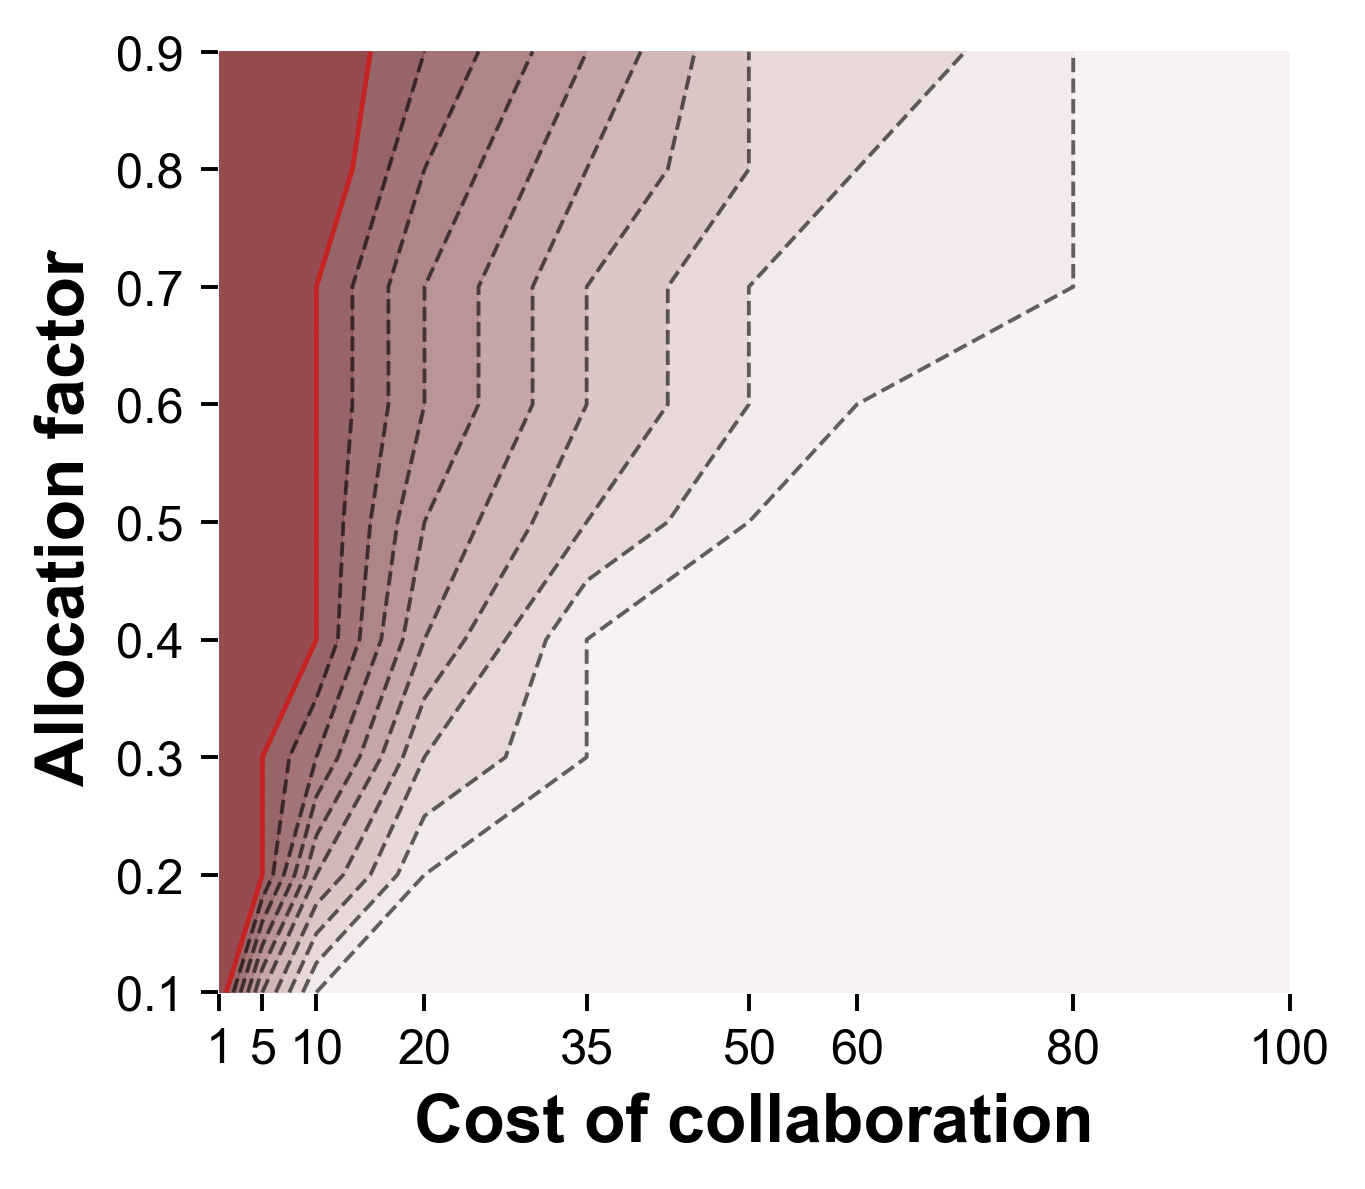

(<Figure size 1400x1225 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Allocation factor'>,
 penalty_std        1    5    10    20    35   50   60   80   100
 allocation_factor                                               
 0.1                1.0  0.4  0.0  0.00  0.00  0.0  0.0  0.0  0.0
 0.2                1.0  0.9  0.4  0.00  0.00  0.0  0.0  0.0  0.0
 0.3                1.0  0.9  0.7  0.20  0.00  0.0  0.0  0.0  0.0
 0.4                1.0  1.0  0.9  0.35  0.05  0.0  0.0  0.0  0.0
 0.5                1.0  1.0  0.9  0.50  0.15  0.0  0.0  0.0  0.0
 0.6                1.0  1.0  0.9  0.55  0.30  0.1  0.0  0.0  0.0
 0.7                1.0  1.0  0.9  0.60  0.30  0.1  0.1  0.0  0.0
 0.8                1.0  1.0  1.0  0.70  0.40  0.2  0.1  0.0  0.0
 0.9                1.0  1.0  1.0  0.80  0.50  0.2  0.2  0.0  0.0)

In [245]:
_colors = figure_plot.generate_smooth_colors(
    input_colors=["#F7F2F2","#702F35"],
    n_req_colors=10
)
figure_plot.gradient_plot(
    joint_af_pen_df,
    x_col='penalty_std',
    y_col='allocation_factor',
    value_col='collaboration_rate',
    agg_method='median',
    #--- Fig options ---
    figure_size=(4, 3.5),
    dpi=350,
    #--- X/Y labels ---
    xlabel='Cost of collaboration',
    ylabel='Allocation factor',
    label_size=14,
    #--- Step and decimal for gradient calculation (e.g., 0-0.1, 0.1-0.2, etc.) ---
    value_decimals=1,       # 将 Z 值四舍五入到 1 位小数后再画等高线
    step=0.1,               # 等高线间距 0.1
    #--- colors ---
    cmap=_colors,
    #--- interpolation ---
    interpolate=False,
    interp_method='rbf',  # 'linear', 'cubic', 'nearest'， 'rbf'
    rbf_smoothing=0,
    interp_resolution=1000,
    #--- contour options ---
    mask_beyond_data=True,   # 默认开启，无数据区域不画等高线
    line_styles='--',          # 等高线线型
    # mask_radius=100,         # 可选：手动指定最大距离（数据坐标单位）
    # show_points=True,        # 可选：叠加真实数据点方便验证
    #--- contour labels ---
    show_clabels=False,
    clabel_fmt='%.1f',      # 等高线标签也只显示 1 位小数
    clabel_color="#515598",
    clabel_fontsize=9,
    clabel_positions='end',
    clabel_end_side='top',             # 放在顶部
    clabel_end_offset=0.005,
    clabel_rotation=45,
    # clabel_inline=False,
    #--- x/y ticks range---
    xlim=(0.9, 100.1),
    ylim=(0.099, 0.91),
    #--- Grid ---
    # show_grid=True,
    grid_color="#9D9393",
    grid_linewidth=1,
    grid_alpha=0.8,
    #--- Highlight cells with value >= 0.9 ---
    cap_value=0.9,
    cap_compare='>=',          # '>=', '>', '<=', '<', '==', '!='
    cap_line_color="#C72323",       # border colour
    cap_line_width=1,         # border width
    cap_line_style='-',         # '-', '--', ':', etc.
    cap_outer_only=True,       # draw only the outer boundary of contiguous highlighted regions
    cap_fill=True,           # optional translucent fill
    # --- Output ---
    cbar=False,
    hide_spines=['top', 'bottom', 'left', 'right'],
    figure_folder=OUTPUT_FIG_PATH,
    filename='gradient_collaboration_rate_by_penalty_and_allocation_factor_random_receivers_greater90.png',
    )

#### Highlight region > 0.7

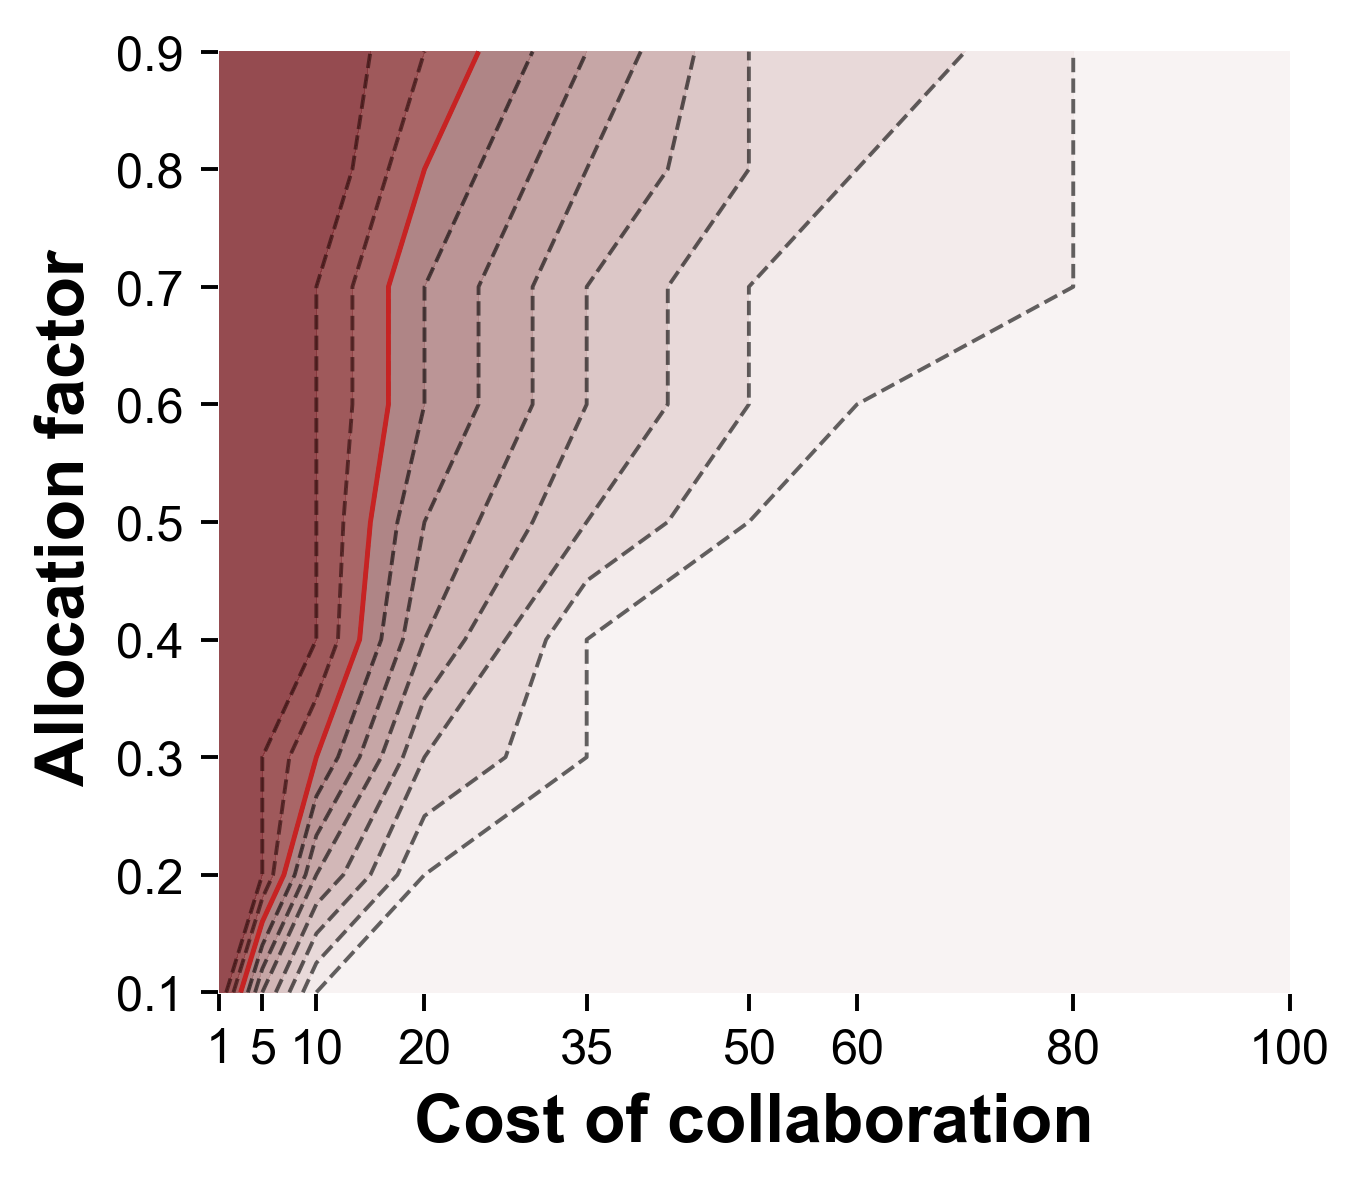

(<Figure size 1400x1225 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Allocation factor'>,
 penalty_std        1    5    10    20    35   50   60   80   100
 allocation_factor                                               
 0.1                1.0  0.4  0.0  0.00  0.00  0.0  0.0  0.0  0.0
 0.2                1.0  0.9  0.4  0.00  0.00  0.0  0.0  0.0  0.0
 0.3                1.0  0.9  0.7  0.20  0.00  0.0  0.0  0.0  0.0
 0.4                1.0  1.0  0.9  0.35  0.05  0.0  0.0  0.0  0.0
 0.5                1.0  1.0  0.9  0.50  0.15  0.0  0.0  0.0  0.0
 0.6                1.0  1.0  0.9  0.55  0.30  0.1  0.0  0.0  0.0
 0.7                1.0  1.0  0.9  0.60  0.30  0.1  0.1  0.0  0.0
 0.8                1.0  1.0  1.0  0.70  0.40  0.2  0.1  0.0  0.0
 0.9                1.0  1.0  1.0  0.80  0.50  0.2  0.2  0.0  0.0)

In [244]:
_colors = figure_plot.generate_smooth_colors(
    input_colors=["#F7F2F2","#702F35"],
    n_req_colors=10
)
figure_plot.gradient_plot(
    joint_af_pen_df,
    x_col='penalty_std',
    y_col='allocation_factor',
    value_col='collaboration_rate',
    agg_method='median',
    #--- Fig options ---
    figure_size=(4, 3.5),
    dpi=350,
    #--- X/Y labels ---
    xlabel='Cost of collaboration',
    ylabel='Allocation factor',
    label_size=14,
    #--- Step and decimal for gradient calculation (e.g., 0-0.1, 0.1-0.2, etc.) ---
    value_decimals=1,       # 将 Z 值四舍五入到 1 位小数后再画等高线
    step=0.1,               # 等高线间距 0.1
    #--- colors ---
    cmap=_colors,
    #--- interpolation ---
    interpolate=False,
    interp_method='rbf',  # 'linear', 'cubic', 'nearest'， 'rbf'
    rbf_smoothing=0,
    interp_resolution=1000,
    #--- contour options ---
    mask_beyond_data=True,   # 默认开启，无数据区域不画等高线
    line_styles='--',          # 等高线线型
    # mask_radius=100,         # 可选：手动指定最大距离（数据坐标单位）
    # show_points=True,        # 可选：叠加真实数据点方便验证
    #--- contour labels ---
    show_clabels=False,
    clabel_fmt='%.1f',      # 等高线标签也只显示 1 位小数
    clabel_color="#515598",
    clabel_fontsize=9,
    clabel_positions='end',
    clabel_end_side='top',             # 放在顶部
    clabel_end_offset=0.005,
    clabel_rotation=45,
    # clabel_inline=False,
    #--- x/y ticks range---
    xlim=(0.9, 100.1),
    ylim=(0.099, 0.91),
    #--- Grid ---
    # show_grid=True,
    grid_color="#9D9393",
    grid_linewidth=1,
    grid_alpha=0.8,
    #--- Highlight cells with value >= 0.9 ---
    cap_value=0.7,
    cap_compare='>=',          # '>=', '>', '<=', '<', '==', '!='
    cap_line_color="#C72323",       # border colour
    cap_line_width=1,         # border width
    cap_line_style='-',         # '-', '--', ':', etc.
    cap_outer_only=True,       # draw only the outer boundary of contiguous highlighted regions
    cap_fill=True,           # optional translucent fill
    # --- Output ---
    cbar=False,
    hide_spines=['top', 'bottom', 'left', 'right'],
    figure_folder=OUTPUT_FIG_PATH,
    filename='gradient_collaboration_rate_by_penalty_and_allocation_factor_random_receivers_greater70.png',
    )

#### Highlight region >0.5

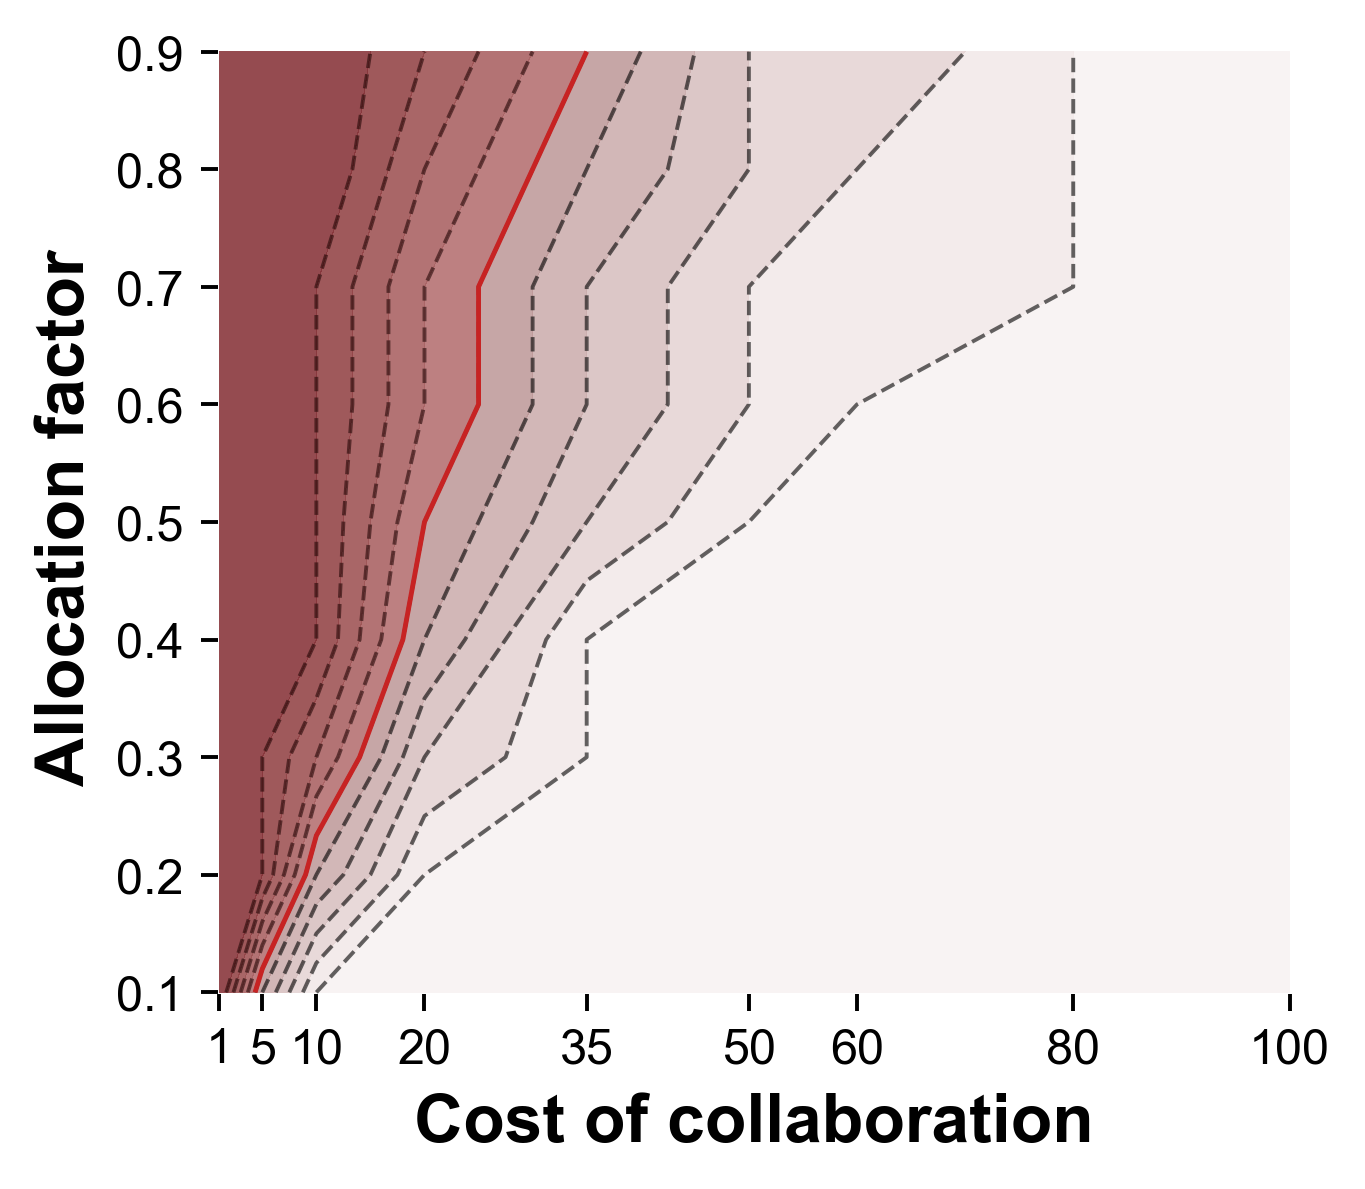

(<Figure size 1400x1225 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Allocation factor'>,
 penalty_std        1    5    10    20    35   50   60   80   100
 allocation_factor                                               
 0.1                1.0  0.4  0.0  0.00  0.00  0.0  0.0  0.0  0.0
 0.2                1.0  0.9  0.4  0.00  0.00  0.0  0.0  0.0  0.0
 0.3                1.0  0.9  0.7  0.20  0.00  0.0  0.0  0.0  0.0
 0.4                1.0  1.0  0.9  0.35  0.05  0.0  0.0  0.0  0.0
 0.5                1.0  1.0  0.9  0.50  0.15  0.0  0.0  0.0  0.0
 0.6                1.0  1.0  0.9  0.55  0.30  0.1  0.0  0.0  0.0
 0.7                1.0  1.0  0.9  0.60  0.30  0.1  0.1  0.0  0.0
 0.8                1.0  1.0  1.0  0.70  0.40  0.2  0.1  0.0  0.0
 0.9                1.0  1.0  1.0  0.80  0.50  0.2  0.2  0.0  0.0)

In [243]:
_colors = figure_plot.generate_smooth_colors(
    input_colors=["#F7F2F2","#702F35"],
    n_req_colors=10
)
figure_plot.gradient_plot(
    joint_af_pen_df,
    x_col='penalty_std',
    y_col='allocation_factor',
    value_col='collaboration_rate',
    agg_method='median',
    #--- Fig options ---
    figure_size=(4, 3.5),
    dpi=350,
    #--- X/Y labels ---
    xlabel='Cost of collaboration',
    ylabel='Allocation factor',
    label_size=14,
    #--- Step and decimal for gradient calculation (e.g., 0-0.1, 0.1-0.2, etc.) ---
    value_decimals=1,       # 将 Z 值四舍五入到 1 位小数后再画等高线
    step=0.1,               # 等高线间距 0.1
    #--- colors ---
    cmap=_colors,
    #--- interpolation ---
    interpolate=False,
    interp_method='rbf',  # 'linear', 'cubic', 'nearest'， 'rbf'
    rbf_smoothing=0,
    interp_resolution=1000,
    #--- contour options ---
    mask_beyond_data=True,   # 默认开启，无数据区域不画等高线
    line_styles='--',          # 等高线线型
    # mask_radius=100,         # 可选：手动指定最大距离（数据坐标单位）
    # show_points=True,        # 可选：叠加真实数据点方便验证
    #--- contour labels ---
    show_clabels=False,
    clabel_fmt='%.1f',      # 等高线标签也只显示 1 位小数
    clabel_color="#515598",
    clabel_fontsize=9,
    clabel_positions='end',
    clabel_end_side='top',             # 放在顶部
    clabel_end_offset=0.005,
    clabel_rotation=45,
    # clabel_inline=False,
    #--- x/y ticks range---
    xlim=(0.9, 100.1),
    ylim=(0.099, 0.91),
    #--- Grid ---
    # show_grid=True,
    grid_color="#9D9393",
    grid_linewidth=1,
    grid_alpha=0.8,
    # grid_axis='y',
    #--- Highlight cells with value >= 0.9 ---
    cap_value=0.5,
    cap_compare='>=',          # '>=', '>', '<=', '<', '==', '!='
    cap_line_color="#C72323",       # border colour
    cap_line_width=1,         # border width
    cap_line_style='-',         # '-', '--', ':', etc.
    cap_outer_only=True,       # draw only the outer boundary of contiguous highlighted regions
    cap_fill=True,           # optional translucent fill
    # --- Output ---
    cbar=False,
    hide_spines=['top', 'bottom', 'left', 'right'],
    figure_folder=OUTPUT_FIG_PATH,
    filename='gradient_collaboration_rate_by_penalty_and_allocation_factor_random_receivers_greater50.png',
    )

## Analyse random scenario before-and-after operation

In [276]:
all_metrics_random_20euro_af60_df = all_metrics_random_df[(all_metrics_random_df['penalty'] == 0.0056) & (all_metrics_random_df['allocation_factor'] == 0.6)]


In [ ]:
print("the mean collaboration rate for 20 euro penalty is:", all_metrics_random_20euro_af60_df['collaboration_rate'].mean())
print("the max collaboration rate for 20 euro penalty is:", all_metrics_random_20euro_af60_df['collaboration_rate'].max())
print("the min collaboration rate for 20 euro penalty is:", all_metrics_random_20euro_af60_df['collaboration_rate'].min())

### VKT

In [ ]:
_vkt_df = all_metrics_outside_random_20euro_af80_df[all_metrics_outside_random_20euro_af80_df['instance'].between(0, 100)]
figure_plot.hist_plot(_vkt_df,
                      col1='VKT_km',
                      col2='iter0_VKT_km',
                      n_bins=10,
                      figure_size=(3.5,2.7),
                      ylabel = 'Density',
                      xlabel = 'VKT (km)',
                      label_size=14,
                      hide_labels=False,
                      hide_legends=True,
                      alphas=(0.9, 0.9),
                      colors=("#8dadc3", '#f6bdb1'),
                      figure_folder=OUTPUT_FIG_PATH,
                      filename='vkt_distribution_outside_random_20euro_penalty'
                      )
print("the mean reduction in VKT for 20 euro penalty is:",
       (_vkt_df['iter0_VKT_km'].mean() - _vkt_df['VKT_km'].mean()))

In [ ]:
_vkt_df = all_metrics_random_20euro_af60_df.copy(deep=True)
_vkt_df['vkt_reduction'] = _vkt_df['iter0_VKT_km'] - _vkt_df['VKT_km']

In [ ]:
figure_plot.scatter_regression_plot(_vkt_df,
                                    x_col='collaboration_rate',
                                    y_col='vkt_reduction',
                                    figure_size=(3.3,2.8),
                                    xlabel='Collaboration rate',
                                    ylabel='VKT reduction',
                                    label_size=14,
                                    annotation_fontsize=12,
                                    # title='Scatter plot with regression line: VKT vs Collaboration Rate',
                                    show_corr=True,
                                    add_regression=True,
                                    show_equation=False,
                                    show_r2=True,
                                    scatter_color='#458CBC',
                                    scatter_alpha=0.9,
                                    reg_color='#0b2c60',
                                    # Output
                                    figure_folder=OUTPUT_FIG_PATH,
                                    filename='scatter_regression_vkt_reduction_vs_collab_rate_all_random_20euro_af60.png'
                                    )

### VTT

In [ ]:
vtt_minutes_df = all_metrics_outside_random_20euro_af80_df.copy()
vtt_minutes_df[['VTT_seconds', 'iter0_VTT_seconds']] = (
    vtt_minutes_df[['VTT_seconds', 'iter0_VTT_seconds']] / 60
)
_vtt_minutes_df = vtt_minutes_df[vtt_minutes_df['instance'].between(0,100)]
figure_plot.hist_plot(_vtt_minutes_df,
                      col1='VTT_seconds',
                      col2='iter0_VTT_seconds',
                      n_bins=10,
                      figure_size=(3.5,2.7),
                      ylabel='Density',
                      xlabel='Travel time (min)',
                      label_size=14,
                      hide_labels=False,
                      hide_legends=True,
                      alphas=(0.9, 0.9),
                        colors=("#8dadc3", '#f6bdb1'),
                        figure_folder=OUTPUT_FIG_PATH,
                        filename='vtt_distribution_outside_random_20euro_penalty'
                      )
print("the mean reduction of VTT is: {}".format(
    -(_vtt_minutes_df['VTT_seconds'].mean() 
        - _vtt_minutes_df['iter0_VTT_seconds'].mean())) 
        )

### Ton-km travelled

In [ ]:
tkt_ton_df = all_metrics_outside_random_20euro_af80_df.copy()
tkt_ton_df[['TKT_tonkm', 'iter0_TKT_tonkm']] = (
    tkt_ton_df[['TKT_tonkm', 'iter0_TKT_tonkm']] / 1000
)
_tkt_ton_df = tkt_ton_df[tkt_ton_df['instance'].between(0,100)]
figure_plot.hist_plot(_tkt_ton_df,
                        col1='TKT_tonkm',
                        col2='iter0_TKT_tonkm',
                        n_bins=9,
                        figure_size=(3.3,2.8),
                        ylabel='Density',
                        xlabel='Ton-km travelled',
                        hide_labels=False,
                        hide_legends=True,
                        alphas=(0.9, 0.9),
                        colors=("#8dadc3", '#f6bdb1'),
                        label_size=14,
                        figure_folder=OUTPUT_FIG_PATH,
                        filename='tkt_distribution_outside_random_20euro_penalty'
                        )
print("the mean increase of TKT is: {}".format(
    (_tkt_ton_df['TKT_tonkm'].mean()
        - _tkt_ton_df['iter0_TKT_tonkm'].mean())) 
        )


In [ ]:
_tkt_df = all_metrics_random_20euro_af60_df.copy(deep=True)
_tkt_df['TKT_rise'] = _tkt_df['TKT_tonkm'] - _tkt_df['iter0_TKT_tonkm']
_tkt_df['TKT_rise'] = _tkt_df['TKT_rise'] / 1000
_tkt_df = _tkt_df[_tkt_df['TKT_rise'] >= 0]
_tkt_df

In [ ]:
figure_plot.scatter_regression_plot(_tkt_df,
                                    x_col='collaboration_rate',
                                    y_col='TKT_rise',
                                    figure_size=(3.3,2.8),
                                    xlabel='Collaboration rate',
                                    ylabel='TKT rise',
                                    label_size=14,
                                    annotation_fontsize=12,
                                    # title='Scatter plot with regression line: TKT Rise vs Collaboration Rate',
                                    show_corr=True,
                                    add_regression=True,
                                    show_equation=False,
                                    show_r2=True,
                                    scatter_color='#458CBC',
                                    scatter_alpha=0.9,
                                    reg_color='#0b2c60',
                                    # Output
                                    figure_folder=OUTPUT_FIG_PATH,
                                    filename='scatter_regression_tkt_rise_vs_collab_rate_all_random_20euro_af60.png'
                                    )

### Joint plot of collaboration rate, carrier score, receiver score and fleet size.


In [ ]:
_score_df.query("total_receiver_scores >= -825")

f:\gitRepository\matsim-libs-2024\python\test\figure_plot.py:958: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


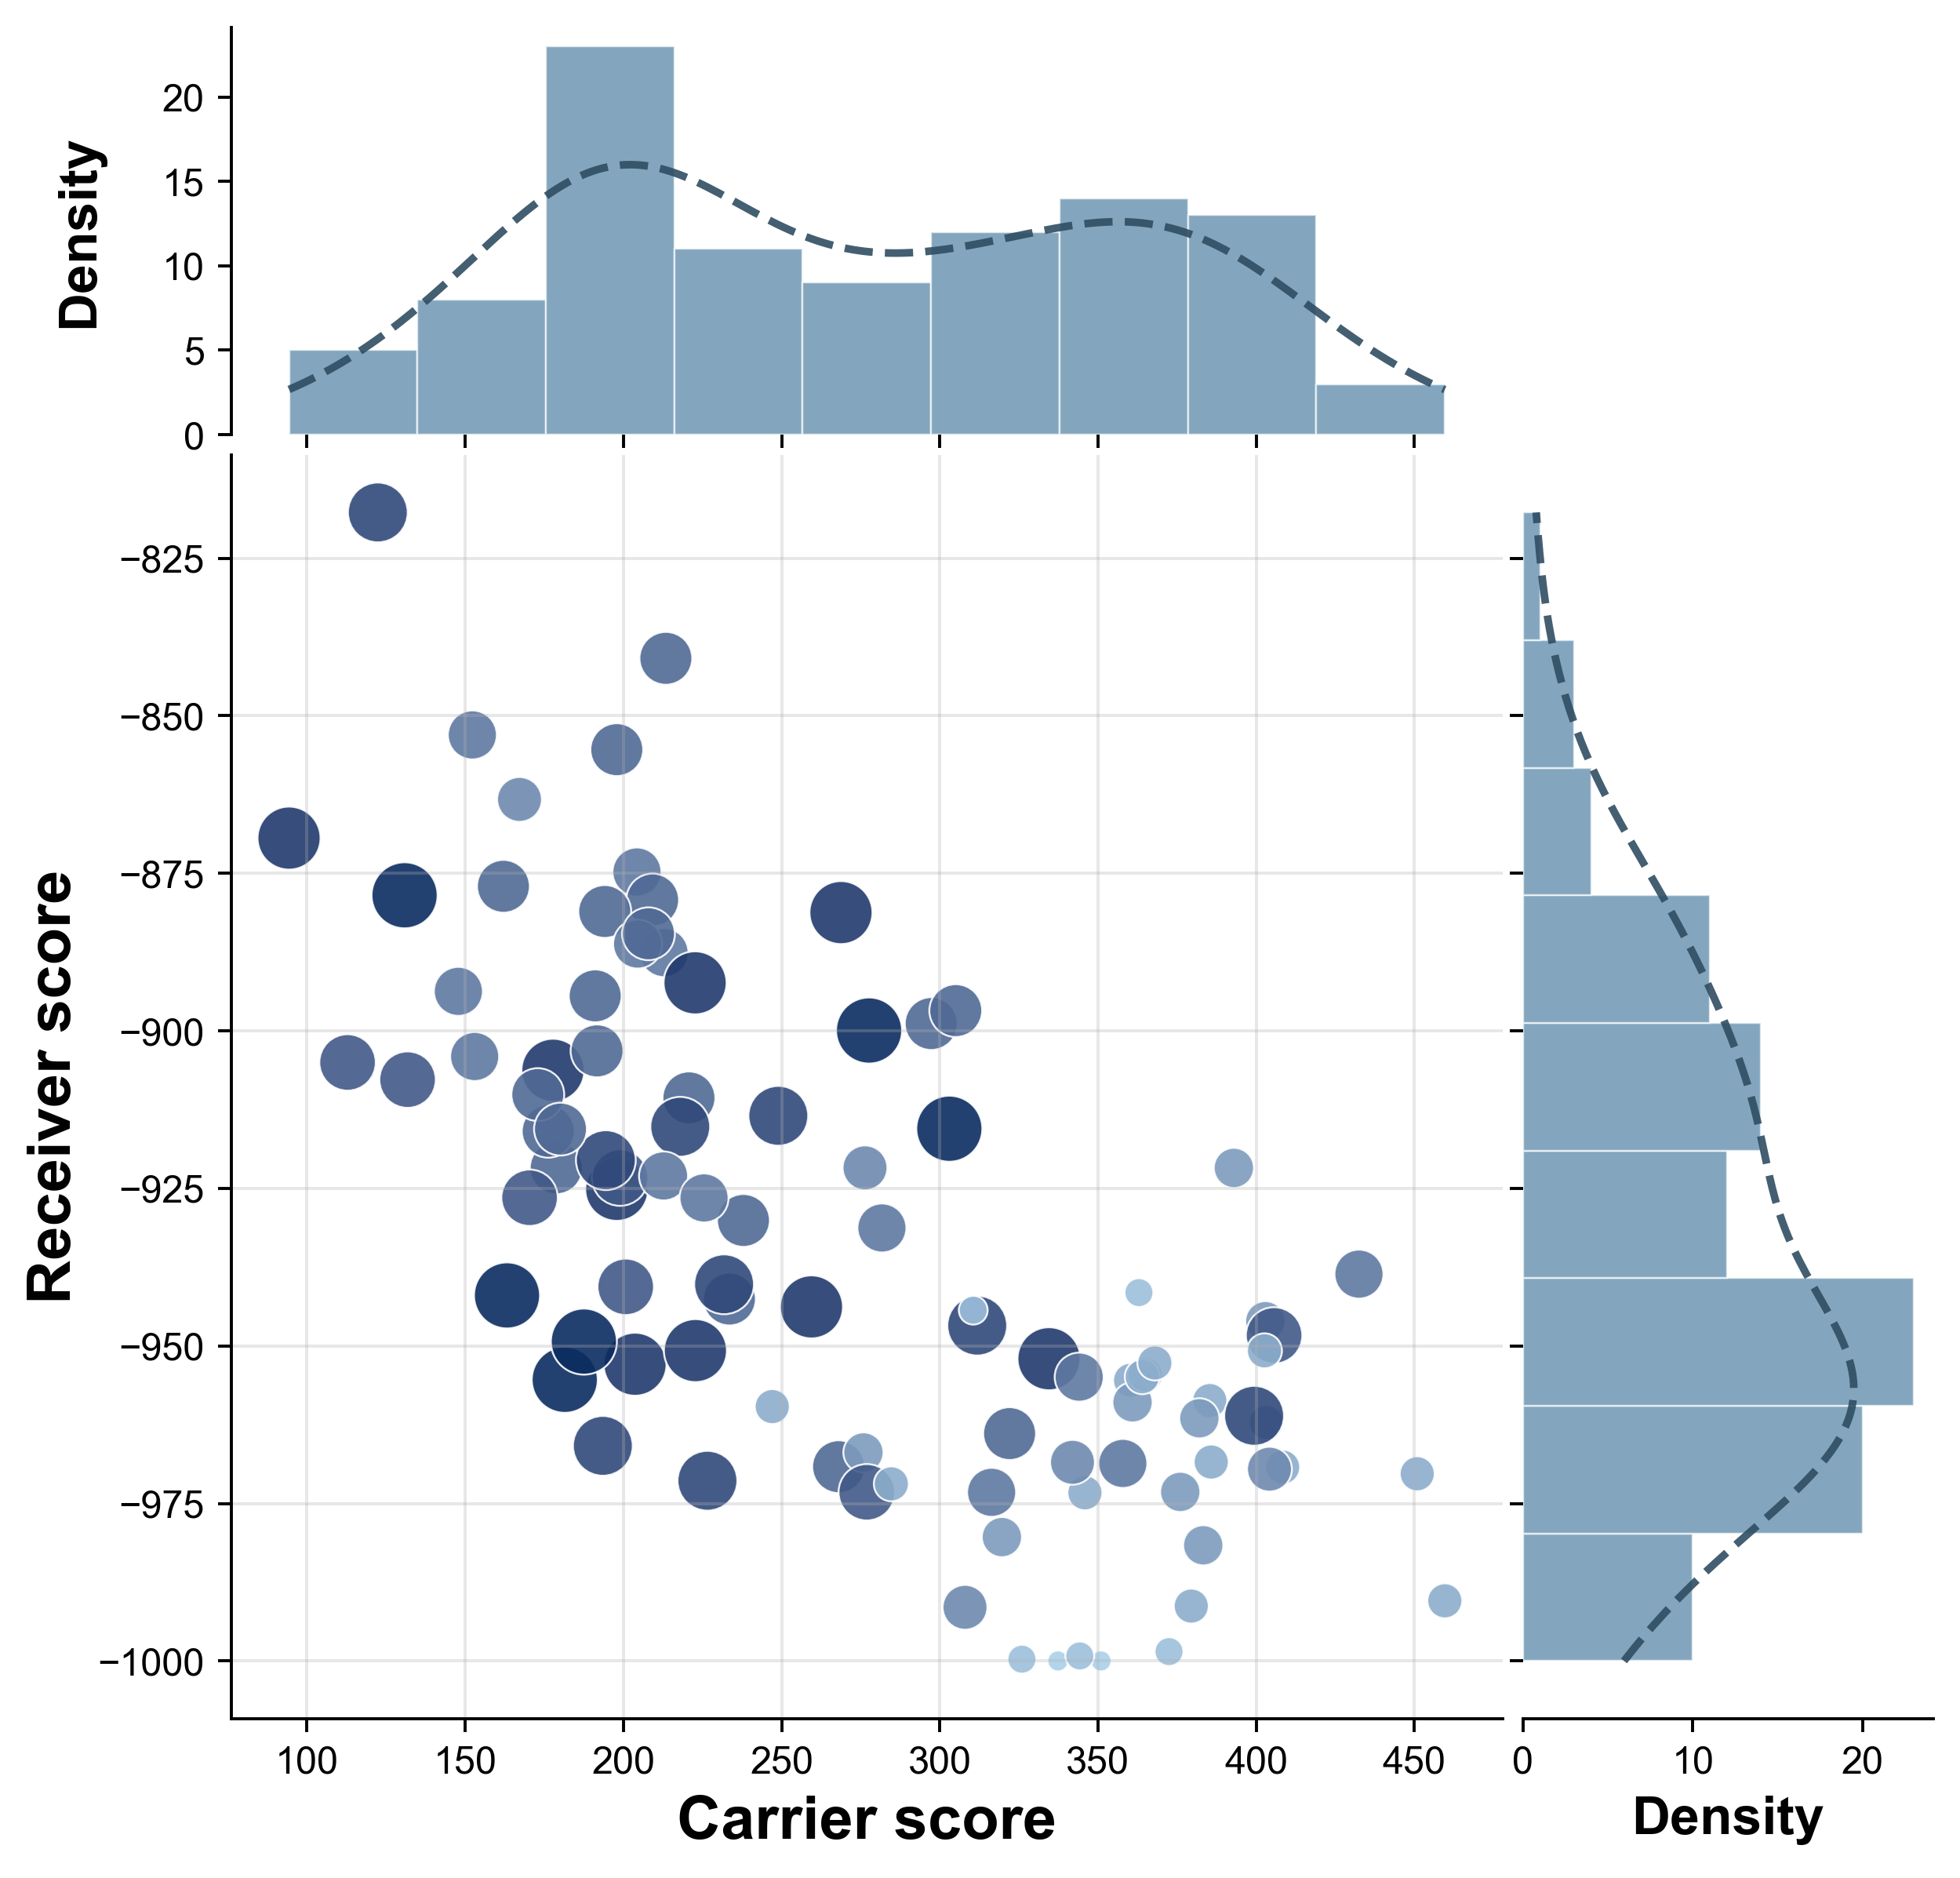

(<Figure size 2800x2800 with 3 Axes>,
 {'main': <Axes: xlabel='Carrier score', ylabel='Receiver score'>,
  'top': <Axes: ylabel='Density'>,
  'right': <Axes: xlabel='Density'>})

In [279]:
_score_df = all_metrics_random_20euro_af60_df[all_metrics_random_20euro_af60_df['instance'].between(0,100)]
_score_df.query("final_carrier_score >= 0 and total_receiver_scores >= -1000", inplace=True)
_score_df['iter0_total_receiver_scores'] = -1000

_colors = figure_plot.generate_smooth_colors(
    input_colors=["#abd1e9","#0b2c60"],
    n_req_colors=11
)

figure_plot.joint_scatter_plot(
    _score_df,
    x_col='final_carrier_score',
    y_col='total_receiver_scores',
    n_bins=10,
    figure_size=(8, 8),
    marginal_type='both',  # 同时显示 histogram 和 KDE
    marginal_label_size=14,
    xlabel='Carrier score',
    ylabel='Receiver score',
    label_size=16,
    show_corr=False,
    # scatter_color="#8dadc3",
    scatter_alpha=0.9,
    hist_color="#4F81A3",
    kde_linestyle='--',
    kde_alpha=0.9,
    ## the second scatter plot
    # data_df2=_score_df,
    # x_col2='iter0_carrier_score',
    # y_col2='iter0_total_receiver_scores',
    # scatter2_marker='X',
    # scatter2_color='#f6bdb1',
    # scatter2_edgecolor="#f09785",
    # scatter2_alpha=0.9,
    # scatter2_size=90,
    ## Group the main scatter points by collaboration rate
    size_group_col='collaboration_rate',
    size_min=30,
    size_max=300,
    show_size_legend=False,
    # size_legend_loc='lower right',
    ## Group the main scatter points by fleet size
    color_group_col='collaboration_rate',
    # color_group_col='diff_fleet_size',
    cmap_color_list=_colors,
    show_color_legend=False,
    ## Output
    # add_regression=True,
    figure_folder=OUTPUT_FIG_PATH,
    filename='joint_RC_scores_with_collab_rate_all_random_20euro_af60.png',
)


### Fleet size

In [ ]:
pd.cut(_score_df['collaboration_rate'], bins=[0, 0.4, 0.6, 0.8, 1.0], retbins=True, include_lowest=True)

In [ ]:
_score_df

In [ ]:
# _colors = figure_plot.generate_smooth_colors(
#     input_colors=["#abd1e9", "#0b2c60"],
#     n_req_colors=11
# )
figure_plot.stacked_proportion_plot(_score_df,
                                    figure_size=(3.5,3),
                                     bin_col='collaboration_rate',
                                     value_col='diff_fleet_size',
                                     bin_method='custom',
                                     custom_bins=[0, 0.3, 0.6, 1.0],
                                     xtick_labels=['Low \n(0-0.3)', 'Medium \n(0.4-0.6)', 'High \n(0.7-1.0)'],
                                     xtick_rotation=0,
                                     xtick_ha='center',
                                     xtick_fontsize=12,
                                     colors=["#b6b8b7", "#abd1e9", "#458CBC", "#0b2c60"][::-1],
                                     xlabel='Collaboration rate',
                                     ylabel='Proportion (%)',
                                     label_size=14,
                                     show_counts=True,
                                     count_fontsize=12,
                                     percentage_fontsize=14,
                                     # Legend settings
                                     legend_bbox=(0.5, 1.4),
                                     legend_ncol=3,
                                     legend_title='Fleet size difference',
                                     show_legend=False,
                                     # Output
                                     figure_folder=OUTPUT_FIG_PATH,
                                     filename='stacked_proportion_fleet_size_diff_vs_collab_all_random_af60_pen20.png'
                                     )

In [ ]:
figure_plot.scatter_regression_plot(all_metrics_random_20euro_af60_df,
                                    x_col='collaboration_rate',
                                    y_col='diff_fleet_size',
                                    figure_size=(4,3),
                                    xlabel='Collaboration rate',
                                    ylabel='Fleet size reduction',
                                    label_size=14,
                                    # title='Scatter plot with regression line: Cost Savings vs Collaboration Rate',
                                    show_corr=True,
                                    add_regression=True,
                                    show_equation=False,
                                    show_r2=False,
                                    scatter_color='#458CBC',
                                    scatter_alpha=0.9,
                                    reg_color='#0b2c60',
                                    # Output
                                    figure_folder=OUTPUT_FIG_PATH,
                                    filename='scatter_regression_fleet_size_reduction_vs_collab_rate_all_random_20euro_af60.png'
                                    )

### Total cost savings
Plot the correlations between the collaboration rate and the total cost savings

In [ ]:
figure_plot.scatter_regression_plot(all_metrics_random_20euro_af60_df,
                                    x_col='collaboration_rate',
                                    y_col='total_cost_savings',
                                    figure_size=(3.3,2.8),
                                    xlabel='Collaboration rate',
                                    ylabel='Total cost savings',
                                    label_size=14,
                                    # title='Scatter plot with regression line: Cost Savings vs Collaboration Rate',
                                    show_corr=True,
                                    add_regression=True,
                                    show_equation=False,
                                    show_r2=True,
                                    annotation_fontsize=12,
                                    scatter_color='#458CBC',
                                    scatter_alpha=0.9,
                                    reg_color='#0b2c60',
                                    # Output
                                    figure_folder=OUTPUT_FIG_PATH,
                                    filename='scatter_regression_cost_savings_vs_collab_rate_all_random_20euro_af60.png'
                                    )

## Compare specific low-run and high-run random scenarios

In [281]:
all_metrics_random_20euro_af60_df.query("collaboration_rate == 0")

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,instance_id,diff_fleet_size,final_fleet_size,penalty_std,collaboration_rate
6302,center,FULLY_RANDOM,0.6,0.0056,2,2,2,337.3496,341.7690,0,...,48500.0,2.448650,4.5,1.224264,2.1,2.0,0.0,4.0,20,0.0
6309,center,FULLY_RANDOM,0.6,0.0056,9,2,2,350.9490,350.9615,0,...,42500.0,1.832033,3.5,0.965685,1.5,9.0,0.0,4.0,20,0.0


In [280]:
all_metrics_random_20euro_af60_df.query("collaboration_rate == 0.3")

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,instance_id,diff_fleet_size,final_fleet_size,penalty_std,collaboration_rate
6308,center,FULLY_RANDOM,0.6,0.0056,8,2,2,319.633383,302.6742,3,...,49500.0,2.213289,3.9,1.100000,1.9,8.0,-1.0,3.0,20,0.3
6312,center,FULLY_RANDOM,0.6,0.0056,12,2,2,392.959449,315.9142,3,...,47000.0,2.205252,3.8,1.307107,2.2,12.0,-1.0,3.0,20,0.3
6317,center,FULLY_RANDOM,0.6,0.0056,17,2,2,275.873677,348.3052,3,...,40500.0,1.828470,3.0,1.000000,1.5,17.0,0.0,4.0,20,0.3
6318,center,FULLY_RANDOM,0.6,0.0056,18,2,2,402.902772,324.8492,3,...,51500.0,2.181646,4.3,0.882843,1.2,18.0,-1.0,3.0,20,0.3
6323,center,FULLY_RANDOM,0.6,0.0056,33,2,2,360.923402,297.4867,3,...,49000.0,2.272525,3.8,1.253663,2.3,33.0,-1.0,3.0,20,0.3
6328,center,FULLY_RANDOM,0.6,0.0056,38,2,2,382.045670,301.5744,3,...,49500.0,2.231103,3.5,1.370820,2.2,38.0,-1.0,3.0,20,0.3
6342,center,FULLY_RANDOM,0.6,0.0056,52,2,2,383.268607,328.9998,3,...,52500.0,2.374754,4.1,1.182843,2.3,52.0,-1.0,3.0,20,0.3
6346,center,FULLY_RANDOM,0.6,0.0056,56,2,2,376.005735,309.4744,3,...,48500.0,2.032033,3.3,1.082843,1.9,56.0,-1.0,3.0,20,0.3


In [282]:
all_metrics_random_20euro_af60_df.query("collaboration_rate == 0.5")

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,instance_id,diff_fleet_size,final_fleet_size,penalty_std,collaboration_rate
6300,center,FULLY_RANDOM,0.6,0.0056,0,2,2,387.938960,326.5994,5,...,49500.0,2.451147,3.9,0.923607,1.4,0.0,-1.0,3.0,20,0.5
6326,center,FULLY_RANDOM,0.6,0.0056,36,2,2,281.712562,201.6061,5,...,49000.0,2.019349,4.2,1.082843,1.6,36.0,-2.0,3.0,20,0.5
6333,center,FULLY_RANDOM,0.6,0.0056,43,2,2,432.492432,294.5250,5,...,52500.0,1.842955,2.9,0.900000,1.2,43.0,-2.0,2.0,20,0.5
6341,center,FULLY_RANDOM,0.6,0.0056,51,2,2,316.383329,206.3854,5,...,45000.0,2.114218,3.4,1.107107,1.9,51.0,-2.0,3.0,20,0.5
6348,center,FULLY_RANDOM,0.6,0.0056,58,2,2,344.063462,218.8976,5,...,44500.0,2.290611,4.3,0.665028,0.9,58.0,-2.0,3.0,20,0.5
6349,center,FULLY_RANDOM,0.6,0.0056,59,2,2,357.855275,318.0388,5,...,46000.0,1.852734,3.4,1.200000,1.3,59.0,-1.0,3.0,20,0.5
14566,left,FULLY_RANDOM,0.6,0.0056,16,2,2,152.989415,28.6133,5,...,70000.0,6.490423,9.8,1.206450,2.2,16.0,-2.0,3.0,20,0.5
14572,left,FULLY_RANDOM,0.6,0.0056,32,2,2,204.291501,59.9949,5,...,64500.0,5.969742,8.7,0.941421,1.5,32.0,-2.0,3.0,20,0.5
14576,left,FULLY_RANDOM,0.6,0.0056,36,2,2,152.258197,11.9926,5,...,72000.0,6.514515,9.4,1.082843,1.6,36.0,-2.0,3.0,20,0.5
14577,left,FULLY_RANDOM,0.6,0.0056,37,2,2,147.845976,-0.7627,5,...,75500.0,6.273545,8.9,1.247871,1.7,37.0,-2.0,3.0,20,0.5


In [283]:
all_metrics_random_20euro_af60_df.query("collaboration_rate == 0.8")

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,instance_id,diff_fleet_size,final_fleet_size,penalty_std,collaboration_rate
6301,center,FULLY_RANDOM,0.6,0.0056,1,2,2,311.834142,193.8602,8,...,46500.0,2.668961,4.9,1.041421,1.5,1.0,-2.0,3.0,20,0.8
14550,left,FULLY_RANDOM,0.6,0.0056,0,2,2,231.827090,50.3333,8,...,65500.0,5.500131,7.9,0.923607,1.4,0.0,-2.0,3.0,20,0.8
14552,left,FULLY_RANDOM,0.6,0.0056,2,2,2,226.557750,68.7423,8,...,65500.0,5.938730,8.5,1.224264,2.1,2.0,-2.0,3.0,20,0.8
14553,left,FULLY_RANDOM,0.6,0.0056,3,2,2,399.356233,45.2779,8,...,67500.0,6.415787,9.3,1.282843,2.1,3.0,-3.0,2.0,20,0.8
14554,left,FULLY_RANDOM,0.6,0.0056,4,2,2,193.503265,59.2847,8,...,65500.0,6.015938,9.3,0.824264,1.2,4.0,-2.0,3.0,20,0.8
14571,left,FULLY_RANDOM,0.6,0.0056,31,2,2,194.453624,37.4703,8,...,68500.0,6.113152,9.1,0.882843,1.3,31.0,-2.0,3.0,20,0.8
14580,left,FULLY_RANDOM,0.6,0.0056,40,2,2,122.382161,-13.9623,8,...,75500.0,6.677097,9.7,1.041421,1.4,40.0,-2.0,3.0,20,0.8
14581,left,FULLY_RANDOM,0.6,0.0056,41,2,2,217.969620,43.4871,8,...,69000.0,5.692461,8.0,1.023607,1.5,41.0,-2.0,3.0,20,0.8
14582,left,FULLY_RANDOM,0.6,0.0056,42,2,2,248.963885,42.4650,8,...,68000.0,5.857707,8.4,1.289292,1.8,42.0,-3.0,2.0,20,0.8


In [284]:
all_metrics_random_20euro_af60_df.query("collaboration_rate == 1")

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,instance_id,diff_fleet_size,final_fleet_size,penalty_std,collaboration_rate
14557,left,FULLY_RANDOM,0.6,0.0056,7,2,2,181.468925,13.7693,10,...,75000.0,6.192132,8.8,1.182843,1.9,7.0,-2.0,3.0,20,1.0
14558,left,FULLY_RANDOM,0.6,0.0056,8,2,2,163.215234,49.2385,10,...,68500.0,5.585659,7.9,1.100000,1.9,8.0,-2.0,3.0,20,1.0
14568,left,FULLY_RANDOM,0.6,0.0056,18,2,2,303.016849,31.2275,10,...,68500.0,6.565425,9.5,0.882843,1.2,18.0,-3.0,2.0,20,1.0
14584,left,FULLY_RANDOM,0.6,0.0056,44,2,2,187.509715,18.6581,10,...,67500.0,6.348469,9.3,1.265685,1.7,44.0,-2.0,3.0,20,1.0
14586,left,FULLY_RANDOM,0.6,0.0056,46,2,2,277.648877,52.8775,10,...,71000.0,6.516393,9.2,1.082843,1.9,46.0,-3.0,2.0,20,1.0
14589,left,FULLY_RANDOM,0.6,0.0056,49,2,2,130.838176,31.8820,10,...,65500.0,5.527877,8.1,1.047871,1.8,49.0,-2.0,3.0,20,1.0


In [361]:
anls_af = 0.6
very_low_collab_ins_receiver_df = gpd.read_file(os.path.join(
    OUTPUT_PATH, 
    f'{DepotLocation.INSIDE.value}-{ReceiverDistribution.CLUSTERED.value}-af{anls_af:.02f}-p{0.0056}-i{6:02d}',
    'geo_data.geojson'))
low_collab_ins_receiver_df = gpd.read_file(os.path.join(
    OUTPUT_PATH, 
    f'{DepotLocation.INSIDE.value}-{ReceiverDistribution.RANDOM.value}-af{anls_af:.02f}-p{0.0056}-i{33:02d}',
    'geo_data.geojson'))
medium_collab_ins_receiver_df = gpd.read_file(os.path.join(
    OUTPUT_PATH, 
    f'{DepotLocation.OUTSIDE.value}-{ReceiverDistribution.RANDOM.value}-af{anls_af:.02f}-p{0.0056}-i{36:02d}',
    'geo_data.geojson'))
high_collab_ins_receiver_df = gpd.read_file(os.path.join(
    OUTPUT_PATH, 
    f'{DepotLocation.OUTSIDE.value}-{ReceiverDistribution.RANDOM.value}-af{anls_af:.02f}-p{0.0056}-i{0:02d}',
    'geo_data.geojson'))    
very_high_collab_ins_receiver_df = gpd.read_file(os.path.join(
    OUTPUT_PATH,
    f'{DepotLocation.OUTSIDE.value}-{ReceiverDistribution.RANDOM.value}-af{anls_af:.02f}-p{0.0056}-i{49:02d}',
    'geo_data.geojson'))


### Plot spatial distribution

#### Very High

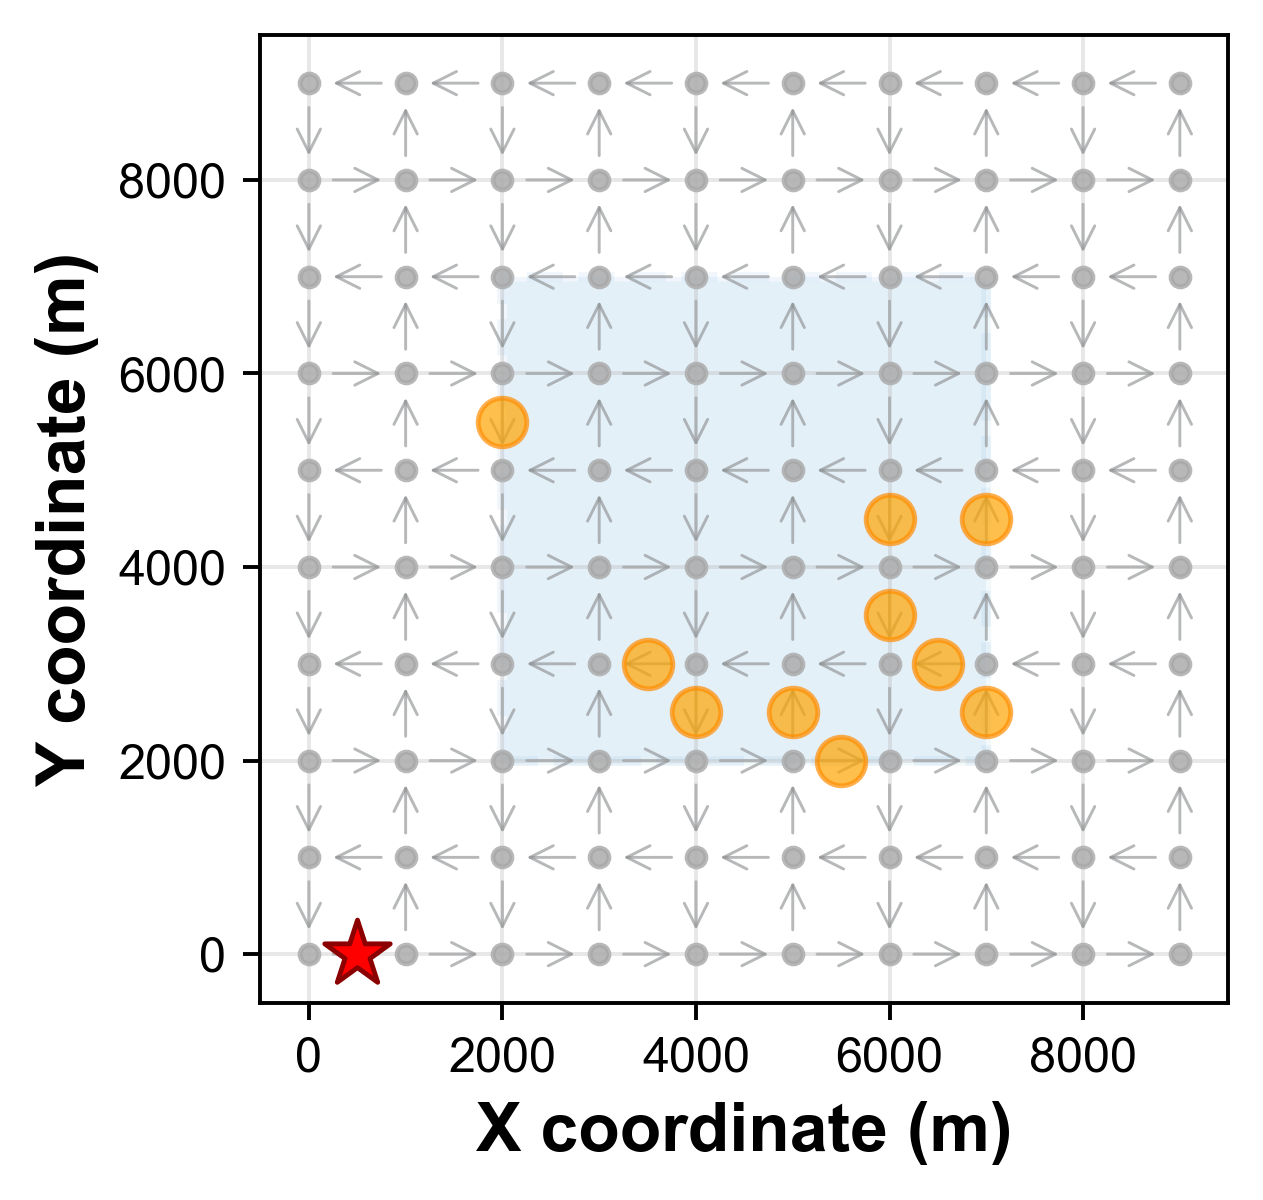

(<Figure size 1295x1295 with 1 Axes>,
 <Axes: xlabel='X coordinate (m)', ylabel='Y coordinate (m)'>)

In [305]:
''' Plot receiver locations at link midpoints for high collaboration scenario'''
figure_plot.network_locations_plot(
    network=network,
    locations_gdf=very_high_collab_ins_receiver_df,
    # Links settings
    show_links=True,
    show_nodes=True,
    use_arrows=True,
    link_color="#878A8B",
    link_alpha=0.6,
    link_linewidth=0.6,
    arrow_scale=12,
    arrow_shrink=5,
    # Nodes settings
    node_size=15,
    node_color="#A7A7A7",
    node_alpha=0.8,
    # 使用link中点定位 (新功能)
    use_link_midpoint=True,
    link_id_col='link_id',
    # Central region
    show_central_region=True,
    central_region_bounds=(2000, 2000, 5000, 5000),
    central_region_label='Central Region (2000-7000)',
    #---X/Y labels---
    xlabel='X coordinate (m)',
    ylabel='Y coordinate (m)',
    label_size=14,

    # Axis limits
    xlim=(-500, 9500),
    ylim=(-500, 9500),
    #---Title and style---
    # title='Receiver Locations at Link Midpoints (High Collaboration)',
    figure_size=(3.7, 3.7),
    dpi=350,
    show_grid=True,
    show_legend=False,
    #---Output---
    figure_folder=OUTPUT_FIG_PATH,
    filename='receiver_locations_very_high_collab_outside_random_af60_20euro.png'
)

#### High

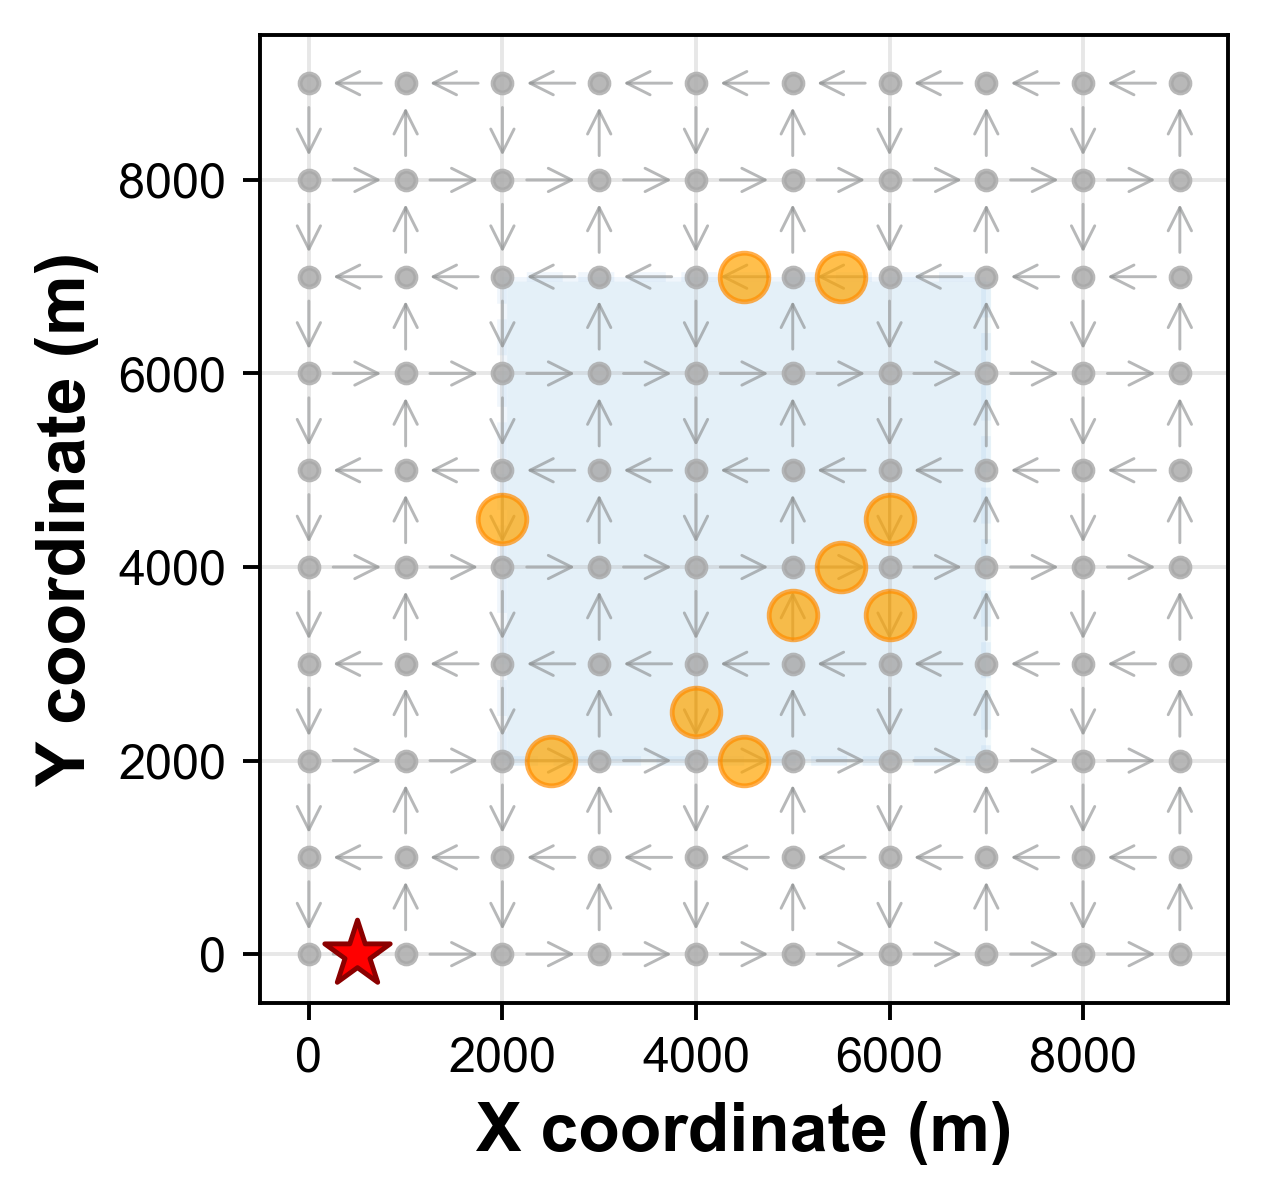

(<Figure size 1295x1295 with 1 Axes>,
 <Axes: xlabel='X coordinate (m)', ylabel='Y coordinate (m)'>)

In [362]:
''' Plot receiver locations at link midpoints for medium collaboration scenario'''

figure_plot.network_locations_plot(
    network=network,
    locations_gdf=high_collab_ins_receiver_df,
    # Links settings
    show_links=True,
    show_nodes=True,
    use_arrows=True,
    link_color="#878A8B",
    link_alpha=0.6,
    link_linewidth=0.6,
    arrow_scale=12,
    arrow_shrink=5,
    # Nodes settings
    node_size=15,
    node_color="#A7A7A7",
    node_alpha=0.8,
    # 使用link中点定位 (新功能)
    use_link_midpoint=True,
    link_id_col='link_id',
    # Central region
    show_central_region=True,
    central_region_bounds=(2000, 2000, 5000, 5000),
    central_region_label='Central Region (2000-7000)',
    #---X/Y labels---
    xlabel='X coordinate (m)',
    ylabel='Y coordinate (m)',
    label_size=14,

    # Axis limits
    xlim=(-500, 9500),
    ylim=(-500, 9500),
    #---Title and style---
    # title='Receiver Locations at Link Midpoints (High Collaboration)',
    figure_size=(3.7, 3.7),
    dpi=350,
    show_grid=True,
    show_legend=False,
    #---Output---
    figure_folder=OUTPUT_FIG_PATH,
    filename='receiver_locations_high_collab_random_af60_20euro.png'
)

#### Medium

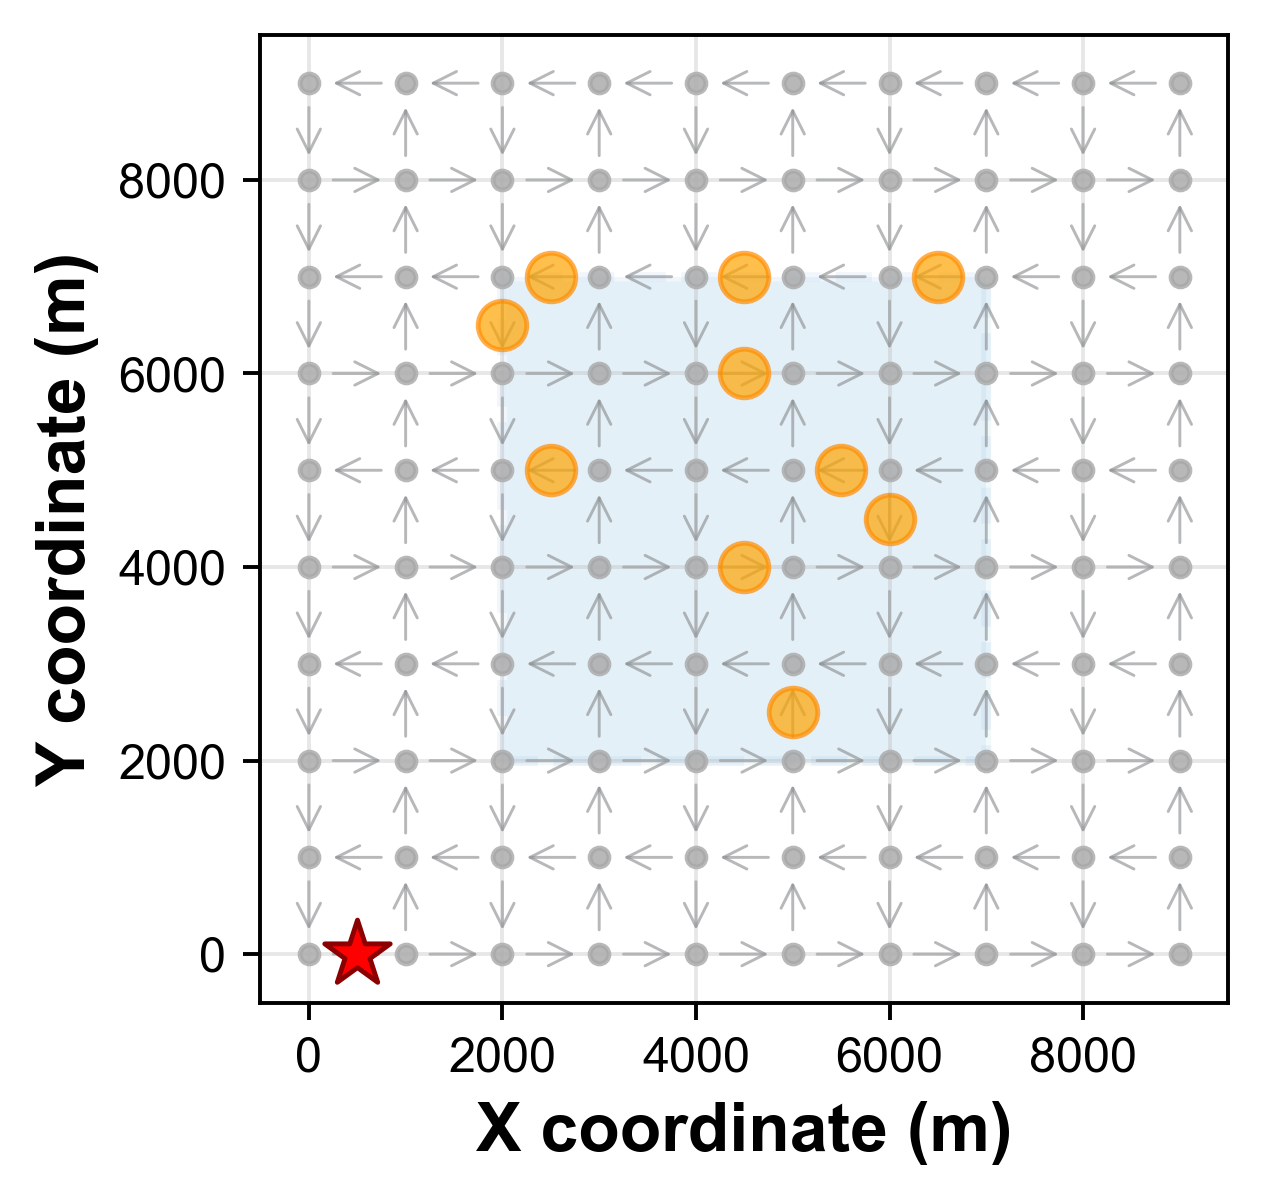

(<Figure size 1295x1295 with 1 Axes>,
 <Axes: xlabel='X coordinate (m)', ylabel='Y coordinate (m)'>)

In [346]:
''' Plot receiver locations at link midpoints for low collaboration scenario '''
figure_plot.network_locations_plot(
    network=network,
    locations_gdf=medium_collab_ins_receiver_df,
    # Links settings
    show_links=True,
    show_nodes=True,
    use_arrows=True,
    link_color="#878A8B",
    link_alpha=0.6,
    link_linewidth=0.6,
    arrow_scale=12,
    arrow_shrink=5,
    # Nodes settings
    node_size=15,
    node_color="#A7A7A7",
    node_alpha=0.8,
    # 使用link中点定位 (新功能)
    use_link_midpoint=True,
    link_id_col='link_id',
    # Central region
    show_central_region=True,
    central_region_bounds=(2000, 2000, 5000, 5000),
    central_region_label='Central Region (2000-7000)',
    #---X/Y labels---
    xlabel='X coordinate (m)',
    ylabel='Y coordinate (m)',
    label_size=14,

    # Axis limits
    xlim=(-500, 9500),
    ylim=(-500, 9500),
    #---Title and style---
    # title='Receiver Locations at Link Midpoints (Low Collaboration)',
    figure_size=(3.7, 3.7),
    dpi=350,
    show_grid=True,
    show_legend=False,
    #---Output---
    figure_folder=OUTPUT_FIG_PATH,
    filename='receiver_locations_medium_collab_random_af60_20euro.png'
)

#### Low

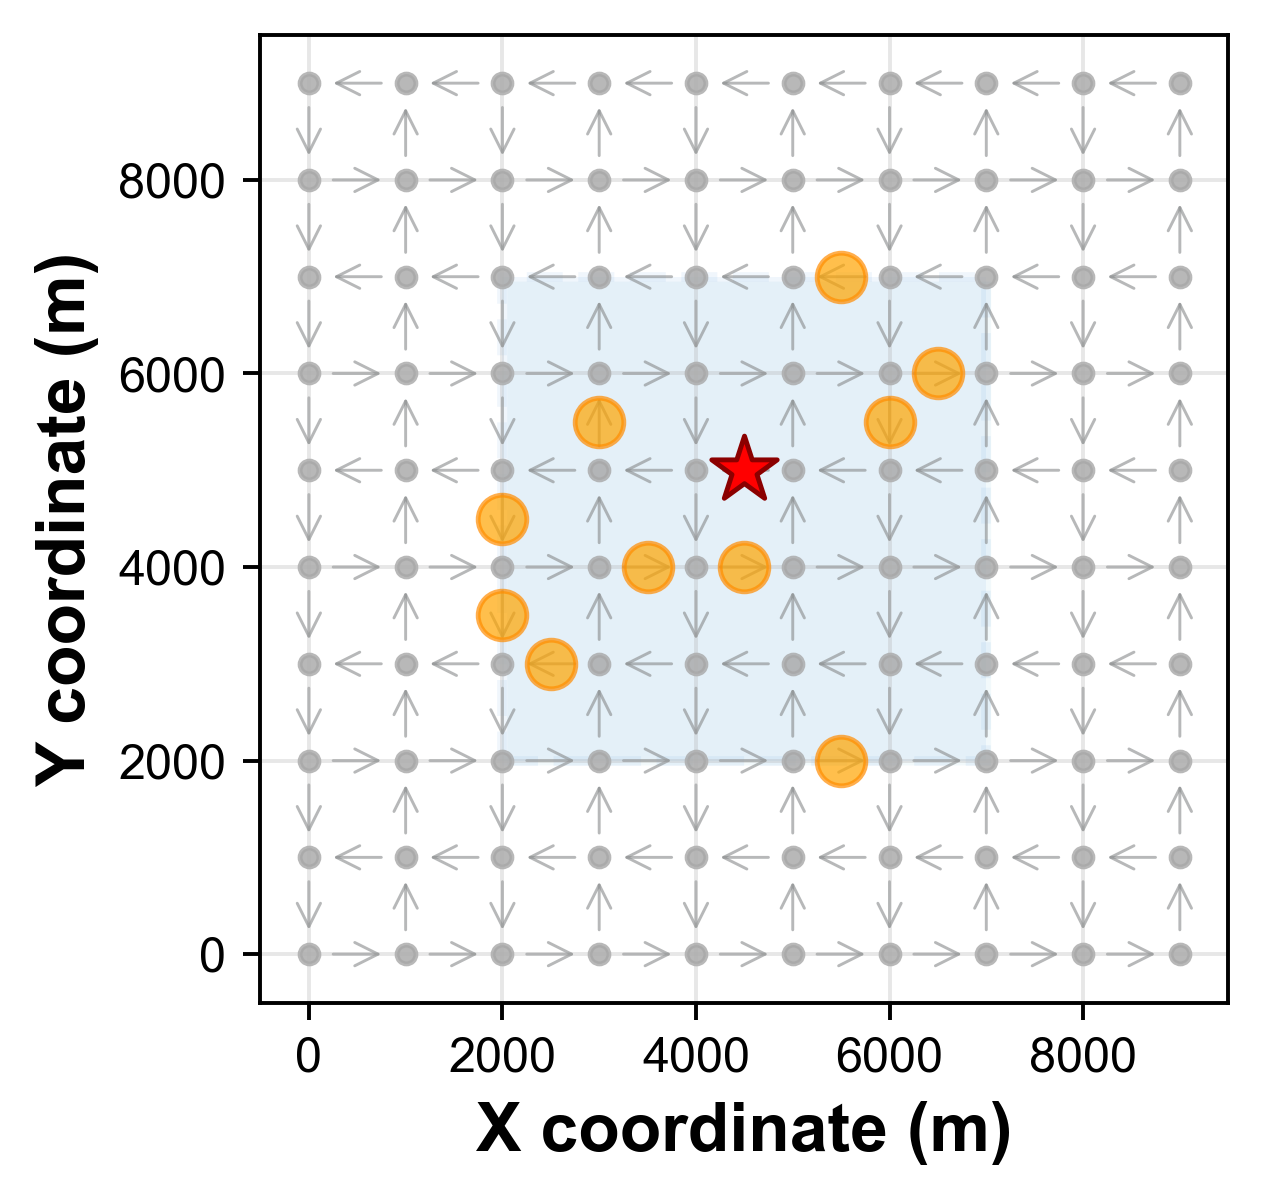

(<Figure size 1295x1295 with 1 Axes>,
 <Axes: xlabel='X coordinate (m)', ylabel='Y coordinate (m)'>)

In [326]:
''' Plot receiver locations at link midpoints for low collaboration scenario '''
figure_plot.network_locations_plot(
    network=network,
    locations_gdf=low_collab_ins_receiver_df,
    # Links settings
    show_links=True,
    show_nodes=True,
    use_arrows=True,
    link_color="#878A8B",
    link_alpha=0.6,
    link_linewidth=0.6,
    arrow_scale=12,
    arrow_shrink=5,
    # Nodes settings
    node_size=15,
    node_color="#A7A7A7",
    node_alpha=0.8,
    # 使用link中点定位 (新功能)
    use_link_midpoint=True,
    link_id_col='link_id',
    # Central region
    show_central_region=True,
    central_region_bounds=(2000, 2000, 5000, 5000),
    central_region_label='Central Region (2000-7000)',
    #---X/Y labels---
    xlabel='X coordinate (m)',
    ylabel='Y coordinate (m)',
    label_size=14,

    # Axis limits
    xlim=(-500, 9500),
    ylim=(-500, 9500),
    #---Title and style---
    # title='Receiver Locations at Link Midpoints (Low Collaboration)',
    figure_size=(3.7, 3.7),
    dpi=350,
    show_grid=True,
    show_legend=False,
    #---Output---
    figure_folder=OUTPUT_FIG_PATH,
    filename='receiver_locations_low_collab_random_af60_20euro.png'
)

#### Very low

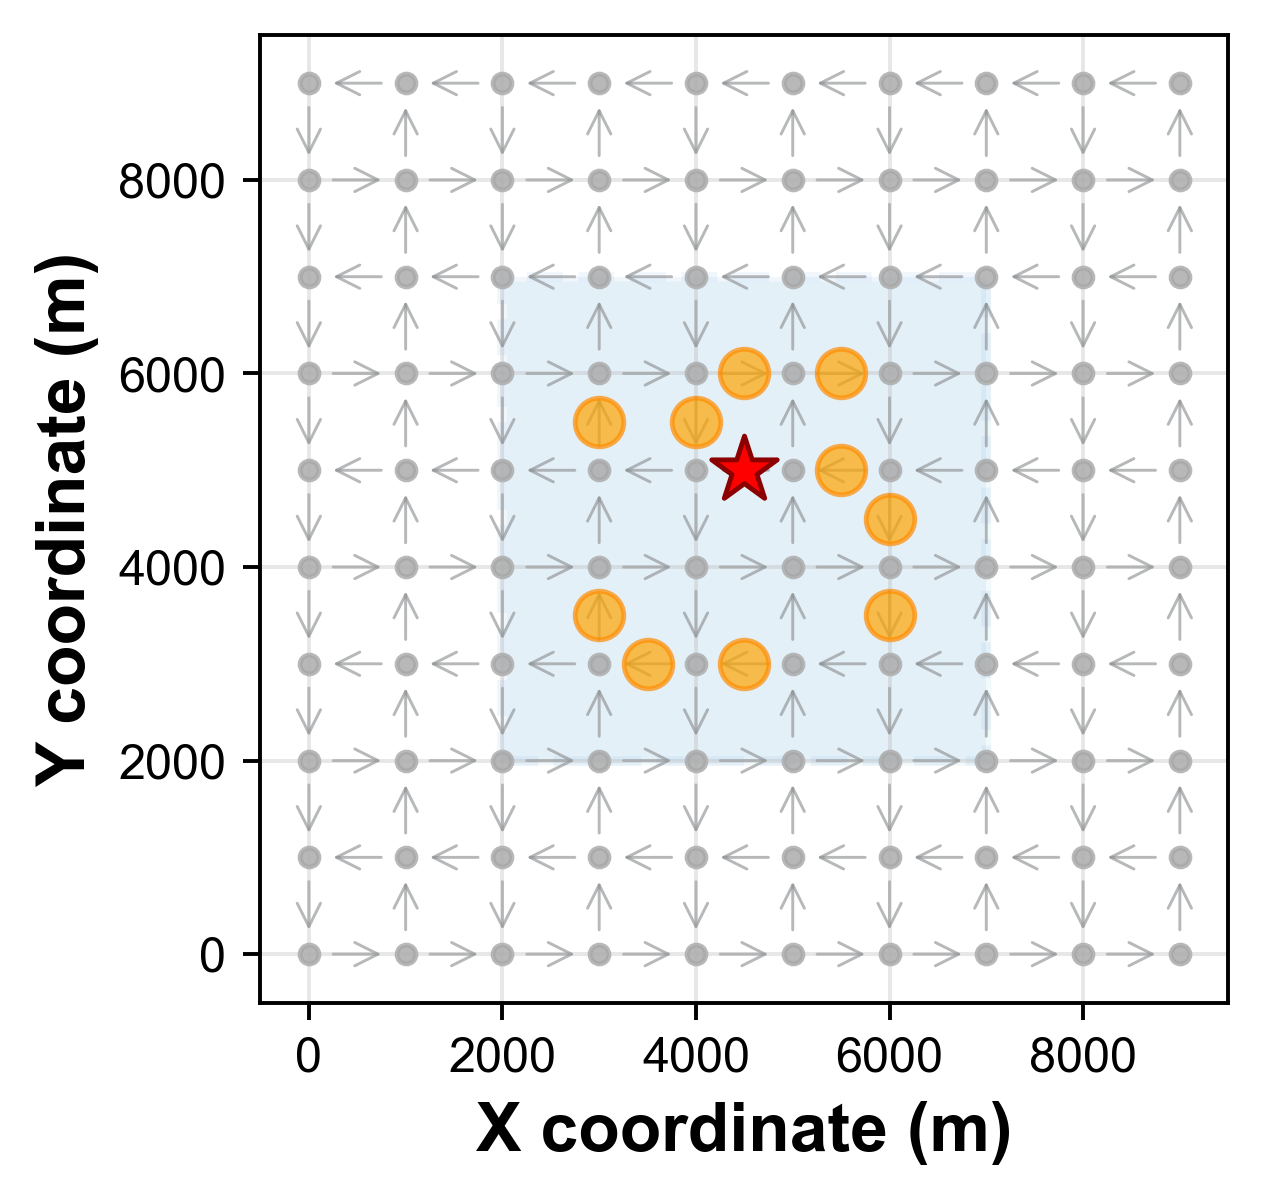

(<Figure size 1295x1295 with 1 Axes>,
 <Axes: xlabel='X coordinate (m)', ylabel='Y coordinate (m)'>)

In [336]:
''' Plot receiver locations at link midpoints for low collaboration scenario '''
figure_plot.network_locations_plot(
    network=network,
    locations_gdf=very_low_collab_ins_receiver_df,
    # Links settings
    show_links=True,
    show_nodes=True,
    use_arrows=True,
    link_color="#878A8B",
    link_alpha=0.6,
    link_linewidth=0.6,
    arrow_scale=12,
    arrow_shrink=5,
    # Nodes settings
    node_size=15,
    node_color="#A7A7A7",
    node_alpha=0.8,
    # 使用link中点定位 (新功能)
    use_link_midpoint=True,
    link_id_col='link_id',
    # Central region
    show_central_region=True,
    central_region_bounds=(2000, 2000, 5000, 5000),
    central_region_label='Central Region (2000-7000)',
    #---X/Y labels---
    xlabel='X coordinate (m)',
    ylabel='Y coordinate (m)',
    label_size=14,

    # Axis limits
    xlim=(-500, 9500),
    ylim=(-500, 9500),
    #---Title and style---
    # title='Receiver Locations at Link Midpoints (Low Collaboration)',
    figure_size=(3.7, 3.7),
    dpi=350,
    show_grid=True,
    show_legend=False,
    #---Output---
    figure_folder=OUTPUT_FIG_PATH,
    filename='receiver_locations_very_low_collab_random_af60_20euro.png'
)

### Agg statistics

In [ ]:
com_df.plot.scatter(x='collaboration_rate', y='mean_receiver_dist_to_depot_euclidean_km')


In [ ]:
com_df.plot.scatter(x='collaboration_rate', y='clustering_index_euclidean_km')



In [ ]:
com_df_collab_40_50 = com_df[
    (com_df['collaboration_rate'].between(0.4, 0.6))
]
com_df_collab_60_80 = com_df[
    (com_df['collaboration_rate'].between(0.7, 0.8))
]
com_df_collab_90_100 = com_df[
    (com_df['collaboration_rate'].between(0.7, 1.0))
]

In [ ]:
## Print the mean receiver to depot euclidean distance for each subgroup
print("the mean receiver to depot euclidean distance for subgroup 40-50% is:", com_df_collab_40_50['mean_receiver_dist_to_depot_euclidean_km'].mean())
print("the mean receiver to depot euclidean distance for subgroup 60-80% is:", com_df_collab_60_80['mean_receiver_dist_to_depot_euclidean_km'].mean())
print("the mean receiver to depot euclidean distance for subgroup 90-100% is:", com_df_collab_90_100['mean_receiver_dist_to_depot_euclidean_km'].mean())

print()
## print the mean receiver to depot road distance for each subgroup
print("the mean receiver to depot road distance for subgroup 40-50% is:", com_df_collab_40_50['mean_receiver_dist_to_depot_network_km'].mean())
print("the mean receiver to depot road distance for subgroup 60-80% is:", com_df_collab_60_80['mean_receiver_dist_to_depot_network_km'].mean())
print("the mean receiver to depot road distance for subgroup 90-100% is:", com_df_collab_90_100['mean_receiver_dist_to_depot_network_km'].mean())

print()
## Print the mean clustering_index_euclidean_km for each subgroup
print("the mean clustering_index_euclidean_km for subgroup 40-50% is:", com_df_collab_40_50['clustering_index_euclidean_km'].mean())
print("the mean clustering_index_euclidean_km for subgroup 60-80% is:", com_df_collab_60_80['clustering_index_euclidean_km'].mean())
print("the mean clustering_index_euclidean_km for subgroup 90-100% is:", com_df_collab_90_100['clustering_index_euclidean_km'].mean())

print()
### Print the mean clustering_index_network_km for each subgroup
print("the mean clustering_index_network_km for subgroup 40-50% is:", com_df_collab_40_50['clustering_index_network_km'].mean())
print("the mean clustering_index_network_km for subgroup 60-80% is:", com_df_collab_60_80['clustering_index_network_km'].mean())
print("the mean clustering_index_network_km for subgroup 90-100% is:", com_df_collab_90_100['clustering_index_network_km'].mean())

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    [com_df_collab_40_50['mean_receiver_dist_to_depot_euclidean_km'],
     com_df_collab_60_80['mean_receiver_dist_to_depot_euclidean_km'],
     com_df_collab_90_100['mean_receiver_dist_to_depot_euclidean_km']],
    labels=['40-60%', '70-80%', '90-100%'],
    patch_artist=True,
    boxprops=dict(facecolor='#8dadc3', color='black', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.6)
)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    [com_df_collab_40_50['clustering_index_euclidean_km'],
     com_df_collab_60_80['clustering_index_euclidean_km'],
     com_df_collab_90_100['clustering_index_euclidean_km']],
    labels=['40-60%', '70-80%', '90-100%'],
    patch_artist=True,
    boxprops=dict(facecolor='#8dadc3', color='black', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.6)
)

#### Read and agg NNI metric

In [ ]:
'''read all geo data from clean folder and aggregate NNI metrics'''
nni_df = agg_anls.aggregate_nni_from_clean_folder(
    str(clean_data_path),
    study_area_by_distribution={
        'CLUSTERED': 7000*7000,
        'DISPERSED': 5000*5000,
        'FULLY_RANDOM': 6000 * 6000,
    }
)
nni_df.head(10)

In [ ]:
outside_random_20_af80_nni_df = nni_df[
    (nni_df['depot_location'] == DepotLocation.OUTSIDE.value) &
    (nni_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value) &
    (nni_df['penalty'] == 0.0056) &
    (nni_df['allocation_factor'] == 0.8)
]
# merge with all_metrics_outside_random_20euro_df to get collaboration rate, etc metrics
outside_random_20_af80_nni_df = pd.merge(
    outside_random_20_af80_nni_df,
    all_metrics_outside_random_20euro_af80_df,
    left_on=['instance_id', 'penalty', 'depot_location', 'receiver_distribution', 'allocation_factor'],
    right_on=['instance', 'penalty', 'depot_location', 'receiver_distribution', 'allocation_factor'],
    how='left'
)
outside_random_20_af80_nni_df

In [ ]:
outside_random_20_af80_nni_df.plot.scatter(x='nni',
                                      y='collaboration_rate')

In [ ]:
# Box plot NNI by collaboration_rate subgroups
bins = [0, 0.39, 0.51, 0.8, 1.1]
labels = ['0-0.39', '0.40-0.61', '0.62-0.79', '0.80-1.0']
outside_random_20_af80_nni_df['collab_group'] = pd.cut(
    outside_random_20_af80_nni_df['collaboration_rate'], 
    bins=bins, 
    labels=labels,
    include_lowest=True
)

fig, ax = plt.subplots(figsize=(10, 6))
outside_random_20_af80_nni_df.boxplot(column='nni', by='collab_group', ax=ax)
ax.set_xlabel('Collaboration Rate Group')
ax.set_ylabel('NNI (Nearest Neighbor Index)')
ax.set_title('NNI Distribution by Collaboration Rate Subgroups')
plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

# Spatial sensitivity
For this part, we probably need to 
1. first plot the box plots for penalty-sweep and af-sweep across scenarios, to demonstrate/prove the patterns are consistent to the above **cost-benefit sensitivity**.
2. Then, dive into one particular AF-Pen setting group (e.g., af=0.6, pen=0.0056; be consistent with the previous one?). To mainly explore the correlations between spatial index and other key metrics (e.g., total cost savings)
3. Since the clustering index looks irrelevant (little correlated) to other metrics, it is necessary to find another way to demonstrate the power of receivers' spatial distributions.

In [253]:
ins_spatial_index_df = agg_anls.aggregate_nni_from_clean_folder(
    clean_folder_path=OUTPUT_PATH,
    study_area_by_distribution={
        ReceiverDistribution.CLUSTERED.value: 5000*5000,
        ReceiverDistribution.RANDOM.value: 5000*5000,
        ReceiverDistribution.DISPERSED.value: 9000*9000
    },
    network_node_df=network_nodes,
    network_link_df=network_links,
    network_graph=network_graph,
    verbose=True
)
ins_spatial_index_df

Found 17160 scenario folders in f:\gitRepository\matsim-libs-2024\data\freightChessboardRC\clean


Processing NNI: 100%|██████████| 17160/17160 [03:30<00:00, 81.48it/s]


Processed NNI for 17160 scenarios successfully.


,depot_location,receiver_distribution,allocation_factor,penalty,instance_id,nni,mean_observed_distance,mean_expected_distance,z_score,p_value,pattern,n_receivers,study_area,centroid_to_depot_euclidean_km,centroid_to_depot_network_km
0,center,CLUSTERED,0.5,0.000,0,1.190814,941.421356,790.569415,1.154361,0.248352,random,10,25000000,1.303840,3.0
1,center,CLUSTERED,0.5,0.000,1,1.064323,841.421356,790.569415,0.389133,0.697178,random,10,25000000,1.897367,5.0
2,center,CLUSTERED,0.5,0.000,2,0.937832,741.421356,790.569415,-0.376095,0.706846,random,10,25000000,1.252996,2.0
3,center,CLUSTERED,0.5,0.000,3,1.264911,1000.000000,790.569415,1.602622,0.109018,dispersed,10,25000000,1.529706,2.0
4,center,CLUSTERED,0.5,0.000,4,1.190814,941.421356,790.569415,1.154361,0.248352,random,10,25000000,1.334166,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17155,left,FULLY_RANDOM,0.9,0.028,55,0.758947,600.000000,790.569415,-1.458291,0.144760,clustered,10,25000000,4.750789,7.0
17156,left,FULLY_RANDOM,0.9,0.028,56,1.369700,1082.842712,790.569415,2.236557,0.025315,dispersed,10,25000000,5.547071,10.0
17157,left,FULLY_RANDOM,0.9,0.028,57,1.769700,1399.070478,790.569415,4.656421,0.000003,dispersed,10,25000000,6.481512,9.0
17158,left,FULLY_RANDOM,0.9,0.028,58,0.841201,665.028154,790.569415,-0.960677,0.336715,random,10,25000000,6.044005,9.0


In [363]:
spatial_cols = ['depot_location', 'receiver_distribution', 'allocation_factor', 'penalty', 'instance_id',
                'nni', 'pattern', 'centroid_to_depot_euclidean_km', 'centroid_to_depot_network_km']

all_metrics_df = pd.merge(
    all_metrics_df,
    ins_spatial_index_df[spatial_cols],
    left_on=['depot_location', 'receiver_distribution', 'allocation_factor', 'penalty', 'instance'],
    right_on=['depot_location', 'receiver_distribution', 'allocation_factor', 'penalty', 'instance_id'],
    how='left'
)
all_metrics_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,instance_id_x,diff_fleet_size,final_fleet_size,penalty_std,collaboration_rate,instance_id_y,nni,pattern,centroid_to_depot_euclidean_km,centroid_to_depot_network_km
0,center,CLUSTERED,0.5,0.0000,0,2,2,533.865333,346.8322,10,...,0.0,-2.0,2.0,0,1.0,0.0,1.190814,random,1.303840,3.0
1,center,CLUSTERED,0.5,0.0000,1,2,2,479.119950,342.5000,10,...,1.0,-2.0,2.0,0,1.0,1.0,1.064323,random,1.897367,5.0
2,center,CLUSTERED,0.5,0.0000,2,2,2,514.799819,368.6931,10,...,2.0,-2.0,2.0,0,1.0,2.0,0.937832,random,1.252996,2.0
3,center,CLUSTERED,0.5,0.0000,3,2,2,542.640463,362.3857,10,...,3.0,-2.0,2.0,0,1.0,3.0,1.264911,dispersed,1.529706,2.0
4,center,CLUSTERED,0.5,0.0000,4,2,2,503.215238,328.7115,10,...,4.0,-2.0,2.0,0,1.0,4.0,1.190814,random,1.334166,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21415,left,FULLY_RANDOM,0.8,0.0417,5,2,2,71.885500,74.0951,0,...,NaN,NaN,NaN,150,0.0,NaN,NaN,NaN,NaN,NaN
21416,left,FULLY_RANDOM,0.8,0.0417,6,2,2,95.217700,95.2177,0,...,NaN,NaN,NaN,150,0.0,NaN,NaN,NaN,NaN,NaN
21417,left,FULLY_RANDOM,0.8,0.0417,7,2,2,22.637300,-8.3577,0,...,NaN,NaN,NaN,150,0.0,NaN,NaN,NaN,NaN,NaN
21418,left,FULLY_RANDOM,0.8,0.0417,8,2,2,27.199800,58.4445,0,...,NaN,NaN,NaN,150,0.0,NaN,NaN,NaN,NaN,NaN


In [364]:
specific_anls_af = 0.6
specific_anls_penalty = 0.0056

In [367]:
ins_center_clustered_specific_anls_df = all_metrics_df[
    (all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) &
    (all_metrics_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value) &
    (all_metrics_df['allocation_factor'] == specific_anls_af) &
    (all_metrics_df['penalty'] == specific_anls_penalty)
    ]

ins_center_dispersed_specific_anls_df = all_metrics_df[
    (all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) &
    (all_metrics_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value) &
    (all_metrics_df['allocation_factor'] == specific_anls_af) &
    (all_metrics_df['penalty'] == specific_anls_penalty)
    ]

ins_outside_clustered_specific_anls_df = all_metrics_df[
    (all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) &
    (all_metrics_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value) &
    (all_metrics_df['allocation_factor'] == specific_anls_af) &
    (all_metrics_df['penalty'] == specific_anls_penalty)
    ]

ins_outside_dispersed_specific_anls_df = all_metrics_df[
    (all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) &
    (all_metrics_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value) &
    (all_metrics_df['allocation_factor'] == specific_anls_af) &
    (all_metrics_df['penalty'] == specific_anls_penalty)
    ]


### Test for GLM

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:

# df = pd.concat([
#     ins_center_clustered_specific_anls_df,
#     ins_center_dispersed_specific_anls_df,
#     ins_outside_clustered_specific_anls_df,
#     ins_outside_dispersed_specific_anls_df
# ], ignore_index=True)

df = all_metrics_df.query("allocation_factor == 0.6")

# =========
# 2) set up binomial response: k successes out of N trials
# =========
N_TRIALS = 10
df["k"] = df["num_collaborative_receivers"].astype(int)
df["n"] = N_TRIALS
df["y"] = df["k"] / df["n"]  # proportion

# =========
# 3) predictors you mentioned
# depot: 0=centered, 1=outside (in your file: 'center' vs 'left')
# =========
df["depot"] = (df["depot_location"].str.lower() != "center").astype(int)

# choose cost column
# - penalty_std looks like "€/hour" (e.g., 20/35/50)
# - penalty looks like "€/sec" (e.g., 20/3600 = 0.00556)
cost_col = "penalty_std" if "penalty_std" in df.columns else "penalty"
df["cost"] = df[cost_col].astype(float)

# choose distance column (pick one)
dist_col = "centroid_to_depot_network_km"  # or "centroid_to_depot_network_km"
df["dist"] = df[dist_col].astype(float)

df["nni"] = df["nni"].astype(float)

# =========
# 4) safe z-score helper (avoids NaN if a column is constant in your sample)
# =========
def safe_z(series: pd.Series) -> pd.Series:
    mu = float(np.nanmean(series))
    sd = float(np.nanstd(series))
    if sd == 0 or np.isnan(sd):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - mu) / sd

df["cost_z"] = safe_z(df["cost"])
df["nni_z"]  = safe_z(df["nni"])
df["dist_z"] = safe_z(df["dist"])

# =========
# 5) choose how to treat cost
# If you only have a few discrete cost levels (10/20/35/50), treat it as categorical
# =========
if df["cost"].nunique() <= 6:
    cost_term = "C(cost)"      # categorical (recommended for your boxplot-like behavior)
else:
    cost_term = "cost_z"       # continuous

# =========
# 6) GLM formula (edit here)
# =========
# - cost_term * depot expands to: cost + depot + cost:depot
# - nni_z * depot expands to: nni_z + depot + nni_z:depot
#   (depot is already included, but that's fine; statsmodels handles it)
# formula = f"y ~ {cost_term} * depot + nni_z * depot + dist_z"
formula = f"y ~ {cost_term} * depot * nni_z + dist_z"
# =========
# 7) fit Binomial GLM with freq_weights = number of trials (N=10)
# robust SE (HC1) is helpful if you later worry about mild misspecification
# =========
model = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(),
    freq_weights=df["n"],
)

res = model.fit(cov_type="HC1")
print(res.summary())

# =========
# 8) optional: predicted collaboration probability for each instance
# =========
df["p_hat"] = res.predict(df)
print(df[["k", "n", "y", "p_hat", "cost", "depot", "nni", "dist"]].head())

In [ ]:
# ========== 1) choose the cost levels to plot ==========
# Prefer explicit levels (as you requested)
cost_levels = [10, 20, 35, 50]

# If your dataset has different/extra levels, you can uncomment this:
# cost_levels = sorted(df["cost"].unique())

# ========== 2) compute z-score scaling consistent with your fit ==========
# IMPORTANT: match how you created z-scores when fitting.
# In your earlier code you used np.nanstd (ddof=0), so we use ddof=0 here.
cost_mean = float(np.nanmean(df["cost"]))
cost_std  = float(np.nanstd(df["cost"]))  # ddof=0

# If you fitted using existing df["nni_z"] and df["dist_z"], skip these.
# Otherwise compute from raw nni/dist columns.
if "nni_z" in df.columns:
    nni_mean = float(np.nanmean(df["nni_z"]))  # should be ~0
    nni_std  = float(np.nanstd(df["nni_z"]))   # should be ~1
else:
    nni_mean = float(np.nanmean(df["nni"]))
    nni_std  = float(np.nanstd(df["nni"]))

if "dist_z" in df.columns:
    dist_mean = float(np.nanmean(df["dist_z"]))  # should be ~0
    dist_std  = float(np.nanstd(df["dist_z"]))   # should be ~1
else:
    # choose the same dist column you used in fitting
    # e.g., df["centroid_to_depot_euclidean_km"] or df["centroid_to_depot_network_km"]
    dist_col = "dist"
    dist_mean = float(np.nanmean(df[dist_col]))
    dist_std  = float(np.nanstd(df[dist_col]))

def zscore(x, mean, std):
    if std == 0 or np.isnan(std):
        return np.zeros_like(np.asarray(x, dtype=float))
    return (np.asarray(x, dtype=float) - mean) / std

# ========== 3) build prediction grid ==========
# We draw lines for depot in {0(center),1(outside)} and NNI_z in {-1,0,1}
nni_levels_z = [-1.0, 0.0, 1.0]  # low / medium / high (in SD units)

grid = []
for depot in [0, 1]:
    for nni_z_val in nni_levels_z:
        for c in cost_levels:
            row = {
                "cost": c,  # keep original cost for plotting / for C(cost) models
                "cost_z": zscore([c], cost_mean, cost_std)[0],  # for continuous-cost_z models
                "depot": depot,
                "nni_z": nni_z_val,
                "dist_z": 0.0,  # hold distance at mean (z=0). Change if you want.
            }
            grid.append(row)

pred_df = pd.DataFrame(grid)

# If your model used raw nni/dist (not z), provide them too (harmless if unused)
if "nni" in df.columns and "nni_z" not in df.columns:
    pred_df["nni"] = pred_df["nni_z"] * nni_std + nni_mean
if "dist" in df.columns and "dist_z" not in df.columns:
    pred_df["dist"] = pred_df["dist_z"] * dist_std + dist_mean

# ========== 4) prediction + CI ==========
# For models fitted with formula API, passing a DataFrame works (patsy rebuilds X)
pred_res = res.get_prediction(pred_df)
sf = pred_res.summary_frame(alpha=0.05)  # mean, mean_ci_lower, mean_ci_upper, etc.

pred_df = pd.concat([pred_df, sf], axis=1)

# ========== 5) plot ==========
# We'll plot predicted cooperation probability p_hat (= collaboration rate),
# with 95% CI as shaded band.
fig = plt.figure(figsize=(9, 6))

def nice_label(depot, nni_z_val):
    depot_str = "center" if depot == 0 else "outside"
    if nni_z_val == -1:
        nni_str = "low NNI (-1 SD)"
    elif nni_z_val == 0:
        nni_str = "mid NNI (0 SD)"
    else:
        nni_str = "high NNI (+1 SD)"
    return f"{depot_str}, {nni_str}"

for depot in [0, 1]:
    for nni_z_val in nni_levels_z:
        sub = pred_df[(pred_df["depot"] == depot) & (pred_df["nni_z"] == nni_z_val)].copy()
        sub = sub.sort_values("cost")

        x = sub["cost"].to_numpy()
        y = sub["mean"].to_numpy()
        lo = sub["mean_ci_lower"].to_numpy()
        hi = sub["mean_ci_upper"].to_numpy()

        plt.plot(x, y, marker="o", label=nice_label(depot, nni_z_val))
        plt.fill_between(x, lo, hi, alpha=0.15)

plt.xlabel("Cost (original units, e.g., 10/20/35/50)")
plt.ylabel("Predicted collaboration rate (p)")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend(title="Depot & NNI level", frameon=True)
plt.tight_layout()

# Save if you want:
# plt.savefig("predicted_collaboration_curves.png", dpi=300, bbox_inches="tight")
plt.show()

### GAM
To explore the nonlinear correlations between collaboration rate and spatial metrics (including the joint impact)

In [27]:
gam_af60_pen20_df = all_metrics_df[(all_metrics_df['penalty'] == 0.0056) &
                                   (all_metrics_df['allocation_factor'] == 0.6) &
                                   (all_metrics_df['receiver_distribution'] != ReceiverDistribution.RANDOM.value)]
gam_af60_df = all_metrics_df[(all_metrics_df['allocation_factor'] == 0.6) &
                             (all_metrics_df['receiver_distribution'] != ReceiverDistribution.RANDOM.value)]

#### Collab. rate (with cost)

In [ ]:
reg_df = gam_af60_df.copy(deep=True)

N_TRIALS = 10
reg_df["k"] = reg_df["num_collaborative_receivers"].astype(int)

# depot dummy: 0=center, 1=outside
reg_df["depot"] = (reg_df["depot_location"].str.lower() != "center").astype(int)

# cost
cost_col = "penalty_std" if "penalty_std" in reg_df.columns else "penalty"
reg_df["cost"] = reg_df[cost_col].astype(int)

# distance (pick one)
dist_col = "centroid_to_depot_network_km"  # or "centroid_to_depot_network_km"
reg_df["dist_centroid"] = reg_df[dist_col].astype(float)

reg_df["nni"] = reg_df["nni"].astype(float)

reg_df['mean_rc_dist'] = reg_df['mean_receiver_dist_to_depot_network_km'].astype(float)

# =========
# 1) expand each instance into N_TRIALS binary observations
# =========
X_inst = reg_df[["cost", "depot", "nni", "dist_centroid", "mean_rc_dist"]].to_numpy()
X = np.repeat(X_inst, N_TRIALS, axis=0)

y = np.concatenate([
    np.repeat([1, 0], [k, N_TRIALS - k])
    for k in reg_df["k"].to_numpy()
])

# =========
# 2) standardize continuous columns (cost, nni, dist) to help GAM fitting
# depot stays 0/1
# =========
cont_idx = [0, 2, 3, 4]  # indices of cost, nni, dist_centroid, mean_rc_dist in X
scaler = {}
for j in cont_idx:
    mu = X[:, j].mean()
    sd = X[:, j].std()
    scaler[j] = (mu, sd)
    if sd > 0:
        X[:, j] = (X[:, j] - mu) / sd
    else:
        X[:, j] = 0.0  # if constant in sample



In [ ]:
''' Fit a GAM model with '''
gam = LogisticGAM(
    s(0)          # smooth term for cost
    # +f(1)          # factor term for depot (0/1)
    +s(2)           # smooth term for nni
    # +s(3)           # smooth term for dist_centroid
    +s(4)           # smooth term for mean_rc_dist
    +te(2, 4)  
    # +te(2, 4, by=1)        # interaction between NNI and mean receiver distance to depot, varying by depot
)

fitted_scores = gam.gridsearch(X, y, 
                               progress=False,
                               #return_scores=True
                               )
print(f'fitted_scores: {fitted_scores}')
print(f"gam confidence intervals:\n{gam.confidence_intervals(X)}")
# print(f"gam significance:\n{gam.significance()}")
print("GAM summary:")
print(gam.summary())
print("GAM statistics:")
print(gam.statistics_)
print(gam.coef_)


In [ ]:
feature_names = ["Cost", 
                "Depot", 
                 "NNI", 
                "Dist. centroid", 
                 "Depot proximity",]

# Plot selected features with custom styling
# figure_plot.plot_partial_dependence(
#     gam, feature_names, scaler,
#     features=[0, 2, 4],  # indices of features to plot
#     line_color="darkgreen", ci_color="green", ci_alpha=0.15,
#     title_fontsize=16, label_fontsize=14,
# )

figure_plot.plot_partial_dependence(
    gam, feature_names, scaler,
    # features=[0, 2, 4],  # indices of features to plot
    line_color="#7577A8", ci_color="#8789B7", ci_alpha=0.15,
    cmap=(["#3A6A88", "#83A7BE", "#B3CEDE"],   # neg → 0
          ["#F5CECE", "#AC575F", "#702F35"]),
    colorbar_label="Effect on collaboration rate",
    colorbar_shrink=1,
    # ylabel = "Effect on collab. rate",
    label_fontweight='bold',
    label_fontsize=14,
    show_title=False,
    show_legend=False,
    dpi=350,
    #---output---
    figsize_1d=(4, 2.5),
    figsize_2d=(8, 6.5),
    # output_dir=OUTPUT_FIG_PATH,
    file_prefix='gam_collab_rate_cost_af60',
    file_format='png',
)

#### Collab rate (without cost)

In [ ]:
reg_df = gam_af60_pen20_df.copy()

N_TRIALS = 10
reg_df["k"] = reg_df["num_collaborative_receivers"].astype(int)

# depot dummy: 0=center, 1=outside
reg_df["depot"] = (reg_df["depot_location"].str.lower() != "center").astype(int)

# cost
cost_col = "penalty_std" if "penalty_std" in reg_df.columns else "penalty"
reg_df["cost"] = reg_df[cost_col].astype(int)

# distance (pick one)
dist_col = "centroid_to_depot_network_km"  # or "centroid_to_depot_network_km"
reg_df["dist_centroid"] = reg_df[dist_col].astype(float)

reg_df["nni"] = reg_df["nni"].astype(float)

reg_df['mean_rc_dist'] = reg_df['mean_receiver_dist_to_depot_network_km'].astype(float)

# =========
# 1) expand each instance into N_TRIALS binary observations
# =========
X_inst = reg_df[["cost", "depot", "nni", "dist_centroid", "mean_rc_dist"]].to_numpy()
X = np.repeat(X_inst, N_TRIALS, axis=0)

y = np.concatenate([
    np.repeat([1, 0], [k, N_TRIALS - k])
    for k in reg_df["k"].to_numpy()
])

# =========
# 2) standardize continuous columns (cost, nni, dist) to help GAM fitting
# depot stays 0/1
# =========
cont_idx = [0, 2, 3, 4]  # indices of cost, nni, dist_centroid, mean_rc_dist in X
scaler = {}
for j in cont_idx:
    mu = X[:, j].mean()
    sd = X[:, j].std()
    scaler[j] = (mu, sd)
    if sd > 0:
        X[:, j] = (X[:, j] - mu) / sd
    else:
        X[:, j] = 0.0  # if constant in sample



In [ ]:
''' Fit a GAM model with '''
gam = LogisticGAM(
    # s(0)          # smooth term for cost
    # +f(1)          # factor term for depot (0/1)
    s(2)           # smooth term for nni
    # +s(3)           # smooth term for dist_centroid
    +s(4)           # smooth term for mean_rc_dist
    +te(2, 4)  
    # +te(2, 4, by=1)        # interaction between NNI and mean receiver distance to depot, varying by depot
)

fitted_scores = gam.gridsearch(X, y, 
                               progress=False,
                               #return_scores=True
                               )
print(f'fitted_scores: {fitted_scores}')
print(f"gam confidence intervals:\n{gam.confidence_intervals(X)}")
# print(f"gam significance:\n{gam.significance()}")
print("GAM summary:")
print(gam.summary())
print("GAM statistics:")
print(gam.statistics_)


In [ ]:
feature_names = ["cost", "depot", "nni", "dist_centroid", "mean_rc_dist"]

# Plot all features
figure_plot.plot_partial_dependence(gam, feature_names, scaler)


#### Whether collab (with cost)

In [28]:

reg_df = gam_af60_df.copy(deep=True)

reg_df["k"] = reg_df["total_cost_savings"].astype(float)

# depot dummy: 0=center, 1=outside
reg_df["depot"] = (reg_df["depot_location"].str.lower() != "center").astype(int)

# cost
cost_col = "penalty_std" if "penalty_std" in reg_df.columns else "penalty"
reg_df["cost"] = reg_df[cost_col].astype(int)

# distance (pick one)
dist_col = "centroid_to_depot_network_km"  # or "centroid_to_depot_network_km"
reg_df["dist_centroid"] = reg_df[dist_col].astype(float)

reg_df["nni"] = reg_df["nni"].astype(float)

reg_df['mean_rc_dist'] = reg_df['mean_receiver_dist_to_depot_network_km'].astype(float)

reg_df['is_collab'] = (reg_df['num_collaborative_receivers'] > 0).astype(int)  # binary indicator for any collaboration

# =========
# 1) expand each instance into N_TRIALS binary observations
# =========
X = reg_df[["cost", "depot", "nni", "dist_centroid", "mean_rc_dist"]].to_numpy()


y = reg_df["k"].to_numpy()  # total_cost_savings as continuous response for regression GAM
y_binary = reg_df['is_collab'].to_numpy()  # binary response for classification GAM
# =========
# 2) standardize continuous columns (cost, nni, dist) to help GAM fitting
# depot stays 0/1
# =========
cont_idx = [0, 2, 3, 4]  # indices of cost, nni, dist_centroid, mean_rc_dist in X
scaler = {}
for j in cont_idx:
    mu = X[:, j].mean()
    sd = X[:, j].std()
    scaler[j] = (mu, sd)
    if sd > 0:
        X[:, j] = (X[:, j] - mu) / sd
    else:
        X[:, j] = 0.0  # if constant in sample



In [29]:
''' Fit a LogisticGAM model — adding y(0,1)-total_cost_savings 0 or >0 as binary response'''

gam = LogisticGAM(
    s(0)          # smooth term for cost
    # +f(1)          # factor term for depot (0/1)
    +s(2)           # smooth term for nni
    # +s(3)           # smooth term for dist_centroid
    +s(4)           # smooth term for mean_rc_dist
    +te(2, 4)        # interaction between NNI and mean receiver distance to depot, varying by depot
    # +te(2, 3)  
    # +te(2, 4, by=1)        # interaction between NNI and mean receiver distance to depot, varying by depot
)

# Use gridsearch with higher lambda range to avoid divergence (no need to call fit separately)
fitted_scores = gam.gridsearch(X, y_binary, 
                               lam=np.logspace(-1, 4, 20),
                               progress=False,
                               )
print(f'fitted_scores: {fitted_scores}')
print(f"gam confidence intervals:\n{gam.confidence_intervals(X)}")
print("GAM summary:")
print(gam.summary())
print("GAM statistics:")
print(gam.statistics_)

fitted_scores: LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=s(0) + s(2) + s(4) + te(2, 4) + intercept, tol=0.0001, 
   verbose=False)
gam confidence intervals:
[[0.99944555 0.99999955]
 [0.99949979 0.99999961]
 [0.99868751 0.9999989 ]
 ...
 [0.05257988 0.15207879]
 [0.07729319 0.21069556]
 [0.0601334  0.19013047]]
GAM summary:
LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     18.4231
Link Function:                        LogitLink Log Likelihood:                                  -479.1964
Number of Samples:                         2200 AIC:                                              995.2389
                                                AICc:                       

C:\Users\Xander\AppData\Local\Temp\ipykernel_39168\1397848245.py:22: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


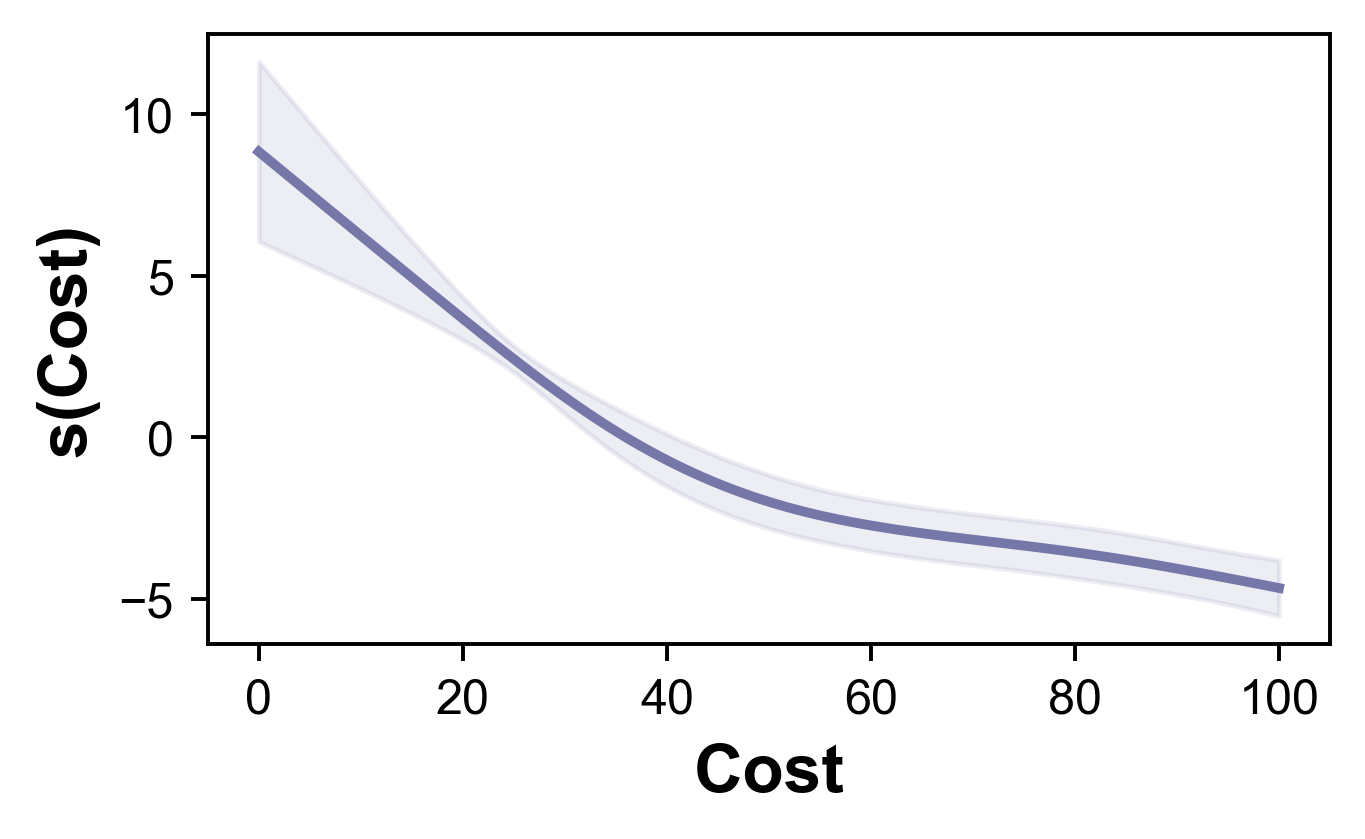

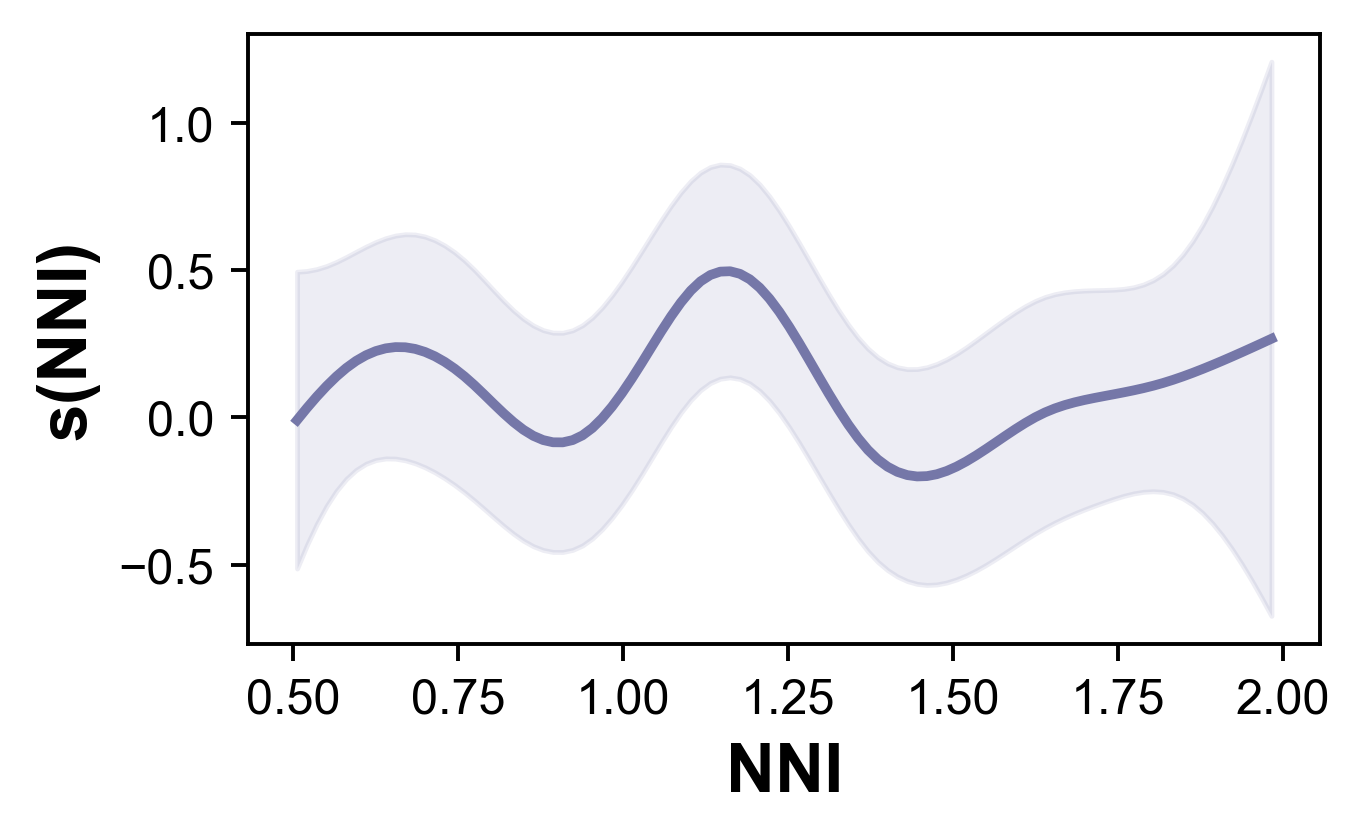

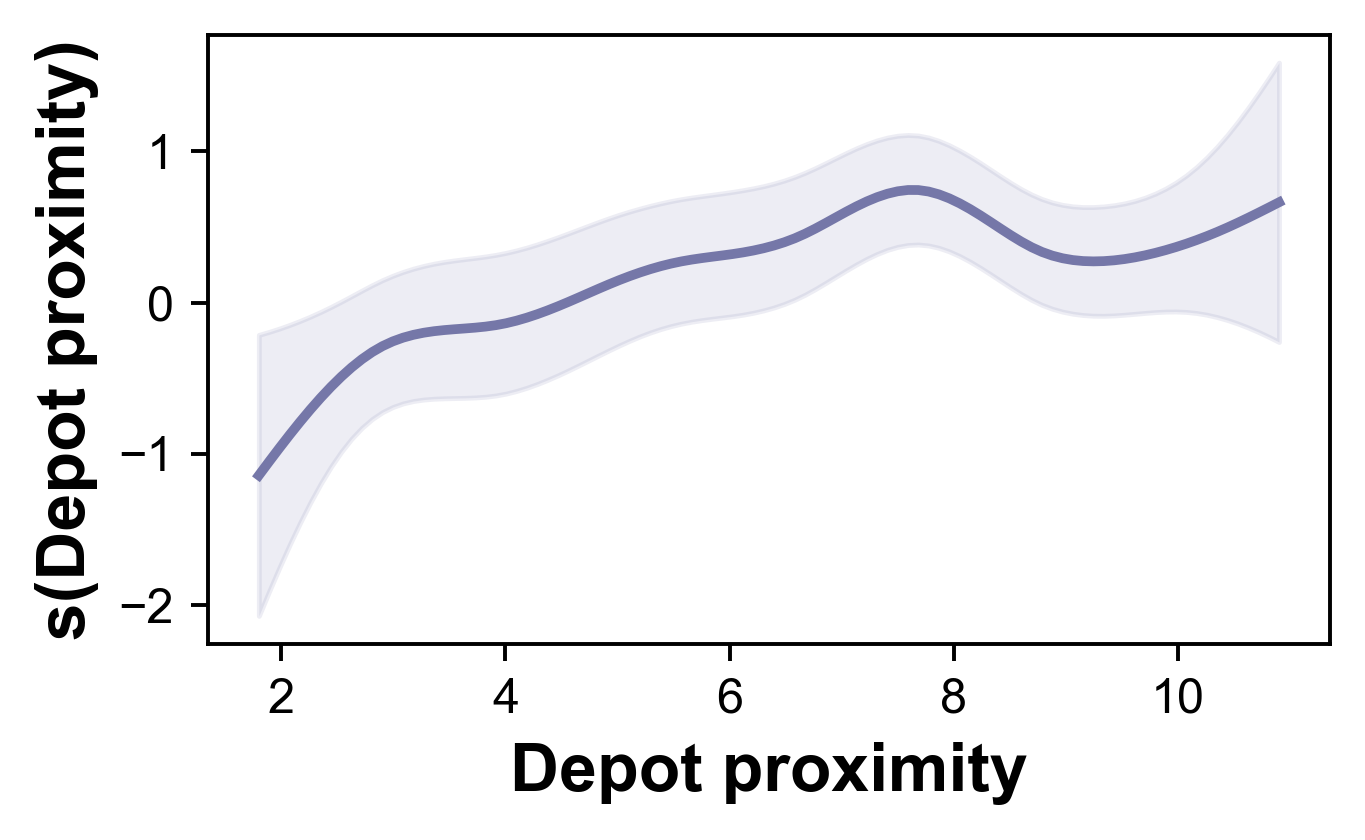

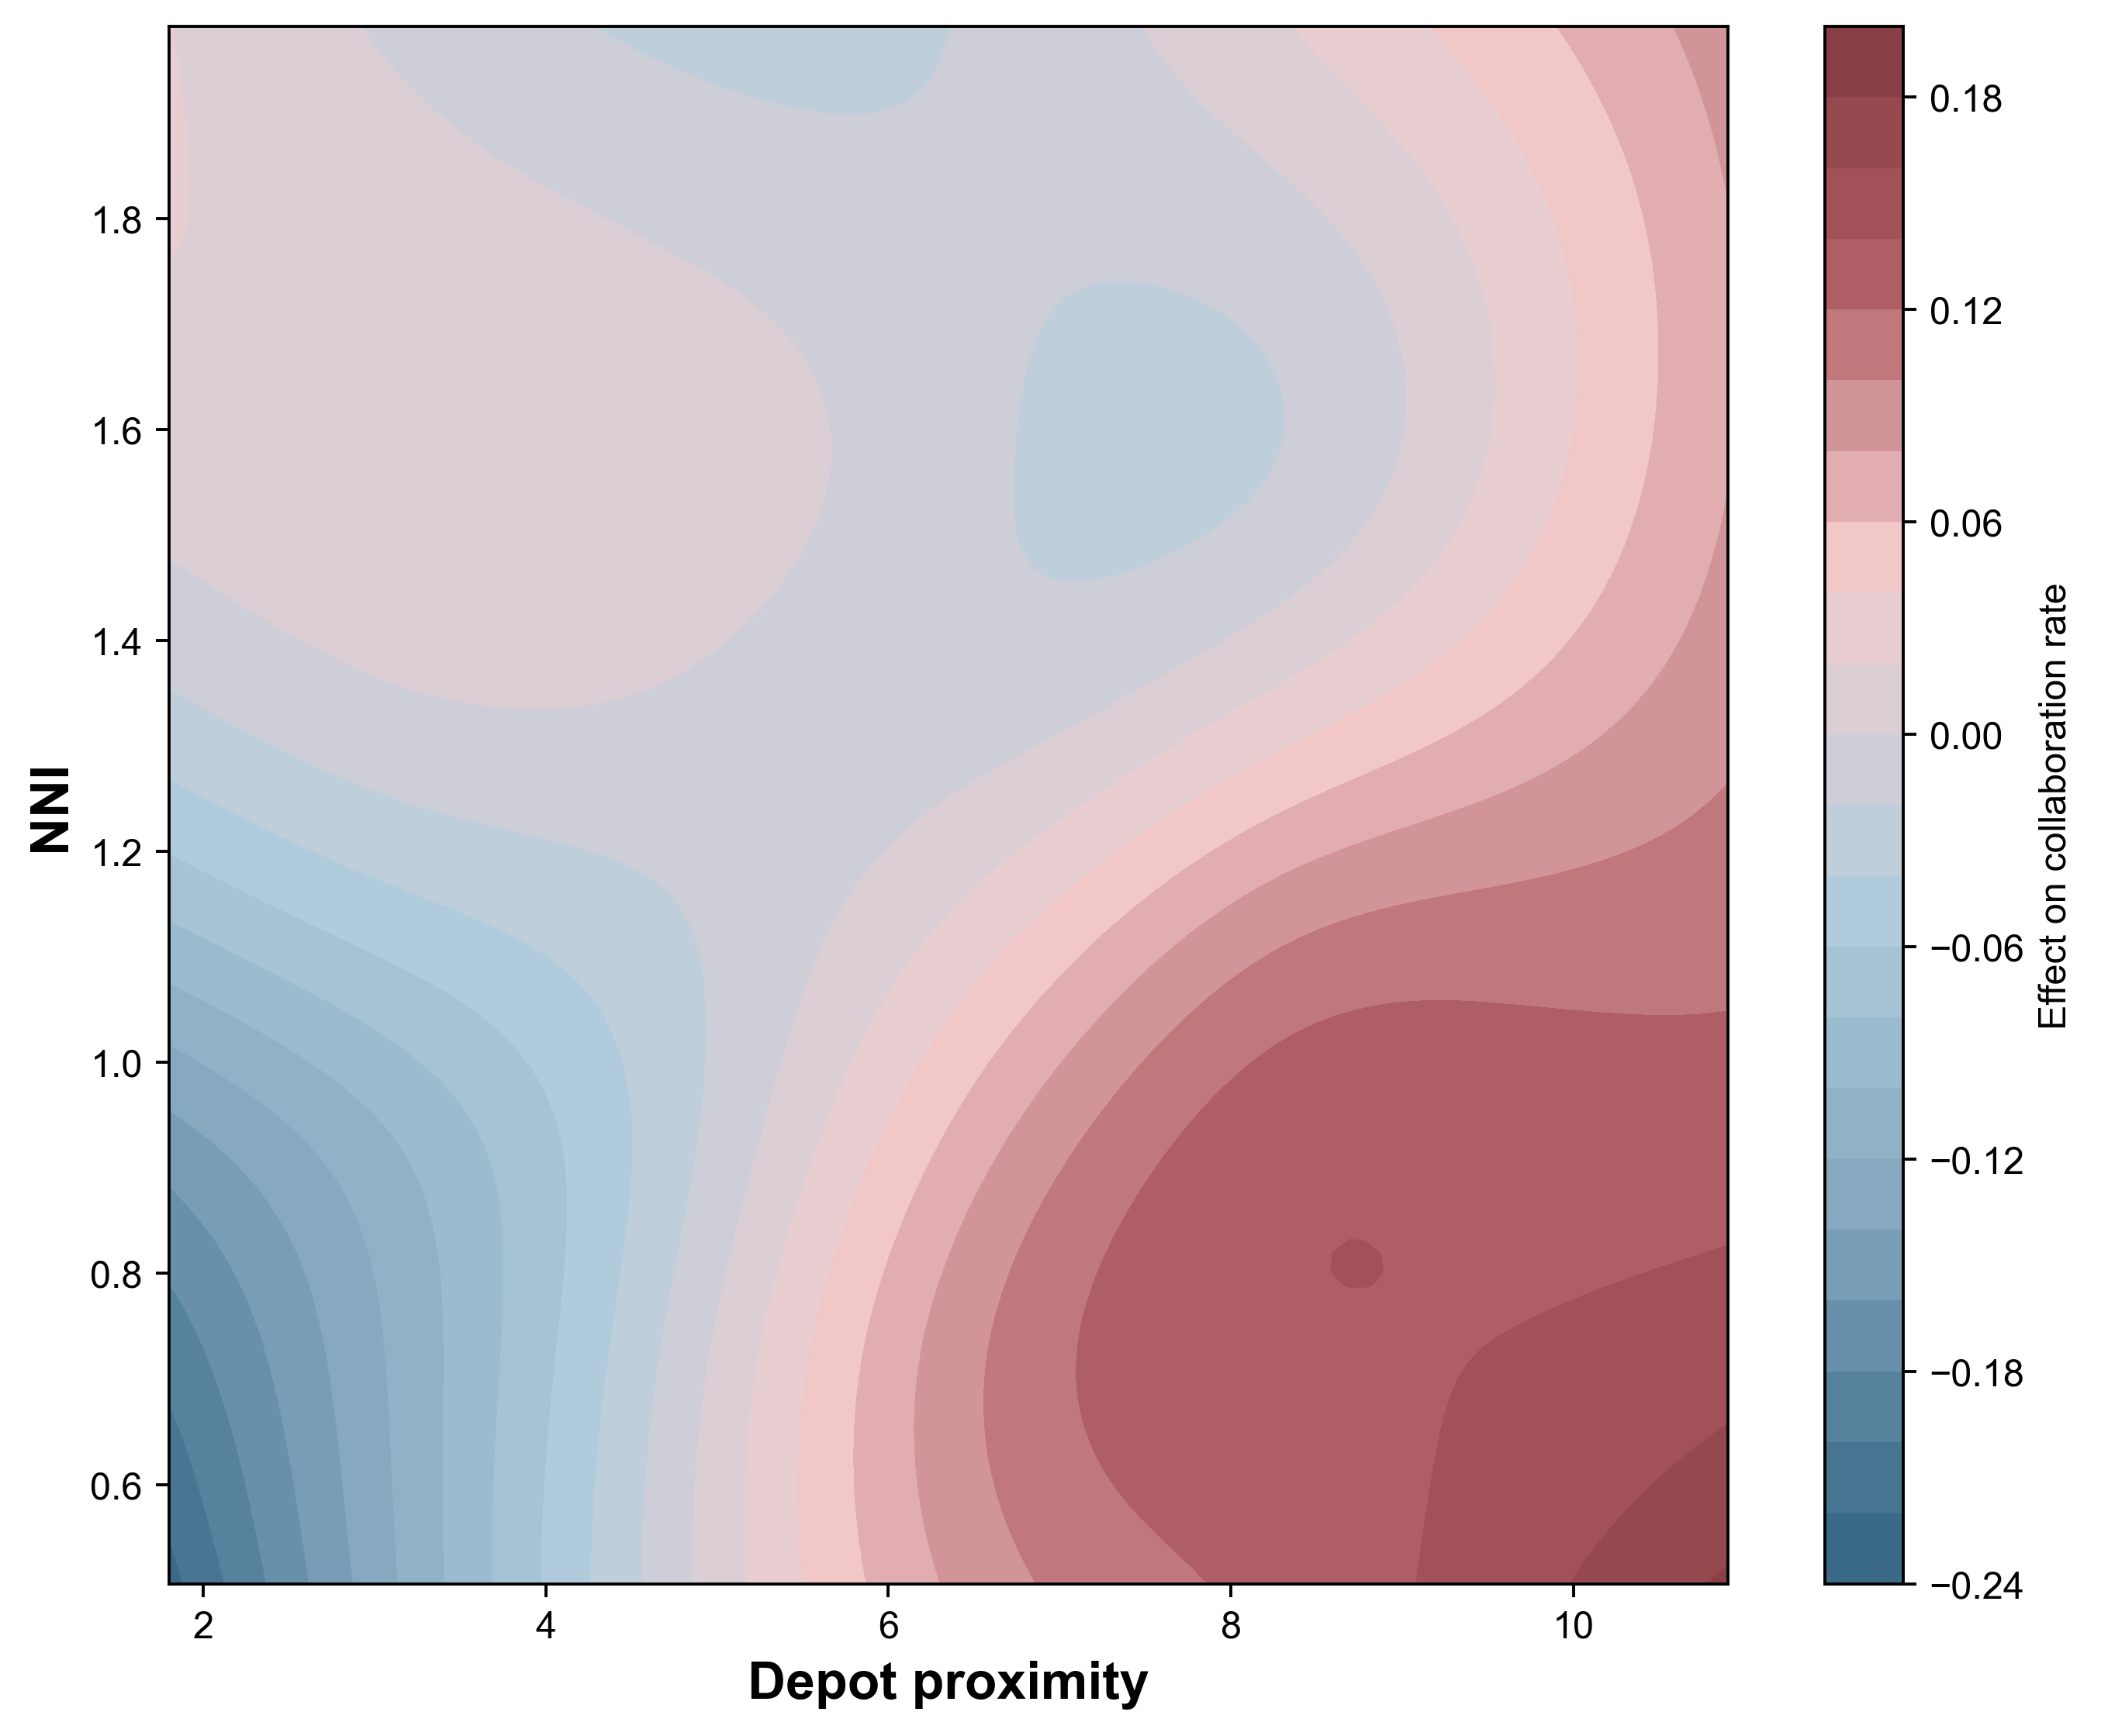

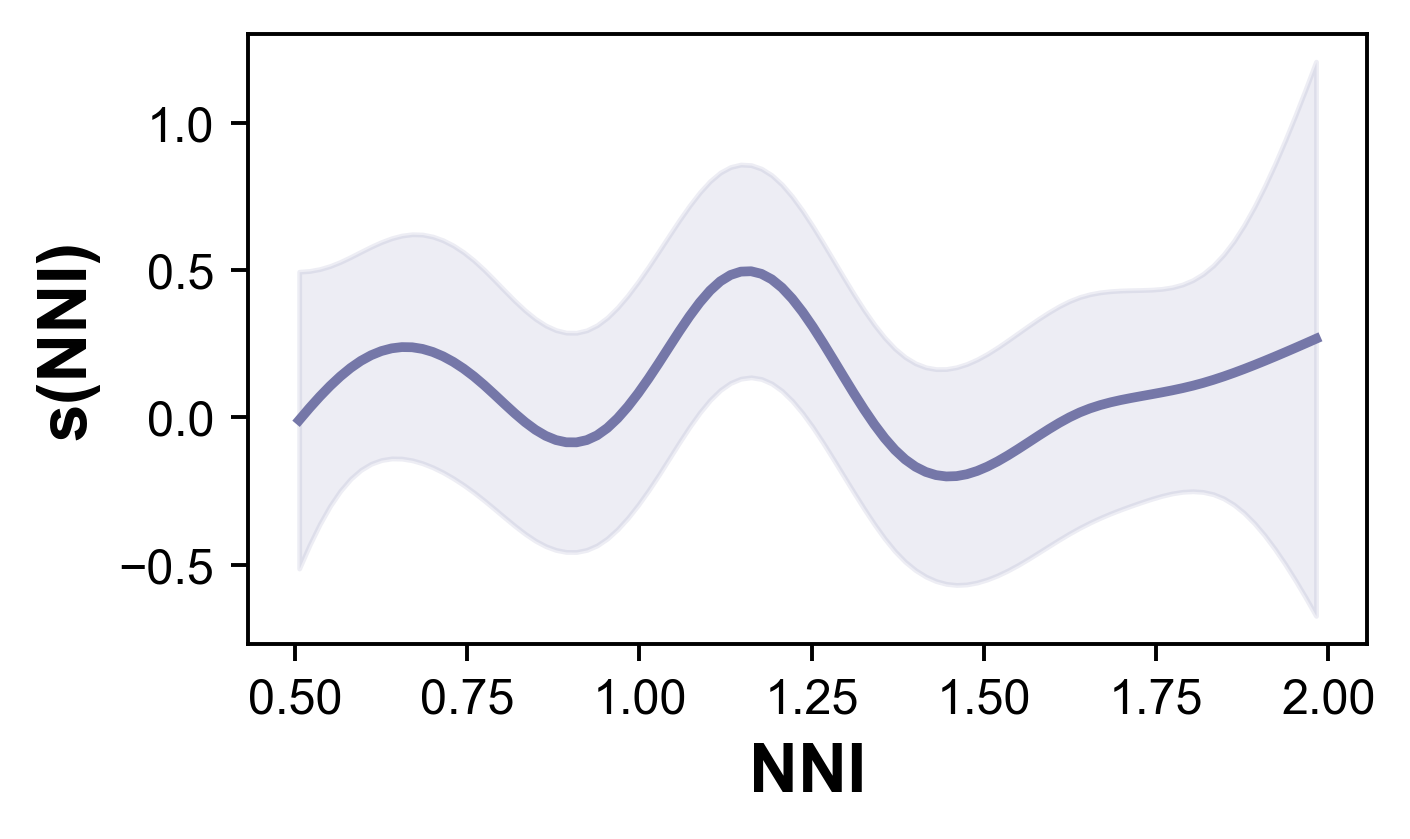

[<Figure size 1445.5x875 with 1 Axes>]

In [37]:
feature_names = ["Cost", 
                "Depot", 
                 "NNI", 
                "Dist. centroid", 
                 "Depot proximity",]

figure_plot.plot_partial_dependence(
    gam, feature_names, scaler,
    # features=[0, 2, 4],  # indices of features to plot
    line_color="#7577A8", ci_color="#8789B7", ci_alpha=0.15,
    cmap=(["#3A6A88", "#83A7BE", "#B3CEDE"],   # neg → 0
          ["#F5CECE", "#AC575F", "#702F35"]),
    colorbar_label="Effect on collaboration rate",
    colorbar_shrink=1,
    # ylabel = "Effect on collab. rate",
    label_fontweight='bold',
    label_fontsize=14,
    show_title=False,
    show_legend=False,
    dpi=350,
    #---output---
    figsize_1d=(4, 2.5),
    figsize_2d=(8, 6.5),
    output_dir=OUTPUT_FIG_PATH,
    file_prefix='gam_is_collab_cost_af60',
    file_format='png',
)

figure_plot.plot_partial_dependence(
    gam, feature_names, scaler,
    features=1,  # NNI
    line_color="#7577A8", ci_color="#8789B7", ci_alpha=0.15,
    cmap=(["#3A6A88", "#83A7BE", "#B3CEDE"],   # neg → 0
          ["#F5CECE", "#AC575F", "#702F35"]),
    colorbar_label="Effect on collaboration rate",
    colorbar_shrink=1,
    # ylabel = "Effect on collab. rate",
    label_fontweight='bold',
    label_fontsize=14,
    show_title=False,
    show_legend=False,
    dpi=350,
    #---output---
    figsize_1d=(4.13, 2.5),
    output_dir=OUTPUT_FIG_PATH,
    file_prefix='gam_is_collab_cost_af60',
    file_format='png',
)

#### Cost savings (with cost)

In [38]:
reg_df = gam_af60_df.copy()

reg_df["k"] = reg_df["total_cost_savings"].astype(float)

# depot dummy: 0=center, 1=outside
reg_df["depot"] = (reg_df["depot_location"].str.lower() != "center").astype(int)

# cost
cost_col = "penalty_std" if "penalty_std" in reg_df.columns else "penalty"
reg_df["cost"] = reg_df[cost_col].astype(int)

# distance (pick one)
dist_col = "centroid_to_depot_network_km"  # or "centroid_to_depot_network_km"
reg_df["dist_centroid"] = reg_df[dist_col].astype(float)

reg_df["nni"] = reg_df["nni"].astype(float)

reg_df['mean_rc_dist'] = reg_df['mean_receiver_dist_to_depot_network_km'].astype(float)

reg_df['is_collab'] = (reg_df['num_collaborative_receivers'] > 0).astype(int)  # binary indicator for any collaboration

# =========
# 1) expand each instance into N_TRIALS binary observations
# =========
X = reg_df[["cost", "depot", "nni", "dist_centroid", "mean_rc_dist"]].to_numpy()


y = reg_df["k"].to_numpy()  # total_cost_savings as continuous response for regression GAM
y_binary = reg_df['is_collab'].to_numpy()  # binary response for classification GAM
# =========
# 2) standardize continuous columns (cost, nni, dist) to help GAM fitting
# depot stays 0/1
# =========
cont_idx = [0, 2, 3, 4]  # indices of cost, nni, dist_centroid, mean_rc_dist in X
scaler = {}
for j in cont_idx:
    mu = X[:, j].mean()
    sd = X[:, j].std()
    scaler[j] = (mu, sd)
    if sd > 0:
        X[:, j] = (X[:, j] - mu) / sd
    else:
        X[:, j] = 0.0  # if constant in sample



In [39]:
''' Fit a GammaGAM model — requires y > 0 '''
# GammaGAM needs strictly positive response; filter or shift if needed
mask = y > 0
if not mask.all():
    print(f"WARNING: {(~mask).sum()}/{len(y)} samples have y <= 0 and will be excluded from GammaGAM fit")
X_pos = X[mask]
y_pos = y[mask]

gam = GammaGAM(
    s(0)          # smooth term for cost
    # +f(1)          # factor term for depot (0/1)
    +s(2)           # smooth term for nni
    # +s(3)           # smooth term for dist_centroid
    +s(4)           # smooth term for mean_rc_dist
    +te(2, 4)        # interaction between NNI and mean receiver distance to depot, varying by depot
    # +te(2, 3)  
    # +te(2, 4, by=1)        # interaction between NNI and mean receiver distance to depot, varying by depot
)

# Use gridsearch with higher lambda range to avoid divergence (no need to call fit separately)
fitted_scores = gam.gridsearch(X_pos, y_pos, 
                               lam=np.logspace(-1, 4, 20),
                               progress=False,
                               )
print(f'fitted_scores: {fitted_scores}')
print(f"gam confidence intervals:\n{gam.confidence_intervals(X_pos)}")
print("GAM summary:")
print(gam.summary())
print("GAM statistics:")
print(gam.statistics_)

fitted_scores: GammaGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=s(0) + s(2) + s(4) + te(2, 4) + intercept, tol=0.0001, 
   verbose=False)
gam confidence intervals:
[[254.74228183 272.52153923]
 [312.88068703 334.36102038]
 [235.56592155 251.66105889]
 ...
 [150.97604906 178.00009741]
 [155.44504643 183.93178994]
 [163.02188124 194.16480315]]
GAM summary:
GammaGAM                                                                                                  
=============================================== ==========================================================
Distribution:                         GammaDist Effective DoF:                                     12.9593
Link Function:                          LogLink Log Likelihood:                                 -9900.1715
Number of Samples:                         1648 AIC:                                            19828.2615
                                                AICc:  

C:\Users\Xander\AppData\Local\Temp\ipykernel_39168\2370701387.py:28: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


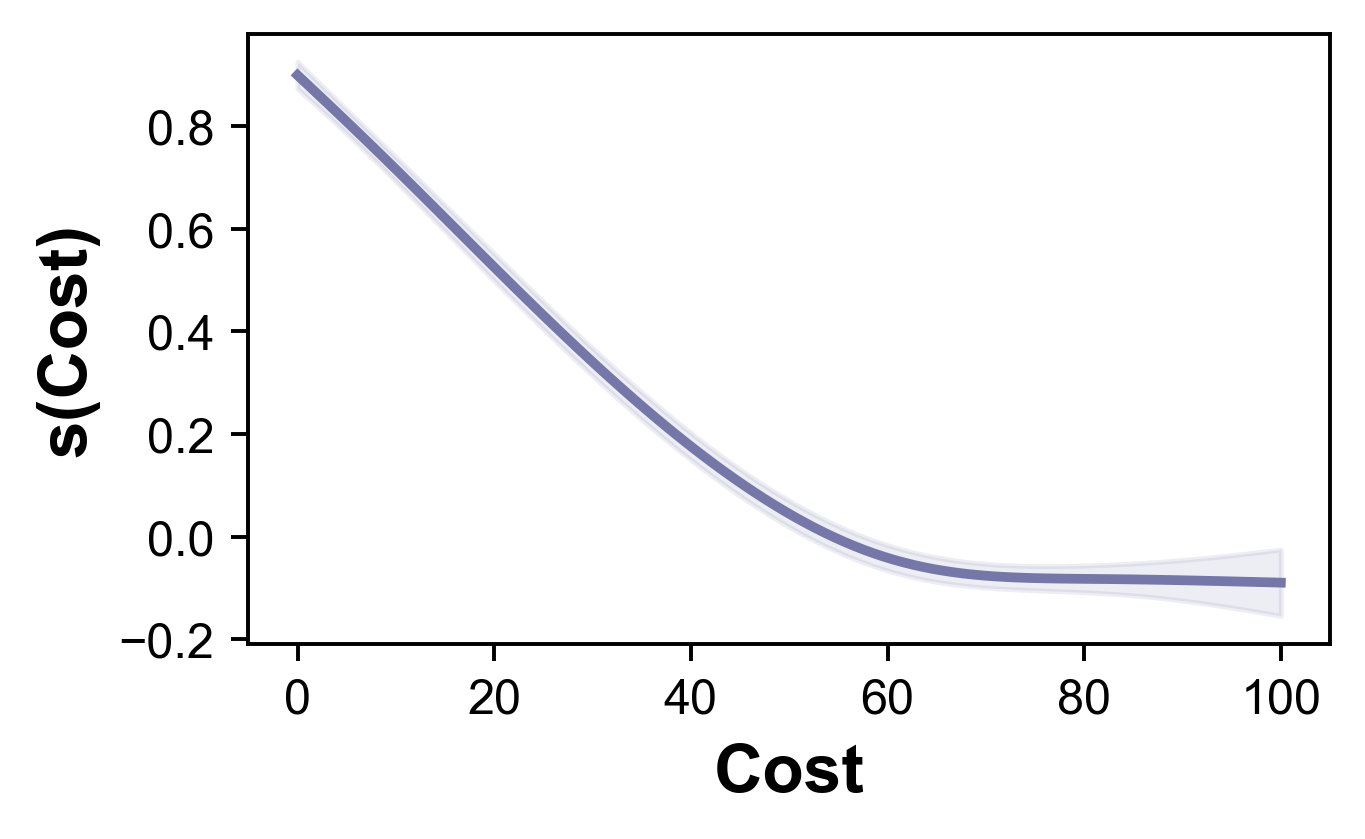

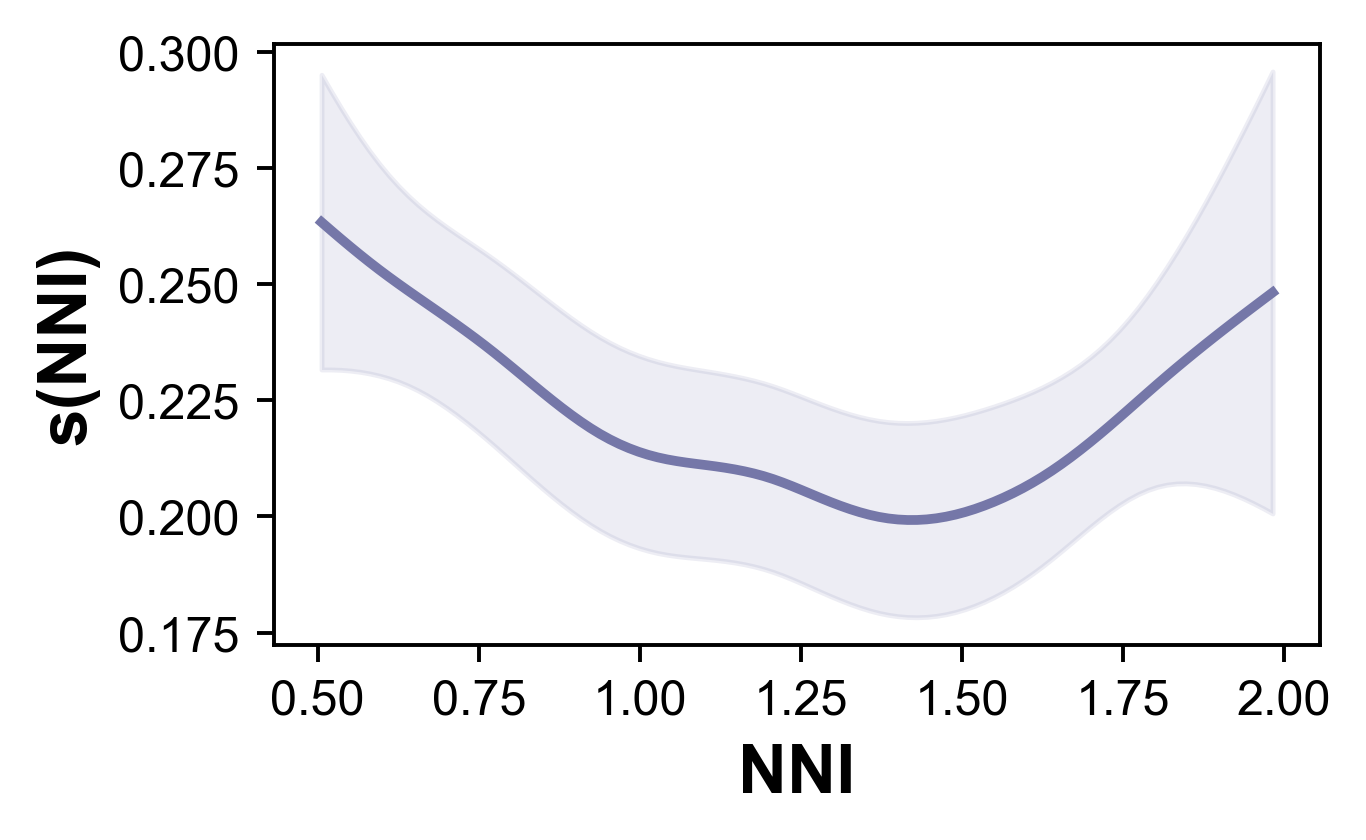

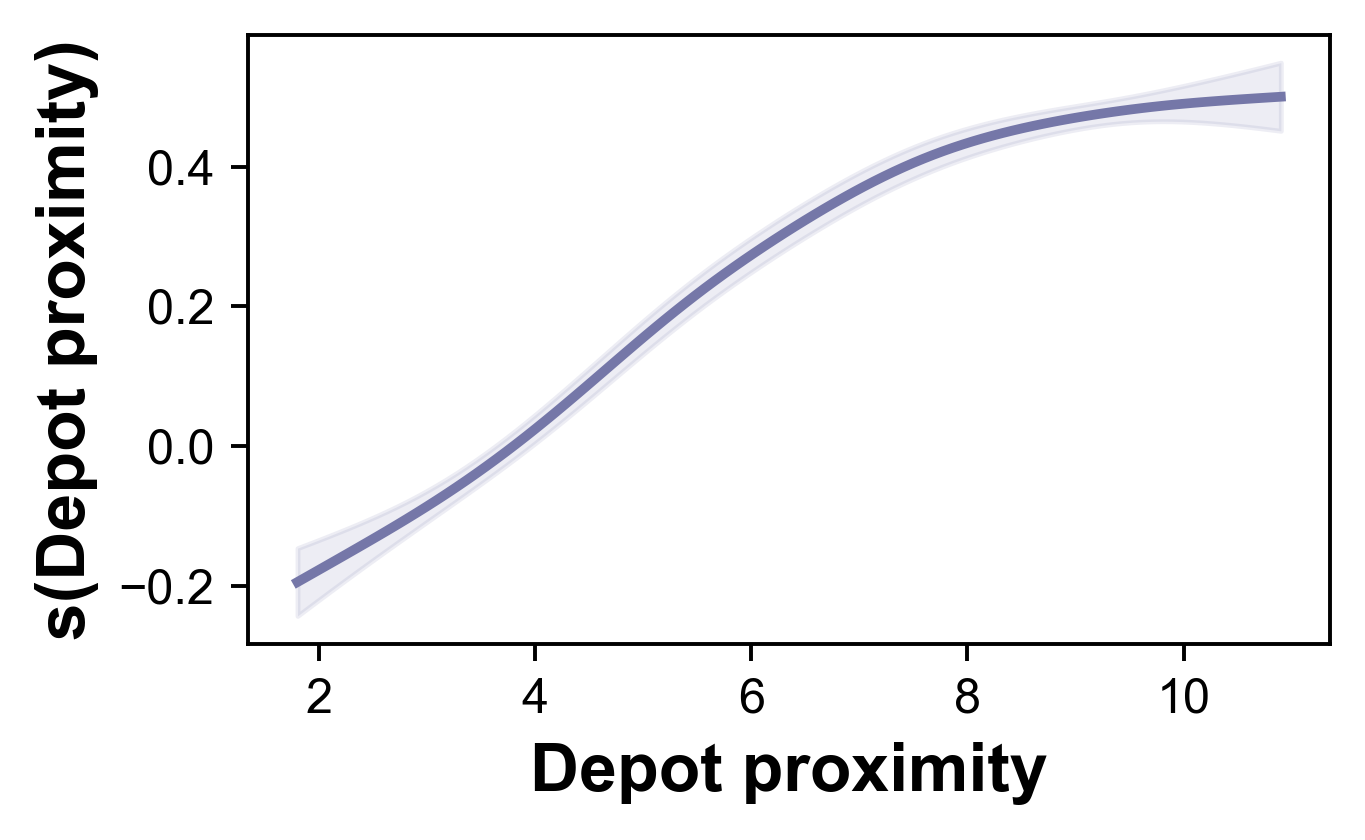

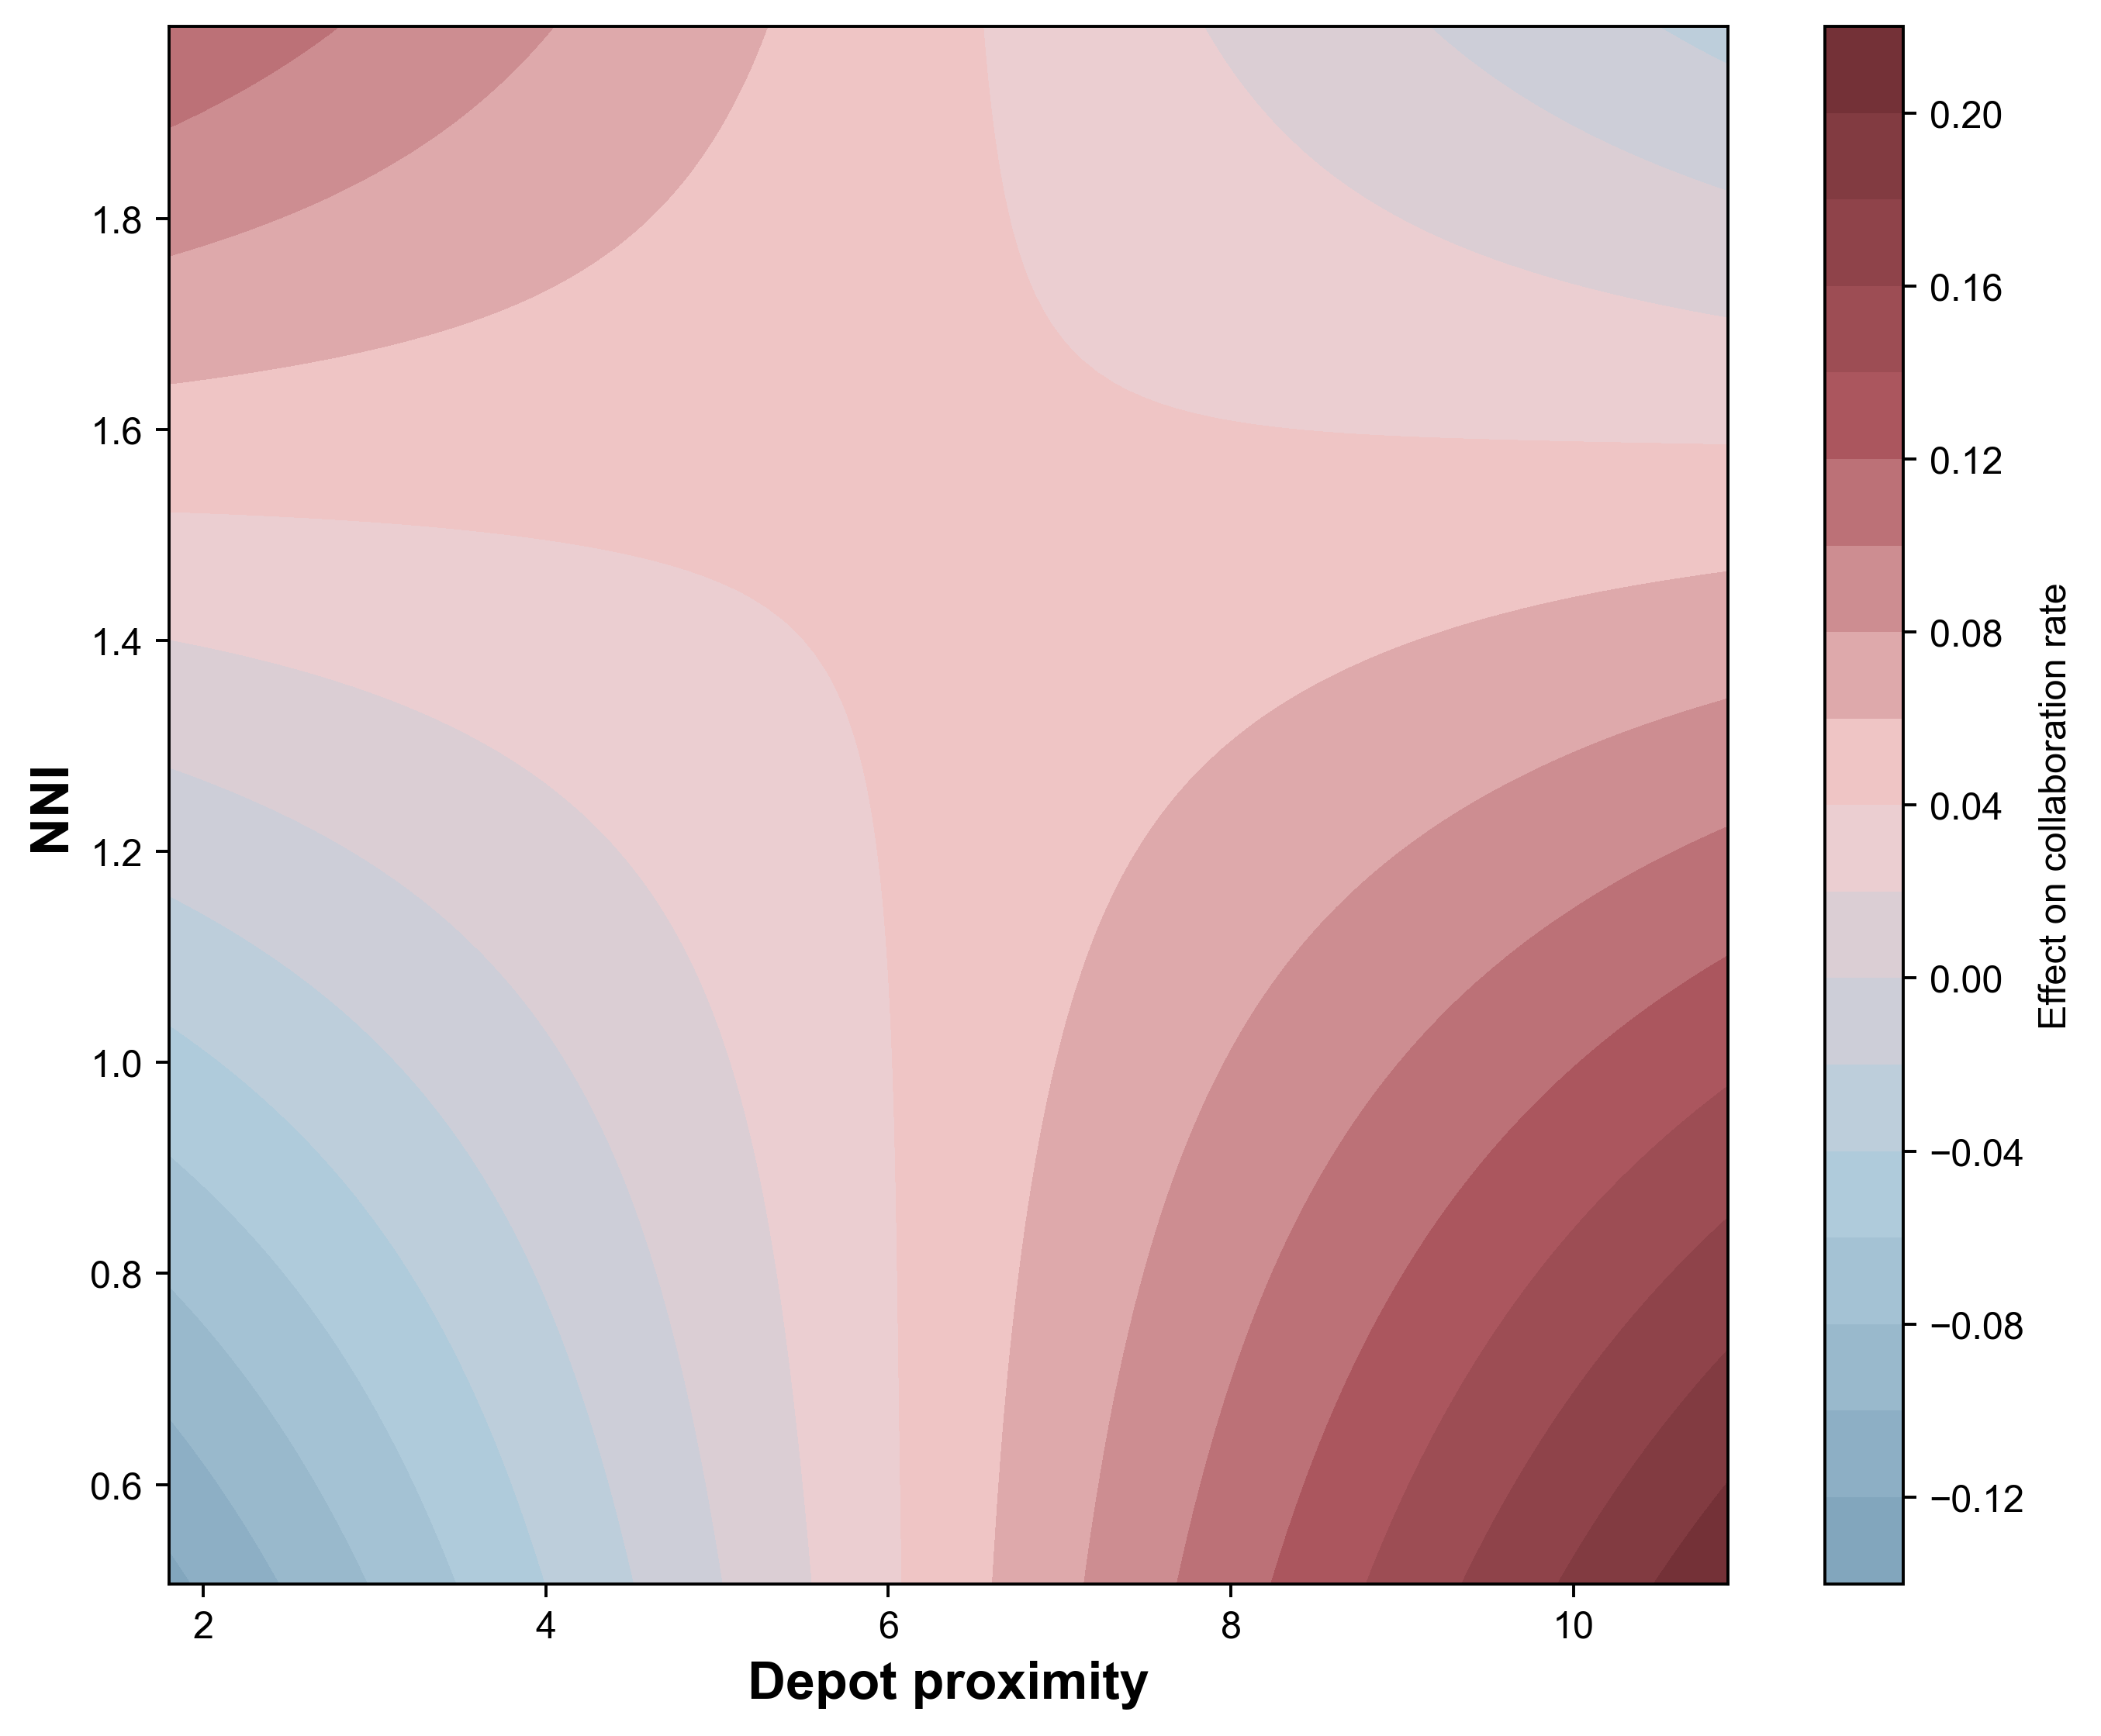

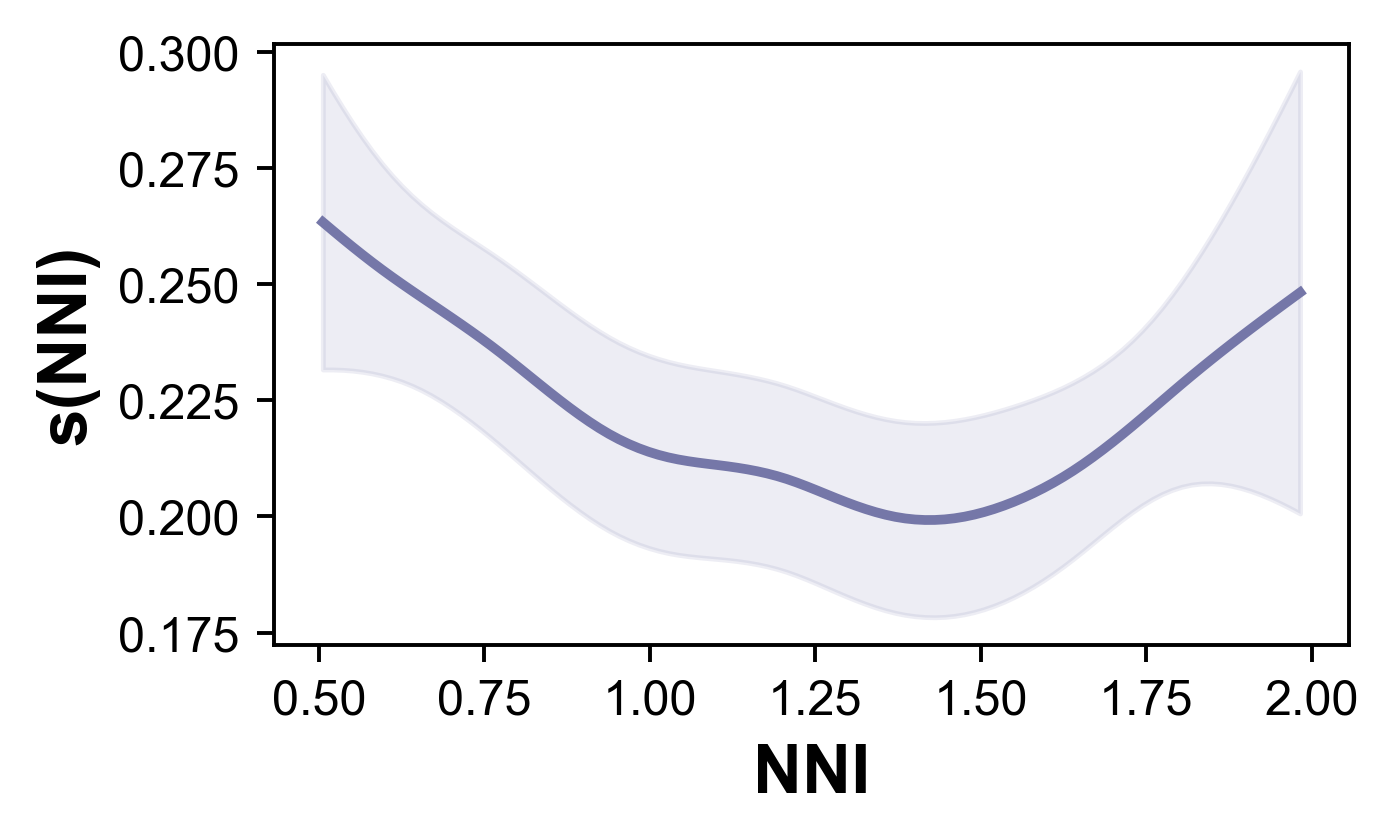

[<Figure size 1428x875 with 1 Axes>]

In [44]:
feature_names = ["Cost", 
                "Depot", 
                 "NNI", 
                "Dist. centroid", 
                 "Depot proximity",]

# Plot all features
figure_plot.plot_partial_dependence(
    gam, feature_names, scaler,
    # features=1,  # indices of features to plot
    line_color="#7577A8", ci_color="#8789B7", ci_alpha=0.15,
    cmap=(["#3A6A88", "#83A7BE", "#B3CEDE"],   # neg → 0
          ["#F5CECE", "#AC575F", "#702F35"]),
    colorbar_label="Effect on collaboration rate",
    colorbar_shrink=1,
    # ylabel = "Effect on collab. rate",
    label_fontweight='bold',
    label_fontsize=14,
    show_title=False,
    show_legend=False,
    dpi=350,
    #---output---
    figsize_1d=(4, 2.5),
    figsize_2d=(8, 6.5),
    # output_dir=OUTPUT_FIG_PATH,
    file_prefix='gam_cost_savings_cost_af60',
    file_format='png',
)

figure_plot.plot_partial_dependence(
    gam, feature_names, scaler,
    features=1,  # NNI
    line_color="#7577A8", ci_color="#8789B7", ci_alpha=0.15,
    cmap=(["#3A6A88", "#83A7BE", "#B3CEDE"],   # neg → 0
          ["#F5CECE", "#AC575F", "#702F35"]),
    colorbar_label="Effect on collaboration rate",
    colorbar_shrink=1,
    # ylabel = "Effect on collab. rate",
    label_fontweight='bold',
    label_fontsize=14,
    show_title=False,
    show_legend=False,
    dpi=350,
    #---output---
    figsize_1d=(4.08, 2.5),
    output_dir=OUTPUT_FIG_PATH,
    file_prefix='gam_cost_savings_cost_af60',
    file_format='png',
)

#### Whether collab (without cost)

In [ ]:

reg_df = gam_af60_pen20_df.copy()

reg_df["k"] = reg_df["total_cost_savings"].astype(float)

# depot dummy: 0=center, 1=outside
reg_df["depot"] = (reg_df["depot_location"].str.lower() != "center").astype(int)

# cost
cost_col = "penalty_std" if "penalty_std" in reg_df.columns else "penalty"
reg_df["cost"] = reg_df[cost_col].astype(int)

# distance (pick one)
dist_col = "centroid_to_depot_network_km"  # or "centroid_to_depot_network_km"
reg_df["dist_centroid"] = reg_df[dist_col].astype(float)

reg_df["nni"] = reg_df["nni"].astype(float)

reg_df['mean_rc_dist'] = reg_df['mean_receiver_dist_to_depot_network_km'].astype(float)

reg_df['is_collab'] = (reg_df['num_collaborative_receivers'] > 0).astype(int)  # binary indicator for any collaboration

# =========
# 1) expand each instance into N_TRIALS binary observations
# =========
X = reg_df[["cost", "depot", "nni", "dist_centroid", "mean_rc_dist"]].to_numpy()


y = reg_df["k"].to_numpy()  # total_cost_savings as continuous response for regression GAM
y_binary = reg_df['is_collab'].to_numpy()  # binary response for classification GAM
# =========
# 2) standardize continuous columns (cost, nni, dist) to help GAM fitting
# depot stays 0/1
# =========
cont_idx = [0, 2, 3, 4]  # indices of cost, nni, dist_centroid, mean_rc_dist in X
scaler = {}
for j in cont_idx:
    mu = X[:, j].mean()
    sd = X[:, j].std()
    scaler[j] = (mu, sd)
    if sd > 0:
        X[:, j] = (X[:, j] - mu) / sd
    else:
        X[:, j] = 0.0  # if constant in sample



In [ ]:
''' Fit a LogisticGAM model — adding y(0,1)-total_cost_savings 0 or >0 as binary response'''

gam = LogisticGAM(
    # s(0)          # smooth term for cost
    # +f(1)          # factor term for depot (0/1)
    s(2)           # smooth term for nni
    # +s(3)           # smooth term for dist_centroid
    +s(4)           # smooth term for mean_rc_dist
    +te(2, 4)        # interaction between NNI and mean receiver distance to depot, varying by depot
    # +te(2, 3)  
    # +te(2, 4, by=1)        # interaction between NNI and mean receiver distance to depot, varying by depot
)

# Use gridsearch with higher lambda range to avoid divergence (no need to call fit separately)
fitted_scores = gam.gridsearch(X, y_binary, 
                               lam=np.logspace(-1, 4, 20),
                               progress=False,
                               )
print(f'fitted_scores: {fitted_scores}')
print(f"gam confidence intervals:\n{gam.confidence_intervals(X)}")
print("GAM summary:")
print(gam.summary())
print("GAM statistics:")
print(gam.statistics_)

In [ ]:
feature_names = ["cost", "depot", "nni", "dist_centroid", "mean_rc_dist"]

# Plot all features
figure_plot.plot_partial_dependence(gam, feature_names, scaler)


#### Cost savings (without cost)

In [ ]:
reg_df = gam_af60_pen20_df.copy()

reg_df["k"] = reg_df["total_cost_savings"].astype(float)

# depot dummy: 0=center, 1=outside
reg_df["depot"] = (reg_df["depot_location"].str.lower() != "center").astype(int)

# cost
cost_col = "penalty_std" if "penalty_std" in reg_df.columns else "penalty"
reg_df["cost"] = reg_df[cost_col].astype(int)

# distance (pick one)
dist_col = "centroid_to_depot_network_km"  # or "centroid_to_depot_network_km"
reg_df["dist_centroid"] = reg_df[dist_col].astype(float)

reg_df["nni"] = reg_df["nni"].astype(float)

reg_df['mean_rc_dist'] = reg_df['mean_receiver_dist_to_depot_network_km'].astype(float)

reg_df['is_collab'] = (reg_df['num_collaborative_receivers'] > 0).astype(int)  # binary indicator for any collaboration

# =========
# 1) expand each instance into N_TRIALS binary observations
# =========
X = reg_df[["cost", "depot", "nni", "dist_centroid", "mean_rc_dist"]].to_numpy()


y = reg_df["k"].to_numpy()  # total_cost_savings as continuous response for regression GAM
y_binary = reg_df['is_collab'].to_numpy()  # binary response for classification GAM
# =========
# 2) standardize continuous columns (cost, nni, dist) to help GAM fitting
# depot stays 0/1
# =========
cont_idx = [0, 2, 3, 4]  # indices of cost, nni, dist_centroid, mean_rc_dist in X
scaler = {}
for j in cont_idx:
    mu = X[:, j].mean()
    sd = X[:, j].std()
    scaler[j] = (mu, sd)
    if sd > 0:
        X[:, j] = (X[:, j] - mu) / sd
    else:
        X[:, j] = 0.0  # if constant in sample



In [ ]:
''' Fit a GammaGAM model — requires y > 0 '''
# GammaGAM needs strictly positive response; filter or shift if needed
mask = y > 0
if not mask.all():
    print(f"WARNING: {(~mask).sum()}/{len(y)} samples have y <= 0 and will be excluded from GammaGAM fit")
X_pos = X[mask]
y_pos = y[mask]

gam = GammaGAM(
    #s(0)          # smooth term for cost
    # +f(1)          # factor term for depot (0/1)
    s(2)           # smooth term for nni
    # +s(3)           # smooth term for dist_centroid
    +s(4)           # smooth term for mean_rc_dist
    +te(2, 4)        # interaction between NNI and mean receiver distance to depot, varying by depot
    # +te(2, 3)  
    # +te(2, 4, by=1)        # interaction between NNI and mean receiver distance to depot, varying by depot
)

# Use gridsearch with higher lambda range to avoid divergence (no need to call fit separately)
fitted_scores = gam.gridsearch(X_pos, y_pos, 
                               lam=np.logspace(-1, 4, 20),
                               progress=False,
                               )
# print(f'fitted_scores: {fitted_scores}')
# print(f"gam confidence intervals:\n{gam.confidence_intervals(X_pos)}")
print("GAM summary:")
print(gam.summary())
print("GAM statistics:")
print(gam.statistics_)

In [ ]:
feature_names = ["cost", "depot", "nni", "dist_centroid", "mean_rc_dist"]

# Plot all features
figure_plot.plot_partial_dependence(gam, feature_names, scaler)


### Box plots of four scenarios' metrics


#### Collab. rate (center-clustered-af0.6)

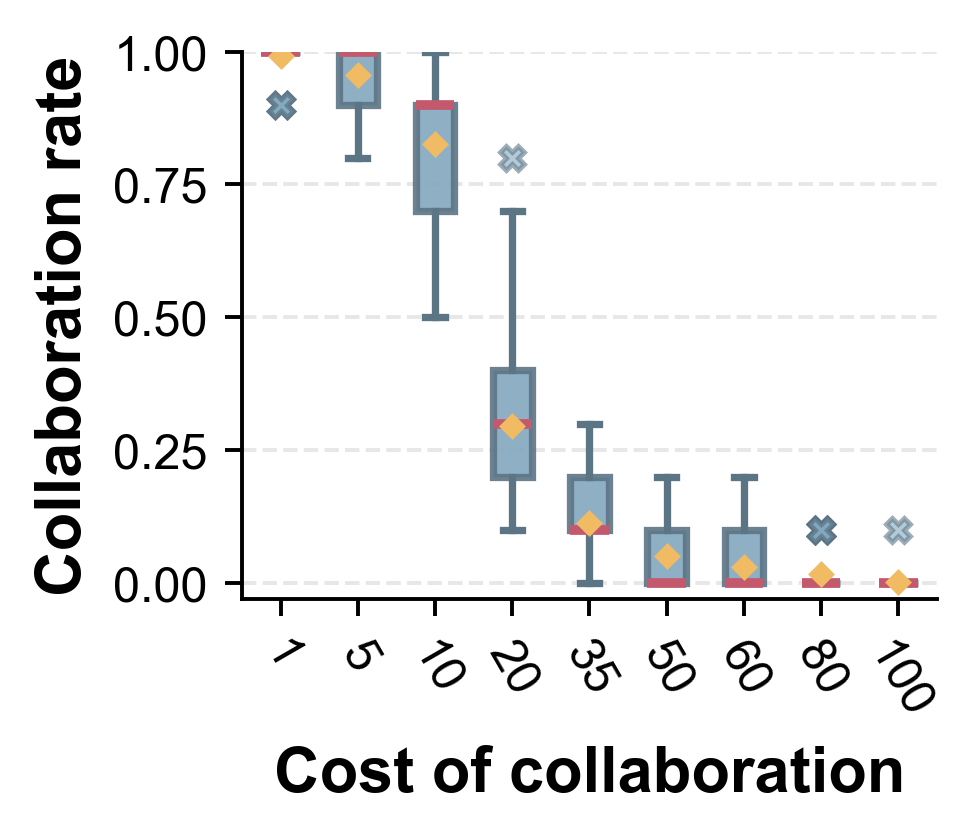

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Collaboration rate'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4c5409900>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4c5409d20>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4c5409540>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4c540a260>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4c540a7a0>,
  'means': [<matplotlib.lines.Line2D at 0x1d4c540a500>,
   <matplotlib.lines.Line2D at 0x1d4c54ac940>]})

In [451]:
figure_plot.box_plot(
    data_list=all_metrics_center_clustered_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='collaboration_rate',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Collaboration rate',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(-0.03, 1),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='collaboration_rate_by_penalty_af60_all_center_clustered_receivers.png',
)

#### Collab. rate (center-dispersed-af0.6)

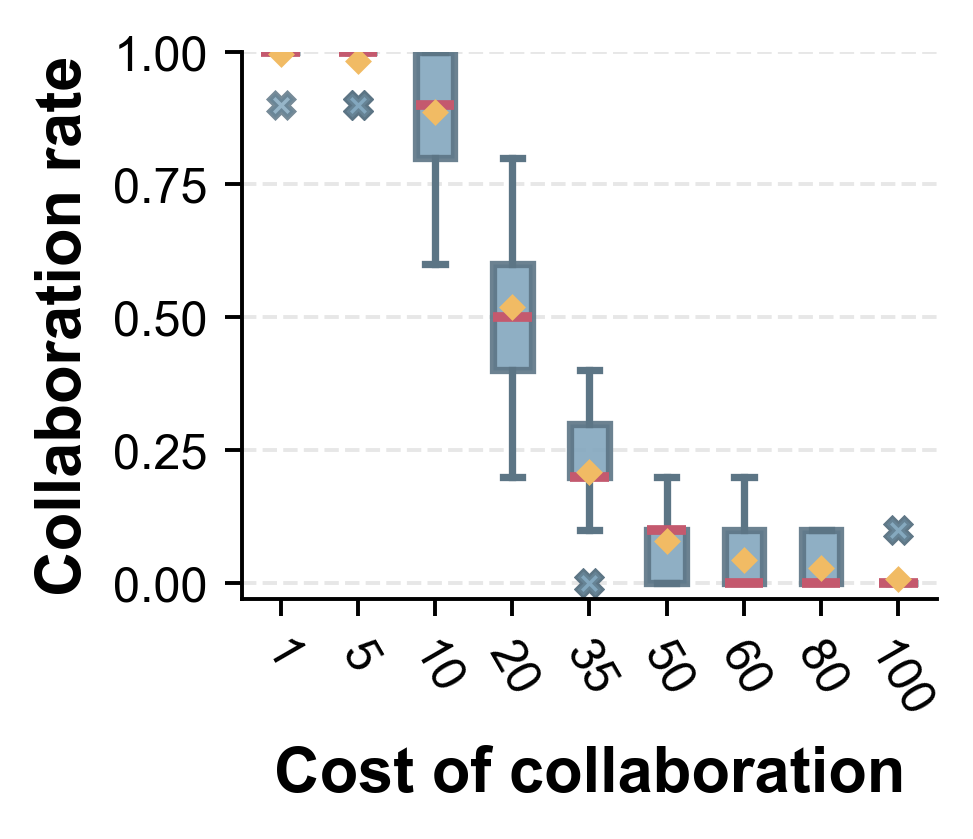

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Collaboration rate'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4c5529900>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4c5529d20>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4c5529540>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4c552a260>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4c552a7a0>,
  'means': [<matplotlib.lines.Line2D at 0x1d4c552a500>,
   <matplotlib.lines.Line2D at 0x1d4c60348e0>]})

In [452]:
figure_plot.box_plot(
    data_list=all_metrics_center_dispersed_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='collaboration_rate',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Collaboration rate',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(-0.03, 1),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='collaboration_rate_by_penalty_af60_all_center_dispersed_receivers.png',
)

#### Collab. rate (outside-clustered-af0.6)

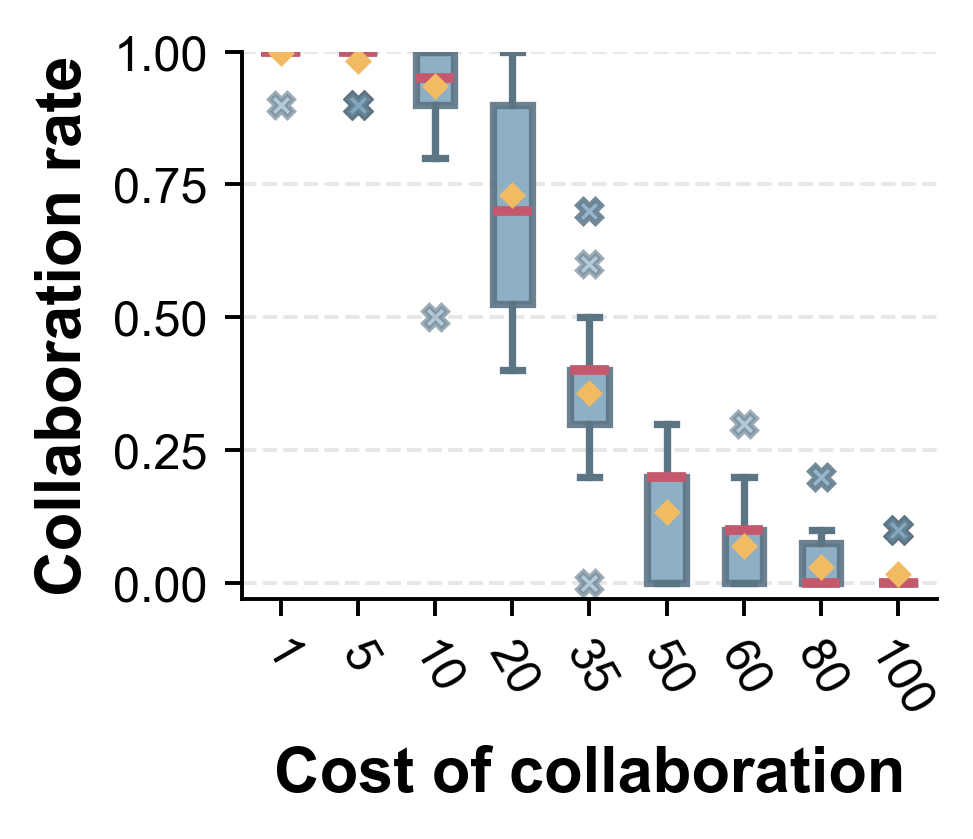

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Collaboration rate'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4bed18e50>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4bed19270>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4bed18a90>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4bed197b0>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4bed19cf0>,
  'means': [<matplotlib.lines.Line2D at 0x1d4bed19a50>,
   <matplotlib.lines.Line2D at 0x1d4bed8fe50>]})

In [437]:
figure_plot.box_plot(
    data_list=all_metrics_outside_clustered_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='collaboration_rate',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Collaboration rate',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    # Grid
    show_grid=True,
    grid_axis='y',
    #--- font size---
    tick_rotation=-60,
    #---output---
    ylim=(-0.03, 1),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='collaboration_rate_by_penalty_af60_all_outside_clustered_receivers.png',
)

#### Collab. rate (outside-dispersed-af0.6)

In [ ]:
all_metrics_outside_dispersed_df.query("allocation_factor == 0.6")

In [ ]:
ins_outside_dispersed_specific_anls_df

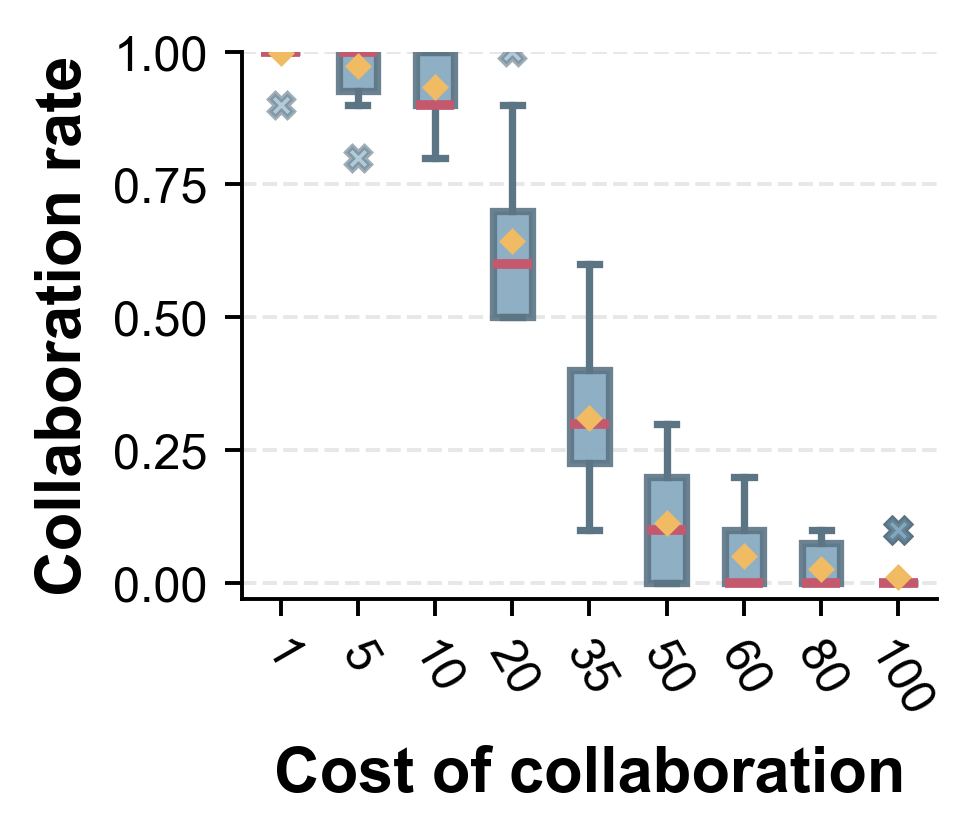

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Collaboration rate'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4bf598d90>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4bf5991b0>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4bf5989d0>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4bf5996f0>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4bf599c30>,
  'means': [<matplotlib.lines.Line2D at 0x1d4bf599990>,
   <matplotlib.lines.Line2D at 0x1d4bf60bd90>]})

In [438]:
figure_plot.box_plot(
    data_list=all_metrics_outside_dispersed_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='collaboration_rate',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Collaboration rate',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    # Grid
    show_grid=True,
    grid_axis='y',
    #--- font size---
    tick_rotation=-60,
    #---output---
    ylim=(-0.03, 1),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='collaboration_rate_by_penalty_af60_all_outside_dispersed_receivers.png',
)

#### VKT (centre-clustered-af0.6)

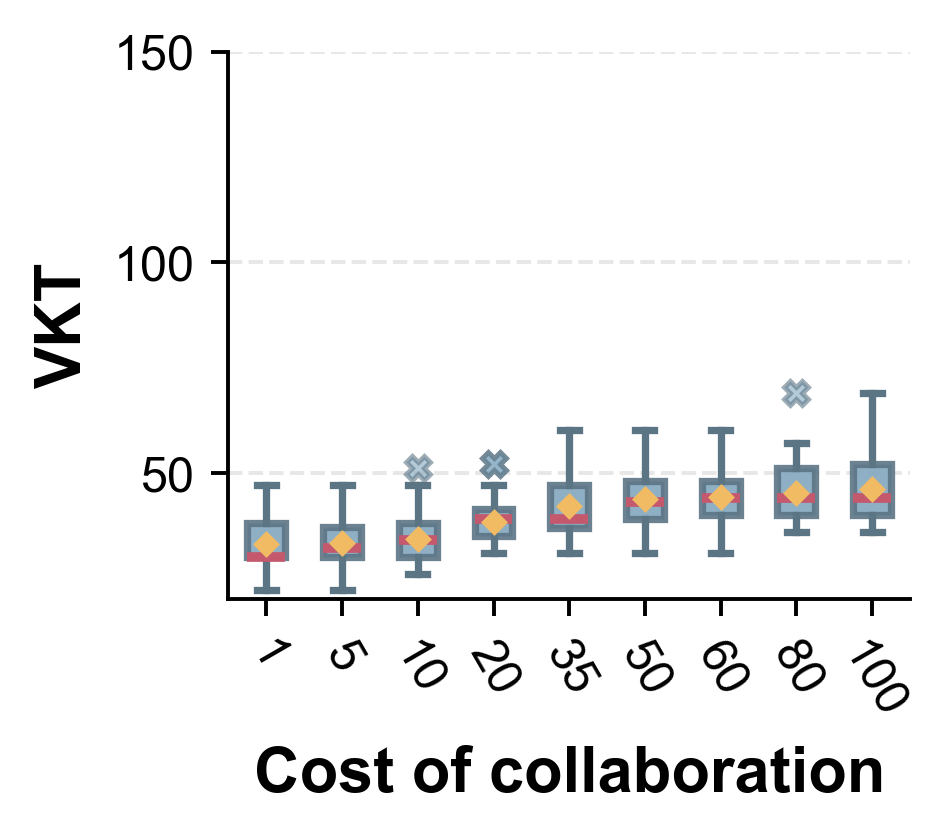

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='VKT'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4a903dde0>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4a903f820>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4a903f3a0>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4a93b0550>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4a93b0a90>,
  'means': [<matplotlib.lines.Line2D at 0x1d4a93b07f0>,
   <matplotlib.lines.Line2D at 0x1d4a9416bf0>]})

In [379]:
figure_plot.box_plot(
    data_list=all_metrics_center_clustered_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='VKT_km',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='VKT',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(20,150),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='VKT_by_penalty_af60_all_center_clustered_receivers.png',
)

#### VKT (centre-dispersed-af0.6)

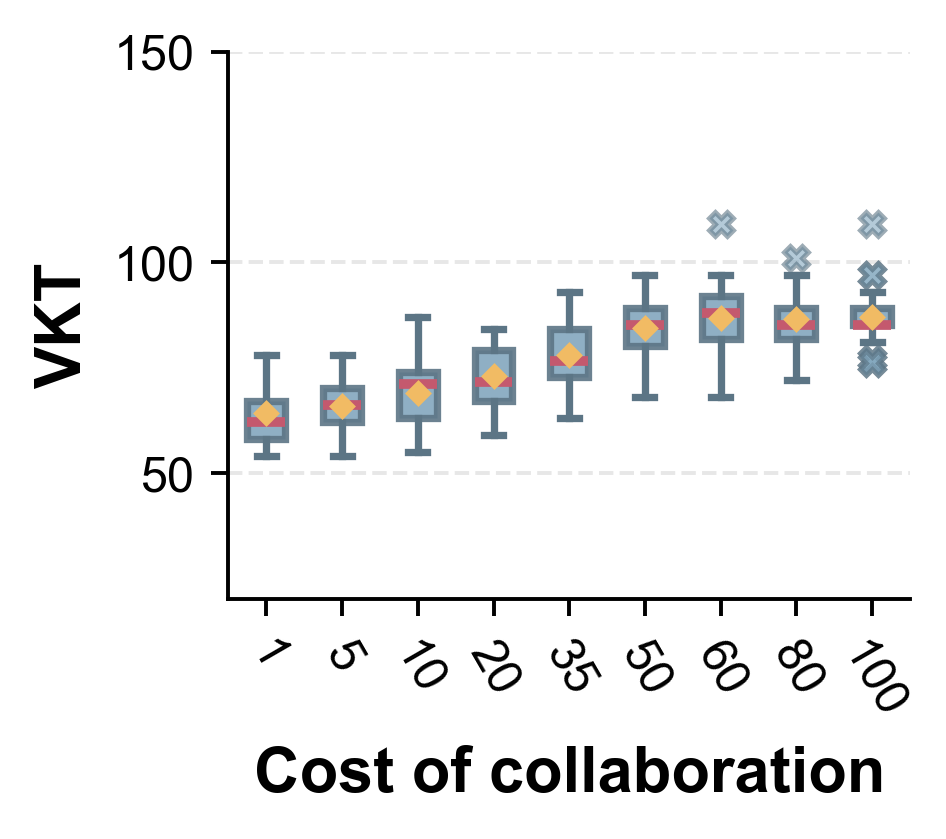

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='VKT'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4a97ff970>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4a97ffeb0>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4a97ff6d0>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4a9828430>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4a9828970>,
  'means': [<matplotlib.lines.Line2D at 0x1d4a98286d0>,
   <matplotlib.lines.Line2D at 0x1d4a989a950>]})

In [380]:
figure_plot.box_plot(
    data_list=all_metrics_center_dispersed_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='VKT_km',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='VKT',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(20,150),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='VKT_by_penalty_af60_all_center_dispersed_receivers.png',
)

#### VKT (outside-clustered-af0.6)

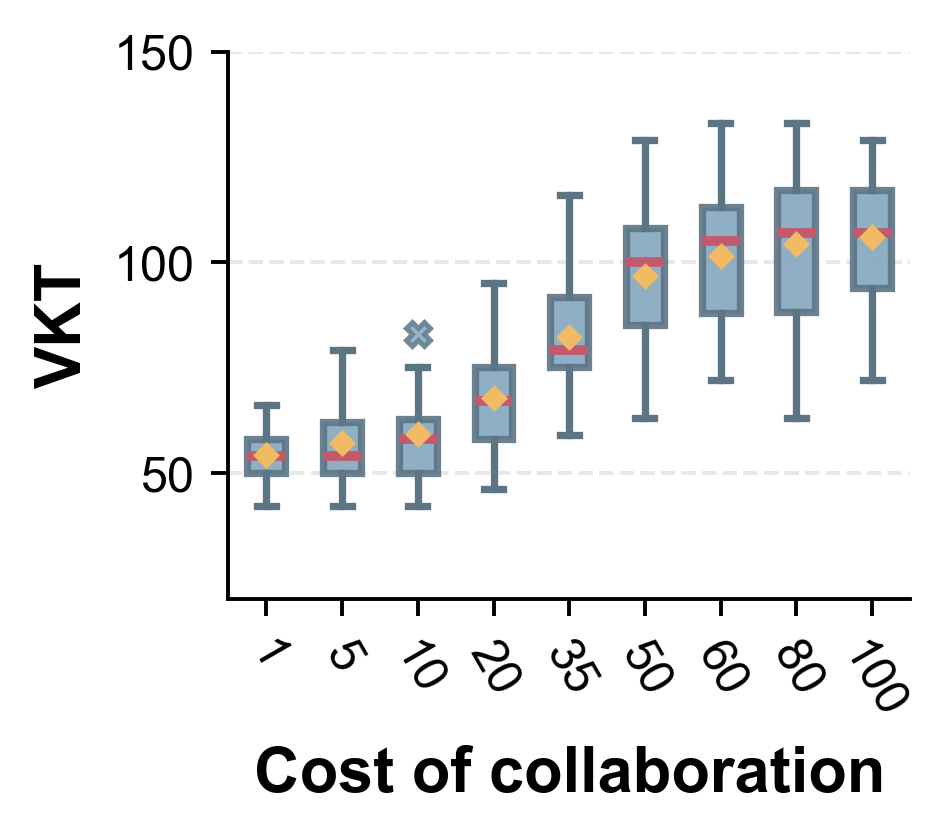

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='VKT'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4aa023a00>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4aa023f40>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4aa023760>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4aa05c4c0>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4aa05ca00>,
  'means': [<matplotlib.lines.Line2D at 0x1d4aa05c760>,
   <matplotlib.lines.Line2D at 0x1d4aa0be680>]})

In [381]:
figure_plot.box_plot(
    data_list=all_metrics_outside_clustered_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='VKT_km',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='VKT',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    # Grid
    show_grid=True,
    grid_axis='y',
    #--- font size---
    tick_rotation=-60,
    #---output---
    ylim=(20,150),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='VKT_by_penalty_af60_all_outside_clustered_receivers.png',
)

#### VKT (outside-dispersed-af0.6)

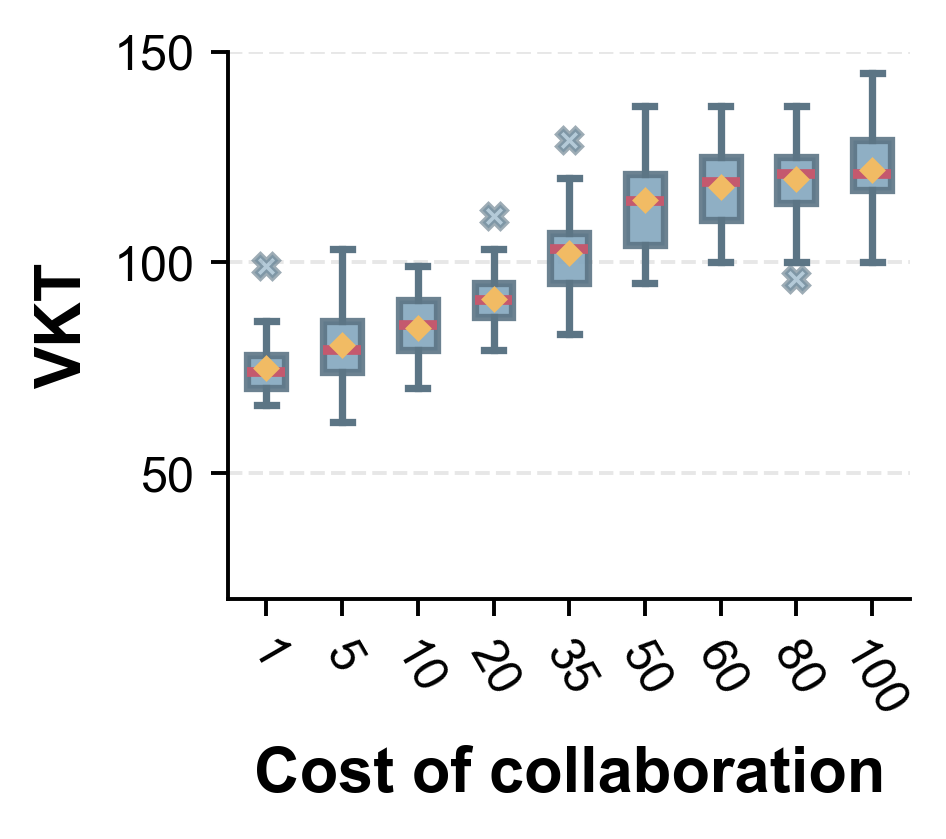

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='VKT'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4aa141ea0>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4aa1436d0>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4aa142ef0>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4aa143c10>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4aa174190>,
  'means': [<matplotlib.lines.Line2D at 0x1d4aa143eb0>,
   <matplotlib.lines.Line2D at 0x1d4aa1e62f0>]})

In [382]:
figure_plot.box_plot(
    data_list=all_metrics_outside_dispersed_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='VKT_km',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='VKT',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    # Grid
    show_grid=True,
    grid_axis='y',
    #--- font size---
    tick_rotation=-60,
    #---output---
    ylim=(20,150),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='VKT_by_penalty_af60_all_outside_dispersed_receivers.png',
)

#### TKT (centre-clustered-af0.6)

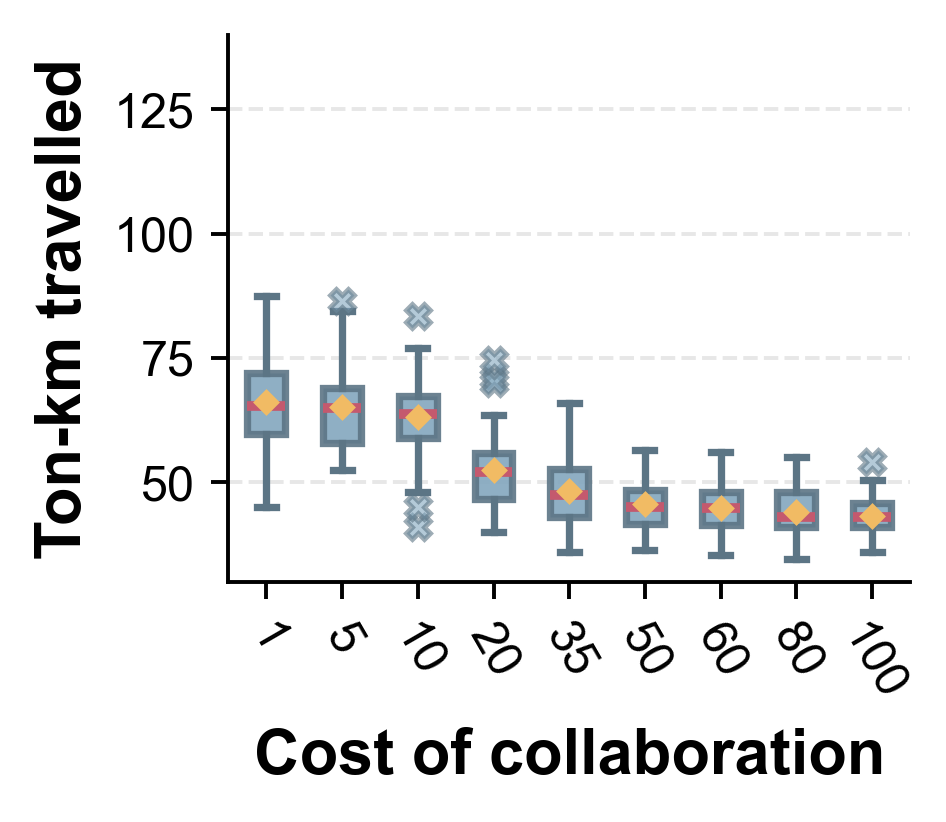

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Ton-km travelled'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4aca5e470>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4aca5e9b0>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4aca5e1d0>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4aca5eef0>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4aca5f430>,
  'means': [<matplotlib.lines.Line2D at 0x1d4aca5f190>,
   <matplotlib.lines.Line2D at 0x1d4ad529480>]})

In [386]:
figure_plot.box_plot(
    data_list=all_metrics_center_clustered_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='TKT_tonkm',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Ton-km travelled',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(30,140),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='TKT_by_penalty_af60_all_center_clustered_receivers.png',
)

#### TKT (centre-dispersed-af0.6)

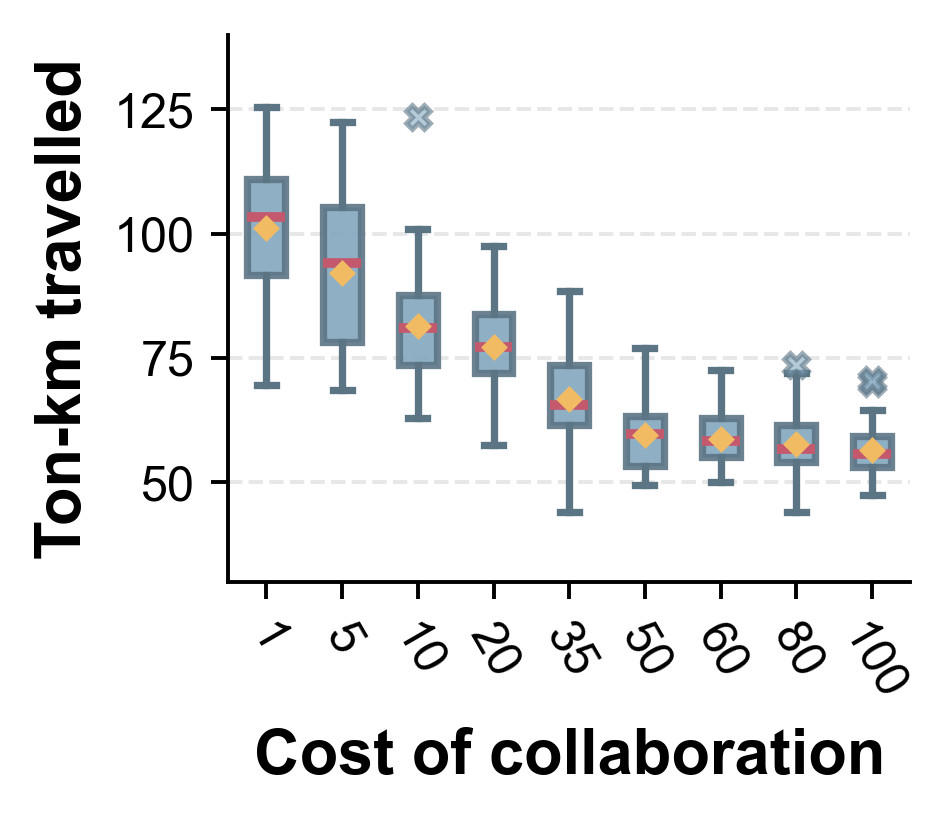

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Ton-km travelled'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4ae41a050>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4ae41a470>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4ae419c90>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4ae41a9b0>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4ae41aef0>,
  'means': [<matplotlib.lines.Line2D at 0x1d4ae41ac50>,
   <matplotlib.lines.Line2D at 0x1d4ae4c5090>]})

In [388]:
figure_plot.box_plot(
    data_list=all_metrics_center_dispersed_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='TKT_tonkm',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Ton-km travelled',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(30,140),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='TKT_by_penalty_af60_all_center_dispersed_receivers.png',
)

#### TKT (outside-clustered-af0.6)

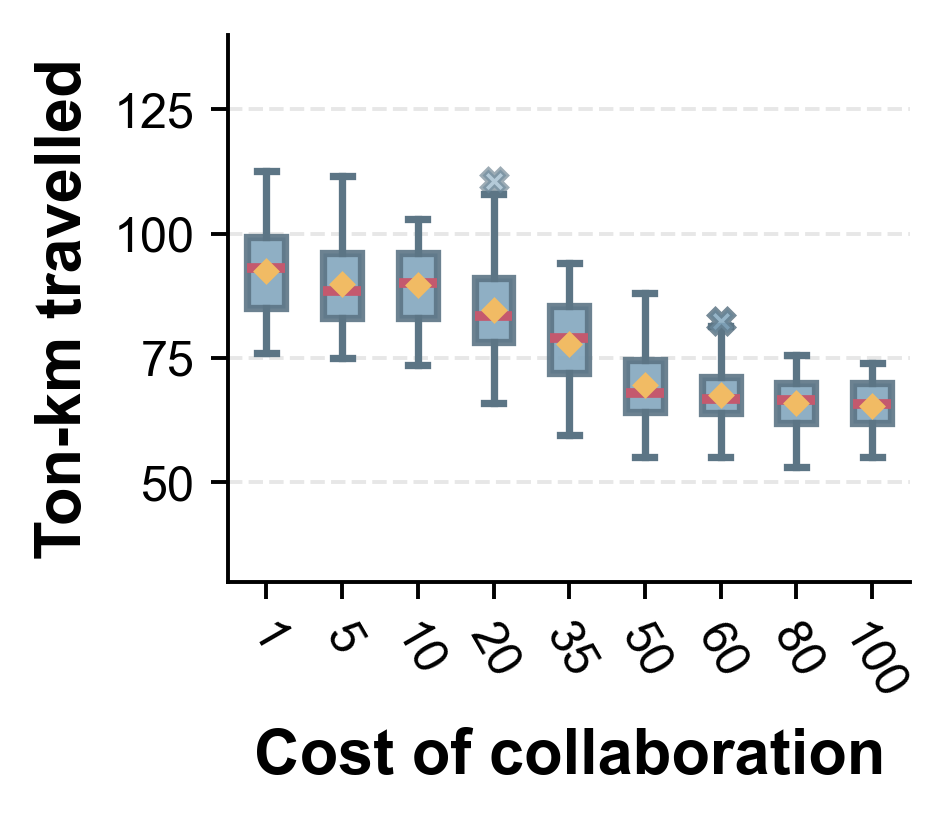

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Ton-km travelled'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4ae542020>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4ae542560>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4ae541d80>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4ae542aa0>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4ae542fe0>,
  'means': [<matplotlib.lines.Line2D at 0x1d4ae542d40>,
   <matplotlib.lines.Line2D at 0x1d4aecf1000>]})

In [389]:
figure_plot.box_plot(
    data_list=all_metrics_outside_clustered_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='TKT_tonkm',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Ton-km travelled',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    # Grid
    show_grid=True,
    grid_axis='y',
    #--- font size---
    tick_rotation=-60,
    #---output---
    ylim=(30,140),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='TKT_by_penalty_af60_all_outside_clustered_receivers.png',
)

#### TKT (outside-dispersed-af0.6)

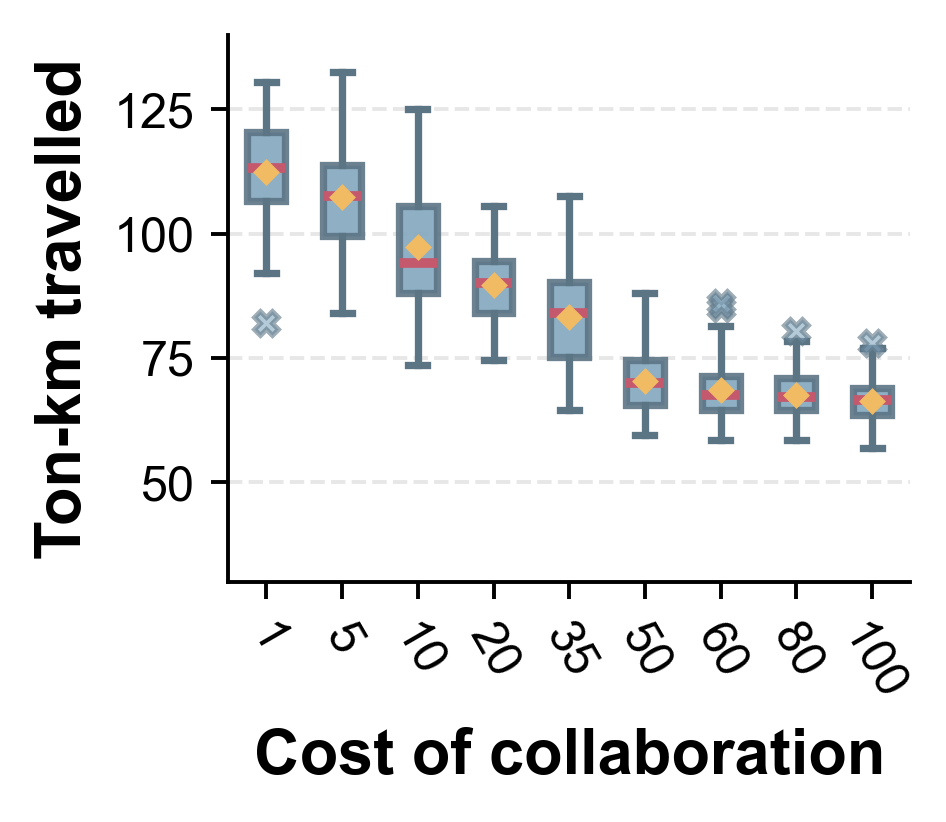

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Ton-km travelled'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4aed6e170>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4aed6e590>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4aed6ddb0>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4aed6ead0>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4aed6f010>,
  'means': [<matplotlib.lines.Line2D at 0x1d4aed6ed70>,
   <matplotlib.lines.Line2D at 0x1d4aee18dc0>]})

In [390]:
figure_plot.box_plot(
    data_list=all_metrics_outside_dispersed_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='TKT_tonkm',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Ton-km travelled',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    # Grid
    show_grid=True,
    grid_axis='y',
    #--- font size---
    tick_rotation=-60,
    #---output---
    ylim=(30,140),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='TKT_by_penalty_af60_all_outside_dispersed_receivers.png',
)

#### Eff-metric (centre-clustered=af0.6)

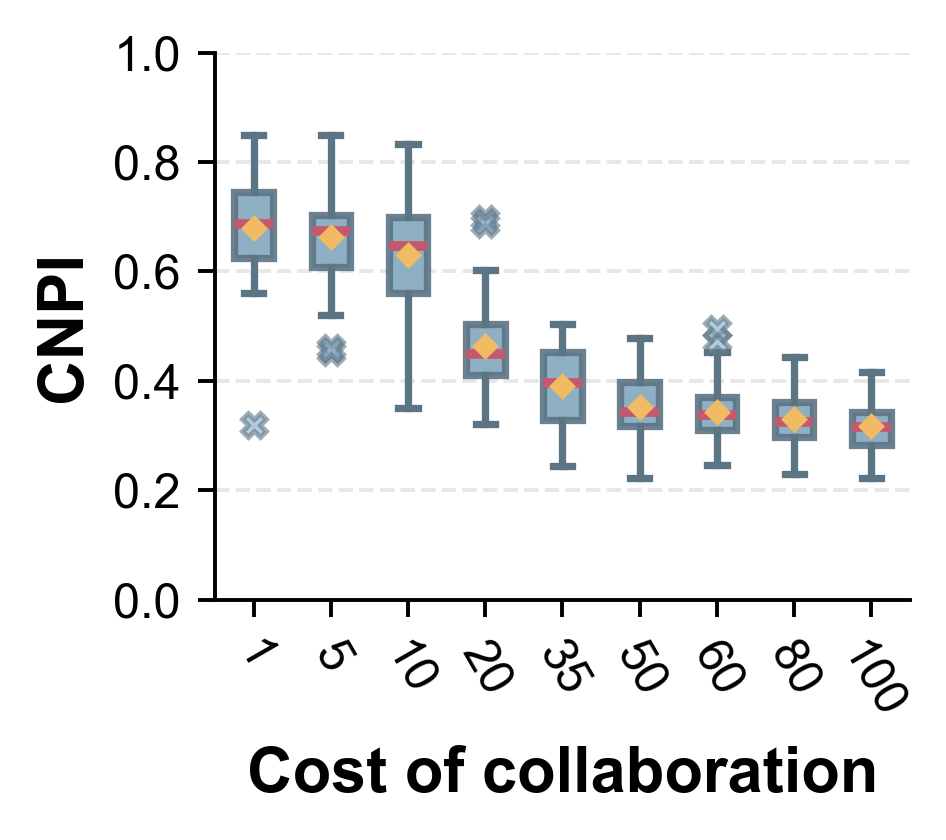

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='CNPI'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4c09087f0>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4c0908c10>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4c0908430>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4c0909150>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4c0909690>,
  'means': [<matplotlib.lines.Line2D at 0x1d4c09093f0>,
   <matplotlib.lines.Line2D at 0x1d4c097f700>]})

In [440]:
figure_plot.box_plot(
    data_list=all_metrics_center_clustered_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='payload_efficiency',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='CNPI',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(0,1),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='payload_efficiency_by_penalty_af60_all_center_clustered_receivers.png',
)

#### Eff-metric (centre-dispersed-af0.6)

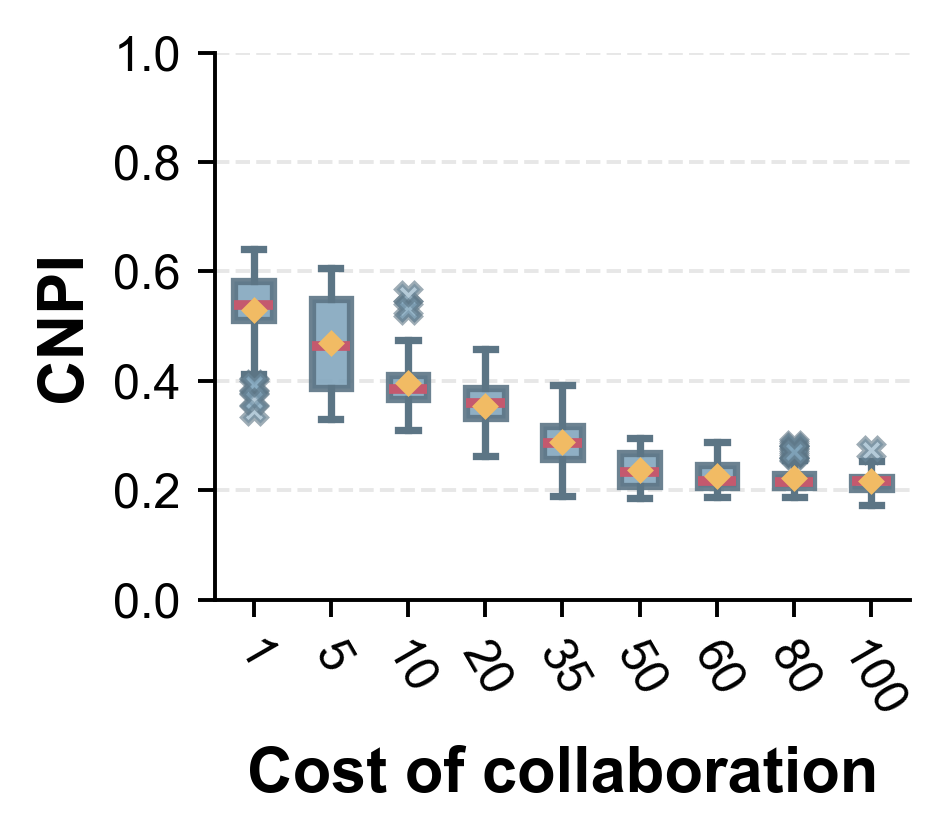

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='CNPI'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4c2233f10>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4c2258370>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4c2233b50>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4c22588b0>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4c2258df0>,
  'means': [<matplotlib.lines.Line2D at 0x1d4c2258b50>,
   <matplotlib.lines.Line2D at 0x1d4c22cef50>]})

In [442]:
figure_plot.box_plot(
    data_list=all_metrics_center_dispersed_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='payload_efficiency',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='CNPI',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(0, 1),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='payload_efficiency_by_penalty_af60_all_center_dispersed_receivers.png',
)

#### Eff-metric (outside-clustered-af0.6)

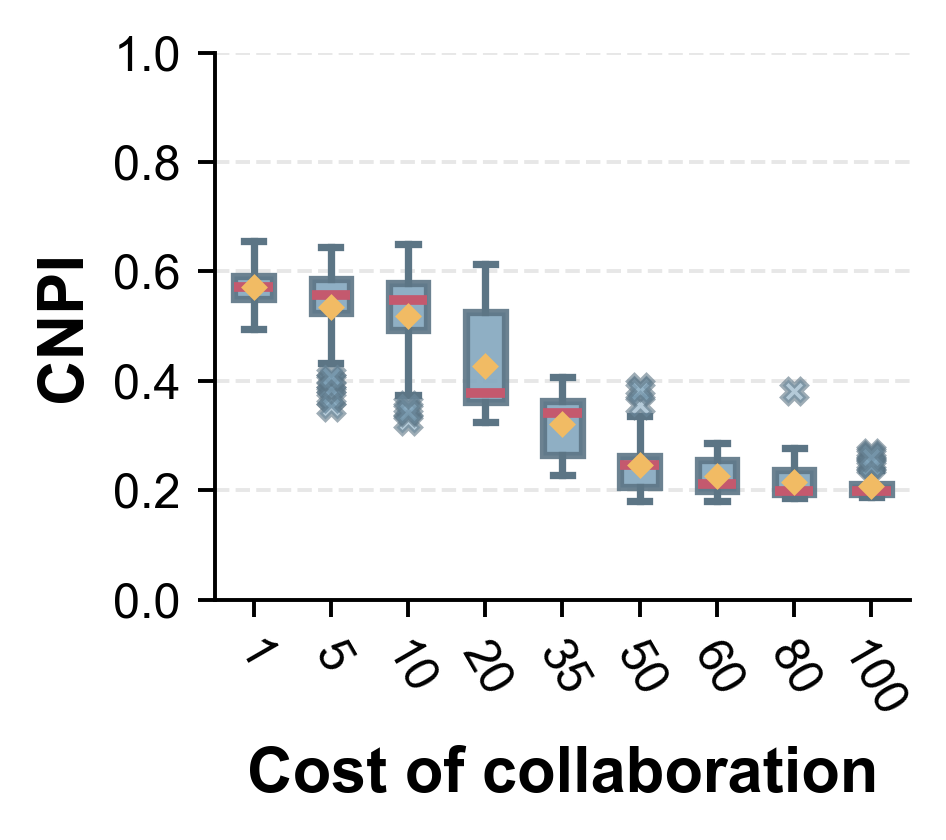

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='CNPI'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4c234b9d0>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4c234bdf0>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4c234b610>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4c2384370>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4c23848b0>,
  'means': [<matplotlib.lines.Line2D at 0x1d4c2384610>,
   <matplotlib.lines.Line2D at 0x1d4c23f29b0>]})

In [443]:
figure_plot.box_plot(
    data_list=all_metrics_outside_clustered_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='payload_efficiency',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='CNPI',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(0,1),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='payload_efficiency_by_penalty_af60_all_outside_clustered_receivers.png',
)

#### Eff-metric (outside-dispersed-af0.6)

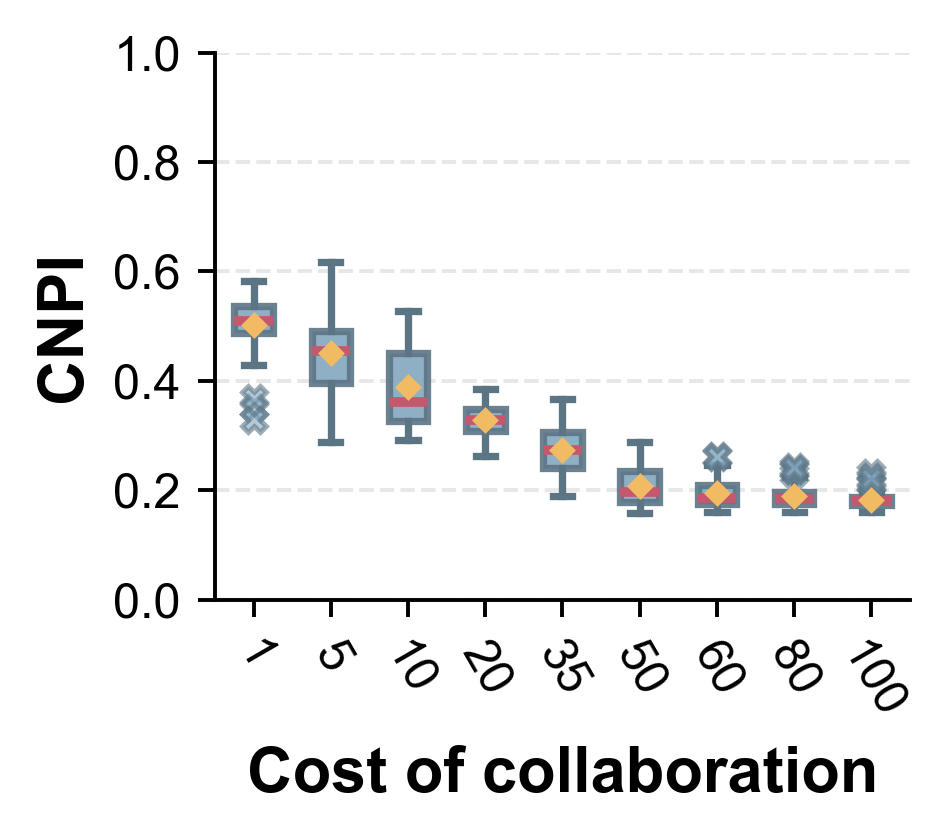

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='CNPI'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4c2b2b790>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4c2b2bbb0>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4c2b2b3d0>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4c2b5c130>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4c2b5c670>,
  'means': [<matplotlib.lines.Line2D at 0x1d4c2b5c3d0>,
   <matplotlib.lines.Line2D at 0x1d4c2bce2f0>]})

In [444]:
figure_plot.box_plot(
    data_list=all_metrics_outside_dispersed_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='payload_efficiency',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='CNPI',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(0,1),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='payload_efficiency_by_penalty_af60_all_outside_dispersed_receivers.png',
)

#### Cost savings (centre-clustered-af0.6)

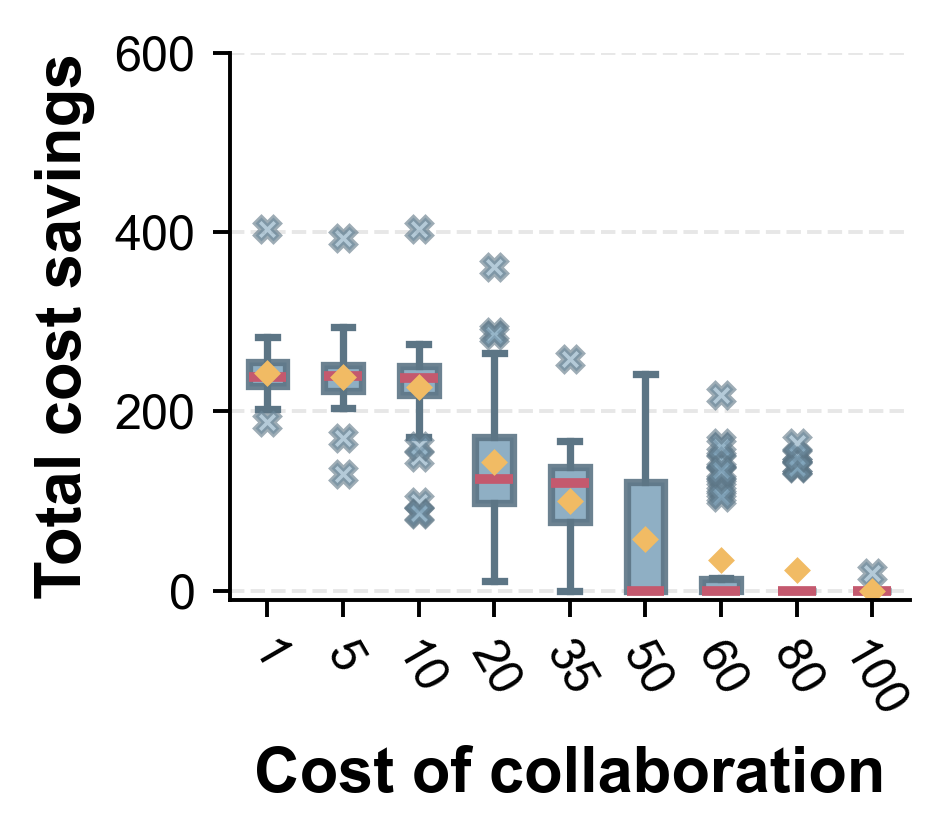

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Total cost savings'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4bb441ab0>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4bb441ed0>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4bb4416f0>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4bb442410>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4bb442950>,
  'means': [<matplotlib.lines.Line2D at 0x1d4bb4426b0>,
   <matplotlib.lines.Line2D at 0x1d4bb4f0af0>]})

In [429]:
figure_plot.box_plot(
    data_list=all_metrics_center_clustered_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='total_cost_savings',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Total cost savings',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(-10,600),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='total_cost_savings_by_penalty_af60_all_center_clustered_receivers.png',
)

#### Cost savings (centre-dispersed-af0.6)

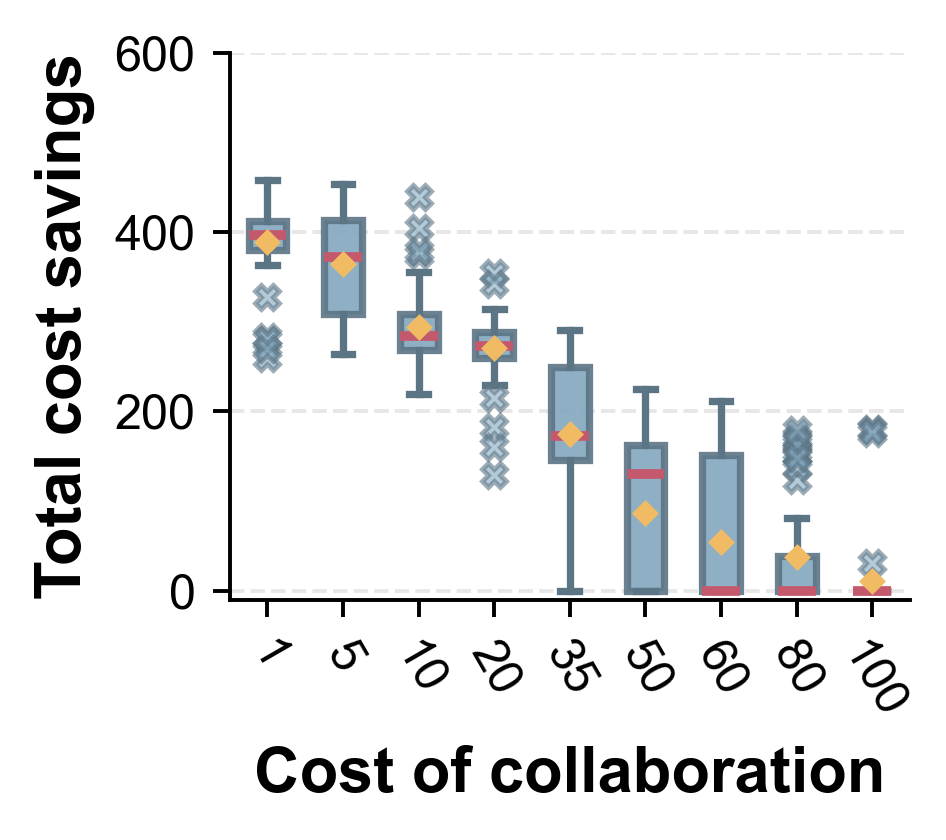

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Total cost savings'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4bb563640>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4bb563a60>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4bb563280>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4bb563fa0>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4bb594520>,
  'means': [<matplotlib.lines.Line2D at 0x1d4bb594280>,
   <matplotlib.lines.Line2D at 0x1d4bb602470>]})

In [430]:
figure_plot.box_plot(
    data_list=all_metrics_center_dispersed_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='total_cost_savings',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Total cost savings',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(-10,600),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='total_cost_savings_by_penalty_af60_all_center_dispersed_receivers.png',
)

#### Cost savings (outside-cluster-af0.6)

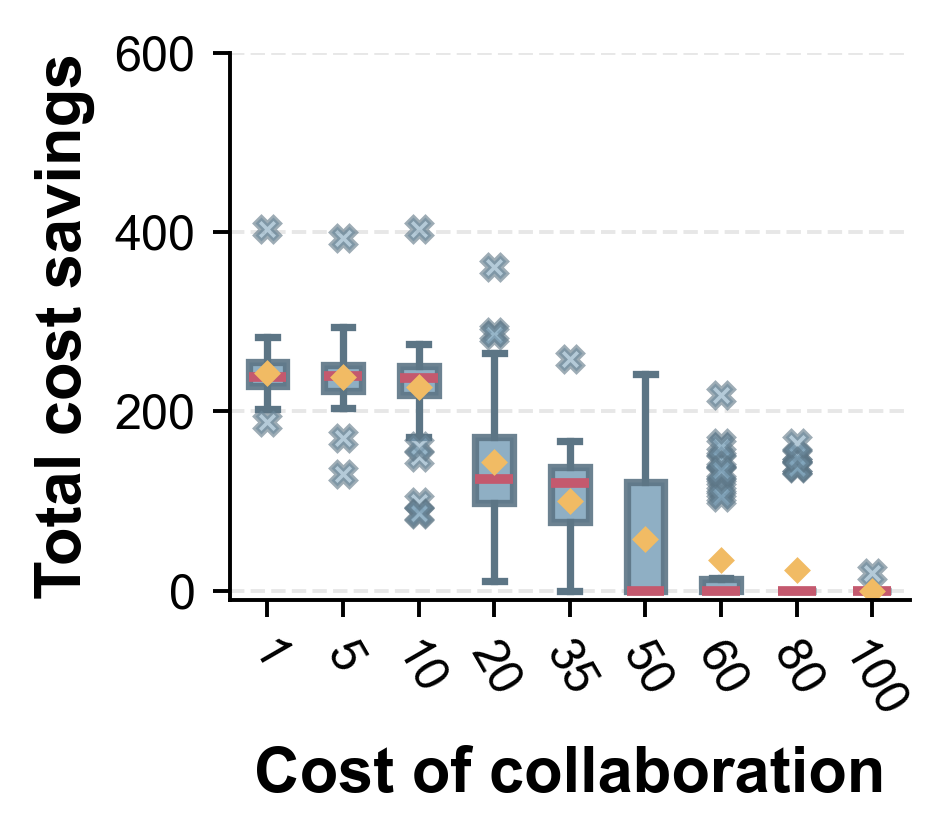

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Total cost savings'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4bad7cdf0>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4bad7d210>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4bad7ca30>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4bad7d750>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4bad7dc90>,
  'means': [<matplotlib.lines.Line2D at 0x1d4bad7d9f0>,
   <matplotlib.lines.Line2D at 0x1d4badf7df0>]})

In [431]:
figure_plot.box_plot(
    data_list=all_metrics_center_clustered_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='total_cost_savings',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Total cost savings',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(-10,600),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='total_cost_savings_by_penalty_af60_all_outside_clustered_receivers.png',
)

#### Cost savings (outside-dispersed-af0.6)

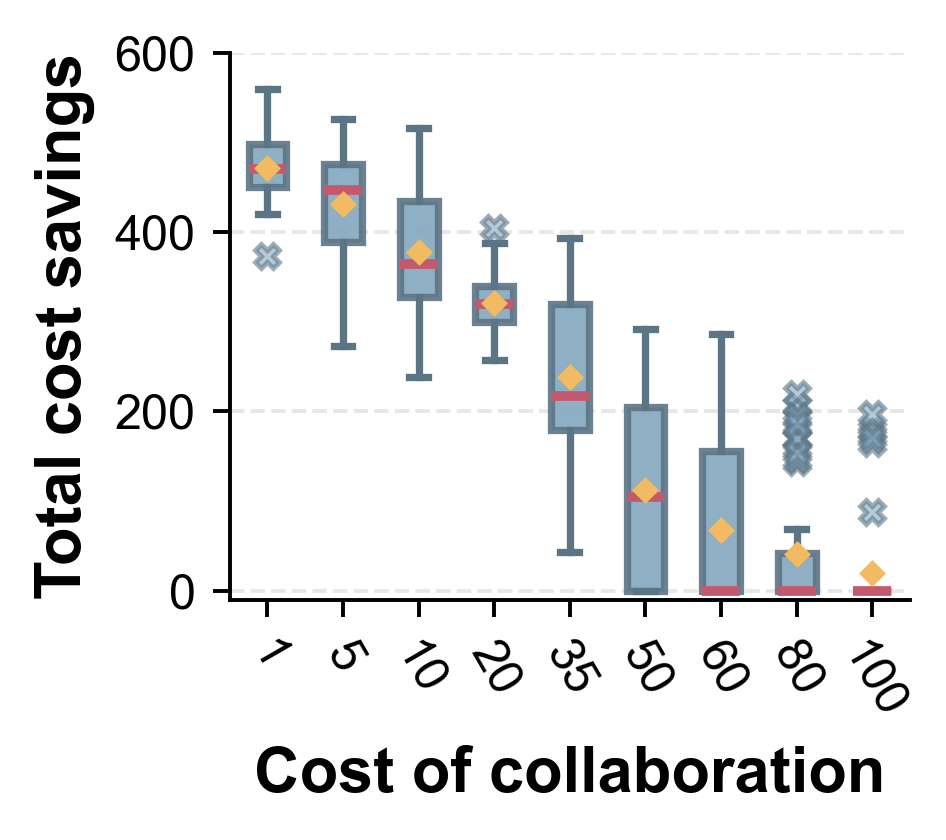

(<Figure size 980x875 with 1 Axes>,
 <Axes: xlabel='Cost of collaboration', ylabel='Total cost savings'>,
 {'whiskers': [<matplotlib.lines.Line2D at 0x1d4bac1c0d0>,
  'caps': [<matplotlib.lines.Line2D at 0x1d4bac1c4f0>,
  'boxes': [<matplotlib.patches.PathPatch at 0x1d4babefcd0>,
  'medians': [<matplotlib.lines.Line2D at 0x1d4bac1ca30>,
  'fliers': [<matplotlib.lines.Line2D at 0x1d4bac1cf70>,
  'means': [<matplotlib.lines.Line2D at 0x1d4bac1ccd0>,
   <matplotlib.lines.Line2D at 0x1d4bac8f0d0>]})

In [428]:
figure_plot.box_plot(
    data_list=all_metrics_outside_dispersed_df.query("allocation_factor == 0.6 and penalty_std != 0 and penalty_std != 3"),
    cat_col='penalty_std',
    col_name='total_cost_savings',
    box_colors=["#83A7BE"] * len(PENALTY_LIST),
    # box_colors=sns.color_palette("Blues", n_colors=len(PENALTY_LIST)),
    box_alpha=0.9,
    se_box_color_for_lines=True,
     # Display options
    flier_marker='X',
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c4596e",
    median_linewidth=2,
    show_mean=True,
    mean_size=3,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Total cost savings',
    xlabel='Cost of collaboration',
    #--- Violin plot ---
    show_violin=False,
    violin_alpha=0.3, 
    violin_width=0.9,
    #--- font size---
    tick_rotation=-60,
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    ylim=(-10,600),
    label_size=13,
    figure_size=(2.8, 2.5),
    dpi=350,
    figure_folder=OUTPUT_FIG_PATH,
    filename='total_cost_savings_by_penalty_af60_all_outside_dispersed_receivers.png',
)

### Trial on Moran's I and Getis Ord 

In [ ]:
link_data_path = repo_root / 'data/freightChessboardRC/cleanMoreDispersed'
all_stat_collab_links, all_stat_collab_links_agg = agg_anls.aggregate_collaborative_receivers_by_link(
    str(link_data_path),
    verbose=True
)

In [ ]:
ins_outside_dispersed_specific_stat_collab_links = all_stat_collab_links[
    (all_stat_collab_links['allocation_factor'] == specific_anls_af) &
    (all_stat_collab_links['penalty'] == specific_anls_penalty) &
    (all_stat_collab_links['depot_location'] == DepotLocation.OUTSIDE.value) &
    (all_stat_collab_links['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)
]

ins_outside_clustered_specific_stat_collab_links = all_stat_collab_links[
    (all_stat_collab_links['allocation_factor'] == specific_anls_af) &
    (all_stat_collab_links['penalty'] == specific_anls_penalty) &
    (all_stat_collab_links['depot_location'] == DepotLocation.OUTSIDE.value) &
    (all_stat_collab_links['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)
]

ins_center_dispersed_specific_stat_collab_links = all_stat_collab_links[
    (all_stat_collab_links['allocation_factor'] == specific_anls_af) &
    (all_stat_collab_links['penalty'] == specific_anls_penalty) &
    (all_stat_collab_links['depot_location'] == DepotLocation.INSIDE.value) &
    (all_stat_collab_links['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)
]

ins_center_clustered_specific_stat_collab_links = all_stat_collab_links[
    (all_stat_collab_links['allocation_factor'] == specific_anls_af) &
    (all_stat_collab_links['penalty'] == specific_anls_penalty) &
    (all_stat_collab_links['depot_location'] == DepotLocation.INSIDE.value) &
    (all_stat_collab_links['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)
]

In [ ]:
ins_center_specific_stat_collab_links = all_stat_collab_links[
    (all_stat_collab_links['allocation_factor'] == specific_anls_af) &
    (all_stat_collab_links['penalty'] == specific_anls_penalty) &
    (all_stat_collab_links['depot_location'] == DepotLocation.INSIDE.value)
]

ins_outside_specific_stat_collab_links = all_stat_collab_links[
    (all_stat_collab_links['allocation_factor'] == specific_anls_af) &
    (all_stat_collab_links['penalty'] == specific_anls_penalty) &
    (all_stat_collab_links['depot_location'] == DepotLocation.OUTSIDE.value)
]

In [ ]:
mean_collab_links_center_clustered = spatial_anls.compute_mean_collab_count_by_link(
    ins_center_clustered_specific_stat_collab_links,
    central_area_network_gdf,)
mean_collab_links_center_dispersed = spatial_anls.compute_mean_collab_count_by_link(
    ins_center_dispersed_specific_stat_collab_links,
    full_network_gdf,)
mean_collab_links_outside_clustered = spatial_anls.compute_mean_collab_count_by_link(
    ins_outside_clustered_specific_stat_collab_links,
    central_area_network_gdf,)
mean_collab_links_outside_dispersed = spatial_anls.compute_mean_collab_count_by_link(
    ins_outside_dispersed_specific_stat_collab_links,
    full_network_gdf,)

mean_collab_links_center = spatial_anls.compute_mean_collab_count_by_link(
    ins_center_specific_stat_collab_links,
    central_area_network_gdf,)
mean_collab_links_outside = spatial_anls.compute_mean_collab_count_by_link(
    ins_outside_specific_stat_collab_links,
    full_network_gdf,) 

In [ ]:
mean_collab_links_center.plot(column='total_collab_count',
                                        cmap='Blues',
                                        legend=True,
                                        figsize=(8, 6),
                                        # title='Mean Collaborative Receivers per Link\n(Center - Clustered)',
                                        # edgecolor='k',
                                        linewidth=3)

In [ ]:
mean_collab_links_outside.plot(column='total_collab_count',
                                        cmap='Blues',
                                        legend=True,
                                        figsize=(8, 6),
                                        # title='Mean Collaborative Receivers per Link\n(Center - Clustered)',
                                        # edgecolor='k',
                                        linewidth=3)

In [ ]:
_result = spatial_anls.compute_getis_ord_statistics(
    mean_collab_links_outside, 
    col_name='total_collab_count',
    # weights_type='knn',
    # k_neighbors=5
    weights_type='queen',
    # distance_threshold=1500,
    # binary=True
)

In [ ]:
spatial_anls.compute_getis_ord_statistics(
    mean_collab_links_center, 
    col_name='total_collab_count',
    # weights_type='knn',
    # k_neighbors=5
    weights_type='queen',
    # distance_threshold=1500,
    # binary=True
)

In [ ]:
result_moran_ = spatial_anls.compute_moran_statistics(
    mean_collab_links_center,
     weights_type='queen', 
    col_name='total_collab_count'
)

In [ ]:
result_moran_ = spatial_anls.compute_moran_statistics(
    mean_collab_links_outside,
     weights_type='queen', 
    col_name='total_collab_count'
)

### Map and locations

In [99]:
_sel_ins = 15
dispersed_ins_receiver_df = gpd.read_file(os.path.join(
    OUTPUT_PATH, 
    f'{DepotLocation.OUTSIDE.value}-{ReceiverDistribution.DISPERSED.value}-af{ALLOCATION_FACTOR:.02f}-p{0.0056}-i{_sel_ins:02d}',
    'geo_data.geojson'))
clustered_ins_receiver_df = gpd.read_file(os.path.join(
    OUTPUT_PATH,
    f'{DepotLocation.OUTSIDE.value}-{ReceiverDistribution.CLUSTERED.value}-af{ALLOCATION_FACTOR:.02f}-p{0.0056}-i{_sel_ins:02d}',
    'geo_data.geojson'))

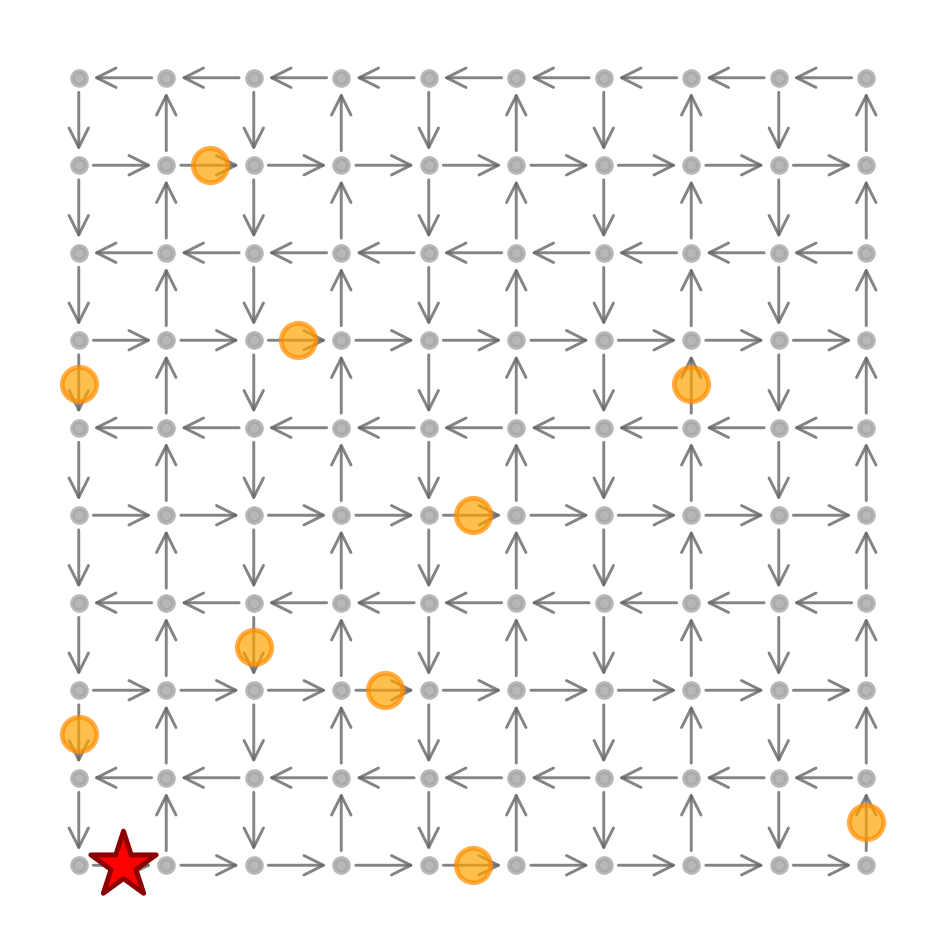

(<Figure size 980x980 with 1 Axes>, <Axes: >)

In [100]:
''' Plot the dispersed scenario receiver locations at link midpoints '''
figure_plot.network_locations_plot(
    network=network,
    locations_gdf=dispersed_ins_receiver_df,
     # Links settings
    show_links=True,
    show_nodes=True,
    use_arrows=True,
    link_color="#646667",
    link_alpha=0.8,
    link_linewidth=0.6,
    arrow_scale=10,
    arrow_shrink=3,
    # Nodes settings
    node_size=8,
    node_color="#A7A7A7",
    node_alpha=0.8,
    # 使用link中点定位 (新功能)
    use_link_midpoint=True,
    link_id_col='link_id',
    # Central region
    show_central_region=False,
    central_region_bounds=(2000, 2000, 5000, 5000),
    central_region_label='Central Region (2000-7000)',
    #---X/Y labels---
    xlabel='X coordinate (m)',
    ylabel='Y coordinate (m)',
    label_size=14,

    #---Carrier and receiver markers---
    receiver_size=50,
    # carrier_marker='^',
    # carrier_color="#bde59d",
    # carrier_edgecolor="#5F9473",
    # carrier_size=100,
    # Axis limits
    xlim=(-500, 9500),
    ylim=(-500, 9500),
    #---Title and style---
    # title='Receiver Locations at Link Midpoints (Clustered)',
    figure_size=(2.8, 2.8),
    dpi=350,
    show_grid=False,
    show_legend=False,
    #---Output---
    hide_axis=True,
    hide_labels=True,
    figure_folder=OUTPUT_FIG_PATH,
    filename=f'receiver_locations_dispersed_outside_random_af{specific_anls_af:.02f}_p{specific_anls_penalty:.04f}_i{_sel_ins:02d}.png'
)

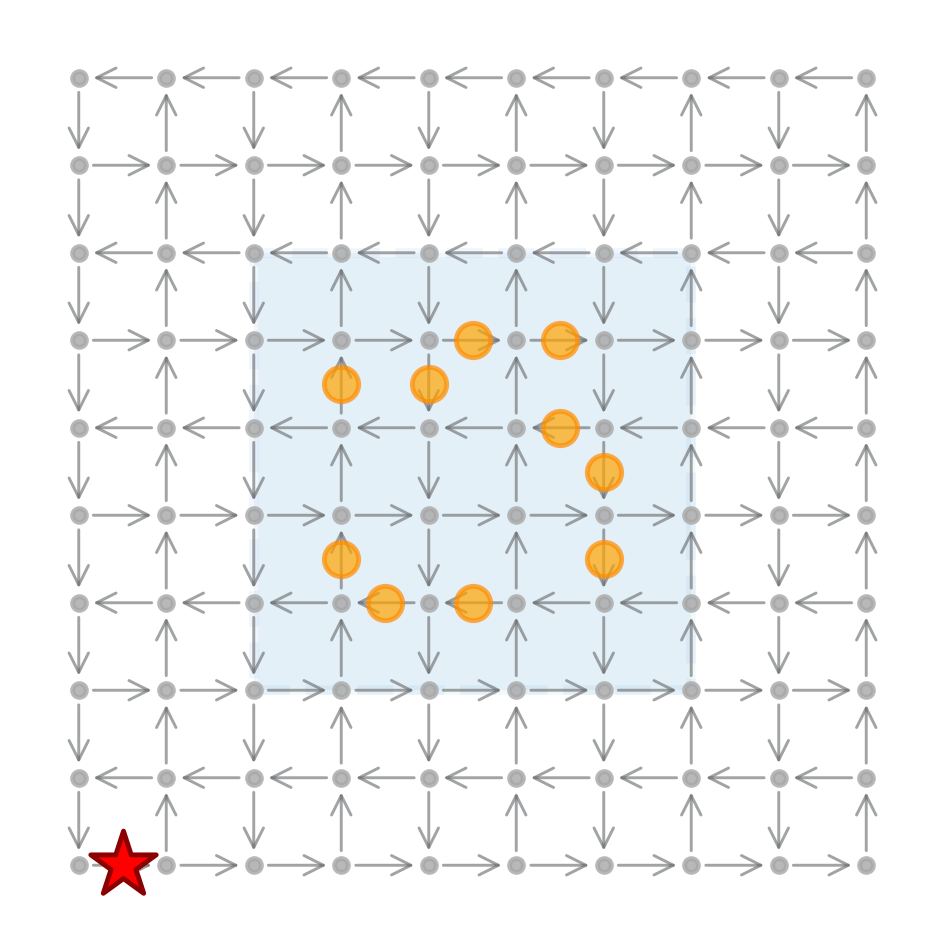

(<Figure size 980x980 with 1 Axes>, <Axes: >)

In [95]:
''' Plot the clustered scenario receiver locations at link midpoints '''
figure_plot.network_locations_plot(
    network=network,
    locations_gdf=clustered_ins_receiver_df,
    # Links settings
    show_links=True,
    show_nodes=True,
    use_arrows=True,
    link_color="#646667", # "#878A8B" for lighter
    link_alpha=0.6,
    link_linewidth=0.6,
    arrow_scale=10,
    arrow_shrink=3,
    # Nodes settings
    node_size=8,
    node_color="#A7A7A7",
    node_alpha=0.8,
    # 使用link中点定位 (新功能)
    use_link_midpoint=True,
    link_id_col='link_id',
    # Central region
    show_central_region=True,
    central_region_bounds=(2000, 2000, 5000, 5000),
    central_region_label='Central Region (2000-7000)',
    #---X/Y labels---
    xlabel='X coordinate (m)',
    ylabel='Y coordinate (m)',
    label_size=14,

    #---Carrier and receiver markers---
    receiver_size=50,
    # carrier_marker='^',
    # carrier_color="#bde59d",
    # carrier_edgecolor="#5F9473",
    # carrier_size=100,
    # Axis limits
    xlim=(-500, 9500),
    ylim=(-500, 9500),
    #---Title and style---
    # title='Receiver Locations at Link Midpoints (Clustered)',
    figure_size=(2.8, 2.8),
    dpi=350,
    show_grid=False,
    show_legend=False,
    hide_axis=True,
    hide_labels=True,
    #---Output---
    figure_folder=OUTPUT_FIG_PATH,
    filename=f'receiver_locations_outside_inside_random_af{specific_anls_af:.02f}_p{specific_anls_penalty:.04f}_i{_sel_ins:02d}.png'
)

### Collaboration rate

In [ ]:
''' Box plot using figure_plot module '''
del_ins = (-1, -50)
# Example usage with the new box_plot function
fig, ax, bp = figure_plot.box_plot(
    data_list=[
        ins_center_clustered_specific_anls_df[~ins_center_clustered_specific_anls_df['instance'].between(del_ins[0], del_ins[1])],
        ins_center_dispersed_specific_anls_df[~ins_center_dispersed_specific_anls_df['instance'].between(del_ins[0], del_ins[1])],
        ins_outside_clustered_specific_anls_df[~ins_outside_clustered_specific_anls_df['instance'].between(del_ins[0], del_ins[1])],
        ins_outside_dispersed_specific_anls_df[~ins_outside_dispersed_specific_anls_df['instance'].between(del_ins[0], del_ins[1])]
    ],
    col_name='collaboration_rate',
    labels=['Center-Clustered', 'Center-Dispersed', 'Outside-Clustered', 'Outside-Dispersed'],
    # Box colors
    box_colors=["#89ADA8", "#ddd2e9c4", "#345e55", "#8e76a6"],
    # Background colors for each box region
    bg_colors=["#CBE6D9", "#f7e0fb", "#9ac99a", "#d9b3ed"],
    # Display options
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c3435d",
    show_mean=True,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Collaboration rate',
    # title=f'Collaboration Rate Distribution (AF={specific_anls_af}, Penalty={specific_anls_penalty})',
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    label_size=13,
    figure_size=(6, 2.7),
    figure_folder=OUTPUT_FIG_PATH,
    # filename=f'boxplot_collaboration_rate_across_spatial_distributions_scenarios_af{specific_anls_af:.02f}_p{specific_anls_penalty:.04f}_i{_sel_ins:02d}.png'
)

It seems not necessary to compare VKT, TT and TKT, 
since the scenarios with the outside depot have way higher values than others.

### VKT

In [ ]:
''' Box plot '''
fig, ax, bp = figure_plot.box_plot(
    data_list=[
        ins_center_clustered_specific_anls_df,
        ins_outside_clustered_specific_anls_df,
        ins_center_dispersed_specific_anls_df,
        ins_outside_dispersed_specific_anls_df
    ],
    col_name='VKT_km',
    labels=['Center-Clustered', 'Outside-Clustered', 'Center-Dispersed', 'Outside-Dispersed'],
    # Box colors
    box_colors=["#89ADA8",  "#345e55", "#ddd2e9c4", "#8e76a6"],
    # Background colors for each box region
    bg_colors=["#CBE6D9", "#9ac99a", "#f7e0fb",  "#d9b3ed"],
    # Display options
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c3435d",
    show_mean=True,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='VKT',
    # title=f'Collaboration Rate Distribution (AF={specific_anls_af}, Penalty={specific_anls_penalty})',
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    label_size=13,
    figure_size=(6, 2.7),
    figure_folder=OUTPUT_FIG_PATH,
    #filename=f'boxplot_vkt_across_spatial_distributions_scenarios_af_{specific_anls_af}.png'
)

In [ ]:
''' Box plot '''
fig, ax, bp = figure_plot.box_plot(
    data_list=[
        ins_center_clustered_specific_anls_df,
        ins_outside_clustered_specific_anls_df,
        ins_center_dispersed_specific_anls_df,
        ins_outside_dispersed_specific_anls_df
    ],
    col_name='VKT_km',
    labels=['Center-Clustered', 'Outside-Clustered', 'Center-Dispersed', 'Outside-Dispersed'],
    # Box colors
    box_colors=["#83A7BE"] * 4,
    # Background colors for each box region
    #bg_colors=["#CBE6D9", "#9ac99a", "#f7e0fb",  "#d9b3ed"],
    # Display options
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c3435d",
    show_mean=True,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='VKT',
    # title=f'Collaboration Rate Distribution (AF={specific_anls_af}, Penalty={specific_anls_penalty})',
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    label_size=13,
    figure_size=(6, 2.7),
    figure_folder=OUTPUT_FIG_PATH,
    #filename=f'boxplot_vkt_across_spatial_distributions_scenarios_af_{specific_anls_af}.png'
)

### VTT

In [ ]:
''' Box plot '''
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    [ins_center_clustered_specific_anls_df['VTT_seconds'],
     ins_center_dispersed_specific_anls_df['VTT_seconds'],
     ins_outside_clustered_specific_anls_df['VTT_seconds'],
     ins_outside_dispersed_specific_anls_df['VTT_seconds']],
    labels=['Center-Clustered', 'Center-Dispersed', 'Outside-Clustered', 'Outside-Dispersed'],
    patch_artist=True,
    boxprops=dict(facecolor='#8dadc3', color='black', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.6)
)
ax.set_title(f'VTT Distribution (AF={specific_anls_af}, Penalty={specific_anls_penalty})')
ax.set_ylabel('VTT (seconds)')
plt.tight_layout()

plt.show()

### TKT

In [ ]:
''' Box plot '''
_ins_center_clustered_specific_anls_df = ins_center_clustered_specific_anls_df.copy()
_ins_center_clustered_specific_anls_df['TKT_tonkm'] = _ins_center_clustered_specific_anls_df['TKT_tonkm'] / 1000
_ins_center_dispersed_specific_anls_df = ins_center_dispersed_specific_anls_df.copy()
_ins_center_dispersed_specific_anls_df['TKT_tonkm'] = _ins_center_dispersed_specific_anls_df['TKT_tonkm'] / 1000
_ins_outside_clustered_specific_anls_df = ins_outside_clustered_specific_anls_df.copy()
_ins_outside_clustered_specific_anls_df['TKT_tonkm'] = _ins_outside_clustered_specific_anls_df['TKT_tonkm'] / 1000
_ins_outside_dispersed_specific_anls_df = ins_outside_dispersed_specific_anls_df.copy()
_ins_outside_dispersed_specific_anls_df['TKT_tonkm'] = _ins_outside_dispersed_specific_anls_df['TKT_tonkm'] / 1000

fig, ax, bp = figure_plot.box_plot(
    data_list=[
        _ins_center_clustered_specific_anls_df,
        _ins_center_dispersed_specific_anls_df,
        _ins_outside_clustered_specific_anls_df,
        _ins_outside_dispersed_specific_anls_df
    ],
    col_name='TKT_tonkm',
    labels=['Center-Clustered', 'Center-Dispersed', 'Outside-Clustered', 'Outside-Dispersed'],
    # Box colors
    box_colors=["#89ADA8", "#ddd2e9c4", "#345e55", "#8e76a6"],
    # Background colors for each box region
    bg_colors=["#CBE6D9", "#f7e0fb", "#9ac99a", "#d9b3ed"],
    # Display options
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c3435d",
    show_mean=True,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Ton-km travelled',
    # title=f'Collaboration Rate Distribution (AF={specific_anls_af}, Penalty={specific_anls_penalty})',
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    label_size=13,
    figure_size=(6, 2.7),
    figure_folder=OUTPUT_FIG_PATH,
    filename=f'boxplot_tkt_across_spatial_distributions_scenarios_af_{specific_anls_af}.png'
)

In [ ]:
''' Box plot '''
_ins_center_clustered_specific_anls_df = ins_center_clustered_specific_anls_df.copy()
_ins_center_clustered_specific_anls_df['TKT_tonkm'] = _ins_center_clustered_specific_anls_df['TKT_tonkm'] / 1000
_ins_center_dispersed_specific_anls_df = ins_center_dispersed_specific_anls_df.copy()
_ins_center_dispersed_specific_anls_df['TKT_tonkm'] = _ins_center_dispersed_specific_anls_df['TKT_tonkm'] / 1000
_ins_outside_clustered_specific_anls_df = ins_outside_clustered_specific_anls_df.copy()
_ins_outside_clustered_specific_anls_df['TKT_tonkm'] = _ins_outside_clustered_specific_anls_df['TKT_tonkm'] / 1000
_ins_outside_dispersed_specific_anls_df = ins_outside_dispersed_specific_anls_df.copy()
_ins_outside_dispersed_specific_anls_df['TKT_tonkm'] = _ins_outside_dispersed_specific_anls_df['TKT_tonkm'] / 1000

fig, ax, bp = figure_plot.box_plot(
    data_list=[
        _ins_center_clustered_specific_anls_df,
        _ins_outside_clustered_specific_anls_df,
        _ins_center_dispersed_specific_anls_df,
        _ins_outside_dispersed_specific_anls_df
    ],
    col_name='TKT_tonkm',
    labels=['Center-Clustered',  'Outside-Clustered', 'Center-Dispersed', 'Outside-Dispersed'],
    # Box colors
    box_colors=["#83A7BE"] * 4,
    # Background colors for each box region
    #bg_colors=["#CBE6D9", "#f7e0fb", "#9ac99a", "#d9b3ed"],
    # Display options
    show_scatter=False,
    scatter_use_box_color=True,
    scatter_alpha=0.4,
    median_color="#c3435d",
    show_mean=True,
    mean_color="#f1bb64",
    use_box_color_for_lines=True,
    # Labels
    ylabel='Ton-km travelled',
    # title=f'Collaboration Rate Distribution (AF={specific_anls_af}, Penalty={specific_anls_penalty})',
    # Grid
    show_grid=True,
    grid_axis='y',
    #---output---
    label_size=13,
    figure_size=(6, 2.7),
    figure_folder=OUTPUT_FIG_PATH,
    #filename=f'boxplot_tkt_across_spatial_distributions_scenarios_af_{specific_anls_af}.png'
)

### Fleet size

In [ ]:
fleet_size_data_dict = {
    'Center-Clustered': ins_center_clustered_specific_anls_df,
    'Center-Dispersed': ins_center_dispersed_specific_anls_df,
    'Outside-Clustered': ins_outside_clustered_specific_anls_df,
    'Outside-Dispersed': ins_outside_dispersed_specific_anls_df
}

In [ ]:
fig, ax = figure_plot.quadrant_donut_chart(
    data_dict=fleet_size_data_dict,
    value_col='final_fleet_size',
    hole_radius=0.4,
    xlabel_right='Dispersed →',
    xlabel_left='← Clustered',
    ylabel_top='↑ Center',
    ylabel_bottom='↓ Outside',
    explode=0.03,
    dpi=350,
    figsize=(6, 6),
)

In [ ]:


fig, ax = figure_plot.nested_donut_chart(
    data_dict,
    group_col='final_fleet_size',
    # title='Fleet Size Distribution by Scenario',
    inner_colors=["#88ABA7", "#ddd2e9c4", "#4d8075", "#b7a4ca"],
    outer_color_list=["#dcbdc3", "#c18d97", "#844954CF", "#844954"],
    outer_cmap='coolwarm',
    show_inner_labels=False,
    show_inner_pct=False,
    show_outer_count=False,
    show_outer_labels=False,
    hole_radius=0.4,
    inner_label_size=5,
    dpi=350,
    outer_label_size=10,
    figsize=(5, 5),
    show_legend=False,
    figure_folder=OUTPUT_FIG_PATH,
    filename='nested_donut_fleet_size_by_scenario.png',
     transparent_bg=True
)

### Spatial index
Relations: (mean-dist-to-depot; clustering index; ) <-> (VKT, TT, TKT, Cost savings, scores, etc)

In [ ]:
spatial_concat_df = pd.concat([
    ins_center_clustered_specific_anls_df,
    ins_center_dispersed_specific_anls_df,
    ins_outside_clustered_specific_anls_df,
    ins_outside_dispersed_specific_anls_df
], ignore_index=True)

In [ ]:
spatial_concat_df['class'] = spatial_concat_df.apply(lambda row: f"{row['depot_location']}_{row['receiver_distribution']}", axis=1)
spatial_concat_df

In [ ]:
figure_plot.scatter_regression_plot(
    x_col='nni',
    y_col='total_cost_savings',
    data_df=spatial_concat_df,
    figure_size=(5.8,4),
    xlabel='NNI',
    ylabel='Total cost savings',
    label_size=14,
    # title='Scatter plot with regression line: Cost Savings vs Collaboration Rate',
    show_corr=True,
    add_regression=True,
    show_equation=False,
    show_r2=True,
    scatter_color='#458CBC',
    scatter_alpha=0.9,
    reg_color='#0b2c60',
    # Output
    # figure_folder=OUTPUT_FIG_PATH,
    # filename='scatter_regression_cost_savings_vs_clustering_index.png'
    ) 

In [ ]:
figure_plot.scatter_regression_plot(
    x_col='mean_receiver_dist_to_depot_euclidean_km',
    y_col='total_cost_savings',
    data_df=spatial_concat_df,
    figure_size=(5.8,4),
    xlabel='Mean receiver distance to depot (km)',
    ylabel='Total cost savings',
    label_size=14,
    # title='Scatter plot with regression line: Cost Savings vs Collaboration Rate',
    show_corr=True,
    add_regression=True,
    show_equation=False,
    show_r2=True,
    annotation_fontsize=12,
    scatter_color='#458CBC',
    scatter_alpha=0.9,
    reg_color='#0b2c60',
    # Output
    figure_folder=OUTPUT_FIG_PATH,
    #filename='scatter_regression_cost_savings_vs_mean_receiver_dist2Depot.png'
    ) 

In [ ]:
figure_plot.scatter_regression_plot(
    x_col='centroid_to_depot_euclidean_km',
    y_col='total_cost_savings',
    data_df=spatial_concat_df,
    figure_size=(5.8,4),
    xlabel='Centroid to depot distance (km)',
    ylabel='Total cost savings',
    label_size=14,
    # title='Scatter plot with regression line: Cost Savings vs Collaboration Rate',
    show_corr=True,
    add_regression=True,
    show_equation=False,
    show_r2=True,
    annotation_fontsize=12,
    scatter_color='#458CBC',
    scatter_alpha=0.9,
    reg_color='#0b2c60',
    # Output
    figure_folder=OUTPUT_FIG_PATH,
    #filename='scatter_regression_cost_savings_vs_centroid_to_depot.png'
    ) 

In [ ]:
figure_plot.scatter_regression_plot(
    x_col='centroid_to_depot_euclidean_km',
    y_col='total_cost_savings',
    data_df=spatial_concat_df[spatial_concat_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value],
    figure_size=(5.8,4),
    xlabel='Centroid to depot distance (km)',
    ylabel='Total cost savings',
    label_size=14,
    # title='Scatter plot with regression line: Cost Savings vs Collaboration Rate',
    show_corr=True,
    add_regression=True,
    show_equation=False,
    show_r2=True,
    annotation_fontsize=12,
    scatter_color='#458CBC',
    scatter_alpha=0.9,
    reg_color='#0b2c60',
    # Output
    figure_folder=OUTPUT_FIG_PATH,
    #filename='scatter_regression_cost_savings_vs_centroid_to_depot.png'
    ) 

In [ ]:
figure_plot.scatter_regression_plot(
    x_col='centroid_to_depot_euclidean_km',
    y_col='total_cost_savings',
    data_df=spatial_concat_df[spatial_concat_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value],
    figure_size=(5.8,4),
    xlabel='Centroid to depot distance (km)',
    ylabel='Total cost savings',
    label_size=14,
    # title='Scatter plot with regression line: Cost Savings vs Collaboration Rate',
    show_corr=True,
    add_regression=True,
    show_equation=False,
    show_r2=True,
    annotation_fontsize=12,
    scatter_color='#458CBC',
    scatter_alpha=0.9,
    reg_color='#0b2c60',
    # Output
    figure_folder=OUTPUT_FIG_PATH,
    #filename='scatter_regression_cost_savings_vs_centroid_to_depot.png'
    ) 